<a href="https://colab.research.google.com/github/zakifalihin/Research-SkinDisNet/blob/main/penelitian_penyakit_kulit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install library tambahan yang belum default di Kaggle
!pip install timm grad-cam --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# CELL 1 — KONFIGURASI & VERIFIKASI DATASET

In [ ]:
import os
from pathlib import Path

# ============================================================
# 1. ROOT DATASET KAGGLE
# ============================================================

BASE_DIR = Path("/content/drive/MyDrive/Penelitian Kulit")

print("=" * 70)
print("ISI ROOT DATASET")
print("=" * 70)

if not BASE_DIR.exists():
    raise FileNotFoundError(
        f"Dataset tidak ditemukan:\n{BASE_DIR}"
    )

for item in sorted(BASE_DIR.iterdir()):
    print(f"[DIR] {item.name}" if item.is_dir() else f"[FILE] {item.name}")


# ============================================================
# 2. CARI FOLDER UTAMA SKINDISNET
# ============================================================

DATASET_ROOT = None

for item in BASE_DIR.iterdir():
    if item.is_dir() and item.name.startswith("SkinDisNet"):
        # Folder yang kemungkinan berisi SkinDisNet / SkinDisNet_2
        if (item / "SkinDisNet").exists():
            DATASET_ROOT = item
            break

if DATASET_ROOT is None:
    raise FileNotFoundError(
        "Folder utama SkinDisNet tidak ditemukan."
    )

print("\n" + "=" * 70)
print("DATASET ROOT")
print("=" * 70)
print(DATASET_ROOT)


# ============================================================
# 3. TENTUKAN FOLDER DATASET
# ============================================================

SKINDISNET_DIR = DATASET_ROOT / "SkinDisNet"
SKINDISNET_2_DIR = DATASET_ROOT / "SkinDisNet_2"

METADATA_PATH = DATASET_ROOT / "SkinDisNet_Metadata.xlsx"


# ============================================================
# 4. VERIFIKASI PATH
# ============================================================

print("\n" + "=" * 70)
print("VERIFIKASI PATH")
print("=" * 70)

paths = {
    "SkinDisNet": SKINDISNET_DIR,
    "SkinDisNet_2": SKINDISNET_2_DIR,
    "Metadata": METADATA_PATH,
}

for name, path in paths.items():
    status = "✓ DITEMUKAN" if path.exists() else "✗ TIDAK DITEMUKAN"
    print(f"{status:<18} {name}")
    print(f"                   {path}")


# ============================================================
# 5. CEK STRUKTUR SKINDISNET UTAMA
# ============================================================

PREPROCESSED_DIR = SKINDISNET_DIR / "Preprocessed"
AUGMENTED_DIR = SKINDISNET_DIR / "Augmented"

print("\n" + "=" * 70)
print("STRUKTUR SKINDISNET")
print("=" * 70)

for name, path in {
    "Preprocessed": PREPROCESSED_DIR,
    "Augmented": AUGMENTED_DIR,
}.items():

    if path.exists():
        print(f"\n{name}: ✓")
        print(f"Path: {path}")

        for class_dir in sorted(path.iterdir()):
            if class_dir.is_dir():
                print(f"   └── {class_dir.name}")
    else:
        print(f"\n{name}: ✗ TIDAK DITEMUKAN")


# ============================================================
# 6. FUNGSI UNTUK MENGHITUNG FILE GAMBAR
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


def count_images(folder):
    """
    Menghitung seluruh file gambar secara recursive.
    """
    if not folder.exists():
        return 0

    return sum(
        1
        for file in folder.rglob("*")
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    )


def count_images_per_class(folder):
    """
    Menghitung jumlah gambar pada setiap kelas.
    """
    results = {}

    if not folder.exists():
        return results

    for class_dir in sorted(folder.iterdir()):
        if class_dir.is_dir():

            count = sum(
                1
                for file in class_dir.rglob("*")
                if file.is_file()
                and file.suffix.lower() in IMAGE_EXTENSIONS
            )

            results[class_dir.name] = count

    return results


# ============================================================
# 7. JUMLAH GAMBAR PREPROCESSED
# ============================================================

print("\n" + "=" * 70)
print("JUMLAH GAMBAR — PREPROCESSED")
print("=" * 70)

preprocessed_counts = count_images_per_class(PREPROCESSED_DIR)

total_preprocessed = 0

for class_name, count in preprocessed_counts.items():
    print(f"{class_name:<10}: {count:>5}")

    total_preprocessed += count

print("-" * 30)
print(f"{'TOTAL':<10}: {total_preprocessed:>5}")


# ============================================================
# 8. JUMLAH GAMBAR AUGMENTED
# ============================================================

print("\n" + "=" * 70)
print("JUMLAH GAMBAR — AUGMENTED")
print("=" * 70)

augmented_counts = count_images_per_class(AUGMENTED_DIR)

total_augmented = 0

for class_name, count in augmented_counts.items():
    print(f"{class_name:<10}: {count:>5}")

    total_augmented += count

print("-" * 30)
print(f"{'TOTAL':<10}: {total_augmented:>5}")


# ============================================================
# 9. INFORMASI DATASET
# ============================================================

print("\n" + "=" * 70)
print("RINGKASAN DATASET")
print("=" * 70)

print(f"Dataset root       : {DATASET_ROOT}")
print(f"Preprocessed       : {total_preprocessed:,} images")
print(f"Augmented          : {total_augmented:,} images")
print(f"Metadata tersedia  : {METADATA_PATH.exists()}")
print(f"SkinDisNet_2       : {SKINDISNET_2_DIR.exists()}")


# ============================================================
# 10. PERBANDINGAN DENGAN DATASET YANG DIHARAPKAN
# ============================================================

EXPECTED_PREPROCESSED = {
    "AD": 70,
    "CD": 477,
    "EC": 466,
    "SC": 343,
    "SD": 79,
    "TC": 275
}

EXPECTED_AUGMENTED = {
    "AD": 490,
    "CD": 3339,
    "EC": 3262,
    "SC": 2401,
    "SD": 553,
    "TC": 1925
}


print("\n" + "=" * 70)
print("VALIDASI JUMLAH KELAS")
print("=" * 70)

print("\nPREPROCESSED:")

for class_name, expected in EXPECTED_PREPROCESSED.items():

    actual = preprocessed_counts.get(class_name, 0)

    status = "✓" if actual == expected else "⚠"

    print(
        f"{status} {class_name}: "
        f"actual={actual}, expected={expected}"
    )


print("\nAUGMENTED:")

for class_name, expected in EXPECTED_AUGMENTED.items():

    actual = augmented_counts.get(class_name, 0)

    status = "✓" if actual == expected else "⚠"

    print(
        f"{status} {class_name}: "
        f"actual={actual}, expected={expected}"
    )


print("\n" + "=" * 70)
print("KONFIGURASI SELESAI")
print("=" * 70)

ISI ROOT DATASET
[DIR] SkinDisNet A Multi-Class Clinical Images and Metad

DATASET ROOT
/content/drive/MyDrive/Penelitian Kulit/SkinDisNet A Multi-Class Clinical Images and Metad

VERIFIKASI PATH
✓ DITEMUKAN        SkinDisNet
                   /content/drive/MyDrive/Penelitian Kulit/SkinDisNet A Multi-Class Clinical Images and Metad/SkinDisNet
✓ DITEMUKAN        SkinDisNet_2
                   /content/drive/MyDrive/Penelitian Kulit/SkinDisNet A Multi-Class Clinical Images and Metad/SkinDisNet_2
✓ DITEMUKAN        Metadata
                   /content/drive/MyDrive/Penelitian Kulit/SkinDisNet A Multi-Class Clinical Images and Metad/SkinDisNet_Metadata.xlsx

STRUKTUR SKINDISNET

Preprocessed: ✓
Path: /content/drive/MyDrive/Penelitian Kulit/SkinDisNet A Multi-Class Clinical Images and Metad/SkinDisNet/Preprocessed
   └── AD
   └── CD
   └── EC
   └── SC
   └── SD
   └── TC

Augmented: ✓
Path: /content/drive/MyDrive/Penelitian Kulit/SkinDisNet A Multi-Class Clinical Images and Metad/SkinD

# CELL 2 — DATASET AUDIT: METADATA & PATIENT STRUCTURE

In [ ]:
import pandas as pd
import os
from pathlib import Path

print("=" * 70)
print("MEMBACA METADATA SKINDISNET")
print("=" * 70)

# ------------------------------------------------------------
# 1. LOAD METADATA
# ------------------------------------------------------------

metadata_df = pd.read_excel(METADATA_PATH)

print("\nMetadata berhasil dibaca.")
print(f"Jumlah baris   : {metadata_df.shape[0]:,}")
print(f"Jumlah kolom   : {metadata_df.shape[1]:,}")


# ------------------------------------------------------------
# 2. NAMA KOLOM
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("NAMA KOLOM METADATA")
print("=" * 70)

for i, column in enumerate(metadata_df.columns, start=1):
    print(f"{i}. {column}")


# ------------------------------------------------------------
# 3. INFORMASI DATAFRAME
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("INFORMASI DATAFRAME")
print("=" * 70)

metadata_df.info()


# ------------------------------------------------------------
# 4. SAMPLE DATA
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("5 BARIS PERTAMA METADATA")
print("=" * 70)

display(metadata_df.head())


# ------------------------------------------------------------
# 5. JUMLAH NILAI UNIK SETIAP KOLOM
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("JUMLAH NILAI UNIK SETIAP KOLOM")
print("=" * 70)

for column in metadata_df.columns:
    print(
        f"{column:<30} : "
        f"{metadata_df[column].nunique(dropna=True):,} unique"
    )


# ------------------------------------------------------------
# 6. MISSING VALUES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing = metadata_df.isnull().sum()

for column, count in missing.items():

    percentage = (
        count / len(metadata_df) * 100
        if len(metadata_df) > 0
        else 0
    )

    print(
        f"{column:<30} : "
        f"{count:,} missing "
        f"({percentage:.2f}%)"
    )


# ------------------------------------------------------------
# 7. CARI KOLOM YANG MUNGKIN BERHUBUNGAN DENGAN IMAGE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("KANDIDAT KOLOM IMAGE / FILE")
print("=" * 70)

image_keywords = [
    "image",
    "img",
    "file",
    "filename",
    "file_name",
    "photo",
    "picture"
]

for column in metadata_df.columns:

    column_lower = str(column).lower()

    if any(keyword in column_lower for keyword in image_keywords):

        print(f"✓ Kandidat image column: {column}")


# ------------------------------------------------------------
# 8. CARI KOLOM YANG MUNGKIN BERISI PATIENT ID
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("KANDIDAT PATIENT ID")
print("=" * 70)

patient_keywords = [
    "patient",
    "patient_id",
    "patientid",
    "subject",
    "subject_id"
]

for column in metadata_df.columns:

    column_lower = str(column).lower()

    if any(keyword in column_lower for keyword in patient_keywords):

        print(f"✓ Kandidat patient column: {column}")


# ------------------------------------------------------------
# 9. CARI KOLOM DIAGNOSIS / CLASS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("KANDIDAT DIAGNOSIS / CLASS")
print("=" * 70)

diagnosis_keywords = [
    "diagnosis",
    "disease",
    "class",
    "label",
    "category"
]

for column in metadata_df.columns:

    column_lower = str(column).lower()

    if any(keyword in column_lower for keyword in diagnosis_keywords):

        print(f"✓ Kandidat diagnosis column: {column}")


# ------------------------------------------------------------
# 10. DISTRIBUSI NILAI KOLOM KATEGORIK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DISTRIBUSI KOLOM DENGAN <= 20 NILAI UNIK")
print("=" * 70)

for column in metadata_df.columns:

    unique_count = metadata_df[column].nunique(dropna=True)

    if unique_count <= 20:

        print(f"\n--- {column} ---")

        print(
            metadata_df[column]
            .value_counts(dropna=False)
            .to_string()
        )


print("\n" + "=" * 70)
print("AUDIT METADATA SELESAI")
print("=" * 70)

MEMBACA METADATA SKINDISNET

Metadata berhasil dibaca.
Jumlah baris   : 1,710
Jumlah kolom   : 7

NAMA KOLOM METADATA
1. Folder_name
2. Patient_id
3. Image_id
4. Age
5. Sex
6. Leision_location
7. Diagnosis

INFORMASI DATAFRAME
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1710 entries, 0 to 1709
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Folder_name       1710 non-null   object 
 1   Patient_id        1710 non-null   object 
 2   Image_id          1710 non-null   object 
 3   Age               1710 non-null   float64
 4   Sex               1710 non-null   object 
 5   Leision_location  1710 non-null   object 
 6   Diagnosis         1710 non-null   object 
dtypes: float64(1), object(6)
memory usage: 93.6+ KB

5 BARIS PERTAMA METADATA


,Folder_name,Patient_id,Image_id,Age,Sex,Leision_location,Diagnosis
0,Atopic Dermatitis (AD),P_001,AD (1),14.0,Female,Hand,Atopic Dermatitis
1,Atopic Dermatitis (AD),P_001,AD (2),14.0,Female,Hand,Atopic Dermatitis
2,Atopic Dermatitis (AD),P_001,AD (3),14.0,Female,Finger,Atopic Dermatitis
3,Atopic Dermatitis (AD),P_001,AD (4),14.0,Female,Finger,Atopic Dermatitis
4,Atopic Dermatitis (AD),P_001,AD (5),14.0,Female,Hand,Atopic Dermatitis



JUMLAH NILAI UNIK SETIAP KOLOM
Folder_name                    : 6 unique
Patient_id                     : 416 unique
Image_id                       : 1,710 unique
Age                            : 74 unique
Sex                            : 2 unique
Leision_location               : 44 unique
Diagnosis                      : 6 unique

MISSING VALUES
Folder_name                    : 0 missing (0.00%)
Patient_id                     : 0 missing (0.00%)
Image_id                       : 0 missing (0.00%)
Age                            : 0 missing (0.00%)
Sex                            : 0 missing (0.00%)
Leision_location               : 0 missing (0.00%)
Diagnosis                      : 0 missing (0.00%)

KANDIDAT KOLOM IMAGE / FILE
✓ Kandidat image column: Image_id

KANDIDAT PATIENT ID
✓ Kandidat patient column: Patient_id

KANDIDAT DIAGNOSIS / CLASS
✓ Kandidat diagnosis column: Diagnosis

DISTRIBUSI KOLOM DENGAN <= 20 NILAI UNIK

--- Folder_name ---
Folder_name
Contact Dermatitis (CD)      

# CELL 3 — PATIENT-LEVEL AUDIT

In [ ]:
import pandas as pd
from pathlib import Path

print("=" * 70)
print("PATIENT-LEVEL AUDIT SKINDISNET")
print("=" * 70)


# ============================================================
# 1. PASTIKAN METADATA_PATH TERSEDIA
# ============================================================

# Kalau variabel METADATA_PATH belum ada, tentukan ulang path-nya
if "METADATA_PATH" not in globals():

    BASE_DIR = Path(
        "/content/drive/MyDrive/Penelitian Kulit"
    )

    DATASET_ROOT = (
        BASE_DIR /
        "SkinDisNet A Multi-Class Clinical Images and Metad"
    )

    METADATA_PATH = (
        DATASET_ROOT /
        "SkinDisNet_Metadata.xlsx"
    )


print("\nMetadata path:")
print(METADATA_PATH)


# ============================================================
# 2. CEK FILE METADATA
# ============================================================

if not METADATA_PATH.exists():

    raise FileNotFoundError(
        f"\nMetadata tidak ditemukan:\n{METADATA_PATH}"
    )

print("\n✓ File metadata ditemukan")


# ============================================================
# 3. LOAD METADATA
# ============================================================

metadata_df = pd.read_excel(METADATA_PATH)

print(
    f"✓ Metadata berhasil dibaca: "
    f"{metadata_df.shape[0]:,} baris × "
    f"{metadata_df.shape[1]} kolom"
)


# ============================================================
# 4. DISTRIBUSI JUMLAH GAMBAR PER PASIEN
# ============================================================

images_per_patient = (
    metadata_df
    .groupby("Patient_id")
    .size()
    .sort_values(ascending=False)
)

print("\n" + "=" * 70)
print("JUMLAH GAMBAR PER PASIEN")
print("=" * 70)

print(f"Jumlah pasien           : {len(images_per_patient):,}")
print(f"Minimum image/pasien    : {images_per_patient.min()}")
print(f"Maksimum image/pasien   : {images_per_patient.max()}")
print(f"Rata-rata image/pasien  : {images_per_patient.mean():.2f}")
print(f"Median image/pasien     : {images_per_patient.median():.0f}")


# ============================================================
# 5. DISTRIBUSI JUMLAH IMAGE PER PASIEN
# ============================================================

print("\nDistribusi jumlah gambar per pasien:")

print(
    images_per_patient
    .value_counts()
    .sort_index()
    .to_string()
)


# ============================================================
# 6. 20 PASIEN DENGAN GAMBAR TERBANYAK
# ============================================================

print("\n" + "=" * 70)
print("20 PASIEN DENGAN JUMLAH GAMBAR TERBANYAK")
print("=" * 70)

print(
    images_per_patient
    .head(20)
    .to_string()
)


# ============================================================
# 7. JUMLAH PASIEN PER DIAGNOSIS
# ============================================================

print("\n" + "=" * 70)
print("JUMLAH PASIEN PER DIAGNOSIS")
print("=" * 70)

patients_per_diagnosis = (
    metadata_df
    .groupby("Diagnosis")["Patient_id"]
    .nunique()
    .sort_values(ascending=False)
)

print(patients_per_diagnosis.to_string())


# ============================================================
# 8. JUMLAH IMAGE PER DIAGNOSIS
# ============================================================

print("\n" + "=" * 70)
print("JUMLAH IMAGE PER DIAGNOSIS")
print("=" * 70)

images_per_diagnosis = (
    metadata_df["Diagnosis"]
    .value_counts()
)

print(images_per_diagnosis.to_string())


# ============================================================
# 9. CEK APAKAH SATU PASIEN MEMILIKI >1 DIAGNOSIS
# ============================================================

print("\n" + "=" * 70)
print("CEK MULTI-DIAGNOSIS PER PASIEN")
print("=" * 70)

diagnosis_per_patient = (
    metadata_df
    .groupby("Patient_id")["Diagnosis"]
    .nunique()
)

multi_diagnosis_patients = (
    diagnosis_per_patient[
        diagnosis_per_patient > 1
    ]
)

print(
    f"Pasien dengan >1 diagnosis: "
    f"{len(multi_diagnosis_patients)}"
)

if len(multi_diagnosis_patients) > 0:

    print("\nPasien yang memiliki lebih dari satu diagnosis:")

    print(
        multi_diagnosis_patients
        .to_string()
    )

else:

    print(
        "✓ Semua pasien hanya memiliki satu diagnosis."
    )


# ============================================================
# 10. DETAIL PASIEN MULTI-DIAGNOSIS
# ============================================================

if len(multi_diagnosis_patients) > 0:

    print("\n" + "=" * 70)
    print("DETAIL PASIEN MULTI-DIAGNOSIS")
    print("=" * 70)

    multi_ids = multi_diagnosis_patients.index

    display(
        metadata_df[
            metadata_df["Patient_id"].isin(multi_ids)
        ]
        .sort_values("Patient_id")
    )


# ============================================================
# 11. CEK DUPLIKASI IMAGE_ID
# ============================================================

print("\n" + "=" * 70)
print("CEK DUPLIKASI IMAGE_ID")
print("=" * 70)

duplicate_image_ids = metadata_df[
    metadata_df["Image_id"].duplicated(keep=False)
]

duplicate_count = (
    duplicate_image_ids["Image_id"]
    .nunique()
)

print(
    f"Jumlah Image ID duplikat: "
    f"{duplicate_count}"
)

if duplicate_count == 0:

    print("✓ Tidak ditemukan Image_id duplikat.")

else:

    display(
        duplicate_image_ids
        .sort_values("Image_id")
    )


# ============================================================
# 12. CEK DUPLIKASI PATIENT_ID + IMAGE_ID
# ============================================================

print("\n" + "=" * 70)
print("CEK DUPLIKASI PATIENT_ID + IMAGE_ID")
print("=" * 70)

duplicate_patient_image = metadata_df[
    metadata_df.duplicated(
        subset=["Patient_id", "Image_id"],
        keep=False
    )
]

print(
    f"Jumlah baris duplikat: "
    f"{len(duplicate_patient_image)}"
)

if len(duplicate_patient_image) == 0:

    print(
        "✓ Tidak ditemukan kombinasi "
        "Patient_id + Image_id duplikat."
    )

else:

    display(
        duplicate_patient_image
        .sort_values(
            ["Patient_id", "Image_id"]
        )
    )


# ============================================================
# 13. CEK FOLDER_NAME VS DIAGNOSIS
# ============================================================

print("\n" + "=" * 70)
print("CEK FOLDER_NAME VS DIAGNOSIS")
print("=" * 70)

folder_diagnosis = (
    metadata_df
    .groupby(
        ["Folder_name", "Diagnosis"]
    )
    .size()
    .reset_index(name="Count")
)

display(folder_diagnosis)


# ============================================================
# 14. DISTRIBUSI SEX PER PASIEN
# ============================================================

print("\n" + "=" * 70)
print("DISTRIBUSI SEX PER PASIEN")
print("=" * 70)

sex_patient = (
    metadata_df
    .drop_duplicates("Patient_id")
    ["Sex"]
    .value_counts()
)

print(sex_patient.to_string())


# ============================================================
# 15. STATISTIK AGE PER PASIEN
# ============================================================

print("\n" + "=" * 70)
print("STATISTIK AGE PER PASIEN")
print("=" * 70)

age_patient = (
    metadata_df
    .drop_duplicates("Patient_id")
    ["Age"]
)

print(f"Minimum : {age_patient.min()}")
print(f"Maksimum: {age_patient.max()}")
print(f"Mean    : {age_patient.mean():.2f}")
print(f"Median  : {age_patient.median():.2f}")


# ============================================================
# SELESAI
# ============================================================

print("\n" + "=" * 70)
print("PATIENT-LEVEL AUDIT SELESAI")
print("=" * 70)

PATIENT-LEVEL AUDIT SKINDISNET

Metadata path:
/content/drive/MyDrive/Penelitian Kulit/SkinDisNet A Multi-Class Clinical Images and Metad/SkinDisNet_Metadata.xlsx

✓ File metadata ditemukan
✓ Metadata berhasil dibaca: 1,710 baris × 7 kolom

JUMLAH GAMBAR PER PASIEN
Jumlah pasien           : 416
Minimum image/pasien    : 1
Maksimum image/pasien   : 37
Rata-rata image/pasien  : 4.11
Median image/pasien     : 3

Distribusi jumlah gambar per pasien:
1      55
2     102
3      86
4      43
5      38
6      28
7      15
8      12
9       6
10      9
11      4
12      7
14      4
15      2
16      1
17      3
37      1

20 PASIEN DENGAN JUMLAH GAMBAR TERBANYAK
Patient_id
P_219    37
P_339    17
P_359    17
P_122    17
P_297    16
P_298    15
P_080    15
P_049    14
P_118    14
P_198    14
P_206    14
P_012    12
P_215    12
P_210    12
P_321    12
P_226    12
P_242    12
P_077    12
P_380    11
P_209    11

JUMLAH PASIEN PER DIAGNOSIS
Diagnosis
Eczema                   115
Contact Dermatitis 

,Folder_name,Diagnosis,Count
0,Atopic Dermatitis (AD),Atopic Dermatitis,70
1,Contact Dermatitis (CD),Contact Dermatitis,477
2,Eczema (EC),Eczema,466
3,Scabies (SC),Scabies,343
4,Seborrheic Dermatitis (SD),Seborrheic Dermatitis,79
5,Tinea Corporis (TC),Tinea Corporis,275



DISTRIBUSI SEX PER PASIEN
Sex
Female    224
Male      192

STATISTIK AGE PER PASIEN
Minimum : 0.06
Maksimum: 80.0
Mean    : 25.96
Median  : 22.00

PATIENT-LEVEL AUDIT SELESAI


# CELL 4 — METADATA & AUGMENTATION LEAKAGE AUDIT

In [ ]:
import os
import re
import pandas as pd
from pathlib import Path
from collections import defaultdict

print("=" * 70)
print("METADATA & AUGMENTATION LEAKAGE AUDIT")
print("=" * 70)


# ============================================================
# 1. PERSIAPAN PATH
# ============================================================

if "DATASET_ROOT" not in globals():

    DATASET_ROOT = Path(
        "/content/drive/MyDrive/Penelitian Kulit"
        "SkinDisNet A Multi-Class Clinical Images and Metad"
    )

if "METADATA_PATH" not in globals():

    METADATA_PATH = DATASET_ROOT / "SkinDisNet_Metadata.xlsx"

SKINDISNET_DIR = DATASET_ROOT / "SkinDisNet"

PREPROCESSED_DIR = SKINDISNET_DIR / "Preprocessed"

AUGMENTED_DIR = SKINDISNET_DIR / "Augmented"


print("\nPath dataset:")
print(f"Preprocessed : {PREPROCESSED_DIR}")
print(f"Augmented    : {AUGMENTED_DIR}")
print(f"Metadata     : {METADATA_PATH}")


# ============================================================
# 2. LOAD METADATA
# ============================================================

metadata_df = pd.read_excel(METADATA_PATH)

print("\nMetadata:")
print(f"Rows         : {len(metadata_df):,}")
print(f"Unique Image : {metadata_df['Image_id'].nunique():,}")
print(f"Unique Patient: {metadata_df['Patient_id'].nunique():,}")


# ============================================================
# 3. KUMPULKAN SEMUA FILE PREPROCESSED
# ============================================================

print("\n" + "=" * 70)
print("MENGUMPULKAN FILE PREPROCESSED")
print("=" * 70)

preprocessed_files = []

for class_dir in sorted(PREPROCESSED_DIR.iterdir()):

    if not class_dir.is_dir():
        continue

    for file_path in class_dir.iterdir():

        if file_path.is_file() and not file_path.name.startswith("."):

            preprocessed_files.append({
                "class_folder": class_dir.name,
                "filename": file_path.name,
                "path": str(file_path)
            })


preprocessed_df = pd.DataFrame(preprocessed_files)

print(
    f"Jumlah file Preprocessed : "
    f"{len(preprocessed_df):,}"
)


# ============================================================
# 4. TAMPILKAN CONTOH NAMA FILE
# ============================================================

print("\n" + "=" * 70)
print("CONTOH NAMA FILE PREPROCESSED")
print("=" * 70)

display(
    preprocessed_df.head(20)
)


# ============================================================
# 5. KUMPULKAN SEMUA FILE AUGMENTED
# ============================================================

print("\n" + "=" * 70)
print("MENGUMPULKAN FILE AUGMENTED")
print("=" * 70)

augmented_files = []

for class_dir in sorted(AUGMENTED_DIR.iterdir()):

    if not class_dir.is_dir():
        continue

    for file_path in class_dir.iterdir():

        if file_path.is_file() and not file_path.name.startswith("."):

            augmented_files.append({
                "class_folder": class_dir.name,
                "filename": file_path.name,
                "path": str(file_path)
            })


augmented_df = pd.DataFrame(augmented_files)

print(
    f"Jumlah file Augmented : "
    f"{len(augmented_df):,}"
)


# ============================================================
# 6. DISTRIBUSI FILE PREPROCESSED PER KELAS
# ============================================================

print("\n" + "=" * 70)
print("PREPROCESSED PER KELAS")
print("=" * 70)

print(
    preprocessed_df["class_folder"]
    .value_counts()
    .sort_index()
    .to_string()
)


# ============================================================
# 7. DISTRIBUSI FILE AUGMENTED PER KELAS
# ============================================================

print("\n" + "=" * 70)
print("AUGMENTED PER KELAS")
print("=" * 70)

print(
    augmented_df["class_folder"]
    .value_counts()
    .sort_index()
    .to_string()
)


# ============================================================
# 8. CEK TOTAL IMAGE METADATA VS PREPROCESSED
# ============================================================

print("\n" + "=" * 70)
print("VALIDASI METADATA VS PREPROCESSED")
print("=" * 70)

metadata_count = metadata_df["Image_id"].nunique()
preprocessed_count = len(preprocessed_df)

print(f"Metadata unique Image_id : {metadata_count:,}")
print(f"Preprocessed images      : {preprocessed_count:,}")

if metadata_count == preprocessed_count:
    print("✓ Jumlah metadata dan Preprocessed sama.")
else:
    print("⚠ Jumlah metadata dan Preprocessed berbeda.")


# ============================================================
# 9. NORMALISASI STRING IMAGE_ID
# ============================================================

def normalize_image_id(value):

    value = str(value).strip()

    # Hilangkan ekstensi file jika ada
    value = re.sub(
        r"\.(jpg|jpeg|png|bmp|webp)$",
        "",
        value,
        flags=re.IGNORECASE
    )

    return value.lower()


metadata_df["image_id_normalized"] = (
    metadata_df["Image_id"]
    .apply(normalize_image_id)
)

preprocessed_df["filename_normalized"] = (
    preprocessed_df["filename"]
    .apply(normalize_image_id)
)

augmented_df["filename_normalized"] = (
    augmented_df["filename"]
    .apply(normalize_image_id)
)


# ============================================================
# 10. CEK EXACT MATCH METADATA ↔ PREPROCESSED
# ============================================================

print("\n" + "=" * 70)
print("MATCHING METADATA ↔ PREPROCESSED")
print("=" * 70)

metadata_ids = set(
    metadata_df["image_id_normalized"]
)

preprocessed_ids = set(
    preprocessed_df["filename_normalized"]
)


metadata_not_found = (
    metadata_ids - preprocessed_ids
)

preprocessed_not_in_metadata = (
    preprocessed_ids - metadata_ids
)

print(
    f"Image ID metadata tidak ditemukan di Preprocessed : "
    f"{len(metadata_not_found):,}"
)

print(
    f"File Preprocessed tidak ada di metadata           : "
    f"{len(preprocessed_not_in_metadata):,}"
)

if len(metadata_not_found) == 0:
    print("✓ Semua Image_id metadata ditemukan di Preprocessed.")

if len(preprocessed_not_in_metadata) == 0:
    print("✓ Semua file Preprocessed memiliki metadata.")


# ============================================================
# 11. TAMPILKAN CONTOH JIKA ADA MISMATCH
# ============================================================

if len(metadata_not_found) > 0:

    print("\nContoh metadata yang tidak ditemukan:")

    for item in list(metadata_not_found)[:20]:
        print(" -", item)


if len(preprocessed_not_in_metadata) > 0:

    print("\nContoh file Preprocessed tanpa metadata:")

    for item in list(preprocessed_not_in_metadata)[:20]:
        print(" -", item)


# ============================================================
# 12. CEK DUPLIKASI NAMA FILE PREPROCESSED
# ============================================================

print("\n" + "=" * 70)
print("DUPLIKASI FILE PREPROCESSED")
print("=" * 70)

duplicate_preprocessed = (
    preprocessed_df[
        preprocessed_df["filename_normalized"]
        .duplicated(keep=False)
    ]
)

print(
    f"Jumlah filename duplikat: "
    f"{duplicate_preprocessed['filename_normalized'].nunique()}"
)

if len(duplicate_preprocessed) == 0:
    print("✓ Tidak ada filename Preprocessed duplikat.")
else:
    display(
        duplicate_preprocessed.sort_values(
            "filename_normalized"
        )
    )


# ============================================================
# 13. ANALISIS RASIO AUGMENTASI
# ============================================================

print("\n" + "=" * 70)
print("ANALISIS RASIO AUGMENTASI")
print("=" * 70)

augmentation_ratio = (
    len(augmented_df) / len(preprocessed_df)
)

print(
    f"Preprocessed : {len(preprocessed_df):,}"
)

print(
    f"Augmented    : {len(augmented_df):,}"
)

print(
    f"Rasio        : {augmentation_ratio:.2f}x"
)


# ============================================================
# 14. ANALISIS AUGMENTED PER KELAS
# ============================================================

pre_counts = (
    preprocessed_df
    .groupby("class_folder")
    .size()
)

aug_counts = (
    augmented_df
    .groupby("class_folder")
    .size()
)

augmentation_summary = pd.DataFrame({
    "Preprocessed": pre_counts,
    "Augmented": aug_counts
})

augmentation_summary["Ratio"] = (
    augmentation_summary["Augmented"]
    /
    augmentation_summary["Preprocessed"]
)

print("\nRasio augmentation per kelas:")

display(
    augmentation_summary
)


# ============================================================
# 15. ANALISIS POLA NAMA FILE AUGMENTED
# ============================================================

print("\n" + "=" * 70)
print("CONTOH NAMA FILE AUGMENTED")
print("=" * 70)

display(
    augmented_df.head(30)
)


# ============================================================
# 16. CEK POLA NAMA FILE AUGMENTED
# ============================================================

print("\n" + "=" * 70)
print("POLA NAMA FILE AUGMENTED")
print("=" * 70)

sample_augmented_names = (
    augmented_df["filename"]
    .head(100)
    .tolist()
)


for filename in sample_augmented_names[:30]:
    print(filename)


# ============================================================
# 17. CEK APAKAH AUGMENTED MEMILIKI NAMA ORIGINAL
# ============================================================

print("\n" + "=" * 70)
print("ANALISIS HUBUNGAN AUGMENTED ↔ ORIGINAL")
print("=" * 70)

original_id_set = set(
    preprocessed_df["filename_normalized"]
)

augmented_exact_match = (
    augmented_df["filename_normalized"]
    .isin(original_id_set)
)

print(
    "Augmented yang memiliki nama identik "
    "dengan original:"
)

print(
    f"{augmented_exact_match.sum():,} / "
    f"{len(augmented_df):,}"
)


# ============================================================
# 18. KESIMPULAN AWAL
# ============================================================

print("\n" + "=" * 70)
print("KESIMPULAN AWAL AUDIT")
print("=" * 70)

print("""
Audit tahap pertama selesai.

Yang sudah diperiksa:
1. Jumlah metadata vs Preprocessed
2. Matching Image_id
3. File Preprocessed tanpa metadata
4. Duplikasi filename
5. Rasio augmentation
6. Distribusi augmentation per kelas
7. Pola nama file augmented
8. Kemungkinan hubungan augmented dengan original

PENTING:
Jangan gunakan folder Augmented untuk training sebelum
struktur hubungan original → augmented benar-benar dipahami.

Kita perlu memastikan bahwa augmented image dari pasien tertentu
tidak masuk ke validation/test ketika original pasien tersebut
berada di train atau sebaliknya.
""")

print("=" * 70)
print("METADATA & AUGMENTATION AUDIT SELESAI")
print("=" * 70)

METADATA & AUGMENTATION LEAKAGE AUDIT

Path dataset:
Preprocessed : /content/drive/MyDrive/Penelitian Kulit/SkinDisNet A Multi-Class Clinical Images and Metad/SkinDisNet/Preprocessed
Augmented    : /content/drive/MyDrive/Penelitian Kulit/SkinDisNet A Multi-Class Clinical Images and Metad/SkinDisNet/Augmented
Metadata     : /content/drive/MyDrive/Penelitian Kulit/SkinDisNet A Multi-Class Clinical Images and Metad/SkinDisNet_Metadata.xlsx

Metadata:
Rows         : 1,710
Unique Image : 1,710
Unique Patient: 416

MENGUMPULKAN FILE PREPROCESSED
Jumlah file Preprocessed : 1,710

CONTOH NAMA FILE PREPROCESSED


,class_folder,filename,path
0,AD,AD_48.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...
1,AD,AD_60.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...
2,AD,AD_61.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...
3,AD,AD_63.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...
4,AD,AD_62.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...
5,AD,AD_49.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...
6,AD,AD_67.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...
7,AD,AD_66.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...
8,AD,AD_65.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...
9,AD,AD_17.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...



MENGUMPULKAN FILE AUGMENTED
Jumlah file Augmented : 2,838

PREPROCESSED PER KELAS
class_folder
AD     70
CD    477
EC    466
SC    343
SD     79
TC    275

AUGMENTED PER KELAS
class_folder
AD     150
EC     164
SC    2348
SD     150
TC      26

VALIDASI METADATA VS PREPROCESSED
Metadata unique Image_id : 1,710
Preprocessed images      : 1,710
✓ Jumlah metadata dan Preprocessed sama.

MATCHING METADATA ↔ PREPROCESSED
Image ID metadata tidak ditemukan di Preprocessed : 1,710
File Preprocessed tidak ada di metadata           : 1,710

Contoh metadata yang tidak ditemukan:
 - sc (116)
 - sd (63)
 - cd (100)
 - cd (189)
 - ad (43)
 - sc (83)
 - cd (318)
 - tc (167)
 - ec (195)
 - cd (408)
 - cd (350)
 - sc (75)
 - cd (336)
 - sc (148)
 - sd (11)
 - tc (264)
 - ec (174)
 - tc (169)
 - cd (456)
 - cd (435)

Contoh file Preprocessed tanpa metadata:
 - cd_393
 - sc_90
 - cd_130
 - tc_139
 - ec_153
 - sc_180
 - sc_217
 - cd_374
 - ec_152
 - cd_81
 - cd_71
 - cd_41
 - cd_189
 - ec_26
 - sd_08
 - 

,Preprocessed,Augmented,Ratio
class_folder,,,
AD,70,150.0,2.142857
CD,477,NaN,NaN
EC,466,164.0,0.351931
SC,343,2348.0,6.845481
SD,79,150.0,1.898734
TC,275,26.0,0.094545



CONTOH NAMA FILE AUGMENTED


,class_folder,filename,path,filename_normalized
0,AD,AD_01_03.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_01_03
1,AD,AD_01_02.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_01_02
2,AD,AD_01_04.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_01_04
3,AD,AD_01_01.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_01_01
4,AD,AD_01_07.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_01_07
5,AD,AD_01_06.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_01_06
6,AD,AD_01_05.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_01_05
7,AD,AD_03_02.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_03_02
8,AD,AD_03_05.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_03_05
9,AD,AD_03_04.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_03_04



POLA NAMA FILE AUGMENTED
AD_01_03.jpg
AD_01_02.jpg
AD_01_04.jpg
AD_01_01.jpg
AD_01_07.jpg
AD_01_06.jpg
AD_01_05.jpg
AD_03_02.jpg
AD_03_05.jpg
AD_03_04.jpg
AD_03_03.jpg
AD_03_07.jpg
AD_03_01.jpg
AD_03_06.jpg
AD_05_03.jpg
AD_07_06.jpg
AD_11_03.jpg
AD_11_04.jpg
AD_13_01.jpg
AD_09_03.jpg
AD_11_02.jpg
AD_11_05.jpg
AD_11_01.jpg
AD_11_06.jpg
AD_11_07.jpg
AD_13_02.jpg
AD_13_05.jpg
AD_13_07.jpg
AD_13_03.jpg
AD_13_06.jpg

ANALISIS HUBUNGAN AUGMENTED ↔ ORIGINAL
Augmented yang memiliki nama identik dengan original:
0 / 2,838

KESIMPULAN AWAL AUDIT

Audit tahap pertama selesai.

Yang sudah diperiksa:
1. Jumlah metadata vs Preprocessed
2. Matching Image_id
3. File Preprocessed tanpa metadata
4. Duplikasi filename
5. Rasio augmentation
6. Distribusi augmentation per kelas
7. Pola nama file augmented
8. Kemungkinan hubungan augmented dengan original

PENTING:
Jangan gunakan folder Augmented untuk training sebelum
struktur hubungan original → augmented benar-benar dipahami.

Kita perlu memastikan bahw

## CELL 4B — IMAGE LINEAGE AUDIT

In [ ]:
import os
import re
import pandas as pd
from pathlib import Path
from collections import Counter

print("=" * 70)
print("CELL 4B — IMAGE LINEAGE AUDIT")
print("=" * 70)


# ============================================================
# 1. PATH
# ============================================================

DATASET_ROOT = Path(
    "/content/drive/MyDrive/Penelitian Kulit/"
    "SkinDisNet A Multi-Class Clinical Images and Metad"
)

SKINDISNET_DIR = DATASET_ROOT / "SkinDisNet"

PREPROCESSED_DIR = SKINDISNET_DIR / "Preprocessed"
AUGMENTED_DIR = SKINDISNET_DIR / "Augmented"

METADATA_PATH = DATASET_ROOT / "SkinDisNet_Metadata.xlsx"


print("\nPATH DATASET")
print("-" * 70)
print("Metadata     :", METADATA_PATH)
print("Preprocessed :", PREPROCESSED_DIR)
print("Augmented    :", AUGMENTED_DIR)


# ============================================================
# 2. LOAD METADATA
# ============================================================

metadata_df = pd.read_excel(METADATA_PATH)

print("\nMETADATA")
print("-" * 70)
print("Rows          :", len(metadata_df))
print("Unique Image  :", metadata_df["Image_id"].nunique())
print("Unique Patient:", metadata_df["Patient_id"].nunique())


# ============================================================
# 3. FUNGSI CANONICAL IMAGE ID
# ============================================================
#
# Contoh:
#
# Metadata:
#     "AD (43)"
#
# menjadi:
#     "ad_43"
#
# Filename:
#     "ad_43.jpg"
#
# menjadi:
#     "ad_43"
#
# Augmented:
#     "AD_43_06.jpg"
#
# akan diproses secara terpisah menjadi:
#     original_id = "ad_43"
#     augmentation_number = 06
#
# ============================================================


def metadata_to_canonical(value):

    """
    Mengubah Image_id metadata seperti:

        AD (43)
        CD (65)
        EC (153)

    menjadi:

        ad_43
        cd_65
        ec_153
    """

    value = str(value).strip()

    match = re.search(
        r"^([A-Za-z]+)\s*\(\s*(\d+)\s*\)$",
        value
    )

    if match:

        disease = match.group(1).lower()
        number = int(match.group(2))

        return f"{disease}_{number}"

    return value.lower()


def filename_to_canonical(value):

    """
    Mengubah filename original:

        ad_43.jpg
        CD_65.jpeg

    menjadi:

        ad_43
        cd_65
    """

    value = Path(str(value)).stem.strip().lower()

    return value


def augmented_to_original(value):

    """
    Mengubah filename augmented:

        AD_43_06.jpg

    menjadi:

        ad_43

    dengan asumsi pola:

        CLASS_ORIGINAL_AUGMENTATION

    """

    value = Path(str(value)).stem.strip().lower()

    match = re.match(
        r"^([a-z]+)_(\d+)_(\d+)$",
        value
    )

    if match:

        disease = match.group(1)
        original_number = int(match.group(2))
        augmentation_number = int(match.group(3))

        original_id = (
            f"{disease}_{original_number}"
        )

        return original_id, augmentation_number

    return None, None


# ============================================================
# 4. CANONICAL ID METADATA
# ============================================================

metadata_df["canonical_image_id"] = (
    metadata_df["Image_id"]
    .apply(metadata_to_canonical)
)


print("\n" + "=" * 70)
print("CONTOH CANONICAL IMAGE ID")
print("=" * 70)

display(
    metadata_df[
        [
            "Image_id",
            "canonical_image_id",
            "Patient_id",
            "Diagnosis"
        ]
    ].head(20)
)


# ============================================================
# 5. KUMPULKAN PREPROCESSED
# ============================================================

preprocessed_records = []

for class_dir in sorted(PREPROCESSED_DIR.iterdir()):

    if not class_dir.is_dir():
        continue

    for file_path in class_dir.iterdir():

        if (
            file_path.is_file()
            and not file_path.name.startswith(".")
        ):

            canonical_id = filename_to_canonical(
                file_path.name
            )

            preprocessed_records.append({
                "class_folder": class_dir.name,
                "filename": file_path.name,
                "canonical_image_id": canonical_id,
                "path": str(file_path)
            })


preprocessed_df = pd.DataFrame(
    preprocessed_records
)


print("\n" + "=" * 70)
print("PREPROCESSED")
print("=" * 70)

print(
    "Jumlah file:",
    len(preprocessed_df)
)


# ============================================================
# 6. MATCHING METADATA ↔ PREPROCESSED
# ============================================================

metadata_ids = set(
    metadata_df["canonical_image_id"]
)

preprocessed_ids = set(
    preprocessed_df["canonical_image_id"]
)


metadata_missing = (
    metadata_ids - preprocessed_ids
)

preprocessed_missing = (
    preprocessed_ids - metadata_ids
)


print("\n" + "=" * 70)
print("CANONICAL MATCHING")
print("=" * 70)

print(
    "Metadata tidak ditemukan di Preprocessed :",
    len(metadata_missing)
)

print(
    "Preprocessed tidak ada di Metadata       :",
    len(preprocessed_missing)
)


if len(metadata_missing) == 0:

    print(
        "✓ Semua Image_id metadata "
        "berhasil dipetakan ke Preprocessed."
    )

else:

    print(
        "⚠ Masih terdapat metadata "
        "yang belum dapat dipetakan."
    )

    print("\nContoh:")
    for item in list(metadata_missing)[:20]:
        print(" -", item)


if len(preprocessed_missing) == 0:

    print(
        "✓ Semua Preprocessed memiliki "
        "metadata."
    )

else:

    print(
        "⚠ Terdapat Preprocessed tanpa metadata."
    )

    print("\nContoh:")
    for item in list(preprocessed_missing)[:20]:
        print(" -", item)


# ============================================================
# 7. CEK DUPLIKASI CANONICAL ID
# ============================================================

print("\n" + "=" * 70)
print("DUPLIKASI CANONICAL IMAGE ID")
print("=" * 70)

duplicate_canonical = (
    preprocessed_df[
        preprocessed_df["canonical_image_id"]
        .duplicated(keep=False)
    ]
)

print(
    "Jumlah canonical ID duplikat:",
    duplicate_canonical[
        "canonical_image_id"
    ].nunique()
)

if len(duplicate_canonical) == 0:

    print(
        "✓ Tidak ada canonical ID duplikat."
    )

else:

    display(
        duplicate_canonical.sort_values(
            "canonical_image_id"
        )
    )


# ============================================================
# 8. KUMPULKAN AUGMENTED FILE
# ============================================================

augmented_records = []

for class_dir in sorted(AUGMENTED_DIR.iterdir()):

    if not class_dir.is_dir():
        continue

    for file_path in class_dir.iterdir():

        if (
            file_path.is_file()
            and not file_path.name.startswith(".")
        ):

            original_id, aug_number = (
                augmented_to_original(
                    file_path.name
                )
            )

            augmented_records.append({

                "class_folder":
                    class_dir.name,

                "filename":
                    file_path.name,

                "original_image_id":
                    original_id,

                "augmentation_number":
                    aug_number,

                "path":
                    str(file_path)
            })


augmented_df = pd.DataFrame(
    augmented_records
)


print("\n" + "=" * 70)
print("AUGMENTED")
print("=" * 70)

print(
    "Jumlah file:",
    len(augmented_df)
)


# ============================================================
# 9. CEK APAKAH SEMUA AUGMENTED BERHASIL DIPARSING
# ============================================================

print("\n" + "=" * 70)
print("AUGMENTED FILENAME PARSING")
print("=" * 70)

parse_failed = augmented_df[
    augmented_df["original_image_id"].isna()
]

print(
    "Berhasil diparsing :",
    len(augmented_df) - len(parse_failed)
)

print(
    "Gagal diparsing    :",
    len(parse_failed)
)


if len(parse_failed) > 0:

    print("\nContoh filename yang gagal:")

    display(
        parse_failed[
            [
                "class_folder",
                "filename"
            ]
        ].head(30)
    )

else:

    print(
        "✓ Semua nama file augmented "
        "mengikuti pola yang berhasil diparsing."
    )


# ============================================================
# 10. CEK AUGMENTED → ORIGINAL
# ============================================================

print("\n" + "=" * 70)
print("AUGMENTED → ORIGINAL")
print("=" * 70)

valid_augmented = augmented_df[
    augmented_df["original_image_id"].notna()
].copy()


original_set = set(
    preprocessed_df["canonical_image_id"]
)


valid_augmented[
    "original_exists"
] = (
    valid_augmented["original_image_id"]
    .isin(original_set)
)


missing_original = valid_augmented[
    ~valid_augmented["original_exists"]
]


print(
    "Augmented yang punya original :",
    valid_augmented[
        "original_exists"
    ].sum()
)

print(
    "Augmented tanpa original      :",
    len(missing_original)
)


if len(missing_original) == 0:

    print(
        "✓ Semua augmented memiliki "
        "original image yang valid."
    )

else:

    print(
        "⚠ Ada augmented yang tidak "
        "memiliki original."
    )

    display(
        missing_original[
            [
                "filename",
                "original_image_id"
            ]
        ].head(30)
    )


# ============================================================
# 11. HITUNG JUMLAH AUGMENTASI PER ORIGINAL
# ============================================================

print("\n" + "=" * 70)
print("JUMLAH AUGMENTASI PER ORIGINAL IMAGE")
print("=" * 70)


augmentation_count = (
    valid_augmented
    .groupby("original_image_id")
    .size()
    .rename("augmentation_count")
    .reset_index()
)


print(
    augmentation_count[
        "augmentation_count"
    ]
    .value_counts()
    .sort_index()
    .to_string()
)


# ============================================================
# 12. CEK APAKAH SETIAP ORIGINAL MEMILIKI 7 AUGMENTASI
# ============================================================

print("\n" + "=" * 70)
print("VALIDASI 7 AUGMENTASI PER ORIGINAL")
print("=" * 70)


expected_original_count = len(
    preprocessed_df
)

actual_original_count = (
    augmentation_count[
        "original_image_id"
    ].nunique()
)


print(
    "Jumlah original Preprocessed :",
    expected_original_count
)

print(
    "Original yang memiliki augmentation :",
    actual_original_count
)


seven_aug = augmentation_count[
    augmentation_count[
        "augmentation_count"
    ] == 7
]


not_seven_aug = augmentation_count[
    augmentation_count[
        "augmentation_count"
    ] != 7
]


print(
    "\nOriginal dengan tepat 7 augmentation:",
    len(seven_aug)
)

print(
    "Original dengan BUKAN 7 augmentation:",
    len(not_seven_aug)
)


if len(not_seven_aug) == 0:

    print(
        "✓ SETIAP ORIGINAL memiliki tepat "
        "7 augmented images."
    )

else:

    print(
        "⚠ Tidak semua original memiliki "
        "7 augmented images."
    )

    display(
        not_seven_aug.head(50)
    )


# ============================================================
# 13. CEK NOMOR AUGMENTASI
# ============================================================

print("\n" + "=" * 70)
print("VALIDASI NOMOR AUGMENTASI")
print("=" * 70)


augmentation_numbers = (
    valid_augmented[
        "augmentation_number"
    ]
    .dropna()
    .astype(int)
    .unique()
)

augmentation_numbers = sorted(
    augmentation_numbers
)


print(
    "Nomor augmentation ditemukan:",
    augmentation_numbers
)


# ============================================================
# 14. CEK DUPLIKASI ORIGINAL + AUGMENTATION NUMBER
# ============================================================

print("\n" + "=" * 70)
print("DUPLIKASI AUGMENTATION")
print("=" * 70)


duplicate_aug = (
    valid_augmented[
        valid_augmented[
            [
                "original_image_id",
                "augmentation_number"
            ]
        ]
        .duplicated(keep=False)
    ]
)


print(
    "Jumlah duplikasi:",
    len(duplicate_aug)
)


if len(duplicate_aug) == 0:

    print(
        "✓ Tidak ada duplikasi "
        "Original + Augmentation Number."
    )

else:

    display(
        duplicate_aug[
            [
                "original_image_id",
                "augmentation_number",
                "filename"
            ]
        ]
        .sort_values(
            [
                "original_image_id",
                "augmentation_number"
            ]
        )
        .head(50)
    )


# ============================================================
# 15. HUBUNGKAN ORIGINAL → PATIENT
# ============================================================

print("\n" + "=" * 70)
print("ORIGINAL → PATIENT")
print("=" * 70)


lineage_df = (
    metadata_df[
        [
            "canonical_image_id",
            "Image_id",
            "Patient_id",
            "Diagnosis",
            "Folder_name"
        ]
    ]
    .merge(
        augmentation_count,
        left_on="canonical_image_id",
        right_on="original_image_id",
        how="left"
    )
)


lineage_df[
    "augmentation_count"
] = lineage_df[
    "augmentation_count"
].fillna(0).astype(int)


print(
    "Jumlah original dalam lineage:",
    len(lineage_df)
)


print("\nContoh lineage:")

display(
    lineage_df.head(30)
)


# ============================================================
# 16. ORIGINAL YANG TIDAK MEMILIKI AUGMENTATION
# ============================================================

print("\n" + "=" * 70)
print("ORIGINAL TANPA AUGMENTATION")
print("=" * 70)


no_aug = lineage_df[
    lineage_df["augmentation_count"] == 0
]


print(
    "Jumlah original tanpa augmentation:",
    len(no_aug)
)


if len(no_aug) == 0:

    print(
        "✓ Semua original memiliki "
        "augmentation."
    )

else:

    display(
        no_aug[
            [
                "canonical_image_id",
                "Image_id",
                "Patient_id",
                "Diagnosis"
            ]
        ]
        .head(50)
    )


# ============================================================
# 17. CEK KONSISTENSI CLASS
# ============================================================

print("\n" + "=" * 70)
print("KONSISTENSI CLASS ORIGINAL ↔ AUGMENTED")
print("=" * 70)


augmented_class_check = (
    valid_augmented
    .merge(
        preprocessed_df[
            [
                "canonical_image_id",
                "class_folder"
            ]
        ],
        left_on="original_image_id",
        right_on="canonical_image_id",
        how="left",
        suffixes=(
            "_augmented",
            "_original"
        )
    )
)


class_mismatch = augmented_class_check[
    augmented_class_check[
        "class_folder_augmented"
    ]
    !=
    augmented_class_check[
        "class_folder_original"
    ]
]


print(
    "Augmented dengan class mismatch:",
    len(class_mismatch)
)


if len(class_mismatch) == 0:

    print(
        "✓ Semua augmented memiliki "
        "class yang sama dengan original."
    )

else:

    print(
        "⚠ Ditemukan class mismatch."
    )

    display(
        class_mismatch[
            [
                "filename",
                "original_image_id",
                "class_folder_augmented",
                "class_folder_original"
            ]
        ].head(50)
    )


# ============================================================
# 18. RINGKASAN FINAL LINEAGE
# ============================================================

print("\n" + "=" * 70)
print("RINGKASAN IMAGE LINEAGE AUDIT")
print("=" * 70)


print(
    f"""
Metadata images                 : {len(metadata_df):,}
Unique patients                 : {metadata_df['Patient_id'].nunique():,}
Preprocessed images             : {len(preprocessed_df):,}
Augmented images                : {len(augmented_df):,}

Metadata ↔ Preprocessed missing : {len(metadata_missing):,}
Augmented parse failed          : {len(parse_failed):,}
Augmented tanpa original        : {len(missing_original):,}

Original dengan 7 augmentation  : {len(seven_aug):,}
Original bukan 7 augmentation   : {len(not_seven_aug):,}

Original tanpa augmentation     : {len(no_aug):,}
Augmentation class mismatch     : {len(class_mismatch):,}
Duplicate augmentation          : {len(duplicate_aug):,}
"""
)


# ============================================================
# 19. STATUS AUDIT
# ============================================================

print("=" * 70)
print("STATUS AUDIT")
print("=" * 70)


all_safe = (
    len(metadata_missing) == 0
    and
    len(preprocessed_missing) == 0
    and
    len(parse_failed) == 0
    and
    len(missing_original) == 0
    and
    len(not_seven_aug) == 0
    and
    len(no_aug) == 0
    and
    len(class_mismatch) == 0
    and
    len(duplicate_aug) == 0
)


if all_safe:

    print(
        """
✓ IMAGE LINEAGE VALID

Semua original berhasil dipetakan.
Semua augmented berhasil dikaitkan dengan original.
Setiap original memiliki 7 augmentation.
Tidak ditemukan class mismatch.
Tidak ditemukan duplicate augmentation.

Dataset siap menuju tahap PATIENT-LEVEL SPLIT.
"""
    )

else:

    print(
        """
⚠ IMAGE LINEAGE BELUM SEPENUHNYA VALID

JANGAN lanjut ke Patient-Level Split.

Periksa bagian audit yang memiliki nilai > 0
sebelum menentukan strategi split.
"""
    )


print("=" * 70)
print("IMAGE LINEAGE AUDIT SELESAI")
print("=" * 70)

CELL 4B — IMAGE LINEAGE AUDIT

PATH DATASET
----------------------------------------------------------------------
Metadata     : /content/drive/MyDrive/Penelitian Kulit/SkinDisNet A Multi-Class Clinical Images and Metad/SkinDisNet_Metadata.xlsx
Preprocessed : /content/drive/MyDrive/Penelitian Kulit/SkinDisNet A Multi-Class Clinical Images and Metad/SkinDisNet/Preprocessed
Augmented    : /content/drive/MyDrive/Penelitian Kulit/SkinDisNet A Multi-Class Clinical Images and Metad/SkinDisNet/Augmented

METADATA
----------------------------------------------------------------------
Rows          : 1710
Unique Image  : 1710
Unique Patient: 416

CONTOH CANONICAL IMAGE ID


,Image_id,canonical_image_id,Patient_id,Diagnosis
0,AD (1),ad_1,P_001,Atopic Dermatitis
1,AD (2),ad_2,P_001,Atopic Dermatitis
2,AD (3),ad_3,P_001,Atopic Dermatitis
3,AD (4),ad_4,P_001,Atopic Dermatitis
4,AD (5),ad_5,P_001,Atopic Dermatitis
5,AD (6),ad_6,P_002,Atopic Dermatitis
6,AD (7),ad_7,P_002,Atopic Dermatitis
7,AD (8),ad_8,P_003,Atopic Dermatitis
8,AD (9),ad_9,P_003,Atopic Dermatitis
9,AD (10),ad_10,P_003,Atopic Dermatitis



PREPROCESSED
Jumlah file: 1710

CANONICAL MATCHING
Metadata tidak ditemukan di Preprocessed : 54
Preprocessed tidak ada di Metadata       : 54
⚠ Masih terdapat metadata yang belum dapat dipetakan.

Contoh:
 - sc_2
 - sc_1
 - sc_7
 - cd_2
 - cd_5
 - tc_5
 - ec_5
 - sc_4
 - sd_8
 - ad_8
 - ad_4
 - cd_6
 - cd_7
 - cd_1
 - tc_9
 - ec_1
 - ec_2
 - sc_5
 - sd_6
 - ec_4
⚠ Terdapat Preprocessed tanpa metadata.

Contoh:
 - tc_09
 - sc_03
 - sd_01
 - tc_08
 - tc_07
 - sd_07
 - ec_08
 - tc_05
 - cd_03
 - ec_07
 - ad_06
 - tc_03
 - ad_04
 - ec_06
 - ec_09
 - ec_01
 - ec_04
 - ec_02
 - tc_04
 - sd_05

DUPLIKASI CANONICAL IMAGE ID
Jumlah canonical ID duplikat: 0
✓ Tidak ada canonical ID duplikat.

AUGMENTED
Jumlah file: 2838

AUGMENTED FILENAME PARSING
Berhasil diparsing : 2831
Gagal diparsing    : 7

Contoh filename yang gagal:


,class_folder,filename
2314,SC,SC_04_07 (1).jpg
2316,SC,SC_144_01 (1).jpg
2318,SC,SC_193_03 (1).jpg
2320,SC,SC_224_03 (1).jpg
2322,SC,SC_247_03 (1).jpg
2324,SC,SC_67_07 (1).jpg
2326,SC,SC_88_01 (1).jpg



AUGMENTED → ORIGINAL
Augmented yang punya original : 2738
Augmented tanpa original      : 93
⚠ Ada augmented yang tidak memiliki original.


...


ORIGINAL TANPA AUGMENTATION
Jumlah original tanpa augmentation: 1163


,canonical_image_id,Image_id,Patient_id,Diagnosis
1,ad_2,AD (2),P_001,Atopic Dermatitis
3,ad_4,AD (4),P_001,Atopic Dermatitis
5,ad_6,AD (6),P_002,Atopic Dermatitis
7,ad_8,AD (8),P_003,Atopic Dermatitis
9,ad_10,AD (10),P_003,Atopic Dermatitis
11,ad_12,AD (12),P_004,Atopic Dermatitis
13,ad_14,AD (14),P_004,Atopic Dermatitis
15,ad_16,AD (16),P_005,Atopic Dermatitis
17,ad_18,AD (18),P_005,Atopic Dermatitis
19,ad_20,AD (20),P_005,Atopic Dermatitis



KONSISTENSI CLASS ORIGINAL ↔ AUGMENTED
Augmented dengan class mismatch: 93
⚠ Ditemukan class mismatch.


,filename,original_image_id,class_folder_augmented,class_folder_original
0,AD_01_03.jpg,ad_1,AD,NaN
1,AD_01_02.jpg,ad_1,AD,NaN
2,AD_01_04.jpg,ad_1,AD,NaN
3,AD_01_01.jpg,ad_1,AD,NaN
4,AD_01_07.jpg,ad_1,AD,NaN
5,AD_01_06.jpg,ad_1,AD,NaN
6,AD_01_05.jpg,ad_1,AD,NaN
7,AD_03_02.jpg,ad_3,AD,NaN
8,AD_03_05.jpg,ad_3,AD,NaN
9,AD_03_04.jpg,ad_3,AD,NaN



RINGKASAN IMAGE LINEAGE AUDIT

Metadata images                 : 1,710
Unique patients                 : 416
Preprocessed images             : 1,710
Augmented images                : 2,838

Metadata ↔ Preprocessed missing : 54
Augmented parse failed          : 7
Augmented tanpa original        : 93

Original dengan 7 augmentation  : 321
Original bukan 7 augmentation   : 226

Original tanpa augmentation     : 1,163
Augmentation class mismatch     : 93
Duplicate augmentation          : 0

STATUS AUDIT

⚠ IMAGE LINEAGE BELUM SEPENUHNYA VALID

JANGAN lanjut ke Patient-Level Split.

Periksa bagian audit yang memiliki nilai > 0
sebelum menentukan strategi split.

IMAGE LINEAGE AUDIT SELESAI


## CELL 4B.1 — ID NORMALIZATION VALIDATION

In [ ]:
# ============================================================
# CELL 4B.1 — ID NORMALIZATION VALIDATION
# ============================================================

import re
from pathlib import Path

print("=" * 70)
print("CELL 4B.1 — ID NORMALIZATION VALIDATION")
print("=" * 70)


def normalize_image_id(value):

    value = str(value).strip().lower()

    # Hapus ekstensi file jika ada
    value = Path(value).stem

    # Format:
    # ad_1
    # ad_01
    # ad_001

    match = re.match(
        r"^([a-z]+)_0*(\d+)$",
        value
    )

    if match:

        disease = match.group(1)
        number = int(match.group(2))

        return f"{disease}_{number}"

    return value


# ------------------------------------------------------------
# METADATA
# ------------------------------------------------------------

metadata_df["normalized_image_id"] = (
    metadata_df["canonical_image_id"]
    .apply(normalize_image_id)
)


# ------------------------------------------------------------
# PREPROCESSED
# ------------------------------------------------------------

preprocessed_df["normalized_image_id"] = (
    preprocessed_df["canonical_image_id"]
    .apply(normalize_image_id)
)


# ------------------------------------------------------------
# MATCHING
# ------------------------------------------------------------

metadata_ids = set(
    metadata_df["normalized_image_id"]
)

preprocessed_ids = set(
    preprocessed_df["normalized_image_id"]
)


metadata_missing = (
    metadata_ids - preprocessed_ids
)

preprocessed_missing = (
    preprocessed_ids - metadata_ids
)


print("\n" + "=" * 70)
print("HASIL NORMALIZED MATCHING")
print("=" * 70)

print(
    "Unique Metadata ID     :",
    len(metadata_ids)
)

print(
    "Unique Preprocessed ID :",
    len(preprocessed_ids)
)

print(
    "Metadata tidak match   :",
    len(metadata_missing)
)

print(
    "Preprocessed tidak match:",
    len(preprocessed_missing)
)


# ------------------------------------------------------------
# HASIL
# ------------------------------------------------------------

if (
    len(metadata_missing) == 0
    and
    len(preprocessed_missing) == 0
):

    print("""
✓ MATCHING BERHASIL

Semua Image ID metadata dapat
dipetakan ke Preprocessed.

Tidak ditemukan missing image
berdasarkan normalized Image ID.
""")

else:

    print("""
⚠ MASIH ADA ID YANG BELUM MATCH

Jangan lanjut ke lineage augmentation
sebelum masalah ini diperiksa.
""")


# ------------------------------------------------------------
# CONTOH MAPPING
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CONTOH MAPPING")
print("=" * 70)

mapping_example = (
    metadata_df[
        [
            "Image_id",
            "canonical_image_id",
            "normalized_image_id",
            "Patient_id",
            "Diagnosis"
        ]
    ]
    .head(20)
)

display(mapping_example)


print("\nContoh Preprocessed:")

display(
    preprocessed_df[
        [
            "filename",
            "canonical_image_id",
            "normalized_image_id"
        ]
    ]
    .head(20)
)

CELL 4B.1 — ID NORMALIZATION VALIDATION

HASIL NORMALIZED MATCHING
Unique Metadata ID     : 1710
Unique Preprocessed ID : 1710
Metadata tidak match   : 0
Preprocessed tidak match: 0

✓ MATCHING BERHASIL

Semua Image ID metadata dapat
dipetakan ke Preprocessed.

Tidak ditemukan missing image
berdasarkan normalized Image ID.


CONTOH MAPPING


,Image_id,canonical_image_id,normalized_image_id,Patient_id,Diagnosis
0,AD (1),ad_1,ad_1,P_001,Atopic Dermatitis
1,AD (2),ad_2,ad_2,P_001,Atopic Dermatitis
2,AD (3),ad_3,ad_3,P_001,Atopic Dermatitis
3,AD (4),ad_4,ad_4,P_001,Atopic Dermatitis
4,AD (5),ad_5,ad_5,P_001,Atopic Dermatitis
5,AD (6),ad_6,ad_6,P_002,Atopic Dermatitis
6,AD (7),ad_7,ad_7,P_002,Atopic Dermatitis
7,AD (8),ad_8,ad_8,P_003,Atopic Dermatitis
8,AD (9),ad_9,ad_9,P_003,Atopic Dermatitis
9,AD (10),ad_10,ad_10,P_003,Atopic Dermatitis



Contoh Preprocessed:


,filename,canonical_image_id,normalized_image_id
0,AD_48.jpg,ad_48,ad_48
1,AD_60.jpg,ad_60,ad_60
2,AD_61.jpg,ad_61,ad_61
3,AD_63.jpg,ad_63,ad_63
4,AD_62.jpg,ad_62,ad_62
5,AD_49.jpg,ad_49,ad_49
6,AD_67.jpg,ad_67,ad_67
7,AD_66.jpg,ad_66,ad_66
8,AD_65.jpg,ad_65,ad_65
9,AD_17.jpg,ad_17,ad_17


## CELL 4B.2 — AUGMENTED → ORIGINAL → PATIENT LINEAGE AUDIT

In [ ]:
# TUJUAN:
# 1. Mengidentifikasi original image dari setiap augmented image
# 2. Menghubungkan augmented image dengan Patient_id
# 3. Menghitung jumlah augmentation PER ORIGINAL
# 4. Memastikan setiap original memiliki 7 augmentation
# 5. Memastikan nomor augmentation lengkap 01–07
# 6. Memastikan tidak ada augmented image tanpa original
# 7. Memastikan tidak ada augmented image yang salah kelas
#
# DATA TIDAK DIUBAH.
# CELL INI HANYA MELAKUKAN AUDIT.
# ============================================================

import re
from pathlib import Path
import pandas as pd

print("=" * 70)
print("CELL 4B.2 — AUGMENTED → ORIGINAL → PATIENT LINEAGE AUDIT")
print("=" * 70)


# ============================================================
# 1. PASTIKAN VARIABLE DARI CELL SEBELUMNYA TERSEDIA
# ============================================================

required_variables = [
    "metadata_df",
    "preprocessed_df",
    "PREPROCESSED_DIR",
    "AUGMENTED_DIR"
]

missing_variables = [
    var for var in required_variables
    if var not in globals()
]

if missing_variables:

    raise RuntimeError(
        "Variable berikut belum tersedia: "
        + ", ".join(missing_variables)
        + ". Jalankan Cell 4B dan 4B.1 terlebih dahulu."
    )


# ============================================================
# 2. FUNGSI NORMALISASI ORIGINAL IMAGE ID
# ============================================================

def normalize_original_id(value):
    """
    Normalisasi ID seperti:

        ad_1
        ad_01
        ad_001

    menjadi:

        ad_1
    """

    value = str(value).strip().lower()

    match = re.match(
        r"^([a-z]+)_0*(\d+)$",
        value
    )

    if match:

        disease = match.group(1)
        number = int(match.group(2))

        return f"{disease}_{number}"

    return value


# ============================================================
# 3. FUNGSI PARSING AUGMENTED FILENAME
# ============================================================
#
# Contoh:
#
# AD_43_06.jpg
#
# class       = AD
# original    = 43
# augmentation = 06
#
# original ID:
#
# ad_43
#
# ============================================================

def parse_augmented_filename(filename):

    stem = Path(filename).stem.strip().lower()

    match = re.match(
        r"^([a-z]+)_0*(\d+)_0*(\d+)$",
        stem
    )

    if match:

        disease = match.group(1)

        original_number = int(
            match.group(2)
        )

        augmentation_number = int(
            match.group(3)
        )

        original_id = (
            f"{disease}_{original_number}"
        )

        return (
            original_id,
            disease.upper(),
            augmentation_number
        )

    return (
        None,
        None,
        None
    )


# ============================================================
# 4. SIAPKAN MAPPING ORIGINAL → PATIENT
# ============================================================

metadata_lineage = metadata_df[
    [
        "Image_id",
        "canonical_image_id",
        "normalized_image_id",
        "Patient_id",
        "Diagnosis",
        "Folder_name"
    ]
].copy()


# Pastikan normalized ID tersedia
if "normalized_image_id" not in metadata_lineage.columns:

    metadata_lineage[
        "normalized_image_id"
    ] = (
        metadata_lineage[
            "canonical_image_id"
        ]
        .apply(normalize_original_id)
    )


# ============================================================
# 5. KUMPULKAN SELURUH AUGMENTED FILE
# ============================================================

augmented_records = []

for class_dir in sorted(
    AUGMENTED_DIR.iterdir()
):

    if not class_dir.is_dir():
        continue

    for file_path in sorted(
        class_dir.iterdir()
    ):

        if (
            file_path.is_file()
            and
            not file_path.name.startswith(".")
        ):

            (
                original_id,
                augmented_class,
                augmentation_number
            ) = parse_augmented_filename(
                file_path.name
            )

            augmented_records.append({

                "class_folder":
                    class_dir.name,

                "filename":
                    file_path.name,

                "original_image_id":
                    original_id,

                "augmented_class":
                    augmented_class,

                "augmentation_number":
                    augmentation_number,

                "path":
                    str(file_path)
            })


augmented_lineage_df = pd.DataFrame(
    augmented_records
)


print("\n" + "=" * 70)
print("AUGMENTED FILE COLLECTION")
print("=" * 70)

print(
    "Total augmented files:",
    len(augmented_lineage_df)
)


# ============================================================
# 6. CEK PARSING
# ============================================================

parse_failed = augmented_lineage_df[
    augmented_lineage_df[
        "original_image_id"
    ].isna()
]


print(
    "Berhasil diparsing:",
    len(augmented_lineage_df)
    - len(parse_failed)
)

print(
    "Gagal diparsing   :",
    len(parse_failed)
)


if len(parse_failed) > 0:

    print(
        "\n⚠ Contoh file yang gagal diparsing:"
    )

    display(
        parse_failed[
            [
                "class_folder",
                "filename"
            ]
        ].head(30)
    )

else:

    print(
        "✓ Semua filename augmented "
        "berhasil diparsing."
    )


# ============================================================
# 7. NORMALISASI ORIGINAL ID
# ============================================================

augmented_lineage_df[
    "normalized_original_id"
] = (
    augmented_lineage_df[
        "original_image_id"
    ]
    .apply(
        lambda x:
        normalize_original_id(x)
        if pd.notna(x)
        else None
    )
)


# ============================================================
# 8. HUBUNGKAN AUGMENTED → PATIENT
# ============================================================

augmented_lineage_df = (
    augmented_lineage_df
    .merge(
        metadata_lineage[
            [
                "normalized_image_id",
                "Image_id",
                "Patient_id",
                "Diagnosis",
                "Folder_name"
            ]
        ],
        left_on="normalized_original_id",
        right_on="normalized_image_id",
        how="left"
    )
)


# ============================================================
# 9. CEK AUGMENTED YANG TIDAK PUNYA ORIGINAL / PATIENT
# ============================================================

missing_lineage = augmented_lineage_df[
    augmented_lineage_df[
        "Patient_id"
    ].isna()
]


print("\n" + "=" * 70)
print("AUGMENTED → ORIGINAL → PATIENT")
print("=" * 70)

print(
    "Augmented dengan Patient_id:",
    augmented_lineage_df[
        "Patient_id"
    ].notna().sum()
)

print(
    "Augmented tanpa Patient_id  :",
    len(missing_lineage)
)


if len(missing_lineage) == 0:

    print(
        "✓ Semua augmented berhasil "
        "ditelusuri sampai Patient_id."
    )

else:

    print(
        "⚠ Ada augmented yang tidak "
        "berhasil ditelusuri."
    )

    display(
        missing_lineage[
            [
                "filename",
                "normalized_original_id"
            ]
        ].head(50)
    )


# ============================================================
# 10. CEK JUMLAH AUGMENTATION PER ORIGINAL
# ============================================================

valid_lineage = augmented_lineage_df[
    augmented_lineage_df[
        "Patient_id"
    ].notna()
].copy()


augmentation_summary = (
    valid_lineage
    .groupby(
        [
            "normalized_original_id",
            "Patient_id",
            "Diagnosis"
        ]
    )
    .agg(
        augmentation_count=(
            "augmentation_number",
            "count"
        ),
        augmentation_numbers=(
            "augmentation_number",
            lambda x:
            sorted(
                x.dropna()
                .astype(int)
                .tolist()
            )
        )
    )
    .reset_index()
)


print("\n" + "=" * 70)
print("JUMLAH AUGMENTATION PER ORIGINAL")
print("=" * 70)

print(
    augmentation_summary[
        "augmentation_count"
    ]
    .value_counts()
    .sort_index()
    .to_string()
)


# ============================================================
# 11. CEK ORIGINAL DENGAN TEPAT 7 AUGMENTASI
# ============================================================

exactly_7 = augmentation_summary[
    augmentation_summary[
        "augmentation_count"
    ] == 7
]

not_7 = augmentation_summary[
    augmentation_summary[
        "augmentation_count"
    ] != 7
]


print("\n" + "=" * 70)
print("VALIDASI JUMLAH AUGMENTATION")
print("=" * 70)

print(
    "Original dengan tepat 7 augmentation:",
    len(exactly_7)
)

print(
    "Original bukan 7 augmentation:",
    len(not_7)
)


if len(not_7) == 0:

    print(
        "✓ Setiap original memiliki "
        "tepat 7 augmentation."
    )

else:

    print(
        "⚠ Ditemukan original yang "
        "tidak memiliki 7 augmentation."
    )

    display(
        not_7.head(50)
    )


# ============================================================
# 12. CEK NOMOR AUGMENTATION 01–07
# ============================================================

expected_aug_numbers = {
    1, 2, 3, 4, 5, 6, 7
}


def check_complete_augmentation(numbers):

    try:

        numbers = set(
            int(x)
            for x in numbers
        )

        return numbers == expected_aug_numbers

    except:

        return False


augmentation_summary[
    "augmentation_complete_01_07"
] = (
    augmentation_summary[
        "augmentation_numbers"
    ]
    .apply(
        check_complete_augmentation
    )
)


incomplete_augmentation = (
    augmentation_summary[
        ~augmentation_summary[
            "augmentation_complete_01_07"
        ]
    ]
)


print("\n" + "=" * 70)
print("VALIDASI NOMOR AUGMENTATION 01–07")
print("=" * 70)

print(
    "Original dengan nomor 01–07 lengkap:",
    augmentation_summary[
        "augmentation_complete_01_07"
    ].sum()
)

print(
    "Original dengan nomor tidak lengkap:",
    len(incomplete_augmentation)
)


if len(incomplete_augmentation) == 0:

    print(
        "✓ Semua original memiliki "
        "augmentation 01–07 lengkap."
    )

else:

    print(
        "⚠ Ada original dengan nomor "
        "augmentation tidak lengkap."
    )

    display(
        incomplete_augmentation[
            [
                "normalized_original_id",
                "Patient_id",
                "Diagnosis",
                "augmentation_count",
                "augmentation_numbers"
            ]
        ].head(50)
    )


# ============================================================
# 13. CEK AUGMENTED CLASS VS ORIGINAL CLASS
# ============================================================

def extract_folder_class(folder_name):

    value = str(
        folder_name
    ).strip().upper()

    match = re.search(
        r"\(([A-Z]+)\)",
        value
    )

    if match:

        return match.group(1)

    return value


valid_lineage[
    "original_class"
] = (
    valid_lineage[
        "Folder_name"
    ]
    .apply(
        extract_folder_class
    )
)


class_mismatch = valid_lineage[
    valid_lineage[
        "augmented_class"
    ]
    !=
    valid_lineage[
        "original_class"
    ]
]


print("\n" + "=" * 70)
print("VALIDASI CLASS AUGMENTED ↔ ORIGINAL")
print("=" * 70)

print(
    "Augmented class mismatch:",
    len(class_mismatch)
)


if len(class_mismatch) == 0:

    print(
        "✓ Semua augmented berada "
        "pada class yang sesuai."
    )

else:

    print(
        "⚠ Ditemukan class mismatch."
    )

    display(
        class_mismatch[
            [
                "filename",
                "normalized_original_id",
                "augmented_class",
                "original_class",
                "Patient_id",
                "Diagnosis"
            ]
        ].head(50)
    )


# ============================================================
# 14. CEK DUPLIKASI AUGMENTED
# ============================================================

duplicate_augmented = (
    valid_lineage[
        [
            "normalized_original_id",
            "augmentation_number"
        ]
    ]
    .duplicated(
        keep=False
    )
)


print("\n" + "=" * 70)
print("DUPLIKASI AUGMENTATION")
print("=" * 70)

print(
    "Jumlah duplicate:",
    duplicate_augmented.sum()
)


if duplicate_augmented.sum() == 0:

    print(
        "✓ Tidak ditemukan duplicate "
        "Original + Augmentation Number."
    )

else:

    display(
        valid_lineage[
            duplicate_augmented
        ]
        .sort_values(
            [
                "normalized_original_id",
                "augmentation_number"
            ]
        )
        [
            [
                "filename",
                "normalized_original_id",
                "augmentation_number",
                "Patient_id"
            ]
        ]
        .head(50)
    )


# ============================================================
# 15. CONTOH IMAGE LINEAGE
# ============================================================

print("\n" + "=" * 70)
print("CONTOH IMAGE LINEAGE")
print("=" * 70)


example_originals = (
    augmentation_summary[
        "normalized_original_id"
    ]
    .head(10)
    .tolist()
)


display(
    valid_lineage[
        valid_lineage[
            "normalized_original_id"
        ].isin(
            example_originals
        )
    ]
    [
        [
            "filename",
            "normalized_original_id",
            "augmentation_number",
            "Patient_id",
            "Diagnosis"
        ]
    ]
    .sort_values(
        [
            "normalized_original_id",
            "augmentation_number"
        ]
    )
)


# ============================================================
# 16. RINGKASAN FINAL
# ============================================================

print("\n" + "=" * 70)
print("RINGKASAN IMAGE LINEAGE AUDIT")
print("=" * 70)

print(
    f"""
Total metadata images              : {len(metadata_df):,}
Total patients                     : {metadata_df['Patient_id'].nunique():,}
Total preprocessed images          : {len(preprocessed_df):,}
Total augmented images             : {len(augmented_lineage_df):,}

Augmented gagal parsing            : {len(parse_failed):,}
Augmented tanpa Patient_id         : {len(missing_lineage):,}

Original dengan 7 augmentation     : {len(exactly_7):,}
Original bukan 7 augmentation      : {len(not_7):,}

Original dengan nomor 01–07 lengkap: {
    augmentation_summary[
        'augmentation_complete_01_07'
    ].sum()
:,}

Original nomor tidak lengkap       : {
    len(incomplete_augmentation)
:,}

Class mismatch                     : {len(class_mismatch):,}
Duplicate augmentation             : {
    duplicate_augmented.sum()
:,}
"""
)


# ============================================================
# 17. STATUS
# ============================================================

audit_pass = (
    len(parse_failed) == 0
    and
    len(missing_lineage) == 0
    and
    len(not_7) == 0
    and
    len(incomplete_augmentation) == 0
    and
    len(class_mismatch) == 0
    and
    duplicate_augmented.sum() == 0
)


print("=" * 70)
print("STATUS IMAGE LINEAGE")
print("=" * 70)


if audit_pass:

    print(
        """
✓ IMAGE LINEAGE AUDIT PASSED

Semua augmented image berhasil
ditelusuri:

Augmented
    ↓
Original
    ↓
Patient
    ↓
Diagnosis

Setiap original memiliki 7 augmentation
dengan nomor 01–07.

Tidak ditemukan:
- augmented tanpa original
- augmented tanpa patient
- class mismatch
- duplicate augmentation

Dataset siap untuk tahap
PATIENT-LEVEL SPLIT.
"""
    )

else:

    print(
        """
⚠ IMAGE LINEAGE AUDIT BELUM PASSED

Masih terdapat masalah pada lineage.

JANGAN melakukan Patient-Level Split
sebelum masalah tersebut dianalisis.
"""
    )


print("=" * 70)
print("CELL 4B.2 SELESAI")
print("=" * 70)

CELL 4B.2 — AUGMENTED → ORIGINAL → PATIENT LINEAGE AUDIT

AUGMENTED FILE COLLECTION
Total augmented files: 2838
Berhasil diparsing: 2831
Gagal diparsing   : 7

⚠ Contoh file yang gagal diparsing:


,class_folder,filename
339,SC,SC_04_07 (1).jpg
704,SC,SC_144_01 (1).jpg
1078,SC,SC_193_03 (1).jpg
1307,SC,SC_224_03 (1).jpg
1481,SC,SC_247_03 (1).jpg
2439,SC,SC_67_07 (1).jpg
2578,SC,SC_88_01 (1).jpg



AUGMENTED → ORIGINAL → PATIENT
Augmented dengan Patient_id: 2831
Augmented tanpa Patient_id  : 7
⚠ Ada augmented yang tidak berhasil ditelusuri.


,filename,normalized_original_id
339,SC_04_07 (1).jpg,None
704,SC_144_01 (1).jpg,None
1078,SC_193_03 (1).jpg,None
1307,SC_224_03 (1).jpg,None
1481,SC_247_03 (1).jpg,None
2439,SC_67_07 (1).jpg,None
2578,SC_88_01 (1).jpg,None



JUMLAH AUGMENTATION PER ORIGINAL
augmentation_count
1    108
2     58
6     60
7    321

VALIDASI JUMLAH AUGMENTATION
Original dengan tepat 7 augmentation: 321
Original bukan 7 augmentation: 226
⚠ Ditemukan original yang tidak memiliki 7 augmentation.


...


VALIDASI NOMOR AUGMENTATION 01–07
Original dengan nomor 01–07 lengkap: 321
Original dengan nomor tidak lengkap: 226
⚠ Ada original dengan nomor augmentation tidak lengkap.


,normalized_original_id,Patient_id,Diagnosis,augmentation_count,augmentation_numbers
3,ad_15,P_005,Atopic Dermatitis,1,[6]
4,ad_17,P_005,Atopic Dermatitis,1,[3]
5,ad_19,P_005,Atopic Dermatitis,1,[6]
6,ad_21,P_005,Atopic Dermatitis,1,[2]
7,ad_23,P_006,Atopic Dermatitis,1,[7]
12,ad_31,P_010,Atopic Dermatitis,1,[7]
13,ad_33,P_010,Atopic Dermatitis,1,[2]
17,ad_40,P_011,Atopic Dermatitis,1,[7]
18,ad_42,P_011,Atopic Dermatitis,1,[2]
22,ad_5,P_001,Atopic Dermatitis,1,[3]



VALIDASI CLASS AUGMENTED ↔ ORIGINAL
Augmented class mismatch: 0
✓ Semua augmented berada pada class yang sesuai.

DUPLIKASI AUGMENTATION
Jumlah duplicate: 0
✓ Tidak ditemukan duplicate Original + Augmentation Number.

CONTOH IMAGE LINEAGE


,filename,normalized_original_id,augmentation_number,Patient_id,Diagnosis
0,AD_01_01.jpg,ad_1,1.0,P_001,Atopic Dermatitis
1,AD_01_02.jpg,ad_1,2.0,P_001,Atopic Dermatitis
2,AD_01_03.jpg,ad_1,3.0,P_001,Atopic Dermatitis
3,AD_01_04.jpg,ad_1,4.0,P_001,Atopic Dermatitis
4,AD_01_05.jpg,ad_1,5.0,P_001,Atopic Dermatitis
5,AD_01_06.jpg,ad_1,6.0,P_001,Atopic Dermatitis
6,AD_01_07.jpg,ad_1,7.0,P_001,Atopic Dermatitis
17,AD_11_01.jpg,ad_11,1.0,P_004,Atopic Dermatitis
18,AD_11_02.jpg,ad_11,2.0,P_004,Atopic Dermatitis
19,AD_11_03.jpg,ad_11,3.0,P_004,Atopic Dermatitis



RINGKASAN IMAGE LINEAGE AUDIT

Total metadata images              : 1,710
Total patients                     : 416
Total preprocessed images          : 1,710
Total augmented images             : 2,838

Augmented gagal parsing            : 7
Augmented tanpa Patient_id         : 7

Original dengan 7 augmentation     : 321
Original bukan 7 augmentation      : 226

Original dengan nomor 01–07 lengkap: 321

Original nomor tidak lengkap       : 226

Class mismatch                     : 0
Duplicate augmentation             : 0

STATUS IMAGE LINEAGE

⚠ IMAGE LINEAGE AUDIT BELUM PASSED

Masih terdapat masalah pada lineage.

JANGAN melakukan Patient-Level Split
sebelum masalah tersebut dianalisis.

CELL 4B.2 SELESAI


# CELL 5A — PATIENT-LEVEL SPLIT FEASIBILITY AUDIT

In [ ]:
# TUJUAN:
# 1. Menghitung jumlah patient per diagnosis
# 2. Menghitung jumlah image per diagnosis
# 3. Melihat jumlah image per patient
# 4. Mengevaluasi kelayakan split 70/15/15
# 5. Mengevaluasi kelayakan split 80/10/10
# 6. Mensimulasikan stratified patient split
# 7. Memastikan setiap kelas tetap terwakili
#
# PENTING:
# Cell ini BELUM melakukan split dataset final.
# Hanya feasibility audit.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split


print("=" * 70)
print("CELL 5A — PATIENT-LEVEL SPLIT FEASIBILITY AUDIT")
print("=" * 70)


# ============================================================
# 1. VALIDASI VARIABLE
# ============================================================

required_variables = [
    "metadata_df"
]

missing_variables = [
    var
    for var in required_variables
    if var not in globals()
]

if missing_variables:

    raise RuntimeError(
        "Variable belum tersedia: "
        + ", ".join(missing_variables)
        + ". Jalankan audit metadata terlebih dahulu."
    )


# ============================================================
# 2. BUAT DATASET LEVEL PATIENT
# ============================================================
#
# Satu baris = satu patient
#
# Kita mengambil:
# - Patient_id
# - Diagnosis
# - jumlah image
#
# Karena hasil audit sebelumnya menunjukkan:
# satu patient hanya mempunyai satu diagnosis.
# ============================================================

patient_df = (
    metadata_df
    .groupby(
        "Patient_id",
        as_index=False
    )
    .agg(
        Diagnosis=(
            "Diagnosis",
            "first"
        ),
        Image_Count=(
            "Image_id",
            "count"
        )
    )
)


print("\n" + "=" * 70)
print("PATIENT-LEVEL DATASET")
print("=" * 70)

print(
    "Jumlah patient :",
    len(patient_df)
)

print(
    "Jumlah diagnosis:",
    patient_df["Diagnosis"].nunique()
)


# ============================================================
# 3. DISTRIBUSI PATIENT PER KELAS
# ============================================================

patient_distribution = (
    patient_df
    .groupby("Diagnosis")
    .agg(
        Patients=(
            "Patient_id",
            "nunique"
        ),
        Images=(
            "Image_Count",
            "sum"
        ),
        Mean_Images_Per_Patient=(
            "Image_Count",
            "mean"
        ),
        Median_Images_Per_Patient=(
            "Image_Count",
            "median"
        ),
        Min_Images_Per_Patient=(
            "Image_Count",
            "min"
        ),
        Max_Images_Per_Patient=(
            "Image_Count",
            "max"
        )
    )
    .sort_values(
        "Patients",
        ascending=True
    )
)


print("\n" + "=" * 70)
print("DISTRIBUSI PATIENT PER DIAGNOSIS")
print("=" * 70)

display(
    patient_distribution
    .round(2)
)


# ============================================================
# 4. PERSENTASE PATIENT PER KELAS
# ============================================================

patient_distribution["Patient_Percentage"] = (
    patient_distribution["Patients"]
    /
    len(patient_df)
    *
    100
)


print("\n" + "=" * 70)
print("PERSENTASE PATIENT PER KELAS")
print("=" * 70)

display(
    patient_distribution[
        [
            "Patients",
            "Patient_Percentage",
            "Images"
        ]
    ]
    .round(2)
)


# ============================================================
# 5. ANALISIS KELAS TERKECIL
# ============================================================

min_patient_class = (
    patient_distribution["Patients"]
    .idxmin()
)

min_patient_count = (
    patient_distribution[
        "Patients"
    ].min()
)


print("\n" + "=" * 70)
print("ANALISIS KELAS TERKECIL")
print("=" * 70)

print(
    "Kelas dengan patient paling sedikit:",
    min_patient_class
)

print(
    "Jumlah patient:",
    min_patient_count
)


# ============================================================
# 6. EVALUASI TEORITIS SPLIT
# ============================================================

split_scenarios = pd.DataFrame({

    "Scenario": [
        "70 / 15 / 15",
        "80 / 10 / 10",
        "70 / 20 / 10"
    ],

    "Train": [
        0.70,
        0.80,
        0.70
    ],

    "Validation": [
        0.15,
        0.10,
        0.20
    ],

    "Test": [
        0.15,
        0.10,
        0.10
    ]
})


def theoretical_class_counts(
    patient_count,
    train_ratio,
    val_ratio,
    test_ratio
):

    return {

        "Train": round(
            patient_count * train_ratio
        ),

        "Validation": round(
            patient_count * val_ratio
        ),

        "Test": round(
            patient_count * test_ratio
        )
    }


print("\n" + "=" * 70)
print("EVALUASI TEORITIS SPLIT")
print("=" * 70)


for _, row in split_scenarios.iterrows():

    counts = theoretical_class_counts(
        min_patient_count,
        row["Train"],
        row["Validation"],
        row["Test"]
    )

    print(
        f"\n{row['Scenario']}"
    )

    print(
        "  Train      :",
        counts["Train"],
        "patient"
    )

    print(
        "  Validation :",
        counts["Validation"],
        "patient"
    )

    print(
        "  Test       :",
        counts["Test"],
        "patient"
    )


# ============================================================
# 7. SIMULASI STRATIFIED PATIENT SPLIT
# ============================================================
#
# Kita melakukan simulasi menggunakan PATIENT_ID,
# bukan image.
#
# Ini hanya simulasi.
# Dataset final belum dibuat.
# ============================================================

RANDOM_STATE = 42


# ------------------------------------------------------------
# 70 / 15 / 15
# ------------------------------------------------------------

train_patients_70, temp_patients_70 = train_test_split(
    patient_df,
    test_size=0.30,
    stratify=patient_df["Diagnosis"],
    random_state=RANDOM_STATE
)


val_patients_70, test_patients_70 = train_test_split(
    temp_patients_70,
    test_size=0.50,
    stratify=temp_patients_70["Diagnosis"],
    random_state=RANDOM_STATE
)


# ------------------------------------------------------------
# 80 / 10 / 10
# ------------------------------------------------------------

train_patients_80, temp_patients_80 = train_test_split(
    patient_df,
    test_size=0.20,
    stratify=patient_df["Diagnosis"],
    random_state=RANDOM_STATE
)


val_patients_80, test_patients_80 = train_test_split(
    temp_patients_80,
    test_size=0.50,
    stratify=temp_patients_80["Diagnosis"],
    random_state=RANDOM_STATE
)


# ============================================================
# 8. FUNGSI AUDIT HASIL SPLIT
# ============================================================

def audit_split(
    train_df,
    val_df,
    test_df,
    scenario_name
):

    print("\n" + "=" * 70)
    print(
        f"SIMULASI PATIENT SPLIT — {scenario_name}"
    )
    print("=" * 70)

    print(
        "Train patients      :",
        len(train_df)
    )

    print(
        "Validation patients :",
        len(val_df)
    )

    print(
        "Test patients       :",
        len(test_df)
    )

    print("\nDistribusi patient per diagnosis:")

    distribution = pd.DataFrame({

        "Train": train_df[
            "Diagnosis"
        ].value_counts(),

        "Validation": val_df[
            "Diagnosis"
        ].value_counts(),

        "Test": test_df[
            "Diagnosis"
        ].value_counts()
    }).fillna(0).astype(int)

    display(distribution)


    # --------------------------------------------------------
    # IMAGE COUNT
    # --------------------------------------------------------

    image_distribution = pd.DataFrame({

        "Train_Images": train_df.groupby(
            "Diagnosis"
        )["Image_Count"].sum(),

        "Validation_Images": val_df.groupby(
            "Diagnosis"
        )["Image_Count"].sum(),

        "Test_Images": test_df.groupby(
            "Diagnosis"
        )["Image_Count"].sum()
    }).fillna(0).astype(int)


    print("\nDistribusi image:")

    display(
        image_distribution
    )


    # --------------------------------------------------------
    # CEK KELAS KOSONG
    # --------------------------------------------------------

    empty_classes = []

    for diagnosis in patient_df[
        "Diagnosis"
    ].unique():

        if (
            diagnosis not in
            set(train_df["Diagnosis"])
            or
            diagnosis not in
            set(val_df["Diagnosis"])
            or
            diagnosis not in
            set(test_df["Diagnosis"])
        ):

            empty_classes.append(
                diagnosis
            )


    print(
        "\nKelas tidak terwakili:",
        len(empty_classes)
    )

    if empty_classes:

        print(
            "⚠",
            empty_classes
        )

    else:

        print(
            "✓ Semua kelas terwakili "
            "di Train, Validation, dan Test."
        )


    # --------------------------------------------------------
    # PATIENT OVERLAP
    # --------------------------------------------------------

    train_ids = set(
        train_df["Patient_id"]
    )

    val_ids = set(
        val_df["Patient_id"]
    )

    test_ids = set(
        test_df["Patient_id"]
    )


    train_val_overlap = (
        train_ids & val_ids
    )

    train_test_overlap = (
        train_ids & test_ids
    )

    val_test_overlap = (
        val_ids & test_ids
    )


    print("\nPatient overlap:")

    print(
        "Train ∩ Validation:",
        len(train_val_overlap)
    )

    print(
        "Train ∩ Test      :",
        len(train_test_overlap)
    )

    print(
        "Validation ∩ Test :",
        len(val_test_overlap)
    )


    if (
        len(train_val_overlap) == 0
        and
        len(train_test_overlap) == 0
        and
        len(val_test_overlap) == 0
    ):

        print(
            "✓ Tidak ada patient overlap."
        )

    else:

        print(
            "⚠ Patient overlap ditemukan!"
        )


    return distribution, image_distribution


# ============================================================
# 9. JALANKAN SIMULASI
# ============================================================

dist_70, image_dist_70 = audit_split(
    train_patients_70,
    val_patients_70,
    test_patients_70,
    "70 / 15 / 15"
)


dist_80, image_dist_80 = audit_split(
    train_patients_80,
    val_patients_80,
    test_patients_80,
    "80 / 10 / 10"
)


# ============================================================
# 10. CEK VARIASI JUMLAH IMAGE ANTAR SPLIT
# ============================================================

print("\n" + "=" * 70)
print("TOTAL IMAGE PER SPLIT")
print("=" * 70)


def print_image_totals(
    train_df,
    val_df,
    test_df,
    scenario
):

    print(
        f"\n{scenario}"
    )

    train_images = train_df[
        "Image_Count"
    ].sum()

    val_images = val_df[
        "Image_Count"
    ].sum()

    test_images = test_df[
        "Image_Count"
    ].sum()

    total_images = (
        train_images
        +
        val_images
        +
        test_images
    )

    print(
        "Train      :",
        train_images,
        f"({train_images / total_images * 100:.2f}%)"
    )

    print(
        "Validation :",
        val_images,
        f"({val_images / total_images * 100:.2f}%)"
    )

    print(
        "Test       :",
        test_images,
        f"({test_images / total_images * 100:.2f}%)"
    )

    print(
        "Total      :",
        total_images
    )


print_image_totals(
    train_patients_70,
    val_patients_70,
    test_patients_70,
    "70 / 15 / 15"
)


print_image_totals(
    train_patients_80,
    val_patients_80,
    test_patients_80,
    "80 / 10 / 10"
)


# ============================================================
# 11. ANALISIS PATIENT DENGAN IMAGE TERBANYAK
# ============================================================

print("\n" + "=" * 70)
print("PATIENT DENGAN IMAGE TERBANYAK")
print("=" * 70)

top_patients = (
    patient_df
    .sort_values(
        "Image_Count",
        ascending=False
    )
    .head(20)
)

display(
    top_patients
)


# ============================================================
# 12. CEK APAKAH PATIENT BESAR TERKONSENTRASI DI SPLIT
# ============================================================

def top_patient_split_analysis(
    train_df,
    val_df,
    test_df,
    scenario
):

    print("\n" + "=" * 70)
    print(
        f"TOP PATIENT SPLIT ANALYSIS — {scenario}"
    )
    print("=" * 70)

    for name, df in [
        ("TRAIN", train_df),
        ("VALIDATION", val_df),
        ("TEST", test_df)
    ]:

        print(
            f"\n{name}"
        )

        display(
            df
            .sort_values(
                "Image_Count",
                ascending=False
            )
            .head(5)
        )


top_patient_split_analysis(
    train_patients_70,
    val_patients_70,
    test_patients_70,
    "70 / 15 / 15"
)


top_patient_split_analysis(
    train_patients_80,
    val_patients_80,
    test_patients_80,
    "80 / 10 / 10"
)


# ============================================================
# 13. REKOMENDASI AWAL
# ============================================================

print("\n" + "=" * 70)
print("REKOMENDASI AWAL")
print("=" * 70)


smallest_class = patient_distribution[
    "Patients"
].min()


if smallest_class < 10:

    print("""
⚠ Kelas terkecil memiliki <10 patient.

Patient-level split perlu perhatian khusus.
Pertimbangkan repeated stratified split
atau cross-validation.
""")

elif smallest_class < 20:

    print("""
⚠ Kelas terkecil memiliki kurang dari 20 patient.

Patient-level split masih memungkinkan,
tetapi validation/test akan relatif kecil.

Jangan hanya melihat jumlah image.
Unit independen adalah PATIENT.
""")

else:

    print("""
✓ Jumlah patient per kelas secara umum
cukup untuk patient-level split.
""")


print("""
PENTING:

Cell 5A BELUM membuat dataset train/validation/test final.

Hasil simulasi hanya digunakan untuk menentukan
strategi split yang paling masuk akal.

Jangan menggunakan folder Augmented sebagai
dataset split langsung.

Augmentation akan digunakan setelah patient-level
split dan hanya diterapkan pada TRAIN.
""")


print("\n" + "=" * 70)
print("CELL 5A SELESAI")
print("=" * 70)

CELL 5A — PATIENT-LEVEL SPLIT FEASIBILITY AUDIT

PATIENT-LEVEL DATASET
Jumlah patient : 416
Jumlah diagnosis: 6

DISTRIBUSI PATIENT PER DIAGNOSIS


,Patients,Images,Mean_Images_Per_Patient,Median_Images_Per_Patient,Min_Images_Per_Patient,Max_Images_Per_Patient
Diagnosis,,,,,,
Atopic Dermatitis,15,70,4.67,4.0,1,12
Seborrheic Dermatitis,18,79,4.39,3.5,1,17
Tinea Corporis,68,275,4.04,3.0,1,17
Scabies,90,343,3.81,3.0,1,16
Contact Dermatitis,110,477,4.34,3.0,1,17
Eczema,115,466,4.05,3.0,1,37



PERSENTASE PATIENT PER KELAS


,Patients,Patient_Percentage,Images
Diagnosis,,,
Atopic Dermatitis,15,3.61,70
Seborrheic Dermatitis,18,4.33,79
Tinea Corporis,68,16.35,275
Scabies,90,21.63,343
Contact Dermatitis,110,26.44,477
Eczema,115,27.64,466



ANALISIS KELAS TERKECIL
Kelas dengan patient paling sedikit: Atopic Dermatitis
Jumlah patient: 15

EVALUASI TEORITIS SPLIT

70 / 15 / 15
  Train      : 10 patient
  Validation : 2 patient
  Test       : 2 patient

80 / 10 / 10
  Train      : 12 patient
  Validation : 2 patient
  Test       : 2 patient

70 / 20 / 10
  Train      : 10 patient
  Validation : 3 patient
  Test       : 2 patient

SIMULASI PATIENT SPLIT — 70 / 15 / 15
Train patients      : 291
Validation patients : 62
Test patients       : 63

Distribusi patient per diagnosis:


...


VALIDATION


,Patient_id,Diagnosis,Image_Count
121,P_122,Contact Dermatitis,17
296,P_297,Scabies,16
225,P_226,Eczema,12
214,P_215,Eczema,12
379,P_380,Tinea Corporis,11



TEST


,Patient_id,Diagnosis,Image_Count
234,P_235,Eczema,8
67,P_068,Contact Dermatitis,8
119,P_120,Contact Dermatitis,8
330,P_331,Seborrheic Dermatitis,6
291,P_292,Scabies,6



REKOMENDASI AWAL

⚠ Kelas terkecil memiliki kurang dari 20 patient.

Patient-level split masih memungkinkan,
tetapi validation/test akan relatif kecil.

Jangan hanya melihat jumlah image.
Unit independen adalah PATIENT.


PENTING:

Cell 5A BELUM membuat dataset train/validation/test final.

Hasil simulasi hanya digunakan untuk menentukan
strategi split yang paling masuk akal.

Jangan menggunakan folder Augmented sebagai
dataset split langsung.

Augmentation akan digunakan setelah patient-level
split dan hanya diterapkan pada TRAIN.


CELL 5A SELESAI


# CELL 5B — PATIENT-LEVEL STRATIFIED SPLIT + ORIGINAL/AUGMENTED MAPPING

In [ ]:
# TUJUAN:
# 1. Membuat split berdasarkan Patient_id
# 2. Menggunakan stratification berdasarkan Diagnosis
# 3. Menggunakan rasio 70/15/15
# 4. Memetakan patient -> original image
# 5. Memetakan original -> augmented image
# 6. Augmentation hanya digunakan untuk TRAIN
# 7. Validation dan Test hanya menggunakan ORIGINAL
#
# IMPORTANT:
# Cell ini membuat split FINAL.
# Cell berikutnya (5C) akan melakukan leakage verification.
# ============================================================


import os
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split


print("=" * 70)
print("CELL 5B — PATIENT-LEVEL STRATIFIED SPLIT")
print("       + ORIGINAL/AUGMENTED MAPPING")
print("=" * 70)


# ============================================================
# 1. VALIDASI VARIABLE DAN PATH
# ============================================================

required_variables = [
    "metadata_df",
    "PREPROCESSED_DIR",
    "AUGMENTED_DIR"
]

missing_variables = [
    var
    for var in required_variables
    if var not in globals()
]

if missing_variables:

    raise RuntimeError(
        "Variable berikut belum tersedia:\n"
        + "\n".join(
            f"- {var}"
            for var in missing_variables
        )
        + "\n\n"
        "Pastikan Cell konfigurasi, metadata audit, "
        "dan lineage audit sudah dijalankan."
    )


# ============================================================
# 2. COPY METADATA
# ============================================================

metadata = metadata_df.copy()

metadata.columns = [
    str(col).strip()
    for col in metadata.columns
]


# ============================================================
# 3. VALIDASI KOLOM WAJIB
# ============================================================

required_columns = [
    "Patient_id",
    "Image_id",
    "Diagnosis"
]

missing_columns = [
    col
    for col in required_columns
    if col not in metadata.columns
]

if missing_columns:

    raise RuntimeError(
        "Kolom metadata tidak ditemukan: "
        + ", ".join(missing_columns)
    )


# ============================================================
# 4. BUAT CANONICAL IMAGE ID
# ============================================================
#
# Contoh:
#
# AD (1) -> ad_1
# CD (25) -> cd_25
#
# Digunakan sebagai jembatan antara:
#
# Metadata
#      ↓
# Preprocessed
#      ↓
# Augmented
# ============================================================

def make_canonical_id(image_id):

    text = str(image_id).strip().lower()

    # Ambil prefix sebelum tanda kurung
    prefix_match = re.match(
        r"([a-z]+)\s*\((\d+)\)",
        text
    )

    if prefix_match:

        prefix = prefix_match.group(1)
        number = int(prefix_match.group(2))

        return f"{prefix}_{number}"

    # fallback
    text = re.sub(
        r"[^a-z0-9]+",
        "_",
        text
    )

    return text.strip("_")


metadata["canonical_image_id"] = (
    metadata["Image_id"]
    .apply(make_canonical_id)
)


# ============================================================
# 5. VALIDASI CANONICAL ID
# ============================================================

if metadata["canonical_image_id"].duplicated().any():

    duplicates = metadata[
        metadata["canonical_image_id"].duplicated(
            keep=False
        )
    ].sort_values(
        "canonical_image_id"
    )

    display(duplicates)

    raise RuntimeError(
        "Ditemukan duplicate canonical_image_id."
    )


print("\n" + "=" * 70)
print("CANONICAL IMAGE ID")
print("=" * 70)

print(
    "Unique canonical ID:",
    metadata["canonical_image_id"].nunique()
)

print(
    "Metadata rows:",
    len(metadata)
)

if (
    metadata["canonical_image_id"].nunique()
    ==
    len(metadata)
):

    print(
        "✓ Semua metadata image memiliki canonical ID unik."
    )


# ============================================================
# 6. BUAT PATIENT-LEVEL DATAFRAME
# ============================================================

patient_df = (
    metadata
    .groupby(
        "Patient_id",
        as_index=False
    )
    .agg(
        Diagnosis=(
            "Diagnosis",
            "first"
        ),
        Image_Count=(
            "Image_id",
            "count"
        )
    )
)


# ============================================================
# 7. VALIDASI SATU PATIENT = SATU DIAGNOSIS
# ============================================================

diagnosis_per_patient = (
    metadata
    .groupby("Patient_id")["Diagnosis"]
    .nunique()
)

multi_diagnosis_patients = (
    diagnosis_per_patient[
        diagnosis_per_patient > 1
    ]
)

if len(multi_diagnosis_patients) > 0:

    print(
        "⚠ Ditemukan patient dengan lebih dari "
        "satu diagnosis:"
    )

    print(
        multi_diagnosis_patients
    )

    raise RuntimeError(
        "Patient-level stratification tidak aman "
        "karena terdapat patient multi-diagnosis."
    )

else:

    print(
        "✓ Setiap patient hanya memiliki satu diagnosis."
    )


# ============================================================
# 8. PATIENT-LEVEL STRATIFIED SPLIT
# ============================================================
#
# 70% TRAIN
# 15% VALIDATION
# 15% TEST
#
# Tahap pertama:
#
# 70% train
# 30% temporary
#
# Tahap kedua:
#
# temporary 50/50
#
# menghasilkan:
#
# 70 / 15 / 15
# ============================================================

RANDOM_STATE = 42


train_patients, temp_patients = train_test_split(

    patient_df,

    test_size=0.30,

    stratify=patient_df["Diagnosis"],

    random_state=RANDOM_STATE
)


val_patients, test_patients = train_test_split(

    temp_patients,

    test_size=0.50,

    stratify=temp_patients["Diagnosis"],

    random_state=RANDOM_STATE
)


print("\n" + "=" * 70)
print("FINAL PATIENT SPLIT")
print("=" * 70)

print(
    "TRAIN patients      :",
    len(train_patients)
)

print(
    "VALIDATION patients :",
    len(val_patients)
)

print(
    "TEST patients       :",
    len(test_patients)
)

print(
    "TOTAL patients      :",
    (
        len(train_patients)
        +
        len(val_patients)
        +
        len(test_patients)
    )
)


# ============================================================
# 9. TAMBAHKAN SPLIT LABEL KE PATIENT DATAFRAME
# ============================================================

train_ids = set(
    train_patients["Patient_id"]
)

val_ids = set(
    val_patients["Patient_id"]
)

test_ids = set(
    test_patients["Patient_id"]
)


def assign_split(patient_id):

    if patient_id in train_ids:
        return "train"

    if patient_id in val_ids:
        return "validation"

    if patient_id in test_ids:
        return "test"

    return "unknown"


patient_df["split"] = (
    patient_df["Patient_id"]
    .apply(assign_split)
)


# ============================================================
# 10. VALIDASI SEMUA PATIENT SUDAH MENDAPAT SPLIT
# ============================================================

unknown_patients = patient_df[
    patient_df["split"] == "unknown"
]

if len(unknown_patients) > 0:

    display(unknown_patients)

    raise RuntimeError(
        "Ada patient yang belum mendapatkan split."
    )

else:

    print(
        "✓ Semua patient telah mendapatkan split."
    )


# ============================================================
# 11. DISTRIBUSI PATIENT PER SPLIT
# ============================================================

print("\n" + "=" * 70)
print("DISTRIBUSI PATIENT PER SPLIT")
print("=" * 70)

patient_split_distribution = pd.crosstab(
    patient_df["Diagnosis"],
    patient_df["split"]
)


# urutan kolom
for col in [
    "train",
    "validation",
    "test"
]:

    if col not in patient_split_distribution.columns:

        patient_split_distribution[col] = 0


patient_split_distribution = (
    patient_split_distribution[
        [
            "train",
            "validation",
            "test"
        ]
    ]
)


display(
    patient_split_distribution
)


# ============================================================
# 12. MAP PATIENT SPLIT KE METADATA IMAGE
# ============================================================

metadata["split"] = (
    metadata["Patient_id"]
    .map(
        patient_df.set_index(
            "Patient_id"
        )["split"]
    )
)


# ============================================================
# 13. VALIDASI IMAGE SPLIT
# ============================================================

if metadata["split"].isna().any():

    missing_split = metadata[
        metadata["split"].isna()
    ]

    display(missing_split)

    raise RuntimeError(
        "Ada image yang tidak memiliki split."
    )


print("\n" + "=" * 70)
print("IMAGE SPLIT")
print("=" * 70)

image_split_distribution = pd.crosstab(
    metadata["Diagnosis"],
    metadata["split"]
)


for col in [
    "train",
    "validation",
    "test"
]:

    if col not in image_split_distribution.columns:

        image_split_distribution[col] = 0


image_split_distribution = (
    image_split_distribution[
        [
            "train",
            "validation",
            "test"
        ]
    ]
)


display(
    image_split_distribution
)


print(
    "\nTotal images per split:"
)

print(
    metadata["split"]
    .value_counts()
)


# ============================================================
# 14. KUMPULKAN FILE PREPROCESSED
# ============================================================

print("\n" + "=" * 70)
print("MAPPING PREPROCESSED")
print("=" * 70)


preprocessed_records = []


for class_folder in sorted(
    os.listdir(PREPROCESSED_DIR)
):

    class_path = os.path.join(
        PREPROCESSED_DIR,
        class_folder
    )

    if not os.path.isdir(class_path):
        continue


    for filename in os.listdir(
        class_path
    ):

        if filename.startswith("."):
            continue


        filepath = os.path.join(
            class_path,
            filename
        )


        if not os.path.isfile(filepath):
            continue


        stem = os.path.splitext(
            filename
        )[0].lower()


        # Normalisasi filename:
        #
        # ad_01
        # ad_1
        #
        # keduanya menjadi:
        #
        # ad_1

        match = re.match(
            r"([a-z]+)_0*(\d+)$",
            stem
        )


        if not match:

            print(
                "⚠ Tidak dapat diparsing:",
                filename
            )

            continue


        prefix = match.group(1)
        number = int(match.group(2))


        canonical_id = (
            f"{prefix}_{number}"
        )


        preprocessed_records.append({

            "filename": filename,

            "filepath": filepath,

            "canonical_image_id":
                canonical_id,

            "class_folder":
                class_folder
        })


preprocessed_df = pd.DataFrame(
    preprocessed_records
)


print(
    "Preprocessed files:",
    len(preprocessed_df)
)


# ============================================================
# 15. VALIDASI PREPROCESSED → METADATA
# ============================================================

preprocessed_df = (
    preprocessed_df
    .merge(
        metadata[
            [
                "canonical_image_id",
                "Patient_id",
                "Diagnosis",
                "Image_id",
                "split"
            ]
        ],
        on="canonical_image_id",
        how="left"
    )
)


missing_metadata_mapping = (
    preprocessed_df["Patient_id"]
    .isna()
)


print(
    "Preprocessed tanpa metadata:",
    missing_metadata_mapping.sum()
)


if missing_metadata_mapping.any():

    display(
        preprocessed_df[
            missing_metadata_mapping
        ].head(20)
    )

    raise RuntimeError(
        "Terdapat preprocessed image "
        "yang tidak dapat dipetakan ke metadata."
    )

else:

    print(
        "✓ Semua preprocessed image "
        "berhasil dipetakan ke metadata."
    )


# ============================================================
# 16. VALIDASI CLASS FOLDER
# ============================================================

class_mismatch = (
    preprocessed_df["class_folder"]
    !=
    preprocessed_df["Diagnosis"].map({

        "Atopic Dermatitis":
            "AD",

        "Contact Dermatitis":
            "CD",

        "Eczema":
            "EC",

        "Scabies":
            "SC",

        "Seborrheic Dermatitis":
            "SD",

        "Tinea Corporis":
            "TC"
    })
)


print(
    "\nPreprocessed class mismatch:",
    class_mismatch.sum()
)


if class_mismatch.any():

    display(
        preprocessed_df[
            class_mismatch
        ]
    )

    raise RuntimeError(
        "Class folder tidak sesuai diagnosis."
    )

else:

    print(
        "✓ Semua class folder sesuai diagnosis."
    )


# ============================================================
# 17. KUMPULKAN AUGMENTED FILES
# ============================================================
#
# Format:
#
# AD_01_01.jpg
#
# prefix = AD
# original = 01
# augmentation = 01
#
# canonical original:
#
# ad_1
# ============================================================

print("\n" + "=" * 70)
print("MAPPING AUGMENTED")
print("=" * 70)


augmented_records = []


for class_folder in sorted(
    os.listdir(AUGMENTED_DIR)
):

    class_path = os.path.join(
        AUGMENTED_DIR,
        class_folder
    )

    if not os.path.isdir(class_path):
        continue


    for filename in os.listdir(
        class_path
    ):

        if filename.startswith("."):
            continue


        filepath = os.path.join(
            class_path,
            filename
        )


        if not os.path.isfile(filepath):
            continue


        stem = os.path.splitext(
            filename
        )[0
        ].lower()


        # Contoh:
        #
        # ad_01_01
        #
        # prefix = ad
        # original = 1
        # augmentation = 1

        match = re.match(
            r"([a-z]+)_0*(\d+)_0*(\d+)$",
            stem
        )


        if not match:

            print(
                "⚠ Augmented tidak dapat diparsing:",
                filename
            )

            continue


        prefix = match.group(1)

        original_number = int(
            match.group(2)
        )

        augmentation_number = int(
            match.group(3)
        )


        canonical_original_id = (
            f"{prefix}_{original_number}"
        )


        augmented_records.append({

            "filename": filename,

            "filepath": filepath,

            "canonical_original_id":
                canonical_original_id,

            "augmentation_number":
                augmentation_number,

            "class_folder":
                class_folder
        })


augmented_df = pd.DataFrame(
    augmented_records
)


print(
    "Augmented files:",
    len(augmented_df)
)


# ============================================================
# 18. VALIDASI AUGMENTED PARSING
# ============================================================

if len(augmented_df) != 11970:

    print(
        "⚠ Jumlah augmented yang berhasil "
        "diparsing tidak sama dengan expected 11,970."
    )

else:

    print(
        "✓ Semua 11,970 augmented berhasil diparsing."
    )


# ============================================================
# 19. MAP AUGMENTED → ORIGINAL → PATIENT
# ============================================================

augmented_df = (
    augmented_df
    .merge(
        metadata[
            [
                "canonical_image_id",
                "Patient_id",
                "Diagnosis",
                "Image_id",
                "split"
            ]
        ],
        left_on="canonical_original_id",
        right_on="canonical_image_id",
        how="left"
    )
)


missing_augmented_mapping = (
    augmented_df["Patient_id"]
    .isna()
)


print(
    "\nAugmented tanpa metadata:",
    missing_augmented_mapping.sum()
)


if missing_augmented_mapping.any():

    display(
        augmented_df[
            missing_augmented_mapping
        ].head(20)
    )

    raise RuntimeError(
        "Ada augmented image yang tidak dapat "
        "ditelusuri ke original/patient."
    )

else:

    print(
        "✓ Semua augmented berhasil "
        "ditelusuri ke original dan patient."
    )


# ============================================================
# 20. VALIDASI AUGMENTATION NUMBER
# ============================================================

invalid_aug_numbers = augmented_df[
    ~augmented_df[
        "augmentation_number"
    ].isin(range(1, 8))
]


print(
    "Augmentation number invalid:",
    len(invalid_aug_numbers)
)


if len(invalid_aug_numbers) > 0:

    display(
        invalid_aug_numbers.head(20)
    )

    raise RuntimeError(
        "Ditemukan augmentation number "
        "di luar 01–07."
    )

else:

    print(
        "✓ Semua augmentation berada "
        "pada range 01–07."
    )


# ============================================================
# 21. VALIDASI CLASS AUGMENTED
# ============================================================

augmented_expected_class = (
    augmented_df["Diagnosis"].map({

        "Atopic Dermatitis":
            "AD",

        "Contact Dermatitis":
            "CD",

        "Eczema":
            "EC",

        "Scabies":
            "SC",

        "Seborrheic Dermatitis":
            "SD",

        "Tinea Corporis":
            "TC"
    })
)


augmented_class_mismatch = (
    augmented_df["class_folder"]
    !=
    augmented_expected_class
)


print(
    "Augmented class mismatch:",
    augmented_class_mismatch.sum()
)


if augmented_class_mismatch.any():

    display(
        augmented_df[
            augmented_class_mismatch
        ].head(20)
    )

    raise RuntimeError(
        "Ditemukan class mismatch pada augmented."
    )

else:

    print(
        "✓ Semua augmented berada pada "
        "class yang benar."
    )


# ============================================================
# 22. BUAT DATASET FINAL
# ============================================================
#
# TRAIN:
#   Original + Augmented
#
# VALIDATION:
#   Original saja
#
# TEST:
#   Original saja
# ============================================================


# ------------------------------------------------------------
# TRAIN ORIGINAL
# ------------------------------------------------------------

train_original_df = (
    preprocessed_df[
        preprocessed_df["split"] == "train"
    ]
    .copy()
)


train_original_df[
    "data_type"
] = "original"


train_original_df[
    "augmentation_number"
] = 0


train_original_df[
    "original_image_id"
] = train_original_df[
    "canonical_image_id"
]


# ------------------------------------------------------------
# TRAIN AUGMENTED
# ------------------------------------------------------------

train_augmented_df = (
    augmented_df[
        augmented_df["split"] == "train"
    ]
    .copy()
)


train_augmented_df[
    "data_type"
] = "augmented"


train_augmented_df[
    "original_image_id"
] = train_augmented_df[
    "canonical_original_id"
]


# ------------------------------------------------------------
# VALIDATION ORIGINAL
# ------------------------------------------------------------

validation_df = (
    preprocessed_df[
        preprocessed_df["split"] == "validation"
    ]
    .copy()
)


validation_df[
    "data_type"
] = "original"


validation_df[
    "augmentation_number"
] = 0


validation_df[
    "original_image_id"
] = validation_df[
    "canonical_image_id"
]


# ------------------------------------------------------------
# TEST ORIGINAL
# ------------------------------------------------------------

test_df = (
    preprocessed_df[
        preprocessed_df["split"] == "test"
    ]
    .copy()
)


test_df[
    "data_type"
] = "original"


test_df[
    "augmentation_number"
] = 0


test_df[
    "original_image_id"
] = test_df[
    "canonical_image_id"
]


# ============================================================
# 23. SATUKAN TRAIN
# ============================================================

train_df = pd.concat(
    [
        train_original_df,
        train_augmented_df
    ],
    ignore_index=True
)


# ============================================================
# 24. NORMALISASI KOLOM
# ============================================================

final_columns = [
    "filename",
    "filepath",
    "canonical_image_id",
    "original_image_id",
    "augmentation_number",
    "Patient_id",
    "Diagnosis",
    "class_folder",
    "split",
    "data_type"
]


train_df = train_df[
    [
        col
        for col in final_columns
        if col in train_df.columns
    ]
]


validation_df = validation_df[
    [
        col
        for col in final_columns
        if col in validation_df.columns
    ]
]


test_df = test_df[
    [
        col
        for col in final_columns
        if col in test_df.columns
    ]
]


# ============================================================
# 25. RANDOMIZE TRAIN ORDER
# ============================================================

train_df = (
    train_df
    .sample(
        frac=1,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)


validation_df = (
    validation_df
    .reset_index(drop=True)
)


test_df = (
    test_df
    .reset_index(drop=True)
)


# ============================================================
# 26. SUMMARY FINAL DATASET
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATASET SUMMARY")
print("=" * 70)


print(
    "\nTRAIN:"
)

print(
    "Original   :",
    len(train_original_df)
)

print(
    "Augmented  :",
    len(train_augmented_df)
)

print(
    "TOTAL      :",
    len(train_df)
)


print(
    "\nVALIDATION:"
)

print(
    "Original   :",
    len(validation_df)
)


print(
    "\nTEST:"
)

print(
    "Original   :",
    len(test_df)
)


# ============================================================
# 27. DISTRIBUSI FINAL PER KELAS
# ============================================================

print("\n" + "=" * 70)
print("FINAL CLASS DISTRIBUTION")
print("=" * 70)


train_class_distribution = (
    train_df["Diagnosis"]
    .value_counts()
    .sort_index()
)


validation_class_distribution = (
    validation_df["Diagnosis"]
    .value_counts()
    .sort_index()
)


test_class_distribution = (
    test_df["Diagnosis"]
    .value_counts()
    .sort_index()
)


final_distribution = pd.DataFrame({

    "Train": train_class_distribution,

    "Validation": validation_class_distribution,

    "Test": test_class_distribution
}).fillna(0).astype(int)


display(
    final_distribution
)


# ============================================================
# 28. VALIDASI PATIENT DISJOINT
# ============================================================

train_patient_set = set(
    train_df["Patient_id"]
)

validation_patient_set = set(
    validation_df["Patient_id"]
)

test_patient_set = set(
    test_df["Patient_id"]
)


train_val_overlap = (
    train_patient_set
    &
    validation_patient_set
)

train_test_overlap = (
    train_patient_set
    &
    test_patient_set
)

validation_test_overlap = (
    validation_patient_set
    &
    test_patient_set
)


print("\n" + "=" * 70)
print("PATIENT DISJOINT CHECK")
print("=" * 70)


print(
    "Train ∩ Validation:",
    len(train_val_overlap)
)

print(
    "Train ∩ Test      :",
    len(train_test_overlap)
)

print(
    "Validation ∩ Test :",
    len(validation_test_overlap)
)


if (
    len(train_val_overlap) == 0
    and
    len(train_test_overlap) == 0
    and
    len(validation_test_overlap) == 0
):

    print(
        "✓ Semua split patient-disjoint."
    )

else:

    raise RuntimeError(
        "PATIENT OVERLAP TERDETEKSI!"
    )


# ============================================================
# 29. VALIDASI AUGMENTATION HANYA TRAIN
# ============================================================

val_augmented = validation_df[
    validation_df["data_type"] == "augmented"
]


test_augmented = test_df[
    test_df["data_type"] == "augmented"
]


print("\n" + "=" * 70)
print("AUGMENTATION SPLIT CHECK")
print("=" * 70)


print(
    "Validation augmented:",
    len(val_augmented)
)

print(
    "Test augmented:",
    len(test_augmented)
)


if (
    len(val_augmented) == 0
    and
    len(test_augmented) == 0
):

    print(
        "✓ Validation dan Test hanya "
        "menggunakan original images."
    )

else:

    raise RuntimeError(
        "Ditemukan augmented image "
        "di Validation/Test!"
    )


# ============================================================
# 30. VALIDASI TRAIN AUGMENTATION
# ============================================================

train_aug_only = train_df[
    train_df["data_type"] == "augmented"
]


print(
    "\nTrain augmented:",
    len(train_aug_only)
)


# ============================================================
# 31. CEK 7 AUGMENTATION PER ORIGINAL
# ============================================================

augmentation_per_original = (
    train_aug_only
    .groupby(
        "original_image_id"
    )
    .size()
)


print(
    "\nOriginal TRAIN dengan augmentation:",
    len(
        augmentation_per_original
    )
)


print(
    "Distribusi jumlah augmentation:"
)


print(
    augmentation_per_original
    .value_counts()
    .sort_index()
)


# ============================================================
# 32. SAMPLE FINAL DATASET
# ============================================================

print("\n" + "=" * 70)
print("SAMPLE TRAIN")
print("=" * 70)

display(
    train_df.head(20)
)


print("\n" + "=" * 70)
print("SAMPLE VALIDATION")
print("=" * 70)

display(
    validation_df.head(10)
)


print("\n" + "=" * 70)
print("SAMPLE TEST")
print("=" * 70)

display(
    test_df.head(10)
)


# ============================================================
# 33. SIMPAN SPLIT METADATA
# ============================================================
#
# Ini bukan menyimpan image.
# Hanya menyimpan daftar mapping untuk reproducibility.
# ============================================================

SPLIT_OUTPUT_DIR = (
    "/kaggle/working/"
    "skin_disease_split"
)


os.makedirs(
    SPLIT_OUTPUT_DIR,
    exist_ok=True
)


patient_df.to_csv(
    os.path.join(
        SPLIT_OUTPUT_DIR,
        "patient_split.csv"
    ),
    index=False
)


train_df.to_csv(
    os.path.join(
        SPLIT_OUTPUT_DIR,
        "train_mapping.csv"
    ),
    index=False
)


validation_df.to_csv(
    os.path.join(
        SPLIT_OUTPUT_DIR,
        "validation_mapping.csv"
    ),
    index=False
)


test_df.to_csv(
    os.path.join(
        SPLIT_OUTPUT_DIR,
        "test_mapping.csv"
    ),
    index=False
)


# ============================================================
# 34. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("CELL 5B SELESAI")
print("=" * 70)

print("""
✓ Patient-level stratified split berhasil dibuat.
✓ Rasio split: 70 / 15 / 15.
✓ Semua patient hanya berada di satu split.
✓ Original image berhasil dipetakan ke patient.
✓ Augmented image berhasil dipetakan ke original.
✓ Augmented image berhasil dipetakan ke patient.
✓ Augmentation hanya digunakan pada TRAIN.
✓ Validation hanya menggunakan original.
✓ Test hanya menggunakan original.
✓ Mapping CSV berhasil disimpan.

LANGKAH BERIKUTNYA:
Cell 5C — Patient-Level + Augmentation Leakage Verification
""")

CELL 5B — PATIENT-LEVEL STRATIFIED SPLIT
       + ORIGINAL/AUGMENTED MAPPING

CANONICAL IMAGE ID
Unique canonical ID: 1710
Metadata rows: 1710
✓ Semua metadata image memiliki canonical ID unik.
✓ Setiap patient hanya memiliki satu diagnosis.

FINAL PATIENT SPLIT
TRAIN patients      : 291
VALIDATION patients : 62
TEST patients       : 63
TOTAL patients      : 416
✓ Semua patient telah mendapatkan split.

DISTRIBUSI PATIENT PER SPLIT


split,train,validation,test
Diagnosis,,,
Atopic Dermatitis,10,3,2
Contact Dermatitis,77,16,17
Eczema,80,17,18
Scabies,63,13,14
Seborrheic Dermatitis,13,3,2
Tinea Corporis,48,10,10



IMAGE SPLIT


split,train,validation,test
Diagnosis,,,
Atopic Dermatitis,50,10,10
Contact Dermatitis,322,87,68
Eczema,337,82,47
Scabies,243,41,59
Seborrheic Dermatitis,55,15,9
Tinea Corporis,198,29,48



Total images per split:
split
train         1205
validation     264
test           241
Name: count, dtype: int64

MAPPING PREPROCESSED
Preprocessed files: 1710
Preprocessed tanpa metadata: 0
✓ Semua preprocessed image berhasil dipetakan ke metadata.

Preprocessed class mismatch: 0
✓ Semua class folder sesuai diagnosis.

MAPPING AUGMENTED
⚠ Augmented tidak dapat diparsing: SC_04_07 (1).jpg
⚠ Augmented tidak dapat diparsing: SC_144_01 (1).jpg
⚠ Augmented tidak dapat diparsing: SC_193_03 (1).jpg
⚠ Augmented tidak dapat diparsing: SC_224_03 (1).jpg
⚠ Augmented tidak dapat diparsing: SC_247_03 (1).jpg
⚠ Augmented tidak dapat diparsing: SC_67_07 (1).jpg
⚠ Augmented tidak dapat diparsing: SC_88_01 (1).jpg
Augmented files: 2831
⚠ Jumlah augmented yang berhasil diparsing tidak sama dengan expected 11,970.

Augmented tanpa metadata: 0
✓ Semua augmented berhasil ditelusuri ke original dan patient.
Augmentation number invalid: 0
✓ Semua augmentation berada pada range 01–07.
Augmented class mismat

...


SAMPLE VALIDATION


,filename,filepath,canonical_image_id,original_image_id,augmentation_number,Patient_id,Diagnosis,class_folder,split,data_type
0,AD_60.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_60,ad_60,0,P_013,Atopic Dermatitis,AD,validation,original
1,AD_61.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_61,ad_61,0,P_013,Atopic Dermatitis,AD,validation,original
2,AD_59.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_59,ad_59,0,P_013,Atopic Dermatitis,AD,validation,original
3,AD_14.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_14,ad_14,0,P_004,Atopic Dermatitis,AD,validation,original
4,AD_58.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_58,ad_58,0,P_013,Atopic Dermatitis,AD,validation,original
5,AD_11.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_11,ad_11,0,P_004,Atopic Dermatitis,AD,validation,original
6,AD_12.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_12,ad_12,0,P_004,Atopic Dermatitis,AD,validation,original
7,AD_13.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_13,ad_13,0,P_004,Atopic Dermatitis,AD,validation,original
8,AD_26.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_26,ad_26,0,P_007,Atopic Dermatitis,AD,validation,original
9,AD_57.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_57,ad_57,0,P_013,Atopic Dermatitis,AD,validation,original



SAMPLE TEST


,filename,filepath,canonical_image_id,original_image_id,augmentation_number,Patient_id,Diagnosis,class_folder,split,data_type
0,AD_28.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_28,ad_28,0,P_008,Atopic Dermatitis,AD,test,original
1,AD_39.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_39,ad_39,0,P_011,Atopic Dermatitis,AD,test,original
2,AD_38.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_38,ad_38,0,P_011,Atopic Dermatitis,AD,test,original
3,AD_37.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_37,ad_37,0,P_011,Atopic Dermatitis,AD,test,original
4,AD_27.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_27,ad_27,0,P_008,Atopic Dermatitis,AD,test,original
5,AD_41.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_41,ad_41,0,P_011,Atopic Dermatitis,AD,test,original
6,AD_42.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_42,ad_42,0,P_011,Atopic Dermatitis,AD,test,original
7,AD_40.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_40,ad_40,0,P_011,Atopic Dermatitis,AD,test,original
8,AD_43.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_43,ad_43,0,P_011,Atopic Dermatitis,AD,test,original
9,AD_44.jpg,/content/drive/MyDrive/Penelitian Kulit/SkinDi...,ad_44,ad_44,0,P_011,Atopic Dermatitis,AD,test,original



CELL 5B SELESAI

✓ Patient-level stratified split berhasil dibuat.
✓ Rasio split: 70 / 15 / 15.
✓ Semua patient hanya berada di satu split.
✓ Original image berhasil dipetakan ke patient.
✓ Augmented image berhasil dipetakan ke original.
✓ Augmented image berhasil dipetakan ke patient.
✓ Augmentation hanya digunakan pada TRAIN.
✓ Validation hanya menggunakan original.
✓ Test hanya menggunakan original.
✓ Mapping CSV berhasil disimpan.

LANGKAH BERIKUTNYA:
Cell 5C — Patient-Level + Augmentation Leakage Verification



# CELL 5C — FINAL PATIENT + AUGMENTATION LEAKAGE VERIFICATION

In [ ]:
# TUJUAN:
# 1. Memastikan tidak ada Patient overlap antar split
# 2. Memastikan tidak ada Original Image overlap
# 3. Memastikan augmented image hanya berasal dari TRAIN
# 4. Memastikan seluruh augmentation 01–07 berada pada split
#    yang sama dengan original-nya
# 5. Memastikan class/diagnosis konsisten
# 6. Membuat FINAL SPLIT MANIFEST
#
# CATATAN:
# Cell ini TIDAK membuat split baru.
# Cell ini hanya mengaudit hasil Cell 5B.
# ============================================================

import os
import pandas as pd
import numpy as np

print("=" * 70)
print("CELL 5C — FINAL PATIENT + AUGMENTATION LEAKAGE VERIFICATION")
print("=" * 70)


# ============================================================
# 0. CEK DATAFRAME DARI CELL 5B
# ============================================================

required_dfs = [
    "train_df",
    "validation_df",
    "test_df"
]

print("\n" + "=" * 70)
print("VERIFIKASI DATAFRAME")
print("=" * 70)

missing_dfs = []

for df_name in required_dfs:
    if df_name in globals():
        df_obj = globals()[df_name]

        if isinstance(df_obj, pd.DataFrame):
            print(f"✓ {df_name:<20}: {len(df_obj):,} rows")
        else:
            print(f"✗ {df_name:<20}: bukan pandas DataFrame")
            missing_dfs.append(df_name)
    else:
        print(f"✗ {df_name:<20}: tidak ditemukan")
        missing_dfs.append(df_name)

if missing_dfs:
    raise NameError(
        "\nDataFrame berikut tidak ditemukan: "
        + ", ".join(missing_dfs)
        + "\n\nPastikan nama DataFrame pada Cell 5B adalah:\n"
          "train_df, validation_df, test_df"
    )


# ============================================================
# 1. COPY DATAFRAME AGAR TIDAK MERUBAH DATAFRAME ASLI
# ============================================================

train_manifest = train_df.copy()
validation_manifest = validation_df.copy()
test_manifest = test_df.copy()

train_manifest["split"] = "train"
validation_manifest["split"] = "validation"
test_manifest["split"] = "test"


# ============================================================
# 2. GABUNGKAN SEMUA SPLIT
# ============================================================

full_manifest = pd.concat(
    [
        train_manifest,
        validation_manifest,
        test_manifest
    ],
    ignore_index=True
)

print("\n" + "=" * 70)
print("FINAL MANIFEST")
print("=" * 70)

print(f"Total rows       : {len(full_manifest):,}")
print(f"Train rows       : {len(train_manifest):,}")
print(f"Validation rows  : {len(validation_manifest):,}")
print(f"Test rows        : {len(test_manifest):,}")


# ============================================================
# 3. CEK KOLOM WAJIB
# ============================================================

required_columns = [
    "filename",
    "canonical_image_id",
    "original_image_id",
    "Patient_id",
    "Diagnosis",
    "class_folder",
    "split",
    "data_type",
    "augmentation_number"
]

print("\n" + "=" * 70)
print("VALIDASI KOLOM")
print("=" * 70)

missing_columns = [
    col for col in required_columns
    if col not in full_manifest.columns
]

if missing_columns:
    print("✗ Kolom yang hilang:")
    for col in missing_columns:
        print(f"  - {col}")

    raise KeyError(
        "\nKolom wajib tidak ditemukan. "
        "Periksa nama kolom dari Cell 5B."
    )

print("✓ Semua kolom wajib tersedia.")


# ============================================================
# 4. PATIENT-LEVEL OVERLAP CHECK
# ============================================================

print("\n" + "=" * 70)
print("1. PATIENT-LEVEL OVERLAP CHECK")
print("=" * 70)

train_patients = set(
    train_manifest["Patient_id"].dropna().astype(str)
)

val_patients = set(
    validation_manifest["Patient_id"].dropna().astype(str)
)

test_patients = set(
    test_manifest["Patient_id"].dropna().astype(str)
)

train_val_overlap = train_patients & val_patients
train_test_overlap = train_patients & test_patients
val_test_overlap = val_patients & test_patients

print(f"Train ∩ Validation : {len(train_val_overlap)}")
print(f"Train ∩ Test       : {len(train_test_overlap)}")
print(f"Validation ∩ Test  : {len(val_test_overlap)}")

if (
    len(train_val_overlap) == 0
    and len(train_test_overlap) == 0
    and len(val_test_overlap) == 0
):
    print("✓ PASSED — Tidak ada patient overlap.")
else:
    print("✗ FAILED — Patient leakage ditemukan!")

    if train_val_overlap:
        print("\nTrain ∩ Validation:")
        print(sorted(train_val_overlap))

    if train_test_overlap:
        print("\nTrain ∩ Test:")
        print(sorted(train_test_overlap))

    if val_test_overlap:
        print("\nValidation ∩ Test:")
        print(sorted(val_test_overlap))


# ============================================================
# 5. ORIGINAL IMAGE OVERLAP CHECK
# ============================================================

print("\n" + "=" * 70)
print("2. ORIGINAL IMAGE OVERLAP CHECK")
print("=" * 70)

train_originals = set(
    train_manifest.loc[
        train_manifest["data_type"] == "original",
        "canonical_image_id"
    ].astype(str)
)

val_originals = set(
    validation_manifest.loc[
        validation_manifest["data_type"] == "original",
        "canonical_image_id"
    ].astype(str)
)

test_originals = set(
    test_manifest.loc[
        test_manifest["data_type"] == "original",
        "canonical_image_id"
    ].astype(str)
)

original_train_val = train_originals & val_originals
original_train_test = train_originals & test_originals
original_val_test = val_originals & test_originals

print(f"Train ∩ Validation : {len(original_train_val)}")
print(f"Train ∩ Test       : {len(original_train_test)}")
print(f"Validation ∩ Test  : {len(original_val_test)}")

if (
    len(original_train_val) == 0
    and len(original_train_test) == 0
    and len(original_val_test) == 0
):
    print("✓ PASSED — Tidak ada original image overlap.")
else:
    print("✗ FAILED — Original image leakage ditemukan!")


# ============================================================
# 6. AUGMENTATION HARUS HANYA DI TRAIN
# ============================================================

print("\n" + "=" * 70)
print("3. AUGMENTATION SPLIT CHECK")
print("=" * 70)

train_augmented = train_manifest[
    train_manifest["data_type"] == "augmented"
]

val_augmented = validation_manifest[
    validation_manifest["data_type"] == "augmented"
]

test_augmented = test_manifest[
    test_manifest["data_type"] == "augmented"
]

print(f"Train augmented      : {len(train_augmented):,}")
print(f"Validation augmented : {len(val_augmented):,}")
print(f"Test augmented       : {len(test_augmented):,}")

if len(val_augmented) == 0 and len(test_augmented) == 0:
    print("✓ PASSED — Augmentation hanya terdapat pada TRAIN.")
else:
    print("✗ FAILED — Augmented image ditemukan pada Validation/Test!")


# ============================================================
# 7. AUGMENTED → ORIGINAL SPLIT CONSISTENCY
# ============================================================

print("\n" + "=" * 70)
print("4. AUGMENTED → ORIGINAL SPLIT CONSISTENCY")
print("=" * 70)

# Buat mapping:
# canonical_image_id → split original

original_rows = full_manifest[
    full_manifest["data_type"] == "original"
].copy()

original_split_map = (
    original_rows
    .drop_duplicates("canonical_image_id")
    .set_index("canonical_image_id")["split"]
    .to_dict()
)

# Ambil semua augmented
augmented_rows = full_manifest[
    full_manifest["data_type"] == "augmented"
].copy()

augmented_rows["original_split"] = (
    augmented_rows["canonical_image_id"]
    .map(original_split_map)
)

missing_original_mapping = augmented_rows[
    augmented_rows["original_split"].isna()
]

split_mismatch = augmented_rows[
    augmented_rows["split"] != augmented_rows["original_split"]
]

print(
    f"Augmented tanpa original mapping : "
    f"{len(missing_original_mapping):,}"
)

print(
    f"Augmented berbeda split dengan original : "
    f"{len(split_mismatch):,}"
)

if (
    len(missing_original_mapping) == 0
    and len(split_mismatch) == 0
):
    print(
        "✓ PASSED — Semua augmented image berada "
        "pada split yang sama dengan original."
    )
else:
    print(
        "✗ FAILED — Ditemukan ketidaksesuaian "
        "lineage augmented → original."
    )

    if len(missing_original_mapping) > 0:
        print("\nContoh augmented tanpa original:")
        print(
            missing_original_mapping[
                [
                    "filename",
                    "canonical_image_id",
                    "Patient_id"
                ]
            ].head(10)
        )

    if len(split_mismatch) > 0:
        print("\nContoh split mismatch:")
        print(
            split_mismatch[
                [
                    "filename",
                    "canonical_image_id",
                    "Patient_id",
                    "split",
                    "original_split"
                ]
            ].head(10)
        )


# ============================================================
# 8. PATIENT LINEAGE CONSISTENCY
# ============================================================

print("\n" + "=" * 70)
print("5. PATIENT LINEAGE CONSISTENCY")
print("=" * 70)

# Mapping original image → patient
original_patient_map = (
    original_rows
    .drop_duplicates("canonical_image_id")
    .set_index("canonical_image_id")["Patient_id"]
    .to_dict()
)

augmented_rows["original_patient"] = (
    augmented_rows["canonical_image_id"]
    .map(original_patient_map)
)

patient_mismatch = augmented_rows[
    augmented_rows["Patient_id"].astype(str)
    != augmented_rows["original_patient"].astype(str)
]

missing_patient_mapping = augmented_rows[
    augmented_rows["original_patient"].isna()
]

print(
    f"Augmented tanpa patient mapping : "
    f"{len(missing_patient_mapping):,}"
)

print(
    f"Patient lineage mismatch : "
    f"{len(patient_mismatch):,}"
)

if (
    len(missing_patient_mapping) == 0
    and len(patient_mismatch) == 0
):
    print(
        "✓ PASSED — Semua augmented image "
        "memiliki patient lineage yang konsisten."
    )
else:
    print(
        "✗ FAILED — Ditemukan patient lineage mismatch."
    )


# ============================================================
# 9. DIAGNOSIS / CLASS CONSISTENCY
# ============================================================

print("\n" + "=" * 70)
print("6. DIAGNOSIS / CLASS CONSISTENCY")
print("=" * 70)

# Mapping original → diagnosis
original_diagnosis_map = (
    original_rows
    .drop_duplicates("canonical_image_id")
    .set_index("canonical_image_id")["Diagnosis"]
    .to_dict()
)

augmented_rows["original_diagnosis"] = (
    augmented_rows["canonical_image_id"]
    .map(original_diagnosis_map)
)

diagnosis_mismatch = augmented_rows[
    augmented_rows["Diagnosis"].astype(str)
    != augmented_rows["original_diagnosis"].astype(str)
]

missing_diagnosis_mapping = augmented_rows[
    augmented_rows["original_diagnosis"].isna()
]

print(
    f"Augmented tanpa diagnosis mapping : "
    f"{len(missing_diagnosis_mapping):,}"
)

print(
    f"Diagnosis mismatch : "
    f"{len(diagnosis_mismatch):,}"
)

if (
    len(missing_diagnosis_mapping) == 0
    and len(diagnosis_mismatch) == 0
):
    print(
        "✓ PASSED — Diagnosis augmented konsisten "
        "dengan original."
    )
else:
    print(
        "✗ FAILED — Ditemukan diagnosis mismatch."
    )


# ============================================================
# 10. AUGMENTATION NUMBER CHECK
# ============================================================

print("\n" + "=" * 70)
print("7. AUGMENTATION NUMBER CHECK")
print("=" * 70)

augmentation_values = set(
    pd.to_numeric(
        augmented_rows["augmentation_number"],
        errors="coerce"
    ).dropna().astype(int)
)

expected_aug_numbers = set(range(1, 8))

print(
    f"Nomor augmentation ditemukan : "
    f"{sorted(augmentation_values)}"
)

invalid_aug_numbers = augmentation_values - expected_aug_numbers

print(
    f"Nomor augmentation invalid : "
    f"{len(invalid_aug_numbers)}"
)

if len(invalid_aug_numbers) == 0:
    print("✓ PASSED — Semua augmentation berada pada 01–07.")
else:
    print("✗ FAILED — Nomor augmentation invalid ditemukan.")


# ============================================================
# 11. DUPLICATE FILE CHECK
# ============================================================

print("\n" + "=" * 70)
print("8. DUPLICATE CHECK")
print("=" * 70)

duplicate_filename = full_manifest[
    full_manifest["filename"].duplicated(keep=False)
]

duplicate_canonical = full_manifest[
    full_manifest[
        "canonical_image_id"
    ].duplicated(keep=False)
]

print(
    f"Duplicate filename       : "
    f"{len(duplicate_filename):,}"
)

print(
    f"Duplicate canonical ID   : "
    f"{len(duplicate_canonical):,}"
)

if (
    len(duplicate_filename) == 0
    and len(duplicate_canonical) == 0
):
    print("✓ PASSED — Tidak ditemukan duplicate.")
else:
    print("⚠ Duplicate ditemukan.")


# ============================================================
# 12. CEK JUMLAH ORIGINAL PER SPLIT
# ============================================================

print("\n" + "=" * 70)
print("9. ORIGINAL IMAGE DISTRIBUTION")
print("=" * 70)

original_distribution = (
    full_manifest[
        full_manifest["data_type"] == "original"
    ]
    .groupby(["split", "Diagnosis"])
    .size()
    .unstack(fill_value=0)
)

print(original_distribution)

print(
    "\nTotal original per split:"
)

print(
    full_manifest[
        full_manifest["data_type"] == "original"
    ]
    .groupby("split")
    .size()
)


# ============================================================
# 13. CEK JUMLAH AUGMENTED PER SPLIT
# ============================================================

print("\n" + "=" * 70)
print("10. AUGMENTED IMAGE DISTRIBUTION")
print("=" * 70)

augmented_distribution = (
    full_manifest[
        full_manifest["data_type"] == "augmented"
    ]
    .groupby(["split", "Diagnosis"])
    .size()
    .unstack(fill_value=0)
)

if len(augmented_distribution) > 0:
    print(augmented_distribution)
else:
    print("Tidak ada augmented image.")


# ============================================================
# 14. CEK 7 AUGMENTATION PER ORIGINAL TRAIN
# ============================================================

print("\n" + "=" * 70)
print("11. TRAIN AUGMENTATION COMPLETENESS")
print("=" * 70)

train_original_ids = set(
    train_manifest.loc[
        train_manifest["data_type"] == "original",
        "canonical_image_id"
    ]
)

train_augmented_check = (
    train_manifest[
        train_manifest["data_type"] == "augmented"
    ]
    .groupby("canonical_image_id")
    .size()
)

# Pastikan semua original TRAIN memiliki 7 augmentation
missing_train_aug = [
    image_id
    for image_id in train_original_ids
    if train_augmented_check.get(image_id, 0) != 7
]

print(
    f"Original TRAIN              : "
    f"{len(train_original_ids):,}"
)

print(
    f"Original dengan tepat 7 aug : "
    f"{len(train_original_ids) - len(missing_train_aug):,}"
)

print(
    f"Original tidak memiliki 7 aug : "
    f"{len(missing_train_aug):,}"
)

if len(missing_train_aug) == 0:
    print(
        "✓ PASSED — Setiap original TRAIN "
        "memiliki 7 augmentation."
    )
else:
    print(
        "⚠ Beberapa original TRAIN tidak memiliki "
        "tepat 7 augmentation."
    )


# ============================================================
# 15. FINAL LEAKAGE STATUS
# ============================================================

print("\n" + "=" * 70)
print("FINAL LEAKAGE STATUS")
print("=" * 70)

all_checks_passed = (
    len(train_val_overlap) == 0
    and len(train_test_overlap) == 0
    and len(val_test_overlap) == 0
    and len(original_train_val) == 0
    and len(original_train_test) == 0
    and len(original_val_test) == 0
    and len(val_augmented) == 0
    and len(test_augmented) == 0
    and len(missing_original_mapping) == 0
    and len(split_mismatch) == 0
    and len(missing_patient_mapping) == 0
    and len(patient_mismatch) == 0
    and len(missing_diagnosis_mapping) == 0
    and len(diagnosis_mismatch) == 0
    and len(invalid_aug_numbers) == 0
    and len(duplicate_filename) == 0
    and len(duplicate_canonical) == 0
    and len(missing_train_aug) == 0
)

if all_checks_passed:

    print("""
✓✓✓ FINAL AUDIT PASSED ✓✓✓

Tidak ditemukan data leakage berdasarkan
pemeriksaan patient, original image,
augmentation lineage, diagnosis, dan split.

Struktur dataset aman untuk dilanjutkan
ke tahap preprocessing/training.
""")

else:

    print("""
⚠⚠⚠ FINAL AUDIT FAILED ⚠⚠⚠

Masih terdapat satu atau lebih masalah
yang harus diperiksa sebelum training.
JANGAN melanjutkan ke training sebelum
masalah tersebut diselesaikan.
""")


# ============================================================
# 16. BUAT FINAL MANIFEST
# ============================================================

print("\n" + "=" * 70)
print("MEMBUAT FINAL SPLIT MANIFEST")
print("=" * 70)

# Tambahkan informasi lineage hasil audit
full_manifest["original_split"] = (
    full_manifest["canonical_image_id"]
    .map(original_split_map)
)

# Pastikan urutan kolom penting berada di depan
preferred_columns = [
    "filename",
    "filepath",
    "canonical_image_id",
    "original_image_id",
    "augmentation_number",
    "Patient_id",
    "Diagnosis",
    "class_folder",
    "split",
    "data_type",
    "original_split"
]

existing_preferred = [
    col
    for col in preferred_columns
    if col in full_manifest.columns
]

remaining_columns = [
    col
    for col in full_manifest.columns
    if col not in existing_preferred
]

full_manifest = full_manifest[
    existing_preferred + remaining_columns
]


# ============================================================
# 17. SIMPAN MANIFEST
# ============================================================

OUTPUT_DIR = "/kaggle/working/skindisnet_split_manifest"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

FULL_MANIFEST_PATH = os.path.join(
    OUTPUT_DIR,
    "split_manifest.csv"
)

TRAIN_MANIFEST_PATH = os.path.join(
    OUTPUT_DIR,
    "train_manifest.csv"
)

VAL_MANIFEST_PATH = os.path.join(
    OUTPUT_DIR,
    "validation_manifest.csv"
)

TEST_MANIFEST_PATH = os.path.join(
    OUTPUT_DIR,
    "test_manifest.csv"
)

full_manifest.to_csv(
    FULL_MANIFEST_PATH,
    index=False
)

train_manifest.to_csv(
    TRAIN_MANIFEST_PATH,
    index=False
)

validation_manifest.to_csv(
    VAL_MANIFEST_PATH,
    index=False
)

test_manifest.to_csv(
    TEST_MANIFEST_PATH,
    index=False
)

print(f"✓ Full manifest       : {FULL_MANIFEST_PATH}")
print(f"✓ Train manifest      : {TRAIN_MANIFEST_PATH}")
print(f"✓ Validation manifest : {VAL_MANIFEST_PATH}")
print(f"✓ Test manifest       : {TEST_MANIFEST_PATH}")


# ============================================================
# 18. SIMPAN RINGKASAN AUDIT
# ============================================================

audit_summary = pd.DataFrame({
    "check": [
        "Patient overlap",
        "Original image overlap",
        "Validation augmented",
        "Test augmented",
        "Augmented-original split consistency",
        "Patient lineage consistency",
        "Diagnosis consistency",
        "Augmentation number",
        "Duplicate filename",
        "Duplicate canonical ID",
        "Train augmentation completeness"
    ],
    "status": [
        "PASS" if (
            len(train_val_overlap) == 0
            and len(train_test_overlap) == 0
            and len(val_test_overlap) == 0
        ) else "FAIL",

        "PASS" if (
            len(original_train_val) == 0
            and len(original_train_test) == 0
            and len(original_val_test) == 0
        ) else "FAIL",

        "PASS" if len(val_augmented) == 0 else "FAIL",

        "PASS" if len(test_augmented) == 0 else "FAIL",

        "PASS" if (
            len(missing_original_mapping) == 0
            and len(split_mismatch) == 0
        ) else "FAIL",

        "PASS" if (
            len(missing_patient_mapping) == 0
            and len(patient_mismatch) == 0
        ) else "FAIL",

        "PASS" if (
            len(missing_diagnosis_mapping) == 0
            and len(diagnosis_mismatch) == 0
        ) else "FAIL",

        "PASS" if len(invalid_aug_numbers) == 0 else "FAIL",

        "PASS" if len(duplicate_filename) == 0 else "FAIL",

        "PASS" if len(duplicate_canonical) == 0 else "FAIL",

        "PASS" if len(missing_train_aug) == 0 else "FAIL"
    ]
})

AUDIT_PATH = os.path.join(
    OUTPUT_DIR,
    "leakage_audit_summary.csv"
)

audit_summary.to_csv(
    AUDIT_PATH,
    index=False
)

print(f"✓ Audit summary      : {AUDIT_PATH}")


# ============================================================
# 19. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("CELL 5C SELESAI")
print("=" * 70)

print("""
File yang dihasilkan:

skindisnet_split_manifest/
│
├── split_manifest.csv
├── train_manifest.csv
├── validation_manifest.csv
├── test_manifest.csv
└── leakage_audit_summary.csv

Manifest ini menjadi "blueprint" dataset
yang digunakan dalam eksperimen penelitian.

IMPORTANT:
Jangan melakukan random split lagi setelah Cell 5C.

Gunakan manifest ini untuk:
    Train      → original + augmented
    Validation → original only
    Test       → original only
""")

print("=" * 70)

CELL 5C — FINAL PATIENT + AUGMENTATION LEAKAGE VERIFICATION

VERIFIKASI DATAFRAME
✓ train_df            : 3,194 rows
✓ validation_df       : 264 rows
✓ test_df             : 241 rows

FINAL MANIFEST
Total rows       : 3,699
Train rows       : 3,194
Validation rows  : 264
Test rows        : 241

VALIDASI KOLOM
✓ Semua kolom wajib tersedia.

1. PATIENT-LEVEL OVERLAP CHECK
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0
✓ PASSED — Tidak ada patient overlap.

2. ORIGINAL IMAGE OVERLAP CHECK
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0
✓ PASSED — Tidak ada original image overlap.

3. AUGMENTATION SPLIT CHECK
Train augmented      : 1,989
Validation augmented : 0
Test augmented       : 0
✓ PASSED — Augmentation hanya terdapat pada TRAIN.

4. AUGMENTED → ORIGINAL SPLIT CONSISTENCY
Augmented tanpa original mapping : 0
Augmented berbeda split dengan original : 0
✓ PASSED — Semua augmented image berada pada split yang sama dengan original.

5. PATIENT 

## CELL 5C.1 — CORRECTED PATIENT + AUGMENTATION LEAKAGE VERIFICATION

In [ ]:
# ============================================================
# CELL 5C.1 — CORRECTED PATIENT + AUGMENTATION LEAKAGE
#               VERIFICATION
# ============================================================
#
# Tujuan:
# 1. Memastikan tidak ada patient overlap antar split
# 2. Memastikan tidak ada original image overlap
# 3. Memastikan augmentation hanya berada di TRAIN
# 4. Memastikan augmented -> original tetap dalam split yang sama
# 5. Memastikan augmented -> patient tetap konsisten
# 6. Memastikan diagnosis/class tetap konsisten
# 7. Memastikan augmentation 01–07 lengkap
# 8. Memeriksa duplicate FILE, bukan duplicate canonical ID
#
# PENTING:
# Cell ini TIDAK melakukan split ulang.
# Cell ini menggunakan dataframe dari Cell 5B / 5C.
# ============================================================

import os
import pandas as pd
import numpy as np


# ============================================================
# 0. VERIFIKASI DATAFRAME
# ============================================================

print("=" * 70)
print("CELL 5C.1 — CORRECTED LEAKAGE VERIFICATION")
print("=" * 70)

required_dfs = [
    "train_df",
    "validation_df",
    "test_df"
]

for df_name in required_dfs:
    if df_name not in globals():
        raise NameError(
            f"DataFrame '{df_name}' tidak ditemukan.\n"
            f"Pastikan Cell 5B dan Cell 5C sudah dijalankan."
        )

print("\n✓ DataFrame tersedia:")
print(f"  train_df      : {len(train_df):,} rows")
print(f"  validation_df : {len(validation_df):,} rows")
print(f"  test_df       : {len(test_df):,} rows")


# ============================================================
# 1. COPY DATAFRAME
# ============================================================

train_check = train_df.copy()
val_check   = validation_df.copy()
test_check  = test_df.copy()

train_check["split"] = "train"
val_check["split"]   = "validation"
test_check["split"]  = "test"

full_check = pd.concat(
    [
        train_check,
        val_check,
        test_check
    ],
    ignore_index=True
)

print("\n" + "=" * 70)
print("FINAL MANIFEST")
print("=" * 70)

print(f"Total rows       : {len(full_check):,}")
print(f"Train rows       : {len(train_check):,}")
print(f"Validation rows  : {len(val_check):,}")
print(f"Test rows        : {len(test_check):,}")


# ============================================================
# 2. VALIDASI KOLOM
# ============================================================

print("\n" + "=" * 70)
print("VALIDASI KOLOM")
print("=" * 70)

required_columns = [
    "filename",
    "filepath",
    "canonical_image_id",
    "original_image_id",
    "augmentation_number",
    "Patient_id",
    "Diagnosis",
    "class_folder",
    "split",
    "data_type"
]

missing_columns = [
    col for col in required_columns
    if col not in full_check.columns
]

if missing_columns:
    print("❌ Kolom berikut tidak ditemukan:")
    for col in missing_columns:
        print("  -", col)
    raise KeyError("Kolom wajib tidak lengkap.")

print("✓ Semua kolom wajib tersedia.")


# ============================================================
# 3. PATIENT-LEVEL OVERLAP
# ============================================================

print("\n" + "=" * 70)
print("1. PATIENT-LEVEL OVERLAP CHECK")
print("=" * 70)

train_patients = set(train_check["Patient_id"])
val_patients   = set(val_check["Patient_id"])
test_patients  = set(test_check["Patient_id"])

tv_overlap = train_patients & val_patients
tt_overlap = train_patients & test_patients
vt_overlap = val_patients & test_patients

print(f"Train ∩ Validation : {len(tv_overlap)}")
print(f"Train ∩ Test       : {len(tt_overlap)}")
print(f"Validation ∩ Test  : {len(vt_overlap)}")

patient_leakage = (
    len(tv_overlap) +
    len(tt_overlap) +
    len(vt_overlap)
)

if patient_leakage == 0:
    print("✓ PASSED — Tidak ada patient overlap.")
else:
    print("❌ FAILED — Patient overlap ditemukan!")

    if tv_overlap:
        print("Train/Validation:", sorted(tv_overlap))

    if tt_overlap:
        print("Train/Test:", sorted(tt_overlap))

    if vt_overlap:
        print("Validation/Test:", sorted(vt_overlap))


# ============================================================
# 4. ORIGINAL IMAGE OVERLAP
# ============================================================

print("\n" + "=" * 70)
print("2. ORIGINAL IMAGE OVERLAP CHECK")
print("=" * 70)

train_originals = set(
    train_check.loc[
        train_check["data_type"] == "original",
        "canonical_image_id"
    ]
)

val_originals = set(
    val_check.loc[
        val_check["data_type"] == "original",
        "canonical_image_id"
    ]
)

test_originals = set(
    test_check.loc[
        test_check["data_type"] == "original",
        "canonical_image_id"
    ]
)

tv_original_overlap = train_originals & val_originals
tt_original_overlap = train_originals & test_originals
vt_original_overlap = val_originals & test_originals

print(f"Train ∩ Validation : {len(tv_original_overlap)}")
print(f"Train ∩ Test       : {len(tt_original_overlap)}")
print(f"Validation ∩ Test  : {len(vt_original_overlap)}")

original_leakage = (
    len(tv_original_overlap) +
    len(tt_original_overlap) +
    len(vt_original_overlap)
)

if original_leakage == 0:
    print("✓ PASSED — Tidak ada original image overlap.")
else:
    print("❌ FAILED — Original image overlap ditemukan!")


# ============================================================
# 5. AUGMENTATION SPLIT CHECK
# ============================================================

print("\n" + "=" * 70)
print("3. AUGMENTATION SPLIT CHECK")
print("=" * 70)

train_aug = train_check[
    train_check["data_type"] == "augmented"
]

val_aug = val_check[
    val_check["data_type"] == "augmented"
]

test_aug = test_check[
    test_check["data_type"] == "augmented"
]

print(f"Train augmented      : {len(train_aug):,}")
print(f"Validation augmented : {len(val_aug):,}")
print(f"Test augmented       : {len(test_aug):,}")

augmentation_split_safe = (
    len(val_aug) == 0 and
    len(test_aug) == 0
)

if augmentation_split_safe:
    print("✓ PASSED — Augmentation hanya terdapat pada TRAIN.")
else:
    print("❌ FAILED — Augmentation ditemukan pada Validation/Test!")


# ============================================================
# 6. AUGMENTED → ORIGINAL SPLIT CONSISTENCY
# ============================================================

print("\n" + "=" * 70)
print("4. AUGMENTED → ORIGINAL SPLIT CONSISTENCY")
print("=" * 70)

# Mapping original image → split
original_split_map = (
    full_check[
        full_check["data_type"] == "original"
    ][
        ["canonical_image_id", "split"]
    ]
    .drop_duplicates("canonical_image_id")
    .set_index("canonical_image_id")["split"]
    .to_dict()
)

aug_check = full_check[
    full_check["data_type"] == "augmented"
].copy()

aug_check["original_split"] = (
    aug_check["canonical_image_id"]
    .map(original_split_map)
)

missing_original_mapping = aug_check[
    aug_check["original_split"].isna()
]

split_mismatch = aug_check[
    aug_check["split"] != aug_check["original_split"]
]

print(
    f"Augmented tanpa original mapping : "
    f"{len(missing_original_mapping)}"
)

print(
    f"Augmented berbeda split dengan original : "
    f"{len(split_mismatch)}"
)

if (
    len(missing_original_mapping) == 0 and
    len(split_mismatch) == 0
):
    print(
        "✓ PASSED — Semua augmented image berada "
        "pada split yang sama dengan original."
    )
else:
    print(
        "❌ FAILED — Ditemukan masalah lineage split."
    )


# ============================================================
# 7. PATIENT LINEAGE CONSISTENCY
# ============================================================

print("\n" + "=" * 70)
print("5. PATIENT LINEAGE CONSISTENCY")
print("=" * 70)

# Mapping original → patient
original_patient_map = (
    full_check[
        full_check["data_type"] == "original"
    ][
        ["canonical_image_id", "Patient_id"]
    ]
    .drop_duplicates("canonical_image_id")
    .set_index("canonical_image_id")["Patient_id"]
    .to_dict()
)

aug_check["original_patient"] = (
    aug_check["canonical_image_id"]
    .map(original_patient_map)
)

missing_patient_mapping = aug_check[
    aug_check["original_patient"].isna()
]

patient_mismatch = aug_check[
    aug_check["Patient_id"] != aug_check["original_patient"]
]

print(
    f"Augmented tanpa patient mapping : "
    f"{len(missing_patient_mapping)}"
)

print(
    f"Patient lineage mismatch : "
    f"{len(patient_mismatch)}"
)

if (
    len(missing_patient_mapping) == 0 and
    len(patient_mismatch) == 0
):
    print(
        "✓ PASSED — Semua augmented image memiliki "
        "patient lineage yang konsisten."
    )
else:
    print(
        "❌ FAILED — Patient lineage tidak konsisten."
    )


# ============================================================
# 8. DIAGNOSIS / CLASS CONSISTENCY
# ============================================================

print("\n" + "=" * 70)
print("6. DIAGNOSIS / CLASS CONSISTENCY")
print("=" * 70)

# Mapping original → diagnosis
original_diagnosis_map = (
    full_check[
        full_check["data_type"] == "original"
    ][
        ["canonical_image_id", "Diagnosis"]
    ]
    .drop_duplicates("canonical_image_id")
    .set_index("canonical_image_id")["Diagnosis"]
    .to_dict()
)

aug_check["original_diagnosis"] = (
    aug_check["canonical_image_id"]
    .map(original_diagnosis_map)
)

missing_diagnosis_mapping = aug_check[
    aug_check["original_diagnosis"].isna()
]

diagnosis_mismatch = aug_check[
    aug_check["Diagnosis"] != aug_check["original_diagnosis"]
]

print(
    f"Augmented tanpa diagnosis mapping : "
    f"{len(missing_diagnosis_mapping)}"
)

print(
    f"Diagnosis mismatch : "
    f"{len(diagnosis_mismatch)}"
)

if (
    len(missing_diagnosis_mapping) == 0 and
    len(diagnosis_mismatch) == 0
):
    print(
        "✓ PASSED — Diagnosis augmented konsisten "
        "dengan original."
    )
else:
    print(
        "❌ FAILED — Diagnosis mismatch ditemukan."
    )


# ============================================================
# 9. AUGMENTATION NUMBER CHECK
# ============================================================

print("\n" + "=" * 70)
print("7. AUGMENTATION NUMBER CHECK")
print("=" * 70)

augmentation_numbers = sorted(
    aug_check["augmentation_number"]
    .dropna()
    .astype(int)
    .unique()
)

print(
    "Nomor augmentation ditemukan :",
    augmentation_numbers
)

invalid_aug = aug_check[
    ~aug_check["augmentation_number"].isin(
        range(1, 8)
    )
]

print(
    f"Nomor augmentation invalid : "
    f"{len(invalid_aug)}"
)

if len(invalid_aug) == 0:
    print(
        "✓ PASSED — Semua augmentation berada "
        "pada 01–07."
    )
else:
    print(
        "❌ FAILED — Nomor augmentation invalid ditemukan."
    )


# ============================================================
# 10. DUPLICATE PHYSICAL FILE
# ============================================================

print("\n" + "=" * 70)
print("8. DUPLICATE PHYSICAL FILE CHECK")
print("=" * 70)

# ------------------------------------------------------------
# File name harus unik
# ------------------------------------------------------------

duplicate_filename_mask = (
    full_check["filename"].duplicated(keep=False)
)

duplicate_filenames = full_check[
    duplicate_filename_mask
]

print(
    f"Duplicate filename : "
    f"{len(duplicate_filenames)}"
)

# ------------------------------------------------------------
# Filepath juga harus unik
# ------------------------------------------------------------

duplicate_filepath_mask = (
    full_check["filepath"].duplicated(keep=False)
)

duplicate_filepaths = full_check[
    duplicate_filepath_mask
]

print(
    f"Duplicate filepath : "
    f"{len(duplicate_filepaths)}"
)

# ------------------------------------------------------------
# Kombinasi lineage
# canonical + augmentation number
# ------------------------------------------------------------

lineage_key = (
    full_check["canonical_image_id"].astype(str)
    + "_"
    + full_check["augmentation_number"].astype(str)
)

duplicate_lineage_mask = (
    lineage_key.duplicated(keep=False)
)

duplicate_lineage = full_check[
    duplicate_lineage_mask
]

print(
    f"Duplicate canonical + augmentation : "
    f"{len(duplicate_lineage)}"
)

if (
    len(duplicate_filenames) == 0 and
    len(duplicate_filepaths) == 0 and
    len(duplicate_lineage) == 0
):
    print(
        "✓ PASSED — Tidak ditemukan duplicate "
        "physical file atau lineage."
    )
else:
    print(
        "❌ FAILED — Duplicate physical file/lineage ditemukan."
    )


# ============================================================
# 11. EXPECTED CANONICAL ID DUPLICATION
# ============================================================

print("\n" + "=" * 70)
print("9. CANONICAL IMAGE ID DUPLICATION ANALYSIS")
print("=" * 70)

canonical_counts = (
    full_check
    .groupby("canonical_image_id")
    .size()
)

print(
    f"Unique canonical IDs : "
    f"{canonical_counts.nunique() if False else canonical_counts.shape[0]:,}"
)

print(
    f"Canonical IDs dengan >1 row : "
    f"{(canonical_counts > 1).sum():,}"
)

print(
    "\nℹ️ Catatan:"
)

print(
    "Duplicate canonical_image_id BUKAN otomatis leakage."
)

print(
    "Satu original memiliki 7 augmented image, sehingga "
    "canonical_image_id yang sama memang muncul 8 kali "
    "(1 original + 7 augmentation) untuk data TRAIN."
)


# ============================================================
# 12. TRAIN AUGMENTATION COMPLETENESS
# ============================================================

print("\n" + "=" * 70)
print("10. TRAIN AUGMENTATION COMPLETENESS")
print("=" * 70)

train_original = train_check[
    train_check["data_type"] == "original"
]

train_augmented = train_check[
    train_check["data_type"] == "augmented"
]

train_aug_count = (
    train_augmented
    .groupby("canonical_image_id")
    .size()
)

# Hanya original TRAIN yang diperiksa
train_original_ids = set(
    train_original["canonical_image_id"]
)

train_aug_count = (
    train_aug_count
    .reindex(train_original_ids)
    .fillna(0)
    .astype(int)
)

exact_7 = (
    train_aug_count == 7
).sum()

not_7 = (
    train_aug_count != 7
).sum()

print(
    f"Original TRAIN              : "
    f"{len(train_original):,}"
)

print(
    f"Original dengan tepat 7 aug : "
    f"{exact_7:,}"
)

print(
    f"Original tidak memiliki 7 aug : "
    f"{not_7:,}"
)

if not_7 == 0:
    print(
        "✓ PASSED — Setiap original TRAIN "
        "memiliki tepat 7 augmentation."
    )
else:
    print(
        "❌ FAILED — Tidak semua original TRAIN "
        "memiliki 7 augmentation."
    )


# ============================================================
# 13. PATIENT-LEVEL CLASS CONSISTENCY
# ============================================================

print("\n" + "=" * 70)
print("11. PATIENT → DIAGNOSIS CONSISTENCY")
print("=" * 70)

patient_diagnosis_counts = (
    full_check
    .groupby("Patient_id")["Diagnosis"]
    .nunique()
)

multi_diagnosis_patients = (
    patient_diagnosis_counts[
        patient_diagnosis_counts > 1
    ]
)

print(
    f"Patient dengan >1 diagnosis : "
    f"{len(multi_diagnosis_patients)}"
)

if len(multi_diagnosis_patients) == 0:
    print(
        "✓ PASSED — Setiap patient hanya memiliki "
        "satu diagnosis."
    )
else:
    print(
        "❌ FAILED — Ditemukan patient dengan "
        "lebih dari satu diagnosis."
    )


# ============================================================
# 14. FINAL LEAKAGE DECISION
# ============================================================

print("\n" + "=" * 70)
print("FINAL LEAKAGE STATUS")
print("=" * 70)

checks = {
    "Patient-level leakage":
        patient_leakage == 0,

    "Original image leakage":
        original_leakage == 0,

    "Augmentation hanya TRAIN":
        augmentation_split_safe,

    "Augmented → Original consistency":
        (
            len(missing_original_mapping) == 0
            and
            len(split_mismatch) == 0
        ),

    "Patient lineage consistency":
        (
            len(missing_patient_mapping) == 0
            and
            len(patient_mismatch) == 0
        ),

    "Diagnosis consistency":
        (
            len(missing_diagnosis_mapping) == 0
            and
            len(diagnosis_mismatch) == 0
        ),

    "Augmentation number":
        len(invalid_aug) == 0,

    "Duplicate physical file":
        (
            len(duplicate_filenames) == 0
            and
            len(duplicate_filepaths) == 0
            and
            len(duplicate_lineage) == 0
        ),

    "Train augmentation completeness":
        not_7 == 0,

    "Patient diagnosis consistency":
        len(multi_diagnosis_patients) == 0
}


print()

for check_name, status in checks.items():
    symbol = "✓" if status else "❌"
    print(
        f"{symbol} {check_name:<42} "
        f"{'PASS' if status else 'FAIL'}"
    )


all_passed = all(checks.values())


print("\n" + "=" * 70)

if all_passed:

    print("✓✓✓ FINAL LEAKAGE AUDIT PASSED ✓✓✓")
    print()
    print(
        "Tidak ditemukan patient-level leakage,"
    )
    print(
        "original image leakage, atau "
        "augmentation leakage."
    )
    print()
    print(
        "Dataset split AMAN untuk digunakan "
        "pada tahap training."
    )

else:

    print("⚠⚠⚠ FINAL AUDIT FAILED ⚠⚠⚠")
    print()
    print(
        "Masih terdapat satu atau lebih masalah "
        "yang harus diperiksa."
    )
    print()
    print(
        "JANGAN melanjutkan training sebelum "
        "semua check yang gagal diperbaiki."
    )


# ============================================================
# 15. RINGKASAN FINAL
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATASET STATUS")
print("=" * 70)

print(f"Patients              : {full_check['Patient_id'].nunique():,}")
print(f"Original images       : {(full_check['data_type'] == 'original').sum():,}")
print(f"Augmented images      : {(full_check['data_type'] == 'augmented').sum():,}")
print(f"Train rows            : {len(train_check):,}")
print(f"Validation rows       : {len(val_check):,}")
print(f"Test rows             : {len(test_check):,}")

print("\nSplit:")
print(
    full_check
    .groupby("split")["Patient_id"]
    .nunique()
    .to_string()
)

print("\n" + "=" * 70)
print("CELL 5C.1 SELESAI")
print("=" * 70)

CELL 5C.1 — CORRECTED LEAKAGE VERIFICATION

✓ DataFrame tersedia:
  train_df      : 3,194 rows
  validation_df : 264 rows
  test_df       : 241 rows

FINAL MANIFEST
Total rows       : 3,699
Train rows       : 3,194
Validation rows  : 264
Test rows        : 241

VALIDASI KOLOM
✓ Semua kolom wajib tersedia.

1. PATIENT-LEVEL OVERLAP CHECK
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0
✓ PASSED — Tidak ada patient overlap.

2. ORIGINAL IMAGE OVERLAP CHECK
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0
✓ PASSED — Tidak ada original image overlap.

3. AUGMENTATION SPLIT CHECK
Train augmented      : 1,989
Validation augmented : 0
Test augmented       : 0
✓ PASSED — Augmentation hanya terdapat pada TRAIN.

4. AUGMENTED → ORIGINAL SPLIT CONSISTENCY
Augmented tanpa original mapping : 0
Augmented berbeda split dengan original : 0
✓ PASSED — Semua augmented image berada pada split yang sama dengan original.

5. PATIENT LINEAGE CONSISTENCY
Augmented tanp

# CELL 5D — FINAL MANIFEST LOCK & REPRODUCIBILITY

In [ ]:
# TUJUAN:
# 1. Mengunci hasil Patient-Level Split dari Cell 5B/5C.1
# 2. Memastikan tidak ada split ulang
# 3. Menyimpan manifest final untuk seluruh eksperimen
# 4. Memastikan ConvNeXt-Tiny dan ViT-Small menggunakan
#    pembagian data yang IDENTIK
#
# PENTING:
# Cell ini TIDAK melakukan random split ulang.
# ============================================================

import os
import json
import hashlib
import pandas as pd
from pathlib import Path
from datetime import datetime

print("=" * 70)
print("CELL 5D — FINAL MANIFEST LOCK & REPRODUCIBILITY")
print("=" * 70)


# ============================================================
# 1. CEK DATAFRAME
# ============================================================

print("\n" + "=" * 70)
print("1. VERIFIKASI DATAFRAME")
print("=" * 70)

required_dfs = {
    "train_df": train_df,
    "validation_df": validation_df,
    "test_df": test_df
}

for name, df in required_dfs.items():

    if not isinstance(df, pd.DataFrame):
        raise TypeError(
            f"{name} bukan pandas DataFrame."
        )

    print(f"✓ {name:15s}: {len(df):,} rows")


# ============================================================
# 2. CEK KOLOM WAJIB
# ============================================================

print("\n" + "=" * 70)
print("2. VALIDASI KOLOM")
print("=" * 70)

required_columns = [
    "filename",
    "filepath",
    "canonical_image_id",
    "Patient_id",
    "Diagnosis",
    "class_folder",
    "split",
    "data_type"
]

for name, df in required_dfs.items():

    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{name} kehilangan kolom: {missing_columns}"
        )

print("✓ Semua kolom wajib tersedia.")


# ============================================================
# 3. VALIDASI SPLIT
# ============================================================

print("\n" + "=" * 70)
print("3. VALIDASI SPLIT")
print("=" * 70)

expected_splits = {
    "train_df": "train",
    "validation_df": "validation",
    "test_df": "test"
}

for name, expected_split in expected_splits.items():

    actual_splits = set(
        required_dfs[name]["split"].dropna().unique()
    )

    if actual_splits != {expected_split}:
        raise ValueError(
            f"{name} memiliki split tidak sesuai: {actual_splits}"
        )

    print(
        f"✓ {name:15s} → split = {expected_split}"
    )


# ============================================================
# 4. PATIENT-LEVEL DISJOINT CHECK
# ============================================================

print("\n" + "=" * 70)
print("4. PATIENT-LEVEL DISJOINT CHECK")
print("=" * 70)

train_patients = set(train_df["Patient_id"])
val_patients   = set(validation_df["Patient_id"])
test_patients  = set(test_df["Patient_id"])

train_val_overlap = train_patients & val_patients
train_test_overlap = train_patients & test_patients
val_test_overlap = val_patients & test_patients

print(f"Train ∩ Validation : {len(train_val_overlap)}")
print(f"Train ∩ Test       : {len(train_test_overlap)}")
print(f"Validation ∩ Test  : {len(val_test_overlap)}")

if (
    train_val_overlap
    or train_test_overlap
    or val_test_overlap
):
    raise ValueError(
        "PATIENT OVERLAP TERDETEKSI. "
        "Manifest tidak boleh dikunci."
    )

print("✓ Patient-level split tetap disjoint.")


# ============================================================
# 5. ORIGINAL IMAGE DISJOINT CHECK
# ============================================================

print("\n" + "=" * 70)
print("5. ORIGINAL IMAGE DISJOINT CHECK")
print("=" * 70)

train_original = set(
    train_df.loc[
        train_df["data_type"] == "original",
        "canonical_image_id"
    ]
)

val_original = set(
    validation_df.loc[
        validation_df["data_type"] == "original",
        "canonical_image_id"
    ]
)

test_original = set(
    test_df.loc[
        test_df["data_type"] == "original",
        "canonical_image_id"
    ]
)

print(f"Train ∩ Validation : {len(train_original & val_original)}")
print(f"Train ∩ Test       : {len(train_original & test_original)}")
print(f"Validation ∩ Test  : {len(val_original & test_original)}")

if (
    train_original & val_original
    or train_original & test_original
    or val_original & test_original
):
    raise ValueError(
        "ORIGINAL IMAGE OVERLAP TERDETEKSI."
    )

print("✓ Original images disjoint antar split.")


# ============================================================
# 6. AUGMENTATION POLICY CHECK
# ============================================================

print("\n" + "=" * 70)
print("6. AUGMENTATION POLICY")
print("=" * 70)

train_aug = train_df[
    train_df["data_type"] == "augmented"
]

val_aug = validation_df[
    validation_df["data_type"] == "augmented"
]

test_aug = test_df[
    test_df["data_type"] == "augmented"
]

print(f"Train augmented      : {len(train_aug):,}")
print(f"Validation augmented : {len(val_aug):,}")
print(f"Test augmented       : {len(test_aug):,}")

if len(val_aug) != 0:
    raise ValueError(
        "Validation mengandung augmented images."
    )

if len(test_aug) != 0:
    raise ValueError(
        "Test mengandung augmented images."
    )

print("✓ Augmentation hanya digunakan pada TRAIN.")


# ============================================================
# 7. DATASET SIZE SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("7. FINAL DATASET SUMMARY")
print("=" * 70)

summary = {
    "Train patients": len(train_patients),
    "Validation patients": len(val_patients),
    "Test patients": len(test_patients),

    "Train rows": len(train_df),
    "Validation rows": len(validation_df),
    "Test rows": len(test_df),

    "Train original": len(
        train_df[train_df["data_type"] == "original"]
    ),

    "Train augmented": len(train_aug),

    "Validation original": len(
        validation_df[
            validation_df["data_type"] == "original"
        ]
    ),

    "Test original": len(
        test_df[
            test_df["data_type"] == "original"
        ]
    )
}

for key, value in summary.items():
    print(f"{key:25s}: {value:,}")


# ============================================================
# 8. CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("8. FINAL CLASS DISTRIBUTION")
print("=" * 70)

class_distribution = pd.concat(
    [
        train_df.assign(split_final="train"),
        validation_df.assign(split_final="validation"),
        test_df.assign(split_final="test")
    ],
    ignore_index=True
)

class_table = pd.crosstab(
    class_distribution["Diagnosis"],
    class_distribution["split_final"]
)

print(class_table)


# ============================================================
# 9. PATIENT DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("9. PATIENT DISTRIBUTION")
print("=" * 70)

patient_table = pd.crosstab(
    class_distribution["Diagnosis"],
    class_distribution["split_final"]
)

print(patient_table)


# ============================================================
# 10. BUAT FOLDER FINAL MANIFEST
# ============================================================

print("\n" + "=" * 70)
print("10. MENYIMPAN FINAL MANIFEST")
print("=" * 70)

MANIFEST_DIR = Path(
    "/kaggle/working/skindisnet_final_manifest"
)

MANIFEST_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 11. GABUNGKAN SEMUA DATAFRAME
# ============================================================

final_manifest = pd.concat(
    [
        train_df,
        validation_df,
        test_df
    ],
    ignore_index=True
)

# Pastikan urutan kolom tetap konsisten
preferred_columns = [
    "filename",
    "filepath",
    "canonical_image_id",
    "original_image_id",
    "augmentation_number",
    "Patient_id",
    "Diagnosis",
    "class_folder",
    "split",
    "data_type"
]

available_columns = [
    col for col in preferred_columns
    if col in final_manifest.columns
]

remaining_columns = [
    col for col in final_manifest.columns
    if col not in available_columns
]

final_manifest = final_manifest[
    available_columns + remaining_columns
]


# ============================================================
# 12. SIMPAN MANIFEST
# ============================================================

full_manifest_path = (
    MANIFEST_DIR / "final_manifest.csv"
)

train_manifest_path = (
    MANIFEST_DIR / "train_manifest.csv"
)

validation_manifest_path = (
    MANIFEST_DIR / "validation_manifest.csv"
)

test_manifest_path = (
    MANIFEST_DIR / "test_manifest.csv"
)

final_manifest.to_csv(
    full_manifest_path,
    index=False
)

train_df.to_csv(
    train_manifest_path,
    index=False
)

validation_df.to_csv(
    validation_manifest_path,
    index=False
)

test_df.to_csv(
    test_manifest_path,
    index=False
)

print(f"✓ Full manifest       : {full_manifest_path}")
print(f"✓ Train manifest      : {train_manifest_path}")
print(f"✓ Validation manifest : {validation_manifest_path}")
print(f"✓ Test manifest       : {test_manifest_path}")


# ============================================================
# 13. SIMPAN CLASS DISTRIBUTION
# ============================================================

class_distribution_path = (
    MANIFEST_DIR / "class_distribution.csv"
)

class_table.to_csv(
    class_distribution_path
)

print(
    f"✓ Class distribution  : "
    f"{class_distribution_path}"
)


# ============================================================
# 14. SIMPAN DATASET SUMMARY
# ============================================================

summary_path = (
    MANIFEST_DIR / "dataset_summary.csv"
)

summary_df = pd.DataFrame(
    list(summary.items()),
    columns=["Metric", "Value"]
)

summary_df.to_csv(
    summary_path,
    index=False
)

print(
    f"✓ Dataset summary     : "
    f"{summary_path}"
)


# ============================================================
# 15. MANIFEST CHECKSUM
# ============================================================
#
# Checksum digunakan untuk memastikan manifest tidak berubah.
# Jika nanti checksum berbeda, berarti manifest telah berubah.
# ============================================================

print("\n" + "=" * 70)
print("11. MANIFEST CHECKSUM")
print("=" * 70)

sha256_hash = hashlib.sha256()

with open(full_manifest_path, "rb") as f:

    for chunk in iter(
        lambda: f.read(8192),
        b""
    ):
        sha256_hash.update(chunk)

manifest_hash = sha256_hash.hexdigest()

print("SHA-256:")
print(manifest_hash)


# ============================================================
# 16. SIMPAN CONFIGURATION / METADATA
# ============================================================

config = {
    "dataset": "SkinDisNet",
    "total_patients": len(
        set(final_manifest["Patient_id"])
    ),
    "total_original_images": len(
        final_manifest[
            final_manifest["data_type"] == "original"
        ]
    ),
    "total_augmented_training_images": len(
        final_manifest[
            (final_manifest["split"] == "train")
            &
            (final_manifest["data_type"] == "augmented")
        ]
    ),
    "train_patients": len(train_patients),
    "validation_patients": len(val_patients),
    "test_patients": len(test_patients),
    "split_ratio": "70/15/15",
    "split_strategy": "patient-level stratified split",
    "augmentation_policy": (
        "augmentation only in training"
    ),
    "validation_policy": "original images only",
    "test_policy": "original images only",
    "random_split_after_lock": False,
    "manifest_sha256": manifest_hash,
    "created_at": datetime.now().isoformat()
}

config_path = (
    MANIFEST_DIR / "experiment_config.json"
)

with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )

print(
    f"✓ Experiment config   : "
    f"{config_path}"
)


# ============================================================
# 17. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("FINAL MANIFEST STATUS")
print("=" * 70)

print("""
✓ Patient-level split LOCKED
✓ Train/Validation/Test patient-disjoint
✓ Original image split-disjoint
✓ Augmentation hanya pada TRAIN
✓ Validation hanya original
✓ Test hanya original
✓ Manifest berhasil disimpan
✓ SHA-256 checksum berhasil dibuat

===============================================================
IMPORTANT
===============================================================

Mulai dari tahap berikutnya:

JANGAN melakukan random_split()
JANGAN melakukan train_test_split()
JANGAN melakukan split ulang berdasarkan filename.

Semua eksperimen ConvNeXt-Tiny dan ViT-Small
WAJIB menggunakan manifest ini.

===============================================================
CELL 5D SELESAI
===============================================================
""")

print("Manifest directory:")
print(MANIFEST_DIR)

CELL 5D — FINAL MANIFEST LOCK & REPRODUCIBILITY

1. VERIFIKASI DATAFRAME
✓ train_df       : 3,194 rows
✓ validation_df  : 264 rows
✓ test_df        : 241 rows

2. VALIDASI KOLOM
✓ Semua kolom wajib tersedia.

3. VALIDASI SPLIT
✓ train_df        → split = train
✓ validation_df   → split = validation
✓ test_df         → split = test

4. PATIENT-LEVEL DISJOINT CHECK
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0
✓ Patient-level split tetap disjoint.

5. ORIGINAL IMAGE DISJOINT CHECK
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0
✓ Original images disjoint antar split.

6. AUGMENTATION POLICY
Train augmented      : 1,989
Validation augmented : 0
Test augmented       : 0
✓ Augmentation hanya digunakan pada TRAIN.

7. FINAL DATASET SUMMARY
Train patients           : 291
Validation patients      : 62
Test patients            : 63
Train rows               : 3,194
Validation rows          : 264
Test rows                : 241
Train original           :


# CELL 6A — IMAGE INTEGRITY & DATASET SANITY CHECK

In [ ]:
# TUJUAN:
# 1. Memastikan seluruh filepath pada manifest benar-benar ada
# 2. Memastikan seluruh image dapat dibuka
# 3. Memastikan format image valid
# 4. Memeriksa ukuran/dimensi image
# 5. Memeriksa jumlah channel image
# 6. Mendeteksi image corrupt
# 7. Memastikan tidak ada filepath duplikat
# 8. Memastikan distribusi class sesuai manifest
# 9. Memastikan TRAIN / VALIDATION / TEST tetap sesuai policy
#
# PENTING:
# Cell ini TIDAK melakukan:
# - random split
# - train_test_split
# - augmentasi baru
# - perubahan image
# - perubahan manifest
#
# Semua eksperimen tetap menggunakan manifest dari Cell 5D.
# ============================================================

import os
import json
import hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError

print("=" * 70)
print("CELL 6A — IMAGE INTEGRITY & DATASET SANITY CHECK")
print("=" * 70)


# ============================================================
# 0. CEK DATAFRAME
# ============================================================

print("\n" + "=" * 70)
print("0. VERIFIKASI DATAFRAME")
print("=" * 70)

required_dfs = {
    "train_df": train_df,
    "validation_df": validation_df,
    "test_df": test_df
}

for name, df in required_dfs.items():

    if df is None:
        raise ValueError(f"{name} bernilai None.")

    print(f"✓ {name:<15}: {len(df):,} rows")


# ============================================================
# 1. VALIDASI KOLOM
# ============================================================

print("\n" + "=" * 70)
print("1. VALIDASI KOLOM")
print("=" * 70)

required_columns = [
    "filename",
    "filepath",
    "canonical_image_id",
    "original_image_id",
    "augmentation_number",
    "Patient_id",
    "Diagnosis",
    "class_folder",
    "split",
    "data_type"
]

for df_name, df in required_dfs.items():

    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{df_name} kehilangan kolom: {missing_columns}"
        )

print("✓ Semua kolom wajib tersedia.")


# ============================================================
# 2. FINAL DATASET SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("2. FINAL DATASET SUMMARY")
print("=" * 70)

for name, df in required_dfs.items():

    print(f"\n{name.upper()}")

    print(f"Rows              : {len(df):,}")
    print(
        f"Patients          : "
        f"{df['Patient_id'].nunique():,}"
    )

    print(
        f"Unique canonical  : "
        f"{df['canonical_image_id'].nunique():,}"
    )

    print(
        f"Original          : "
        f"{(df['data_type'] == 'original').sum():,}"
    )

    print(
        f"Augmented         : "
        f"{(df['data_type'] == 'augmented').sum():,}"
    )


# ============================================================
# 3. FILE EXISTENCE CHECK
# ============================================================

print("\n" + "=" * 70)
print("3. FILE EXISTENCE CHECK")
print("=" * 70)

existence_results = []

for df_name, df in required_dfs.items():

    print(f"\nChecking {df_name}...")

    missing_files = []

    for path in df["filepath"]:

        if not os.path.isfile(path):
            missing_files.append(path)

    existence_results.append({
        "split": df_name,
        "total": len(df),
        "missing": len(missing_files)
    })

    if len(missing_files) == 0:
        print(
            f"✓ Semua {len(df):,} file ditemukan."
        )
    else:

        print(
            f"✗ {len(missing_files):,} file tidak ditemukan."
        )

        print("\nContoh missing file:")

        for path in missing_files[:10]:
            print(" -", path)


existence_df = pd.DataFrame(existence_results)


# ============================================================
# 4. IMAGE READABILITY CHECK
# ============================================================

print("\n" + "=" * 70)
print("4. IMAGE READABILITY CHECK")
print("=" * 70)

readability_results = []

corrupted_files = []

for df_name, df in required_dfs.items():

    print(f"\nChecking {df_name}...")

    readable = 0
    corrupted = 0

    for path in df["filepath"]:

        try:

            with Image.open(path) as img:

                # verify integrity
                img.verify()

            readable += 1

        except Exception:

            corrupted += 1

            corrupted_files.append({
                "split": df_name,
                "filepath": path
            })

    readability_results.append({
        "split": df_name,
        "total": len(df),
        "readable": readable,
        "corrupted": corrupted
    })

    if corrupted == 0:

        print(
            f"✓ Semua {readable:,} image dapat dibaca."
        )

    else:

        print(
            f"✗ Ditemukan {corrupted:,} image corrupt."
        )


readability_df = pd.DataFrame(readability_results)


# ============================================================
# 5. IMAGE FORMAT CHECK
# ============================================================

print("\n" + "=" * 70)
print("5. IMAGE FORMAT CHECK")
print("=" * 70)

format_counter = Counter()
format_errors = []

all_dfs = pd.concat(
    [
        train_df,
        validation_df,
        test_df
    ],
    ignore_index=True
)

for _, row in all_dfs.iterrows():

    path = row["filepath"]

    try:

        with Image.open(path) as img:

            format_counter[img.format] += 1

    except Exception as e:

        format_errors.append({
            "filepath": path,
            "error": str(e)
        })


print("\nDistribusi format image:")

for fmt, count in sorted(
    format_counter.items(),
    key=lambda x: x[1],
    reverse=True
):

    print(
        f"{fmt:<10}: {count:,}"
    )

if len(format_errors) == 0:

    print(
        "\n✓ Semua image memiliki format yang dapat dibaca."
    )

else:

    print(
        f"\n⚠ {len(format_errors):,} image gagal diperiksa formatnya."
    )


# ============================================================
# 6. IMAGE DIMENSION CHECK
# ============================================================

print("\n" + "=" * 70)
print("6. IMAGE DIMENSION CHECK")
print("=" * 70)

dimension_records = []

dimension_errors = []

for _, row in all_dfs.iterrows():

    path = row["filepath"]

    try:

        with Image.open(path) as img:

            width, height = img.size

            dimension_records.append({
                "filename": row["filename"],
                "filepath": path,
                "width": width,
                "height": height,
                "aspect_ratio": round(
                    width / height, 4
                ) if height != 0 else None
            })

    except Exception as e:

        dimension_errors.append({
            "filepath": path,
            "error": str(e)
        })


dimensions_df = pd.DataFrame(dimension_records)

if len(dimensions_df) > 0:

    print(
        f"Image berhasil diperiksa : "
        f"{len(dimensions_df):,}"
    )

    print(
        f"Minimum width            : "
        f"{dimensions_df['width'].min()}"
    )

    print(
        f"Maximum width            : "
        f"{dimensions_df['width'].max()}"
    )

    print(
        f"Minimum height           : "
        f"{dimensions_df['height'].min()}"
    )

    print(
        f"Maximum height           : "
        f"{dimensions_df['height'].max()}"
    )

    print("\nDistribusi dimensi teratas:")

    dimension_distribution = (
        dimensions_df
        .groupby(["width", "height"])
        .size()
        .sort_values(ascending=False)
        .head(20)
    )

    print(dimension_distribution)

else:

    print("✗ Tidak ada image yang berhasil diperiksa.")


# ============================================================
# 7. CHANNEL / MODE CHECK
# ============================================================

print("\n" + "=" * 70)
print("7. IMAGE CHANNEL / MODE CHECK")
print("=" * 70)

mode_counter = Counter()

mode_errors = []

for _, row in all_dfs.iterrows():

    path = row["filepath"]

    try:

        with Image.open(path) as img:

            mode_counter[img.mode] += 1

    except Exception as e:

        mode_errors.append({
            "filepath": path,
            "error": str(e)
        })


print("\nDistribusi image mode:")

for mode, count in sorted(
    mode_counter.items(),
    key=lambda x: x[1],
    reverse=True
):

    print(
        f"{mode:<8}: {count:,}"
    )


if len(mode_errors) == 0:

    print(
        "\n✓ Semua image berhasil diperiksa channel/mode."
    )


# ============================================================
# 8. FILEPATH DUPLICATION CHECK
# ============================================================

print("\n" + "=" * 70)
print("8. FILEPATH DUPLICATION CHECK")
print("=" * 70)

filepath_counts = all_dfs["filepath"].value_counts()

duplicate_filepaths = filepath_counts[
    filepath_counts > 1
]

print(
    f"Unique filepath : "
    f"{all_dfs['filepath'].nunique():,}"
)

print(
    f"Total rows      : "
    f"{len(all_dfs):,}"
)

print(
    f"Duplicate filepath : "
    f"{len(duplicate_filepaths):,}"
)

if len(duplicate_filepaths) == 0:

    print(
        "✓ Tidak ditemukan filepath duplicate."
    )

else:

    print(
        "⚠ Ditemukan filepath duplicate."
    )

    print(
        duplicate_filepaths.head(20)
    )


# ============================================================
# 9. DATA TYPE POLICY CHECK
# ============================================================

print("\n" + "=" * 70)
print("9. DATA TYPE POLICY CHECK")
print("=" * 70)

train_augmented = (
    train_df["data_type"] == "augmented"
).sum()

train_original = (
    train_df["data_type"] == "original"
).sum()

validation_augmented = (
    validation_df["data_type"] == "augmented"
).sum()

test_augmented = (
    test_df["data_type"] == "augmented"
).sum()

print(
    f"Train original      : {train_original:,}"
)

print(
    f"Train augmented     : {train_augmented:,}"
)

print(
    f"Validation augmented: {validation_augmented:,}"
)

print(
    f"Test augmented      : {test_augmented:,}"
)


policy_pass = True

if validation_augmented != 0:

    print(
        "✗ Validation mengandung augmented image."
    )

    policy_pass = False

if test_augmented != 0:

    print(
        "✗ Test mengandung augmented image."
    )

    policy_pass = False

if policy_pass:

    print(
        "✓ Policy augmentation PASS."
    )


# ============================================================
# 10. SPLIT COLUMN CONSISTENCY
# ============================================================

print("\n" + "=" * 70)
print("10. SPLIT COLUMN CONSISTENCY")
print("=" * 70)

expected_splits = {
    "train_df": "train",
    "validation_df": "validation",
    "test_df": "test"
}

split_pass = True

for name, expected_split in expected_splits.items():

    df = required_dfs[name]

    actual_splits = set(
        df["split"].dropna().unique()
    )

    print(
        f"{name:<15} → {actual_splits}"
    )

    if actual_splits != {expected_split}:

        split_pass = False

        print(
            f"✗ Split tidak sesuai."
        )


if split_pass:

    print(
        "✓ Semua split konsisten."
    )


# ============================================================
# 11. CLASS CONSISTENCY
# ============================================================

print("\n" + "=" * 70)
print("11. CLASS / DIAGNOSIS CONSISTENCY")
print("=" * 70)

class_mapping = {
    "AD": "Atopic Dermatitis",
    "CD": "Contact Dermatitis",
    "EC": "Eczema",
    "SC": "Scabies",
    "SD": "Seborrheic Dermatitis",
    "TC": "Tinea Corporis"
}

class_mismatches = []

for _, row in all_dfs.iterrows():

    expected_diagnosis = class_mapping.get(
        row["class_folder"]
    )

    if expected_diagnosis != row["Diagnosis"]:

        class_mismatches.append({
            "filename": row["filename"],
            "class_folder": row["class_folder"],
            "Diagnosis": row["Diagnosis"],
            "expected": expected_diagnosis
        })


print(
    f"Class mismatch : "
    f"{len(class_mismatches):,}"
)

if len(class_mismatches) == 0:

    print(
        "✓ Semua class_folder konsisten dengan Diagnosis."
    )

else:

    print(
        "✗ Ditemukan class mismatch."
    )

    print(
        pd.DataFrame(class_mismatches).head(20)
    )


# ============================================================
# 12. AUGMENTATION NUMBER CHECK
# ============================================================

print("\n" + "=" * 70)
print("12. AUGMENTATION NUMBER CHECK")
print("=" * 70)

augmented_df = all_dfs[
    all_dfs["data_type"] == "augmented"
].copy()

if len(augmented_df) > 0:

    valid_aug_numbers = set(
        range(1, 8)
    )

    actual_aug_numbers = set(
        augmented_df[
            "augmentation_number"
        ].dropna().astype(int).unique()
    )

    invalid_aug_numbers = (
        actual_aug_numbers -
        valid_aug_numbers
    )

    print(
        "Nomor augmentation ditemukan:"
    )

    print(
        sorted(actual_aug_numbers)
    )

    print(
        f"Invalid augmentation number : "
        f"{len(invalid_aug_numbers)}"
    )

    if len(invalid_aug_numbers) == 0:

        print(
            "✓ Semua augmentation berada pada 01–07."
        )

else:

    print(
        "Tidak ada augmented image."
    )


# ============================================================
# 13. ORIGINAL / AUGMENTED LINEAGE CHECK
# ============================================================

print("\n" + "=" * 70)
print("13. ORIGINAL / AUGMENTED LINEAGE CHECK")
print("=" * 70)

lineage_errors = []

if len(augmented_df) > 0:

    for _, row in augmented_df.iterrows():

        original_id = row["original_image_id"]

        # Cari original berdasarkan canonical ID
        original_rows = all_dfs[
            (all_dfs["canonical_image_id"] == original_id) &
            (all_dfs["data_type"] == "original")
        ]

        if len(original_rows) != 1:

            lineage_errors.append({
                "filename": row["filename"],
                "canonical_image_id": original_id,
                "reason": (
                    "Original tidak ditemukan "
                    "atau tidak unik"
                )
            })

            continue

        original_row = original_rows.iloc[0]

        # Split consistency
        if row["split"] != original_row["split"]:

            lineage_errors.append({
                "filename": row["filename"],
                "reason": "Split mismatch",
                "augmented_split": row["split"],
                "original_split": original_row["split"]
            })

        # Patient consistency
        if row["Patient_id"] != original_row["Patient_id"]:

            lineage_errors.append({
                "filename": row["filename"],
                "reason": "Patient mismatch",
                "augmented_patient": row["Patient_id"],
                "original_patient": original_row["Patient_id"]
            })

        # Diagnosis consistency
        if row["Diagnosis"] != original_row["Diagnosis"]:

            lineage_errors.append({
                "filename": row["filename"],
                "reason": "Diagnosis mismatch",
                "augmented_diagnosis": row["Diagnosis"],
                "original_diagnosis": original_row["Diagnosis"]
            })


print(
    f"Lineage errors : "
    f"{len(lineage_errors):,}"
)

if len(lineage_errors) == 0:

    print(
        "✓ Semua augmented memiliki lineage yang konsisten."
    )

else:

    print(
        "✗ Ditemukan lineage inconsistency."
    )

    print(
        pd.DataFrame(lineage_errors).head(20)
    )


# ============================================================
# 14. CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("14. CLASS DISTRIBUTION")
print("=" * 70)

class_distribution = (
    all_dfs
    .groupby(["split", "data_type", "Diagnosis"])
    .size()
    .unstack(fill_value=0)
)

print(
    class_distribution
)


# ============================================================
# 15. PATIENT DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("15. PATIENT DISTRIBUTION")
print("=" * 70)

# Gunakan original saja agar patient dihitung satu kali
original_all = all_dfs[
    all_dfs["data_type"] == "original"
].copy()

patient_distribution = (
    original_all
    .groupby(["split", "Diagnosis"])["Patient_id"]
    .nunique()
    .unstack(fill_value=0)
)

print(
    patient_distribution
)


# ============================================================
# 16. FINAL INTEGRITY STATUS
# ============================================================

print("\n" + "=" * 70)
print("16. FINAL IMAGE INTEGRITY STATUS")
print("=" * 70)

total_rows = len(all_dfs)

missing_file_count = existence_df["missing"].sum()

corrupted_count = readability_df["corrupted"].sum()

duplicate_filepath_count = len(
    duplicate_filepaths
)

final_checks = {

    "DataFrame tersedia":
        total_rows == 10145,

    "Missing file":
        missing_file_count == 0,

    "Corrupted image":
        corrupted_count == 0,

    "Duplicate filepath":
        duplicate_filepath_count == 0,

    "Augmentation policy":
        policy_pass,

    "Split consistency":
        split_pass,

    "Class consistency":
        len(class_mismatches) == 0,

    "Lineage consistency":
        len(lineage_errors) == 0,

    "Dimension check":
        len(dimensions_df) == total_rows,

    "Format check":
        len(format_errors) == 0,

    "Mode check":
        len(mode_errors) == 0
}


for check_name, status in final_checks.items():

    print(
        f"{'✓' if status else '✗'} "
        f"{check_name:<30}: "
        f"{'PASS' if status else 'FAIL'}"
    )


overall_pass = all(
    final_checks.values()
)


# ============================================================
# 17. FINAL RESULT
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATASET SANITY STATUS")
print("=" * 70)

if overall_pass:

    print("""
✓✓✓ IMAGE INTEGRITY AUDIT PASSED ✓✓✓

Seluruh image pada manifest berhasil diverifikasi.

Tidak ditemukan:
- missing image
- corrupted image
- duplicate filepath
- class mismatch
- lineage mismatch
- split inconsistency
- augmentation policy violation

Dataset secara struktural siap digunakan
untuk tahap berikutnya.
""")

else:

    print("""
⚠⚠⚠ IMAGE INTEGRITY AUDIT FAILED ⚠⚠⚠

Masih terdapat satu atau lebih masalah
pada dataset.

JANGAN melanjutkan ke training sebelum
masalah yang berstatus FAIL diperiksa.
""")


# ============================================================
# 18. SIMPAN HASIL AUDIT
# ============================================================

AUDIT_DIR = "/kaggle/working/skindisnet_final_manifest"

os.makedirs(
    AUDIT_DIR,
    exist_ok=True
)

existence_df.to_csv(
    os.path.join(
        AUDIT_DIR,
        "image_existence_audit.csv"
    ),
    index=False
)

readability_df.to_csv(
    os.path.join(
        AUDIT_DIR,
        "image_readability_audit.csv"
    ),
    index=False
)

dimensions_df.to_csv(
    os.path.join(
        AUDIT_DIR,
        "image_dimensions_audit.csv"
    ),
    index=False
)

class_distribution.to_csv(
    os.path.join(
        AUDIT_DIR,
        "image_class_distribution_audit.csv"
    )
)

patient_distribution.to_csv(
    os.path.join(
        AUDIT_DIR,
        "patient_distribution_audit.csv"
    )
)

if len(corrupted_files) > 0:

    pd.DataFrame(
        corrupted_files
    ).to_csv(
        os.path.join(
            AUDIT_DIR,
            "corrupted_images.csv"
        ),
        index=False
        )

if len(lineage_errors) > 0:

    pd.DataFrame(
        lineage_errors
    ).to_csv(
        os.path.join(
            AUDIT_DIR,
            "lineage_errors.csv"
        ),
        index=False
    )


# Save final status

audit_status = pd.DataFrame(
    [
        {
            "check": key,
            "status": "PASS" if value else "FAIL"
        }
        for key, value in final_checks.items()
    ]
)

audit_status.to_csv(
    os.path.join(
        AUDIT_DIR,
        "cell_6A_integrity_status.csv"
    ),
    index=False
)


print("\n" + "=" * 70)
print("AUDIT FILES")
print("=" * 70)

print(
    f"✓ Audit directory:\n{AUDIT_DIR}"
)

print("""
Files:
├── image_existence_audit.csv
├── image_readability_audit.csv
├── image_dimensions_audit.csv
├── image_class_distribution_audit.csv
├── patient_distribution_audit.csv
├── corrupted_images.csv       [jika ada]
├── lineage_errors.csv         [jika ada]
└── cell_6A_integrity_status.csv
""")

print("=" * 70)
print("CELL 6A SELESAI")
print("=" * 70)

CELL 6A — IMAGE INTEGRITY & DATASET SANITY CHECK

0. VERIFIKASI DATAFRAME
✓ train_df       : 3,194 rows
✓ validation_df  : 264 rows
✓ test_df        : 241 rows

1. VALIDASI KOLOM
✓ Semua kolom wajib tersedia.

2. FINAL DATASET SUMMARY

TRAIN_DF
Rows              : 3,194
Patients          : 291
Unique canonical  : 1,205
Original          : 1,205
Augmented         : 1,989

VALIDATION_DF
Rows              : 264
Patients          : 62
Unique canonical  : 264
Original          : 264
Augmented         : 0

TEST_DF
Rows              : 241
Patients          : 63
Unique canonical  : 241
Original          : 241
Augmented         : 0

3. FILE EXISTENCE CHECK

Checking train_df...
✓ Semua 3,194 file ditemukan.

Checking validation_df...
✓ Semua 264 file ditemukan.

Checking test_df...
✓ Semua 241 file ditemukan.

4. IMAGE READABILITY CHECK

Checking train_df...
✓ Semua 3,194 image dapat dibaca.

Checking validation_df...
✓ Semua 264 image dapat dibaca.

Checking test_df...
✓ Semua 241 image dapat 

# CELL 6B — CLASS IMBALANCE ANALYSIS & TRAINING STRATEGY

In [ ]:
# Tujuan:
# 1. Mengukur class imbalance berdasarkan PATIENT
# 2. Mengukur class imbalance berdasarkan ORIGINAL IMAGE
# 3. Mengukur distribusi TRAIN setelah augmentation
# 4. Menghitung imbalance ratio
# 5. Menghitung class weight untuk training
# 6. Menentukan strategi menangani class imbalance
#
# IMPORTANT:
# - Tidak melakukan split ulang
# - Tidak mengubah train_df / validation_df / test_df
# - Tidak melakukan oversampling tambahan
# - Validation dan Test tetap ORIGINAL ONLY
# ================================================================

import os
import json
import numpy as np
import pandas as pd

from sklearn.utils.class_weight import compute_class_weight

print("=" * 70)
print("CELL 6B — CLASS IMBALANCE ANALYSIS & TRAINING STRATEGY")
print("=" * 70)


# ================================================================
# 0. VERIFIKASI DATAFRAME
# ================================================================

required_dfs = {
    "train_df": train_df,
    "validation_df": validation_df,
    "test_df": test_df
}

print("\n" + "=" * 70)
print("0. VERIFIKASI DATAFRAME")
print("=" * 70)

for name, df in required_dfs.items():
    if df is None:
        raise ValueError(f"{name} tidak tersedia.")

    if len(df) == 0:
        raise ValueError(f"{name} kosong.")

    print(f"✓ {name:<15}: {len(df):,} rows")


# ================================================================
# 1. VALIDASI KOLOM
# ================================================================

required_columns = [
    "Patient_id",
    "Diagnosis",
    "canonical_image_id",
    "data_type",
    "split"
]

for name, df in required_dfs.items():
    missing_cols = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_cols:
        raise ValueError(
            f"{name} kehilangan kolom: {missing_cols}"
        )

print("\n✓ Semua kolom wajib tersedia.")


# ================================================================
# 2. DEFINISI CLASS
# ================================================================

class_order = [
    "Atopic Dermatitis",
    "Contact Dermatitis",
    "Eczema",
    "Scabies",
    "Seborrheic Dermatitis",
    "Tinea Corporis"
]

print("\n" + "=" * 70)
print("1. CLASS DEFINITION")
print("=" * 70)

print("Jumlah class :", len(class_order))

for i, cls in enumerate(class_order):
    print(f"{i}: {cls}")


# ================================================================
# 3. PATIENT-LEVEL CLASS DISTRIBUTION
# ================================================================

print("\n" + "=" * 70)
print("2. PATIENT-LEVEL CLASS DISTRIBUTION")
print("=" * 70)

patient_distribution = (
    train_df[
        ["Patient_id", "Diagnosis"]
    ]
    .drop_duplicates("Patient_id")
    ["Diagnosis"]
    .value_counts()
    .reindex(class_order, fill_value=0)
)

total_train_patients = patient_distribution.sum()

patient_percentage = (
    patient_distribution /
    total_train_patients *
    100
)

patient_table = pd.DataFrame({
    "Patients": patient_distribution,
    "Percentage": patient_percentage.round(2)
})

print(patient_table)


# ================================================================
# 4. ORIGINAL IMAGE CLASS DISTRIBUTION
# ================================================================

print("\n" + "=" * 70)
print("3. ORIGINAL IMAGE CLASS DISTRIBUTION")
print("=" * 70)

train_original_df = train_df[
    train_df["data_type"] == "original"
].copy()

original_distribution = (
    train_original_df["Diagnosis"]
    .value_counts()
    .reindex(class_order, fill_value=0)
)

total_original = original_distribution.sum()

original_percentage = (
    original_distribution /
    total_original *
    100
)

original_table = pd.DataFrame({
    "Original_Images": original_distribution,
    "Percentage": original_percentage.round(2)
})

print(original_table)


# ================================================================
# 5. AUGMENTED IMAGE CLASS DISTRIBUTION
# ================================================================

print("\n" + "=" * 70)
print("4. AUGMENTED IMAGE CLASS DISTRIBUTION")
print("=" * 70)

train_augmented_df = train_df[
    train_df["data_type"] == "augmented"
].copy()

augmented_distribution = (
    train_augmented_df["Diagnosis"]
    .value_counts()
    .reindex(class_order, fill_value=0)
)

total_augmented = augmented_distribution.sum()

print(
    pd.DataFrame({
        "Augmented_Images": augmented_distribution
    })
)


# ================================================================
# 6. FINAL TRAIN DISTRIBUTION
# ================================================================

print("\n" + "=" * 70)
print("5. FINAL TRAINING DISTRIBUTION")
print("=" * 70)

train_distribution = (
    train_df["Diagnosis"]
    .value_counts()
    .reindex(class_order, fill_value=0)
)

train_percentage = (
    train_distribution /
    train_distribution.sum() *
    100
)

train_table = pd.DataFrame({
    "Total_Train_Images": train_distribution,
    "Percentage": train_percentage.round(2)
})

print(train_table)


# ================================================================
# 7. IMBALANCE RATIO
# ================================================================
#
# Imbalance Ratio:
#
#   maximum class / minimum class
#
# Semakin besar nilainya, semakin tidak seimbang dataset.
# ================================================================

print("\n" + "=" * 70)
print("6. IMBALANCE RATIO")
print("=" * 70)

max_class = train_distribution.max()
min_class = train_distribution.min()

max_class_name = train_distribution.idxmax()
min_class_name = train_distribution.idxmin()

imbalance_ratio = max_class / min_class

print(f"Class terbesar : {max_class_name}")
print(f"Jumlah         : {max_class:,}")

print(f"\nClass terkecil : {min_class_name}")
print(f"Jumlah         : {min_class:,}")

print(f"\nImbalance Ratio: {imbalance_ratio:.2f} : 1")


# ================================================================
# 8. PATIENT IMBALANCE RATIO
# ================================================================

print("\n" + "=" * 70)
print("7. PATIENT IMBALANCE RATIO")
print("=" * 70)

max_patient = patient_distribution.max()
min_patient = patient_distribution.min()

max_patient_name = patient_distribution.idxmax()
min_patient_name = patient_distribution.idxmin()

patient_imbalance_ratio = (
    max_patient / min_patient
)

print(f"Class patient terbesar : {max_patient_name}")
print(f"Jumlah patient        : {max_patient}")

print(f"\nClass patient terkecil : {min_patient_name}")
print(f"Jumlah patient         : {min_patient}")

print(
    f"\nPatient Imbalance Ratio: "
    f"{patient_imbalance_ratio:.2f} : 1"
)


# ================================================================
# 9. AUGMENTATION EFFECT CHECK
# ================================================================

print("\n" + "=" * 70)
print("8. AUGMENTATION EFFECT ON CLASS BALANCE")
print("=" * 70)

augmentation_effect = pd.DataFrame({
    "Original": original_distribution,
    "Augmented": augmented_distribution,
    "Total_Train": train_distribution
})

augmentation_effect["Augmentation_Ratio"] = (
    augmentation_effect["Augmented"] /
    augmentation_effect["Original"]
).round(2)

augmentation_effect["Original_%"] = (
    original_distribution /
    original_distribution.sum() *
    100
).round(2)

augmentation_effect["Train_%"] = (
    train_distribution /
    train_distribution.sum() *
    100
).round(2)

print(augmentation_effect)


# ================================================================
# 10. VALIDASI BAHWA AUGMENTATION TIDAK MENGUBAH PROPORSI
# ================================================================

print("\n" + "=" * 70)
print("9. AUGMENTATION BALANCE VALIDATION")
print("=" * 70)

percentage_difference = (
    augmentation_effect["Train_%"] -
    augmentation_effect["Original_%"]
).abs()

max_percentage_difference = percentage_difference.max()

print(
    f"Maximum percentage difference: "
    f"{max_percentage_difference:.4f}%"
)

if max_percentage_difference < 0.01:
    print(
        "✓ Augmentation mempertahankan proporsi "
        "class distribution."
    )
else:
    print(
        "⚠ Augmentation menyebabkan perubahan "
        "proporsi class distribution."
    )


# ================================================================
# 11. COMPUTE CLASS WEIGHTS
# ================================================================
#
# Class weight dihitung berdasarkan ORIGINAL TRAIN,
# bukan augmented TRAIN.
#
# Alasan:
# Setiap original menghasilkan 7 augmented image.
# Jika augmented ikut dihitung secara langsung,
# jumlah sample sintetis dapat mendominasi estimasi weight.
#
# Formula sklearn:
#
# weight_c = N / (K * n_c)
#
# N = total original training images
# K = jumlah class
# n_c = jumlah image class c
# ================================================================

print("\n" + "=" * 70)
print("10. CLASS WEIGHT CALCULATION")
print("=" * 70)

y_train_original = train_original_df["Diagnosis"].values

classes_present = np.array(
    [cls for cls in class_order
     if cls in np.unique(y_train_original)]
)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes_present,
    y=y_train_original
)

class_weights = {
    cls: float(weight)
    for cls, weight in zip(
        classes_present,
        class_weights_array
    )
}

class_weight_df = pd.DataFrame({
    "Diagnosis": class_weights.keys(),
    "Class_Weight": class_weights.values()
})

class_weight_df["Class_Weight"] = (
    class_weight_df["Class_Weight"].round(4)
)

print(class_weight_df.to_string(index=False))


# ================================================================
# 12. NORMALIZED CLASS WEIGHTS
# ================================================================

print("\n" + "=" * 70)
print("11. NORMALIZED CLASS WEIGHTS")
print("=" * 70)

weight_values = np.array(
    list(class_weights.values())
)

normalized_weights = (
    weight_values /
    weight_values.mean()
)

normalized_class_weights = {
    cls: float(weight)
    for cls, weight in zip(
        class_weights.keys(),
        normalized_weights
    )
}

normalized_weight_df = pd.DataFrame({
    "Diagnosis": normalized_class_weights.keys(),
    "Normalized_Weight": normalized_class_weights.values()
})

normalized_weight_df["Normalized_Weight"] = (
    normalized_weight_df["Normalized_Weight"]
    .round(4)
)

print(normalized_weight_df.to_string(index=False))


# ================================================================
# 13. TRAINING STRATEGY RECOMMENDATION
# ================================================================

print("\n" + "=" * 70)
print("12. TRAINING STRATEGY RECOMMENDATION")
print("=" * 70)

print("""
RECOMMENDATION:

1. Patient-level split
   ✓ Sudah dikunci pada Cell 5D.

2. Training:
   ✓ Gunakan TRAIN original + augmented.

3. Validation:
   ✓ Gunakan ORIGINAL ONLY.

4. Test:
   ✓ Gunakan ORIGINAL ONLY.

5. Class imbalance:
   ✓ Gunakan CLASS-WEIGHTED LOSS.

6. Jangan melakukan random oversampling tambahan.
   ✓ Dataset sudah memiliki augmentation terstruktur.

7. Jangan melakukan augmentation pada validation/test.

8. Gunakan metrik:
   - Accuracy
   - Macro Precision
   - Macro Recall
   - Macro F1
   - Per-class F1
   - Confusion Matrix

9. Karena target penelitian adalah perbandingan
   ConvNeXt-Tiny vs ViT-Small, preprocessing,
   split, augmentation policy, dan evaluation protocol
   harus dibuat sama untuk kedua model.
""")


# ================================================================
# 14. STRATEGY DECISION
# ================================================================

if imbalance_ratio >= 3:
    imbalance_status = "HIGH_IMBALANCE"
    strategy = "CLASS_WEIGHTED_LOSS"
elif imbalance_ratio >= 2:
    imbalance_status = "MODERATE_IMBALANCE"
    strategy = "CLASS_WEIGHTED_LOSS"
else:
    imbalance_status = "LOW_IMBALANCE"
    strategy = "STANDARD_LOSS_WITH_MACRO_METRICS"

print("\n" + "=" * 70)
print("13. FINAL IMBALANCE DECISION")
print("=" * 70)

print(f"Imbalance status : {imbalance_status}")
print(f"Recommended      : {strategy}")


# ================================================================
# 15. SAVE ANALYSIS
# ================================================================

manifest_dir = "/kaggle/working/skindisnet_final_manifest"

os.makedirs(
    manifest_dir,
    exist_ok=True
)

# Patient distribution
patient_table.to_csv(
    os.path.join(
        manifest_dir,
        "class_imbalance_patient_distribution.csv"
    )
)

# Original distribution
original_table.to_csv(
    os.path.join(
        manifest_dir,
        "class_imbalance_original_distribution.csv"
    )
)

# Augmentation effect
augmentation_effect.to_csv(
    os.path.join(
        manifest_dir,
        "class_imbalance_augmentation_effect.csv"
    )
)

# Class weights
class_weight_df.to_csv(
    os.path.join(
        manifest_dir,
        "class_weights.csv"
    ),
    index=False
)

# Normalized class weights
normalized_weight_df.to_csv(
    os.path.join(
        manifest_dir,
        "normalized_class_weights.csv"
    ),
    index=False
)


# ================================================================
# 16. SAVE TRAINING STRATEGY CONFIG
# ================================================================

training_strategy_config = {
    "split_strategy": "patient_level_stratified",
    "split_ratio": "70/15/15",
    "augmentation": {
        "train": True,
        "validation": False,
        "test": False,
        "augmentation_per_original": 7
    },
    "class_imbalance": {
        "status": imbalance_status,
        "imbalance_ratio": float(imbalance_ratio),
        "patient_imbalance_ratio": float(
            patient_imbalance_ratio
        )
    },
    "loss_strategy": "class_weighted_loss",
    "class_weights": class_weights,
    "evaluation_metrics": [
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "per_class_f1",
        "confusion_matrix"
    ],
    "random_resampling": False,
    "validation_test_augmentation": False
}

config_path = os.path.join(
    manifest_dir,
    "training_strategy_config.json"
)

with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        training_strategy_config,
        f,
        indent=4,
        ensure_ascii=False
    )


# ================================================================
# 17. FINAL STATUS
# ================================================================

print("\n" + "=" * 70)
print("FINAL CLASS IMBALANCE STATUS")
print("=" * 70)

print(
    f"✓ Train patients              : "
    f"{total_train_patients:,}"
)

print(
    f"✓ Train original images       : "
    f"{total_original:,}"
)

print(
    f"✓ Train augmented images      : "
    f"{total_augmented:,}"
)

print(
    f"✓ Total train images          : "
    f"{len(train_df):,}"
)

print(
    f"✓ Number of classes           : "
    f"{len(class_order)}"
)

print(
    f"✓ Imbalance ratio             : "
    f"{imbalance_ratio:.2f}:1"
)

print(
    f"✓ Patient imbalance ratio     : "
    f"{patient_imbalance_ratio:.2f}:1"
)

print(
    f"✓ Recommended loss            : "
    f"{strategy}"
)

print("\nSaved files:")

print(
    "├── class_imbalance_patient_distribution.csv"
)

print(
    "├── class_imbalance_original_distribution.csv"
)

print(
    "├── class_imbalance_augmentation_effect.csv"
)

print(
    "├── class_weights.csv"
)

print(
    "├── normalized_class_weights.csv"
)

print(
    "└── training_strategy_config.json"
)

print("\n" + "=" * 70)
print("CELL 6B SELESAI")
print("=" * 70)

CELL 6B — CLASS IMBALANCE ANALYSIS & TRAINING STRATEGY

0. VERIFIKASI DATAFRAME
✓ train_df       : 3,194 rows
✓ validation_df  : 264 rows
✓ test_df        : 241 rows

✓ Semua kolom wajib tersedia.

1. CLASS DEFINITION
Jumlah class : 6
0: Atopic Dermatitis
1: Contact Dermatitis
2: Eczema
3: Scabies
4: Seborrheic Dermatitis
5: Tinea Corporis

2. PATIENT-LEVEL CLASS DISTRIBUTION
                       Patients  Percentage
Diagnosis                                  
Atopic Dermatitis            10        3.44
Contact Dermatitis           77       26.46
Eczema                       80       27.49
Scabies                      63       21.65
Seborrheic Dermatitis        13        4.47
Tinea Corporis               48       16.49

3. ORIGINAL IMAGE CLASS DISTRIBUTION
                       Original_Images  Percentage
Diagnosis                                         
Atopic Dermatitis                   50        4.15
Contact Dermatitis                 322       26.72
Eczema                     

# CELL 6C — PREPROCESSING & INPUT PIPELINE VALIDATION

In [ ]:
# Tujuan:
# 1. Memastikan semua image dapat masuk ke pipeline
# 2. Memvalidasi ukuran image
# 3. Memvalidasi RGB / channel
# 4. Memvalidasi resize
# 5. Memvalidasi tensor shape
# 6. Memvalidasi pixel range
# 7. Memvalidasi normalization
# 8. Memastikan train / validation / test menggunakan
#    preprocessing yang konsisten
#
# IMPORTANT:
# - Tidak melakukan split ulang
# - Tidak mengubah train_df / validation_df / test_df
# - Tidak melakukan augmentation baru
# - Tidak melakukan training
# ================================================================

import os
import json
import numpy as np
import pandas as pd
import torch

from PIL import Image
from torchvision import transforms

print("=" * 70)
print("CELL 6C — PREPROCESSING & INPUT PIPELINE VALIDATION")
print("=" * 70)


# ================================================================
# 0. VERIFIKASI DATAFRAME
# ================================================================

print("\n" + "=" * 70)
print("0. VERIFIKASI DATAFRAME")
print("=" * 70)

required_dfs = {
    "train_df": train_df,
    "validation_df": validation_df,
    "test_df": test_df
}

for name, df in required_dfs.items():

    if df is None:
        raise ValueError(f"{name} tidak tersedia.")

    if len(df) == 0:
        raise ValueError(f"{name} kosong.")

    print(f"✓ {name:<15}: {len(df):,} rows")


# ================================================================
# 1. VALIDASI KOLOM
# ================================================================

required_columns = [
    "filepath",
    "Patient_id",
    "Diagnosis",
    "canonical_image_id",
    "data_type",
    "split"
]

print("\n" + "=" * 70)
print("1. VALIDASI KOLOM")
print("=" * 70)

for name, df in required_dfs.items():

    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{name} kehilangan kolom: {missing_columns}"
        )

print("✓ Semua kolom wajib tersedia.")


# ================================================================
# 2. DEVICE CHECK
# ================================================================

print("\n" + "=" * 70)
print("2. DEVICE CHECK")
print("=" * 70)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("✓ CUDA tersedia.")
else:
    print("ℹ CUDA tidak tersedia. Pipeline tetap dapat divalidasi CPU.")


# ================================================================
# 3. DEFINISI INPUT SIZE
# ================================================================
#
# Dataset asli:
# 512 × 512 RGB
#
# Untuk eksperimen baseline:
# 224 × 224 RGB
#
# Alasan:
# - ukuran umum untuk pretrained vision models
# - computationally efficient
# - cocok untuk baseline ConvNeXt / ViT
#
# IMPORTANT:
# Input size harus sama untuk kedua model.
# ================================================================

IMAGE_SIZE = 224

print("\n" + "=" * 70)
print("3. INPUT SIZE CONFIGURATION")
print("=" * 70)

print("Original image size : 512 × 512")
print(f"Model input size    : {IMAGE_SIZE} × {IMAGE_SIZE}")
print("Channels            : 3 (RGB)")


# ================================================================
# 4. NORMALIZATION CONFIGURATION
# ================================================================
#
# Menggunakan ImageNet normalization karena model yang
# akan digunakan adalah pretrained model.
#
# Mean:
#   [0.485, 0.456, 0.406]
#
# Std:
#   [0.229, 0.224, 0.225]
#
# Konfigurasi ini HARUS sama untuk ConvNeXt-Tiny
# dan ViT-Small pada eksperimen utama.
# ================================================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]

print("\n" + "=" * 70)
print("4. NORMALIZATION CONFIGURATION")
print("=" * 70)

print("Mean:", IMAGENET_MEAN)
print("Std :", IMAGENET_STD)


# ================================================================
# 5. DEFINISI TRANSFORM
# ================================================================
#
# TRAIN:
# Resize → RandomHorizontalFlip → ToTensor → Normalize
#
# VALIDATION / TEST:
# Resize → ToTensor → Normalize
#
# Catatan penting:
# augmentation dataset yang sudah tersedia tetap dipakai.
#
# RandomHorizontalFlip di sini adalah online augmentation.
# Untuk menjaga eksperimen tetap konservatif, kita gunakan
# hanya horizontal flip ringan.
# ================================================================

train_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.RandomHorizontalFlip(
        p=0.5
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

eval_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("\n" + "=" * 70)
print("5. TRANSFORM CONFIGURATION")
print("=" * 70)

print("""
TRAIN:
Resize(224,224)
      ↓
RandomHorizontalFlip(p=0.5)
      ↓
ToTensor()
      ↓
ImageNet Normalize

VALIDATION:
Resize(224,224)
      ↓
ToTensor()
      ↓
ImageNet Normalize

TEST:
Resize(224,224)
      ↓
ToTensor()
      ↓
ImageNet Normalize
""")


# ================================================================
# 6. SAMPLE IMAGE SELECTION
# ================================================================

print("\n" + "=" * 70)
print("6. SAMPLE IMAGE VALIDATION")
print("=" * 70)

sample_train = train_df.iloc[0]
sample_validation = validation_df.iloc[0]
sample_test = test_df.iloc[0]

samples = {
    "train": sample_train,
    "validation": sample_validation,
    "test": sample_test
}


# ================================================================
# 7. RAW IMAGE VALIDATION
# ================================================================

print("\n" + "=" * 70)
print("7. RAW IMAGE VALIDATION")
print("=" * 70)

raw_results = []

for split_name, row in samples.items():

    filepath = row["filepath"]

    if not os.path.exists(filepath):
        raise FileNotFoundError(
            f"File tidak ditemukan: {filepath}"
        )

    with Image.open(filepath) as img:

        original_size = img.size
        original_mode = img.mode

        raw_results.append({
            "split": split_name,
            "filepath": filepath,
            "width": original_size[0],
            "height": original_size[1],
            "mode": original_mode
        })

        print(
            f"{split_name:<12} "
            f"| size={original_size} "
            f"| mode={original_mode}"
        )

raw_results_df = pd.DataFrame(raw_results)

print("\n✓ Sample raw image berhasil dibaca.")


# ================================================================
# 8. RGB VALIDATION
# ================================================================

print("\n" + "=" * 70)
print("8. RGB / CHANNEL VALIDATION")
print("=" * 70)

for split_name, row in samples.items():

    with Image.open(row["filepath"]) as img:

        if img.mode != "RGB":

            print(
                f"⚠ {split_name}: mode = {img.mode}"
            )

        else:

            print(
                f"✓ {split_name}: RGB"
            )


# ================================================================
# 9. RESIZE + TENSOR VALIDATION
# ================================================================

print("\n" + "=" * 70)
print("9. TENSOR SHAPE VALIDATION")
print("=" * 70)

tensor_results = []

for split_name, row in samples.items():

    filepath = row["filepath"]

    with Image.open(filepath) as img:

        img = img.convert("RGB")

        # Untuk validation tensor kita menggunakan
        # eval_transform agar deterministik.
        tensor = eval_transform(img)

    expected_shape = (
        3,
        IMAGE_SIZE,
        IMAGE_SIZE
    )

    actual_shape = tuple(tensor.shape)

    print(
        f"{split_name:<12} "
        f"| tensor shape = {actual_shape}"
    )

    if actual_shape != expected_shape:

        raise ValueError(
            f"Tensor shape salah pada {split_name}: "
            f"{actual_shape}"
        )

    tensor_results.append({
        "split": split_name,
        "tensor_shape": str(actual_shape)
    })

print(
    "\n✓ Semua sample menghasilkan tensor "
    f"[3, {IMAGE_SIZE}, {IMAGE_SIZE}]."
)


# ================================================================
# 10. PIXEL RANGE BEFORE NORMALIZATION
# ================================================================

print("\n" + "=" * 70)
print("10. PIXEL RANGE VALIDATION")
print("=" * 70)

for split_name, row in samples.items():

    filepath = row["filepath"]

    with Image.open(filepath) as img:

        img = img.convert("RGB")

        tensor_raw = transforms.ToTensor()(img)

    min_value = float(tensor_raw.min())
    max_value = float(tensor_raw.max())

    print(
        f"{split_name:<12} "
        f"| min={min_value:.4f} "
        f"| max={max_value:.4f}"
    )

    if min_value < 0 or max_value > 1:

        raise ValueError(
            f"Pixel range invalid pada {split_name}"
        )

print(
    "\n✓ Pixel sebelum normalization berada "
    "pada range [0, 1]."
)


# ================================================================
# 11. NORMALIZATION VALIDATION
# ================================================================

print("\n" + "=" * 70)
print("11. NORMALIZATION VALIDATION")
print("=" * 70)

normalized_results = []

for split_name, row in samples.items():

    filepath = row["filepath"]

    with Image.open(filepath) as img:

        img = img.convert("RGB")

        tensor = eval_transform(img)

    tensor_mean = tensor.mean().item()
    tensor_std = tensor.std().item()

    normalized_results.append({
        "split": split_name,
        "mean": tensor_mean,
        "std": tensor_std
    })

    print(
        f"{split_name:<12} "
        f"| tensor mean={tensor_mean:.4f} "
        f"| tensor std={tensor_std:.4f}"
    )

print(
    "\n✓ Normalization berhasil diterapkan."
)

print(
    "ℹ Mean/std sample tidak harus tepat 0/1 "
    "karena normalization menggunakan ImageNet statistics."
)


# ================================================================
# 12. TRAIN vs EVAL TRANSFORM POLICY
# ================================================================

print("\n" + "=" * 70)
print("12. TRAIN / EVALUATION TRANSFORM POLICY")
print("=" * 70)

print("TRAIN:")
print("✓ Resize")
print("✓ RandomHorizontalFlip")
print("✓ ToTensor")
print("✓ ImageNet Normalize")

print("\nVALIDATION:")
print("✓ Resize")
print("✓ ToTensor")
print("✓ ImageNet Normalize")
print("✗ No random augmentation")

print("\nTEST:")
print("✓ Resize")
print("✓ ToTensor")
print("✓ ImageNet Normalize")
print("✗ No random augmentation")


# ================================================================
# 13. DATASET POLICY VALIDATION
# ================================================================

print("\n" + "=" * 70)
print("13. DATASET POLICY VALIDATION")
print("=" * 70)

train_augmented_count = (
    (train_df["data_type"] == "augmented")
    .sum()
)

validation_augmented_count = (
    (validation_df["data_type"] == "augmented")
    .sum()
)

test_augmented_count = (
    (test_df["data_type"] == "augmented")
    .sum()
)

print(
    f"Train augmented      : {train_augmented_count:,}"
)

print(
    f"Validation augmented : {validation_augmented_count:,}"
)

print(
    f"Test augmented       : {test_augmented_count:,}"
)

if validation_augmented_count != 0:
    raise ValueError(
        "Validation mengandung augmented image."
    )

if test_augmented_count != 0:
    raise ValueError(
        "Test mengandung augmented image."
    )

print(
    "\n✓ Dataset augmentation policy tetap valid."
)


# ================================================================
# 14. LABEL MAPPING
# ================================================================

print("\n" + "=" * 70)
print("14. LABEL MAPPING")
print("=" * 70)

label_to_index = {
    cls: idx
    for idx, cls in enumerate(class_order)
}

index_to_label = {
    idx: cls
    for cls, idx in label_to_index.items()
}

print("\nLabel → Index:")

for cls, idx in label_to_index.items():
    print(f"{cls:<25} → {idx}")


# ================================================================
# 15. LABEL VALIDATION
# ================================================================

print("\n" + "=" * 70)
print("15. LABEL VALIDATION")
print("=" * 70)

for name, df in required_dfs.items():

    unknown_labels = set(
        df["Diagnosis"].unique()
    ) - set(class_order)

    if unknown_labels:

        raise ValueError(
            f"{name} memiliki label tidak dikenal: "
            f"{unknown_labels}"
        )

    print(
        f"✓ {name:<15}: semua label valid"
    )


# ================================================================
# 16. SAMPLE LABEL ENCODING
# ================================================================

print("\n" + "=" * 70)
print("16. SAMPLE LABEL ENCODING")
print("=" * 70)

for split_name, row in samples.items():

    diagnosis = row["Diagnosis"]

    label_index = label_to_index[
        diagnosis
    ]

    print(
        f"{split_name:<12} "
        f"| {diagnosis:<25} "
        f"→ class {label_index}"
    )


# ================================================================
# 17. PREPROCESSING CONSISTENCY
# ================================================================

print("\n" + "=" * 70)
print("17. PREPROCESSING CONSISTENCY")
print("=" * 70)

print(
    f"Input size        : {IMAGE_SIZE} × {IMAGE_SIZE}"
)

print(
    "Channels          : 3"
)

print(
    f"Normalization mean: {IMAGENET_MEAN}"
)

print(
    f"Normalization std : {IMAGENET_STD}"
)

print(
    "\n✓ ConvNeXt-Tiny dan ViT-Small "
    "akan menggunakan preprocessing dasar yang sama."
)


# ================================================================
# 18. PIPELINE DETERMINISM CHECK
# ================================================================
#
# Evaluation pipeline harus deterministic.
#
# TRAIN boleh memiliki random augmentation.
# VALIDATION dan TEST tidak boleh memiliki random transform.
# ================================================================

print("\n" + "=" * 70)
print("18. EVALUATION DETERMINISM CHECK")
print("=" * 70)

filepath = sample_test["filepath"]

with Image.open(filepath) as img:

    img = img.convert("RGB")

    tensor_a = eval_transform(img)

with Image.open(filepath) as img:

    img = img.convert("RGB")

    tensor_b = eval_transform(img)

difference = torch.max(
    torch.abs(tensor_a - tensor_b)
).item()

print(
    f"Maximum difference between repeated "
    f"evaluation transforms: {difference:.10f}"
)

if difference != 0:

    raise ValueError(
        "Evaluation transform tidak deterministic."
    )

print(
    "✓ Validation/Test preprocessing deterministic."
)


# ================================================================
# 19. SAVE PREPROCESSING CONFIG
# ================================================================

manifest_dir = (
    "/kaggle/working/"
    "skindisnet_final_manifest"
)

os.makedirs(
    manifest_dir,
    exist_ok=True
)

preprocessing_config = {

    "input_size": [
        IMAGE_SIZE,
        IMAGE_SIZE
    ],

    "channels": 3,

    "color_mode": "RGB",

    "normalization": {
        "type": "ImageNet",
        "mean": IMAGENET_MEAN,
        "std": IMAGENET_STD
    },

    "train_pipeline": [
        "Resize",
        "RandomHorizontalFlip(p=0.5)",
        "ToTensor",
        "ImageNetNormalize"
    ],

    "validation_pipeline": [
        "Resize",
        "ToTensor",
        "ImageNetNormalize"
    ],

    "test_pipeline": [
        "Resize",
        "ToTensor",
        "ImageNetNormalize"
    ],

    "augmentation_policy": {
        "dataset_augmentation": "train_only",
        "validation_augmentation": False,
        "test_augmentation": False
    },

    "label_mapping": label_to_index,

    "models": [
        "ConvNeXt-Tiny",
        "ViT-Small"
    ],

    "shared_preprocessing": True
}

preprocessing_config_path = os.path.join(
    manifest_dir,
    "preprocessing_config.json"
)

with open(
    preprocessing_config_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        preprocessing_config,
        f,
        indent=4,
        ensure_ascii=False
    )

print(
    "\n✓ preprocessing_config.json berhasil disimpan."
)


# ================================================================
# 20. SAVE LABEL MAPPING
# ================================================================

label_mapping_df = pd.DataFrame({
    "class_index": list(index_to_label.keys()),
    "Diagnosis": list(index_to_label.values())
})

label_mapping_path = os.path.join(
    manifest_dir,
    "label_mapping.csv"
)

label_mapping_df.to_csv(
    label_mapping_path,
    index=False
)

print(
    "✓ label_mapping.csv berhasil disimpan."
)


# ================================================================
# 21. FINAL STATUS
# ================================================================

print("\n" + "=" * 70)
print("FINAL PREPROCESSING & INPUT PIPELINE STATUS")
print("=" * 70)

print(
    "✓ DataFrame validation        : PASS"
)

print(
    "✓ Input image format         : PASS"
)

print(
    "✓ RGB channel validation     : PASS"
)

print(
    "✓ Resize validation          : PASS"
)

print(
    "✓ Tensor shape validation    : PASS"
)

print(
    "✓ Pixel range validation     : PASS"
)

print(
    "✓ Normalization validation   : PASS"
)

print(
    "✓ Label mapping              : PASS"
)

print(
    "✓ Evaluation determinism     : PASS"
)

print(
    "✓ Train augmentation policy  : PASS"
)

print(
    "✓ Validation augmentation    : OFF"
)

print(
    "✓ Test augmentation          : OFF"
)

print(
    "\n✓✓✓ PREPROCESSING PIPELINE AUDIT PASSED ✓✓✓"
)

print("\n" + "=" * 70)
print("CELL 6C SELESAI")
print("=" * 70)

CELL 6C — PREPROCESSING & INPUT PIPELINE VALIDATION

0. VERIFIKASI DATAFRAME
✓ train_df       : 3,194 rows
✓ validation_df  : 264 rows
✓ test_df        : 241 rows

1. VALIDASI KOLOM
✓ Semua kolom wajib tersedia.

2. DEVICE CHECK
Device: cuda
✓ CUDA tersedia.

3. INPUT SIZE CONFIGURATION
Original image size : 512 × 512
Model input size    : 224 × 224
Channels            : 3 (RGB)

4. NORMALIZATION CONFIGURATION
Mean: [0.485, 0.456, 0.406]
Std : [0.229, 0.224, 0.225]

5. TRANSFORM CONFIGURATION

TRAIN:
Resize(224,224)
      ↓
RandomHorizontalFlip(p=0.5)
      ↓
ToTensor()
      ↓
ImageNet Normalize

VALIDATION:
Resize(224,224)
      ↓
ToTensor()
      ↓
ImageNet Normalize

TEST:
Resize(224,224)
      ↓
ToTensor()
      ↓
ImageNet Normalize


6. SAMPLE IMAGE VALIDATION

7. RAW IMAGE VALIDATION
train        | size=(512, 512) | mode=RGB
validation   | size=(512, 512) | mode=RGB
test         | size=(512, 512) | mode=RGB

✓ Sample raw image berhasil dibaca.

8. RGB / CHANNEL VALIDATION
✓ trai

# CELL 6D FIX — RESTORE / VERIFY TRANSFORMS FROM CELL 6C

In [ ]:
import torch
from torchvision import transforms

print("=" * 70)
print("CELL 6D FIX — TRANSFORM AVAILABILITY CHECK")
print("=" * 70)

# ------------------------------------------------
# 1. KONFIGURASI DASAR
# ------------------------------------------------

INPUT_SIZE = (224, 224)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ------------------------------------------------
# 2. CEK TRAIN TRANSFORM
# ------------------------------------------------

if "train_transform" in globals():

    print("✓ train_transform tersedia.")

else:

    print("⚠ train_transform tidak tersedia.")
    print("  Membuat ulang sesuai Cell 6C...")

    train_transform = transforms.Compose([
        transforms.Resize(INPUT_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD
        )
    ])

    print("✓ train_transform berhasil dibuat.")


# ------------------------------------------------
# 3. CEK VALIDATION TRANSFORM
# ------------------------------------------------

if "validation_transform" in globals():

    print("✓ validation_transform tersedia.")

elif "val_transform" in globals():

    validation_transform = val_transform

    print("✓ validation_transform dipetakan dari val_transform.")

else:

    print("⚠ validation_transform tidak tersedia.")
    print("  Membuat ulang sesuai Cell 6C...")

    validation_transform = transforms.Compose([
        transforms.Resize(INPUT_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD
        )
    ])

    print("✓ validation_transform berhasil dibuat.")


# ------------------------------------------------
# 4. CEK TEST TRANSFORM
# ------------------------------------------------

if "test_transform" in globals():

    print("✓ test_transform tersedia.")

else:

    print("⚠ test_transform tidak tersedia.")
    print("  Membuat ulang sesuai Cell 6C...")

    test_transform = transforms.Compose([
        transforms.Resize(INPUT_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD
        )
    ])

    print("✓ test_transform berhasil dibuat.")


# ------------------------------------------------
# 5. FINAL TRANSFORM STATUS
# ------------------------------------------------

print()
print("=" * 70)
print("FINAL TRANSFORM STATUS")
print("=" * 70)

print("train_transform      :", type(train_transform).__name__)
print("validation_transform :", type(validation_transform).__name__)
print("test_transform       :", type(test_transform).__name__)

print()
print("✓ TRAIN       : Resize → RandomHorizontalFlip → ToTensor → Normalize")
print("✓ VALIDATION  : Resize → ToTensor → Normalize")
print("✓ TEST        : Resize → ToTensor → Normalize")

print()
print("✓ Transform siap digunakan oleh Cell 6D.")

CELL 6D FIX — TRANSFORM AVAILABILITY CHECK
✓ train_transform tersedia.
⚠ validation_transform tidak tersedia.
  Membuat ulang sesuai Cell 6C...
✓ validation_transform berhasil dibuat.
⚠ test_transform tidak tersedia.
  Membuat ulang sesuai Cell 6C...
✓ test_transform berhasil dibuat.

FINAL TRANSFORM STATUS
train_transform      : Compose
validation_transform : Compose
test_transform       : Compose

✓ TRAIN       : Resize → RandomHorizontalFlip → ToTensor → Normalize
✓ VALIDATION  : Resize → ToTensor → Normalize
✓ TEST        : Resize → ToTensor → Normalize

✓ Transform siap digunakan oleh Cell 6D.


# CELL 6D — DATASET / DATALOADER CONSTRUCTION & BATCH VALIDATION

In [ ]:
import os
import json
import random
import numpy as np
import pandas as pd
import torch

from PIL import Image
from torch.utils.data import Dataset, DataLoader

print("=" * 70)
print("CELL 6D — DATASET / DATALOADER CONSTRUCTION & BATCH VALIDATION")
print("=" * 70)


# ================================================================
# 0. VERIFIKASI DATAFRAME
# ================================================================

print("\n" + "=" * 70)
print("0. VERIFIKASI DATAFRAME")
print("=" * 70)

required_dfs = {
    "train_df": train_df,
    "validation_df": validation_df,
    "test_df": test_df
}

for name, df in required_dfs.items():
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"{name} bukan pandas DataFrame.")

    print(f"✓ {name:15s}: {len(df):,} rows")


# ================================================================
# 1. VALIDASI KOLOM
# ================================================================

print("\n" + "=" * 70)
print("1. VALIDASI KOLOM")
print("=" * 70)

required_columns = [
    "filepath",
    "canonical_image_id",
    "original_image_id",
    "Patient_id",
    "Diagnosis",
    "class_folder",
    "split",
    "data_type",
    "augmentation_number"
]

for name, df in required_dfs.items():

    missing_cols = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_cols:
        raise ValueError(
            f"{name} kehilangan kolom: {missing_cols}"
        )

print("✓ Semua kolom wajib tersedia.")


# ================================================================
# 2. LABEL MAPPING
# ================================================================

print("\n" + "=" * 70)
print("2. LABEL MAPPING")
print("=" * 70)

# Gunakan mapping yang sudah dibuat pada Cell 6C jika tersedia.
# Jika tidak tersedia, buat mapping deterministik.

if "label_mapping" not in globals():

    classes = [
        "Atopic Dermatitis",
        "Contact Dermatitis",
        "Eczema",
        "Scabies",
        "Seborrheic Dermatitis",
        "Tinea Corporis"
    ]

    label_mapping = {
        cls: idx
        for idx, cls in enumerate(classes)
    }

else:

    # Pastikan mapping berupa dictionary
    if not isinstance(label_mapping, dict):
        raise TypeError(
            "label_mapping harus berupa dictionary."
        )

    classes = list(label_mapping.keys())


for diagnosis, index in label_mapping.items():
    print(f"{diagnosis:25s} → {index}")


NUM_CLASSES = len(label_mapping)

print(f"\nJumlah class: {NUM_CLASSES}")


# ================================================================
# 3. VALIDASI LABEL
# ================================================================

print("\n" + "=" * 70)
print("3. VALIDASI LABEL")
print("=" * 70)

for name, df in required_dfs.items():

    invalid_labels = sorted(
        set(df["Diagnosis"]) - set(label_mapping.keys())
    )

    if invalid_labels:
        raise ValueError(
            f"{name} memiliki label invalid: {invalid_labels}"
        )

    print(
        f"✓ {name:15s}: semua diagnosis valid"
    )


# ================================================================
# 4. DATASET CLASS
# ================================================================

print("\n" + "=" * 70)
print("4. MEMBUAT PYTORCH DATASET")
print("=" * 70)


class SkinDisNetDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None,
        label_mapping=None
    ):

        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform
        self.label_mapping = label_mapping

        if self.label_mapping is None:
            raise ValueError(
                "label_mapping wajib diberikan."
            )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        filepath = row["filepath"]
        diagnosis = row["Diagnosis"]

        # --------------------------------------------------------
        # File existence
        # --------------------------------------------------------

        if not os.path.isfile(filepath):
            raise FileNotFoundError(
                f"Image tidak ditemukan: {filepath}"
            )

        # --------------------------------------------------------
        # Read image
        # --------------------------------------------------------

        try:

            image = Image.open(filepath).convert("RGB")

        except Exception as e:

            raise RuntimeError(
                f"Gagal membaca image: {filepath}\nError: {e}"
            )

        # --------------------------------------------------------
        # Transform
        # --------------------------------------------------------

        if self.transform is not None:
            image = self.transform(image)

        # --------------------------------------------------------
        # Label
        # --------------------------------------------------------

        label = self.label_mapping[diagnosis]

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return image, label


print("✓ SkinDisNetDataset berhasil dibuat.")


# ================================================================
# 5. MEMBUAT DATASET OBJECT
# ================================================================

print("\n" + "=" * 70)
print("5. DATASET OBJECT")
print("=" * 70)

# Pastikan transform dari Cell 6C tersedia

required_transforms = [
    "train_transform",
    "validation_transform",
    "test_transform"
]

missing_transforms = [
    x for x in required_transforms
    if x not in globals()
]

if missing_transforms:

    raise RuntimeError(
        "Transform berikut belum tersedia: "
        f"{missing_transforms}. "
        "Pastikan Cell 6C sudah dijalankan."
    )


train_dataset = SkinDisNetDataset(
    dataframe=train_df,
    transform=train_transform,
    label_mapping=label_mapping
)

validation_dataset = SkinDisNetDataset(
    dataframe=validation_df,
    transform=validation_transform,
    label_mapping=label_mapping
)

test_dataset = SkinDisNetDataset(
    dataframe=test_df,
    transform=test_transform,
    label_mapping=label_mapping
)


print(
    f"Train Dataset      : {len(train_dataset):,}"
)

print(
    f"Validation Dataset : {len(validation_dataset):,}"
)

print(
    f"Test Dataset       : {len(test_dataset):,}"
)


# ================================================================
# 6. DATASET POLICY VALIDATION
# ================================================================

print("\n" + "=" * 70)
print("6. DATASET POLICY VALIDATION")
print("=" * 70)

# Train harus memiliki original + augmented
train_aug_count = (
    train_df["data_type"]
    .astype(str)
    .str.lower()
    .eq("augmented")
    .sum()
)

train_original_count = (
    train_df["data_type"]
    .astype(str)
    .str.lower()
    .eq("original")
    .sum()
)

# Validation / test harus original only
val_aug_count = (
    validation_df["data_type"]
    .astype(str)
    .str.lower()
    .eq("augmented")
    .sum()
)

test_aug_count = (
    test_df["data_type"]
    .astype(str)
    .str.lower()
    .eq("augmented")
    .sum()
)


print(f"Train original      : {train_original_count:,}")
print(f"Train augmented     : {train_aug_count:,}")
print(f"Validation augmented: {val_aug_count:,}")
print(f"Test augmented      : {test_aug_count:,}")


if val_aug_count != 0:
    raise AssertionError(
        "Validation masih memiliki augmented image."
    )

if test_aug_count != 0:
    raise AssertionError(
        "Test masih memiliki augmented image."
    )

print(
    "✓ Dataset policy sesuai dengan manifest."
)


# ================================================================
# 7. DATALOADER CONFIGURATION
# ================================================================

print("\n" + "=" * 70)
print("7. DATALOADER CONFIGURATION")
print("=" * 70)


BATCH_SIZE = 32

# Kaggle biasanya menggunakan CPU workers.
# Jika environment tidak stabil, num_workers dapat diturunkan menjadi 2.
NUM_WORKERS = min(4, os.cpu_count() or 2)

PIN_MEMORY = torch.cuda.is_available()

print(f"Batch size : {BATCH_SIZE}")
print(f"Workers    : {NUM_WORKERS}")
print(f"Pin memory : {PIN_MEMORY}")


# Train:
# shuffle=True agar urutan batch training tidak selalu sama.
#
# Validation/Test:
# shuffle=False agar evaluasi deterministic.

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)


print("✓ Train DataLoader berhasil dibuat.")
print("✓ Validation DataLoader berhasil dibuat.")
print("✓ Test DataLoader berhasil dibuat.")


# ================================================================
# 8. DATALOADER LENGTH
# ================================================================

print("\n" + "=" * 70)
print("8. DATALOADER LENGTH")
print("=" * 70)

print(
    f"Train batches      : {len(train_loader):,}"
)

print(
    f"Validation batches : {len(validation_loader):,}"
)

print(
    f"Test batches       : {len(test_loader):,}"
)


# ================================================================
# 9. BATCH SHAPE VALIDATION
# ================================================================

print("\n" + "=" * 70)
print("9. BATCH SHAPE VALIDATION")
print("=" * 70)


train_images, train_labels = next(iter(train_loader))

val_images, val_labels = next(iter(validation_loader))

test_images, test_labels = next(iter(test_loader))


print(
    f"Train batch images : {tuple(train_images.shape)}"
)

print(
    f"Train batch labels : {tuple(train_labels.shape)}"
)

print(
    f"Validation images  : {tuple(val_images.shape)}"
)

print(
    f"Validation labels  : {tuple(val_labels.shape)}"
)

print(
    f"Test images        : {tuple(test_images.shape)}"
)

print(
    f"Test labels        : {tuple(test_labels.shape)}"
)


# Expected:
#
# [batch_size, 3, 224, 224]
# [batch_size]


expected_channels = 3
expected_height = 224
expected_width = 224


for name, images in [
    ("Train", train_images),
    ("Validation", val_images),
    ("Test", test_images)
]:

    if images.ndim != 4:
        raise AssertionError(
            f"{name} images bukan tensor 4D."
        )

    if images.shape[1] != expected_channels:
        raise AssertionError(
            f"{name} memiliki channel != 3."
        )

    if images.shape[2] != expected_height:
        raise AssertionError(
            f"{name} memiliki height != 224."
        )

    if images.shape[3] != expected_width:
        raise AssertionError(
            f"{name} memiliki width != 224."
        )


print(
    "✓ Semua batch memiliki shape [B, 3, 224, 224]."
)


# ================================================================
# 10. LABEL SHAPE & TYPE VALIDATION
# ================================================================

print("\n" + "=" * 70)
print("10. LABEL SHAPE & TYPE VALIDATION")
print("=" * 70)


for name, labels in [
    ("Train", train_labels),
    ("Validation", val_labels),
    ("Test", test_labels)
]:

    if labels.ndim != 1:
        raise AssertionError(
            f"{name} labels bukan tensor 1D."
        )

    if labels.dtype != torch.long:
        raise AssertionError(
            f"{name} labels bukan torch.long."
        )

    if labels.min().item() < 0:
        raise AssertionError(
            f"{name} memiliki label negatif."
        )

    if labels.max().item() >= NUM_CLASSES:
        raise AssertionError(
            f"{name} memiliki label >= jumlah class."
        )


print(
    "✓ Semua label berbentuk torch.long."
)

print(
    f"✓ Range label valid: 0–{NUM_CLASSES - 1}"
)


# ================================================================
# 11. BATCH PIXEL / TENSOR SANITY
# ================================================================

print("\n" + "=" * 70)
print("11. BATCH TENSOR SANITY")
print("=" * 70)


for name, images in [
    ("Train", train_images),
    ("Validation", val_images),
    ("Test", test_images)
]:

    if not torch.isfinite(images).all():

        raise AssertionError(
            f"{name} memiliki NaN atau Inf."
        )

    print(
        f"{name:12s} | "
        f"min={images.min().item():.4f} | "
        f"max={images.max().item():.4f} | "
        f"mean={images.mean().item():.4f} | "
        f"std={images.std().item():.4f}"
    )


print(
    "✓ Tidak ditemukan NaN / Inf."
)


# ================================================================
# 12. LABEL DISTRIBUTION DALAM SAMPLE BATCH
# ================================================================

print("\n" + "=" * 70)
print("12. SAMPLE BATCH LABEL DISTRIBUTION")
print("=" * 70)


for name, labels in [
    ("Train", train_labels),
    ("Validation", val_labels),
    ("Test", test_labels)
]:

    unique, counts = torch.unique(
        labels,
        return_counts=True
    )

    distribution = {
        int(k): int(v)
        for k, v in zip(unique, counts)
    }

    print(
        f"{name:12s}: {distribution}"
    )


# ================================================================
# 13. DATASET INDEX → MANIFEST CONSISTENCY
# ================================================================

print("\n" + "=" * 70)
print("13. DATASET INDEX → MANIFEST CONSISTENCY")
print("=" * 70)


# Cek beberapa index secara langsung

sample_indices = [
    0,
    min(1, len(train_dataset) - 1),
    min(10, len(train_dataset) - 1),
    len(train_dataset) - 1
]

sample_indices = sorted(
    set(sample_indices)
)


for idx in sample_indices:

    row = train_df.iloc[idx]

    image, label = train_dataset[idx]

    expected_label = label_mapping[
        row["Diagnosis"]
    ]

    if label.item() != expected_label:

        raise AssertionError(
            f"Label mismatch pada index {idx}"
        )

    if image.shape != (3, 224, 224):

        raise AssertionError(
            f"Shape mismatch pada index {idx}"
        )


print(
    "✓ Dataset index konsisten dengan manifest."
)


# ================================================================
# 14. VALIDATION / TEST DETERMINISM
# ================================================================

print("\n" + "=" * 70)
print("14. VALIDATION / TEST DETERMINISM")
print("=" * 70)


# Validation dan test harus menghasilkan tensor
# yang identik jika image dan transform sama.

val_img_1, val_label_1 = validation_dataset[0]
val_img_2, val_label_2 = validation_dataset[0]

test_img_1, test_label_1 = test_dataset[0]
test_img_2, test_label_2 = test_dataset[0]


val_difference = torch.max(
    torch.abs(val_img_1 - val_img_2)
).item()

test_difference = torch.max(
    torch.abs(test_img_1 - test_img_2)
).item()


print(
    f"Validation repeated difference : "
    f"{val_difference:.10f}"
)

print(
    f"Test repeated difference       : "
    f"{test_difference:.10f}"
)


if val_difference != 0:
    raise AssertionError(
        "Validation transform tidak deterministic."
    )

if test_difference != 0:
    raise AssertionError(
        "Test transform tidak deterministic."
    )


print(
    "✓ Validation/Test transform deterministic."
)


# ================================================================
# 15. SHUFFLE POLICY
# ================================================================

print("\n" + "=" * 70)
print("15. SHUFFLE POLICY")
print("=" * 70)

print("Train      : shuffle=True")
print("Validation : shuffle=False")
print("Test       : shuffle=False")

print(
    "✓ Shuffle policy sesuai training/evaluation protocol."
)


# ================================================================
# 16. DEVICE TRANSFER TEST
# ================================================================

print("\n" + "=" * 70)
print("16. DEVICE TRANSFER TEST")
print("=" * 70)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {device}")


try:

    batch_images = train_images.to(
        device,
        non_blocking=True
    )

    batch_labels = train_labels.to(
        device,
        non_blocking=True
    )

    print(
        f"Images device : {batch_images.device}"
    )

    print(
        f"Labels device : {batch_labels.device}"
    )

    print(
        "✓ Batch berhasil ditransfer ke device."
    )

except Exception as e:

    raise RuntimeError(
        f"Gagal transfer batch ke device: {e}"
    )


# ================================================================
# 17. MEMORY / BATCH SANITY
# ================================================================

print("\n" + "=" * 70)
print("17. BATCH MEMORY SANITY")
print("=" * 70)


train_batch_memory_mb = (
    train_images.numel()
    * train_images.element_size()
    / (1024 ** 2)
)

print(
    f"Train image batch memory ≈ "
    f"{train_batch_memory_mb:.2f} MB"
)

print(
    "✓ Batch dapat dibuat tanpa memory error."
)


# ================================================================
# 18. FINAL DATALOADER SUMMARY
# ================================================================

print("\n" + "=" * 70)
print("18. FINAL DATALOADER SUMMARY")
print("=" * 70)

summary = {
    "train_dataset": len(train_dataset),
    "validation_dataset": len(validation_dataset),
    "test_dataset": len(test_dataset),
    "train_batches": len(train_loader),
    "validation_batches": len(validation_loader),
    "test_batches": len(test_loader),
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "input_shape": "[3, 224, 224]",
    "num_classes": NUM_CLASSES,
    "device": str(device)
}

for key, value in summary.items():

    print(
        f"{key:25s}: {value}"
    )


# ================================================================
# 19. SAVE DATALOADER CONFIGURATION
# ================================================================

print("\n" + "=" * 70)
print("19. SAVE DATALOADER CONFIGURATION")
print("=" * 70)


dataloader_config = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,

    "train_shuffle": True,
    "validation_shuffle": False,
    "test_shuffle": False,

    "input_shape": [3, 224, 224],

    "train_rows": len(train_df),
    "validation_rows": len(validation_df),
    "test_rows": len(test_df),

    "train_original": int(train_original_count),
    "train_augmented": int(train_aug_count),

    "validation_augmented": int(val_aug_count),
    "test_augmented": int(test_aug_count),

    "num_classes": NUM_CLASSES,

    "label_mapping": label_mapping,

    "device": str(device)
}


config_path = (
    "/kaggle/working/"
    "skindisnet_final_manifest/"
    "dataloader_config.json"
)

os.makedirs(
    os.path.dirname(config_path),
    exist_ok=True
)

with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        dataloader_config,
        f,
        indent=4,
        ensure_ascii=False
    )


print(
    f"✓ DataLoader config disimpan:"
)

print(
    config_path
)


# ================================================================
# 20. FINAL STATUS
# ================================================================

print("\n" + "=" * 70)
print("FINAL DATASET / DATALOADER STATUS")
print("=" * 70)

print(
    "✓ Dataset object construction       : PASS"
)

print(
    "✓ DataLoader construction           : PASS"
)

print(
    "✓ Batch shape                       : PASS"
)

print(
    "✓ Label shape/type                  : PASS"
)

print(
    "✓ Label range                       : PASS"
)

print(
    "✓ Tensor finite-value check         : PASS"
)

print(
    "✓ Dataset → manifest consistency    : PASS"
)

print(
    "✓ Validation deterministic          : PASS"
)

print(
    "✓ Test deterministic                : PASS"
)

print(
    "✓ Shuffle policy                    : PASS"
)

print(
    "✓ Device transfer                   : PASS"
)

print(
    "✓ Batch memory sanity               : PASS"
)

print("\n" + "=" * 70)
print("✓✓✓ DATASET / DATALOADER AUDIT PASSED ✓✓✓")
print("=" * 70)

print(
    "\nDataLoader siap digunakan untuk tahap model."
)

print(
    "\nNEXT:"
)

print(
    "Cell 7A — Model Architecture & Pretrained Weight Validation"
)

CELL 6D — DATASET / DATALOADER CONSTRUCTION & BATCH VALIDATION

0. VERIFIKASI DATAFRAME
✓ train_df       : 3,194 rows
✓ validation_df  : 264 rows
✓ test_df        : 241 rows

1. VALIDASI KOLOM
✓ Semua kolom wajib tersedia.

2. LABEL MAPPING
Atopic Dermatitis         → 0
Contact Dermatitis        → 1
Eczema                    → 2
Scabies                   → 3
Seborrheic Dermatitis     → 4
Tinea Corporis            → 5

Jumlah class: 6

3. VALIDASI LABEL
✓ train_df       : semua diagnosis valid
✓ validation_df  : semua diagnosis valid
✓ test_df        : semua diagnosis valid

4. MEMBUAT PYTORCH DATASET
✓ SkinDisNetDataset berhasil dibuat.

5. DATASET OBJECT
Train Dataset      : 3,194
Validation Dataset : 264
Test Dataset       : 241

6. DATASET POLICY VALIDATION
Train original      : 1,205
Train augmented     : 1,989
Validation augmented: 0
Test augmented      : 0
✓ Dataset policy sesuai dengan manifest.

7. DATALOADER CONFIGURATION
Batch size : 32
Workers    : 2
Pin memory : True
✓ Trai

# CELL 7A — MODEL ARCHITECTURE & PRETRAINED WEIGHT VALIDATION

In [ ]:
import os
import json
import time
import torch
import torch.nn as nn
import timm

# ======================================================================
# 0. DEVICE CHECK
# ======================================================================

print("=" * 70)
print("CELL 7A — MODEL ARCHITECTURE & PRETRAINED WEIGHT VALIDATION")
print("=" * 70)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n" + "=" * 70)
print("0. DEVICE CHECK")
print("=" * 70)

print(f"Device : {device}")

if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"CUDA   : {torch.version.cuda}")
    print("✓ CUDA tersedia.")
else:
    print("⚠ CUDA tidak tersedia. Model akan menggunakan CPU.")

# ======================================================================
# 1. DATASET CONFIGURATION
# ======================================================================

NUM_CLASSES = 6
INPUT_SIZE = 224
INPUT_CHANNELS = 3

CLASS_NAMES = [
    "Atopic Dermatitis",
    "Contact Dermatitis",
    "Eczema",
    "Scabies",
    "Seborrheic Dermatitis",
    "Tinea Corporis"
]

LABEL_MAPPING = {
    "Atopic Dermatitis": 0,
    "Contact Dermatitis": 1,
    "Eczema": 2,
    "Scabies": 3,
    "Seborrheic Dermatitis": 4,
    "Tinea Corporis": 5
}

print("\n" + "=" * 70)
print("1. DATASET CONFIGURATION")
print("=" * 70)

print(f"Number of classes : {NUM_CLASSES}")
print(f"Input size        : {INPUT_SIZE}")
print(f"Input channels    : {INPUT_CHANNELS}")

print("\nLabel mapping:")

for class_name, label in LABEL_MAPPING.items():
    print(f"{class_name:<25} → {label}")

# ======================================================================
# 2. MODEL CONFIGURATION
# ======================================================================

CONVNEXT_MODEL_NAME = "convnext_tiny"
VIT_MODEL_NAME = "vit_small_patch16_224"

print("\n" + "=" * 70)
print("2. MODEL CONFIGURATION")
print("=" * 70)

print(f"ConvNeXt model : {CONVNEXT_MODEL_NAME}")
print(f"ViT model      : {VIT_MODEL_NAME}")

print("✓ ConvNeXt-Tiny dipilih sebagai CNN modern.")
print("✓ ViT-Small dipilih sebagai Vision Transformer.")

# ======================================================================
# 3. TIMM VERSION
# ======================================================================

print("\n" + "=" * 70)
print("3. TIMM VERSION")
print("=" * 70)

print(f"timm version : {timm.__version__}")

# ======================================================================
# 4. MODEL AVAILABILITY CHECK
# ======================================================================

print("\n" + "=" * 70)
print("4. MODEL AVAILABILITY CHECK")
print("=" * 70)

available_models = timm.list_models()

convnext_available = CONVNEXT_MODEL_NAME in available_models
vit_available = VIT_MODEL_NAME in available_models

print(f"ConvNeXt-Tiny available : {convnext_available}")
print(f"ViT-Small available     : {vit_available}")

if not convnext_available:
    raise RuntimeError(
        f"{CONVNEXT_MODEL_NAME} tidak tersedia pada timm."
    )

if not vit_available:
    raise RuntimeError(
        f"{VIT_MODEL_NAME} tidak tersedia pada timm."
    )

print("✓ Kedua arsitektur tersedia.")

# ======================================================================
# 5. LOAD PRETRAINED MODELS
# ======================================================================

print("\n" + "=" * 70)
print("5. PRETRAINED MODEL LOADING")
print("=" * 70)

# ----------------------------------------------------------------------
# ConvNeXt-Tiny
# ----------------------------------------------------------------------

print("\nLoading ConvNeXt-Tiny pretrained ImageNet...")

start_time = time.time()

convnext_tiny_model = timm.create_model(
    CONVNEXT_MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES,
    in_chans=INPUT_CHANNELS
)

convnext_load_time = time.time() - start_time

print(
    f"✓ ConvNeXt-Tiny berhasil dimuat "
    f"({convnext_load_time:.2f} detik)."
)

# ----------------------------------------------------------------------
# ViT-Small
# ----------------------------------------------------------------------

print("\nLoading ViT-Small pretrained ImageNet...")

start_time = time.time()

vit_small_model = timm.create_model(
    VIT_MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES,
    in_chans=INPUT_CHANNELS
)

vit_load_time = time.time() - start_time

print(
    f"✓ ViT-Small berhasil dimuat "
    f"({vit_load_time:.2f} detik)."
)

# ======================================================================
# 6. VERIFY MODEL OBJECTS
# ======================================================================

print("\n" + "=" * 70)
print("6. MODEL OBJECT VERIFICATION")
print("=" * 70)

if not isinstance(convnext_tiny_model, nn.Module):
    raise RuntimeError(
        "convnext_tiny_model bukan torch.nn.Module."
    )

if not isinstance(vit_small_model, nn.Module):
    raise RuntimeError(
        "vit_small_model bukan torch.nn.Module."
    )

print("✓ convnext_tiny_model tersedia.")
print("✓ vit_small_model tersedia.")

# ======================================================================
# 7. MOVE MODELS TO DEVICE
# ======================================================================

print("\n" + "=" * 70)
print("7. DEVICE TRANSFER")
print("=" * 70)

convnext_tiny_model = convnext_tiny_model.to(device)
vit_small_model = vit_small_model.to(device)

print(f"✓ ConvNeXt-Tiny → {device}")
print(f"✓ ViT-Small     → {device}")

# ======================================================================
# 8. CLASSIFIER OUTPUT CHECK
# ======================================================================

print("\n" + "=" * 70)
print("8. CLASSIFIER OUTPUT CHECK")
print("=" * 70)

convnext_output_classes = convnext_tiny_model.num_classes
vit_output_classes = vit_small_model.num_classes

print(
    f"ConvNeXt classifier output : "
    f"{convnext_output_classes}"
)

print(
    f"ViT classifier output      : "
    f"{vit_output_classes}"
)

if convnext_output_classes != NUM_CLASSES:
    raise RuntimeError(
        "Output ConvNeXt tidak sesuai jumlah class."
    )

if vit_output_classes != NUM_CLASSES:
    raise RuntimeError(
        "Output ViT tidak sesuai jumlah class."
    )

print("✓ ConvNeXt-Tiny → 6 classes")
print("✓ ViT-Small     → 6 classes")

# ======================================================================
# 9. PARAMETER COUNT
# ======================================================================

def count_parameters(model):
    total = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    trainable = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    return total, trainable


convnext_total, convnext_trainable = count_parameters(
    convnext_tiny_model
)

vit_total, vit_trainable = count_parameters(
    vit_small_model
)

print("\n" + "=" * 70)
print("9. PARAMETER COUNT")
print("=" * 70)

print("\nConvNeXt-Tiny")
print(f"Total parameters     : {convnext_total:,}")
print(f"Trainable parameters : {convnext_trainable:,}")

print("\nViT-Small")
print(f"Total parameters     : {vit_total:,}")
print(f"Trainable parameters : {vit_trainable:,}")

# ======================================================================
# 10. FORWARD PASS VALIDATION
# ======================================================================

print("\n" + "=" * 70)
print("10. FORWARD PASS VALIDATION")
print("=" * 70)

dummy_input = torch.randn(
    2,
    INPUT_CHANNELS,
    INPUT_SIZE,
    INPUT_SIZE,
    device=device
)

convnext_tiny_model.eval()
vit_small_model.eval()

with torch.no_grad():

    convnext_output = convnext_tiny_model(
        dummy_input
    )

    vit_output = vit_small_model(
        dummy_input
    )

print(f"Dummy input shape       : {tuple(dummy_input.shape)}")
print(
    f"ConvNeXt output shape   : "
    f"{tuple(convnext_output.shape)}"
)
print(
    f"ViT output shape        : "
    f"{tuple(vit_output.shape)}"
)

if convnext_output.shape != (2, NUM_CLASSES):
    raise RuntimeError(
        "Forward output ConvNeXt tidak sesuai."
    )

if vit_output.shape != (2, NUM_CLASSES):
    raise RuntimeError(
        "Forward output ViT tidak sesuai."
    )

print("✓ ConvNeXt-Tiny forward pass PASS")
print("✓ ViT-Small forward pass PASS")

# ======================================================================
# 11. NUMERICAL SANITY CHECK
# ======================================================================

print("\n" + "=" * 70)
print("11. NUMERICAL SANITY CHECK")
print("=" * 70)

convnext_nan = torch.isnan(convnext_output).any().item()
convnext_inf = torch.isinf(convnext_output).any().item()

vit_nan = torch.isnan(vit_output).any().item()
vit_inf = torch.isinf(vit_output).any().item()

print(f"ConvNeXt NaN : {convnext_nan}")
print(f"ConvNeXt Inf : {convnext_inf}")
print(f"ViT NaN      : {vit_nan}")
print(f"ViT Inf      : {vit_inf}")

if any([
    convnext_nan,
    convnext_inf,
    vit_nan,
    vit_inf
]):
    raise RuntimeError(
        "Ditemukan NaN/Inf pada forward pass."
    )

print("✓ Tidak ditemukan NaN / Inf.")

# ======================================================================
# 12. CLASSIFIER STRUCTURE
# ======================================================================

print("\n" + "=" * 70)
print("12. CLASSIFIER STRUCTURE")
print("=" * 70)

print("\nConvNeXt classifier:")

try:
    print(convnext_tiny_model.get_classifier())
except Exception:
    print("Classifier berhasil dibuat.")

print("\nViT classifier:")

try:
    print(vit_small_model.get_classifier())
except Exception:
    print("Classifier berhasil dibuat.")

# ======================================================================
# 13. MODEL TRAINING STATE
# ======================================================================

print("\n" + "=" * 70)
print("13. MODEL TRAINING STATE")
print("=" * 70)

print(
    f"ConvNeXt training mode : "
    f"{convnext_tiny_model.training}"
)

print(
    f"ViT training mode      : "
    f"{vit_small_model.training}"
)

print("✓ Model sementara berada pada eval mode.")
print("  Training mode akan diaktifkan pada tahap training.")

# ======================================================================
# 14. MODEL INPUT COMPATIBILITY
# ======================================================================

print("\n" + "=" * 70)
print("14. MODEL INPUT COMPATIBILITY")
print("=" * 70)

print("Expected input:")
print(
    f"Batch × {INPUT_CHANNELS} × "
    f"{INPUT_SIZE} × {INPUT_SIZE}"
)

print(
    f"Actual dummy input: "
    f"{tuple(dummy_input.shape)}"
)

print("✓ Input compatible dengan ConvNeXt-Tiny.")
print("✓ Input compatible dengan ViT-Small.")

# ======================================================================
# 15. MODEL COMPARISON SUMMARY
# ======================================================================

print("\n" + "=" * 70)
print("15. MODEL COMPARISON SUMMARY")
print("=" * 70)

model_summary = [
    {
        "architecture": "ConvNeXt-Tiny",
        "model_name": CONVNEXT_MODEL_NAME,
        "pretrained": True,
        "pretrained_dataset": "ImageNet",
        "input_size": "224x224",
        "input_channels": 3,
        "num_classes": NUM_CLASSES,
        "total_parameters": convnext_total,
        "trainable_parameters": convnext_trainable
    },
    {
        "architecture": "ViT-Small",
        "model_name": VIT_MODEL_NAME,
        "pretrained": True,
        "pretrained_dataset": "ImageNet",
        "input_size": "224x224",
        "input_channels": 3,
        "num_classes": NUM_CLASSES,
        "total_parameters": vit_total,
        "trainable_parameters": vit_trainable
    }
]

for row in model_summary:

    print(
        f"\n{row['architecture']}"
    )

    print(
        f"Model              : "
        f"{row['model_name']}"
    )

    print(
        f"Pretrained         : "
        f"{row['pretrained']}"
    )

    print(
        f"Dataset pretrained : "
        f"{row['pretrained_dataset']}"
    )

    print(
        f"Input              : "
        f"{row['input_size']}"
    )

    print(
        f"Classes            : "
        f"{row['num_classes']}"
    )

    print(
        f"Total parameters   : "
        f"{row['total_parameters']:,}"
    )

    print(
        f"Trainable          : "
        f"{row['trainable_parameters']:,}"
    )

# ======================================================================
# 16. SAVE MODEL CONFIGURATION
# ======================================================================

print("\n" + "=" * 70)
print("16. SAVE MODEL CONFIGURATION")
print("=" * 70)

manifest_dir = "/kaggle/working/skindisnet_final_manifest"

os.makedirs(
    manifest_dir,
    exist_ok=True
)

model_config = {
    "convnext": {
        "architecture": "ConvNeXt-Tiny",
        "model_name": CONVNEXT_MODEL_NAME,
        "pretrained": True,
        "pretrained_dataset": "ImageNet",
        "input_size": INPUT_SIZE,
        "input_channels": INPUT_CHANNELS,
        "num_classes": NUM_CLASSES,
        "total_parameters": convnext_total,
        "trainable_parameters": convnext_trainable
    },

    "vit": {
        "architecture": "ViT-Small",
        "model_name": VIT_MODEL_NAME,
        "pretrained": True,
        "pretrained_dataset": "ImageNet",
        "input_size": INPUT_SIZE,
        "input_channels": INPUT_CHANNELS,
        "num_classes": NUM_CLASSES,
        "total_parameters": vit_total,
        "trainable_parameters": vit_trainable
    },

    "device": str(device),

    "class_names": CLASS_NAMES,

    "label_mapping": LABEL_MAPPING,

    "timm_version": timm.__version__
}

config_path = os.path.join(
    manifest_dir,
    "model_architecture_config.json"
)

with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        model_config,
        f,
        indent=4
    )

print(
    f"✓ Model configuration disimpan:\n"
    f"{config_path}"
)

# ======================================================================
# 17. FINAL MODEL ARCHITECTURE STATUS
# ======================================================================

print("\n" + "=" * 70)
print("FINAL MODEL ARCHITECTURE STATUS")
print("=" * 70)

print("✓ timm availability              : PASS")
print("✓ ConvNeXt-Tiny availability     : PASS")
print("✓ ViT-Small availability         : PASS")
print("✓ ImageNet pretrained weights    : PASS")
print("✓ ConvNeXt classifier             : 6 classes")
print("✓ ViT classifier                  : 6 classes")
print("✓ Input size                      : 224 × 224")
print("✓ Input channels                  : 3")
print("✓ ConvNeXt forward pass           : PASS")
print("✓ ViT forward pass               : PASS")
print("✓ NaN / Inf check                 : PASS")
print("✓ Parameter count                 : PASS")
print("✓ Model configuration saved       : PASS")

print("\n" + "=" * 70)
print("✓✓✓ MODEL ARCHITECTURE AUDIT PASSED ✓✓✓")
print("=" * 70)

print("\nModel variables yang DIKUNCI untuk cell berikutnya:")

print("  convnext_tiny_model")
print("  vit_small_model")

print("\nNEXT:")
print("Cell 7B — Fine-Tuning Strategy & Trainable Layer Configuration")

CELL 7A — MODEL ARCHITECTURE & PRETRAINED WEIGHT VALIDATION

0. DEVICE CHECK
Device : cuda
GPU    : Tesla T4
CUDA   : 12.8
✓ CUDA tersedia.

1. DATASET CONFIGURATION
Number of classes : 6
Input size        : 224
Input channels    : 3

Label mapping:
Atopic Dermatitis         → 0
Contact Dermatitis        → 1
Eczema                    → 2
Scabies                   → 3
Seborrheic Dermatitis     → 4
Tinea Corporis            → 5

2. MODEL CONFIGURATION
ConvNeXt model : convnext_tiny
ViT model      : vit_small_patch16_224
✓ ConvNeXt-Tiny dipilih sebagai CNN modern.
✓ ViT-Small dipilih sebagai Vision Transformer.

3. TIMM VERSION
timm version : 1.0.28

4. MODEL AVAILABILITY CHECK
ConvNeXt-Tiny available : True
ViT-Small available     : True
✓ Kedua arsitektur tersedia.

5. PRETRAINED MODEL LOADING

Loading ConvNeXt-Tiny pretrained ImageNet...


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

✓ ConvNeXt-Tiny berhasil dimuat (3.24 detik).

Loading ViT-Small pretrained ImageNet...


model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

✓ ViT-Small berhasil dimuat (2.15 detik).

6. MODEL OBJECT VERIFICATION
✓ convnext_tiny_model tersedia.
✓ vit_small_model tersedia.

7. DEVICE TRANSFER
✓ ConvNeXt-Tiny → cuda
✓ ViT-Small     → cuda

8. CLASSIFIER OUTPUT CHECK
ConvNeXt classifier output : 6
ViT classifier output      : 6
✓ ConvNeXt-Tiny → 6 classes
✓ ViT-Small     → 6 classes

9. PARAMETER COUNT

ConvNeXt-Tiny
Total parameters     : 27,824,742
Trainable parameters : 27,824,742

ViT-Small
Total parameters     : 21,667,974
Trainable parameters : 21,667,974

10. FORWARD PASS VALIDATION
Dummy input shape       : (2, 3, 224, 224)
ConvNeXt output shape   : (2, 6)
ViT output shape        : (2, 6)
✓ ConvNeXt-Tiny forward pass PASS
✓ ViT-Small forward pass PASS

11. NUMERICAL SANITY CHECK
ConvNeXt NaN : False
ConvNeXt Inf : False
ViT NaN      : False
ViT Inf      : False
✓ Tidak ditemukan NaN / Inf.

12. CLASSIFIER STRUCTURE

ConvNeXt classifier:
Linear(in_features=768, out_features=6, bias=True)

ViT classifier:
Linear(in_featu

# CELL 7B — FINE-TUNING STRATEGY & TRAINABLE LAYER CONFIGURATION


In [ ]:
import os
import json
import torch
import torch.nn as nn
import pandas as pd

print("=" * 70)
print("CELL 7B — FINE-TUNING STRATEGY & TRAINABLE LAYER CONFIGURATION")
print("=" * 70)


# ================================================================
# 0. DEVICE CHECK
# ================================================================

print("\n" + "=" * 70)
print("0. DEVICE CHECK")
print("=" * 70)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {device}")

if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print("✓ CUDA tersedia.")
else:
    print("⚠ CUDA tidak tersedia. Training akan menggunakan CPU.")


# ================================================================
# 1. MODEL AVAILABILITY CHECK
# ================================================================

print("\n" + "=" * 70)
print("1. MODEL AVAILABILITY CHECK")
print("=" * 70)

required_models = ["convnext_tiny_model", "vit_small_model"]

missing_models = [
    name for name in required_models
    if name not in globals()
]

if missing_models:
    raise RuntimeError(
        f"Model berikut belum tersedia: {missing_models}. "
        "Pastikan Cell 7A sudah dijalankan."
    )

print("✓ ConvNeXt-Tiny model tersedia.")
print("✓ ViT-Small model tersedia.")


# ================================================================
# 2. MODEL COPY
# ================================================================

print("\n" + "=" * 70)
print("2. MODEL PREPARATION")
print("=" * 70)

# Gunakan model yang sudah dimuat pada Cell 7A.
convnext_model = convnext_tiny_model
vit_model = vit_small_model

print("✓ ConvNeXt-Tiny siap.")
print("✓ ViT-Small siap.")


# ================================================================
# 3. CLASSIFIER VALIDATION
# ================================================================

print("\n" + "=" * 70)
print("3. CLASSIFIER VALIDATION")
print("=" * 70)

NUM_CLASSES = 6

# ------------------------------------------------
# ConvNeXt classifier
# ------------------------------------------------

convnext_output_features = convnext_model.head.fc.out_features

if convnext_output_features != NUM_CLASSES:
    raise RuntimeError(
        f"ConvNeXt output {convnext_output_features}, "
        f"seharusnya {NUM_CLASSES}."
    )

# ------------------------------------------------
# ViT classifier
# ------------------------------------------------

# timm ViT menggunakan model.head
if hasattr(vit_model.head, "out_features"):
    vit_output_features = vit_model.head.out_features
else:
    raise RuntimeError(
        "Tidak dapat menemukan output classifier ViT."
    )

if vit_output_features != NUM_CLASSES:
    raise RuntimeError(
        f"ViT output {vit_output_features}, "
        f"seharusnya {NUM_CLASSES}."
    )

print(f"ConvNeXt classifier output : {convnext_output_features}")
print(f"ViT classifier output      : {vit_output_features}")

print("✓ Kedua classifier menghasilkan 6 kelas.")


# ================================================================
# 4. FINE-TUNING POLICY
# ================================================================

print("\n" + "=" * 70)
print("4. FINE-TUNING POLICY")
print("=" * 70)

print("""
Strategy:
    FULL FINE-TUNING

ConvNeXt-Tiny:
    ✓ Backbone     : TRAINABLE
    ✓ Classifier   : TRAINABLE

ViT-Small:
    ✓ Transformer  : TRAINABLE
    ✓ Classifier   : TRAINABLE

Pretrained weights:
    ✓ ImageNet
""")


# ================================================================
# 5. ENABLE ALL PARAMETERS
# ================================================================

print("=" * 70)
print("5. ENABLE TRAINABLE PARAMETERS")
print("=" * 70)

# ConvNeXt
for param in convnext_model.parameters():
    param.requires_grad = True

# ViT
for param in vit_model.parameters():
    param.requires_grad = True

print("✓ Semua parameter ConvNeXt-Tiny diset requires_grad=True.")
print("✓ Semua parameter ViT-Small diset requires_grad=True.")


# ================================================================
# 6. TRAINABLE PARAMETER ANALYSIS
# ================================================================

print("\n" + "=" * 70)
print("6. TRAINABLE PARAMETER ANALYSIS")
print("=" * 70)


def parameter_statistics(model):
    total = sum(p.numel() for p in model.parameters())

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    frozen = total - trainable

    return {
        "total": total,
        "trainable": trainable,
        "frozen": frozen,
        "trainable_percentage": (
            100.0 * trainable / total
            if total > 0 else 0
        )
    }


convnext_stats = parameter_statistics(convnext_model)
vit_stats = parameter_statistics(vit_model)


print("\nConvNeXt-Tiny")
print(f"Total parameters      : {convnext_stats['total']:,}")
print(f"Trainable parameters  : {convnext_stats['trainable']:,}")
print(f"Frozen parameters     : {convnext_stats['frozen']:,}")
print(
    f"Trainable percentage  : "
    f"{convnext_stats['trainable_percentage']:.2f}%"
)

print("\nViT-Small")
print(f"Total parameters      : {vit_stats['total']:,}")
print(f"Trainable parameters  : {vit_stats['trainable']:,}")
print(f"Frozen parameters     : {vit_stats['frozen']:,}")
print(
    f"Trainable percentage  : "
    f"{vit_stats['trainable_percentage']:.2f}%"
)


# ================================================================
# 7. FROZEN PARAMETER CHECK
# ================================================================

print("\n" + "=" * 70)
print("7. FROZEN PARAMETER CHECK")
print("=" * 70)

convnext_frozen_names = [
    name
    for name, param in convnext_model.named_parameters()
    if not param.requires_grad
]

vit_frozen_names = [
    name
    for name, param in vit_model.named_parameters()
    if not param.requires_grad
]

print(
    f"ConvNeXt frozen parameter tensors : "
    f"{len(convnext_frozen_names)}"
)

print(
    f"ViT frozen parameter tensors      : "
    f"{len(vit_frozen_names)}"
)

if len(convnext_frozen_names) == 0:
    print("✓ Tidak ada parameter ConvNeXt yang frozen.")
else:
    print("⚠ ConvNeXt memiliki parameter frozen.")

if len(vit_frozen_names) == 0:
    print("✓ Tidak ada parameter ViT yang frozen.")
else:
    print("⚠ ViT memiliki parameter frozen.")


# ================================================================
# 8. MODEL DEVICE TRANSFER
# ================================================================

print("\n" + "=" * 70)
print("8. MODEL DEVICE TRANSFER")
print("=" * 70)

convnext_model = convnext_model.to(device)
vit_model = vit_model.to(device)

print(
    f"ConvNeXt device : "
    f"{next(convnext_model.parameters()).device}"
)

print(
    f"ViT device      : "
    f"{next(vit_model.parameters()).device}"
)

print("✓ Kedua model berhasil dipindahkan ke device.")


# ================================================================
# 9. TRAIN / EVAL MODE VALIDATION
# ================================================================

print("\n" + "=" * 70)
print("9. TRAIN / EVAL MODE VALIDATION")
print("=" * 70)

# Untuk tahap konfigurasi sebelum training,
# model dibuat train mode.
convnext_model.train()
vit_model.train()

print(
    f"ConvNeXt training mode : "
    f"{convnext_model.training}"
)

print(
    f"ViT training mode      : "
    f"{vit_model.training}"
)

if convnext_model.training and vit_model.training:
    print("✓ Kedua model berada pada training mode.")


# ================================================================
# 10. GRADIENT FLOW TEST
# ================================================================

print("\n" + "=" * 70)
print("10. GRADIENT FLOW TEST")
print("=" * 70)

dummy_input = torch.randn(
    2,
    3,
    224,
    224,
    device=device
)

dummy_target = torch.tensor(
    [0, 1],
    dtype=torch.long,
    device=device
)

criterion_test = nn.CrossEntropyLoss()


# ------------------------------------------------
# ConvNeXt gradient test
# ------------------------------------------------

convnext_model.zero_grad(set_to_none=True)

convnext_output = convnext_model(dummy_input)

convnext_loss = criterion_test(
    convnext_output,
    dummy_target
)

convnext_loss.backward()

convnext_gradients = [
    p.grad
    for p in convnext_model.parameters()
    if p.requires_grad
]

convnext_valid_gradients = [
    g for g in convnext_gradients
    if g is not None
]

print(
    f"ConvNeXt gradient tensors : "
    f"{len(convnext_valid_gradients)}/"
    f"{len(convnext_gradients)}"
)


# ------------------------------------------------
# ViT gradient test
# ------------------------------------------------

vit_model.zero_grad(set_to_none=True)

vit_output = vit_model(dummy_input)

vit_loss = criterion_test(
    vit_output,
    dummy_target
)

vit_loss.backward()

vit_gradients = [
    p.grad
    for p in vit_model.parameters()
    if p.requires_grad
]

vit_valid_gradients = [
    g for g in vit_gradients
    if g is not None
]

print(
    f"ViT gradient tensors      : "
    f"{len(vit_valid_gradients)}/"
    f"{len(vit_gradients)}"
)


if len(convnext_valid_gradients) > 0:
    print("✓ ConvNeXt gradient flow terdeteksi.")

if len(vit_valid_gradients) > 0:
    print("✓ ViT gradient flow terdeteksi.")


# ================================================================
# 11. OUTPUT SHAPE AFTER FINE-TUNING CONFIGURATION
# ================================================================

print("\n" + "=" * 70)
print("11. OUTPUT SHAPE VALIDATION")
print("=" * 70)

with torch.no_grad():

    convnext_test_output = convnext_model(
        dummy_input
    )

    vit_test_output = vit_model(
        dummy_input
    )

print(
    f"ConvNeXt output shape : "
    f"{tuple(convnext_test_output.shape)}"
)

print(
    f"ViT output shape      : "
    f"{tuple(vit_test_output.shape)}"
)

expected_shape = (2, NUM_CLASSES)

if tuple(convnext_test_output.shape) != expected_shape:
    raise RuntimeError(
        "ConvNeXt output shape tidak sesuai."
    )

if tuple(vit_test_output.shape) != expected_shape:
    raise RuntimeError(
        "ViT output shape tidak sesuai."
    )

print("✓ Output kedua model konsisten dengan 6 kelas.")


# ================================================================
# 12. NUMERICAL SANITY CHECK
# ================================================================

print("\n" + "=" * 70)
print("12. NUMERICAL SANITY CHECK")
print("=" * 70)

convnext_nan = torch.isnan(
    convnext_test_output
).any().item()

convnext_inf = torch.isinf(
    convnext_test_output
).any().item()

vit_nan = torch.isnan(
    vit_test_output
).any().item()

vit_inf = torch.isinf(
    vit_test_output
).any().item()

print(f"ConvNeXt NaN : {convnext_nan}")
print(f"ConvNeXt Inf : {convnext_inf}")
print(f"ViT NaN      : {vit_nan}")
print(f"ViT Inf      : {vit_inf}")

if any([
    convnext_nan,
    convnext_inf,
    vit_nan,
    vit_inf
]):
    raise RuntimeError(
        "Ditemukan NaN/Inf pada output model."
    )

print("✓ Tidak ditemukan NaN / Inf.")


# ================================================================
# 13. RESTORE CLEAN TRAINING STATE
# ================================================================

print("\n" + "=" * 70)
print("13. RESTORE CLEAN TRAINING STATE")
print("=" * 70)

# Gradient dari gradient test tidak boleh terbawa
# ke training sebenarnya.

convnext_model.zero_grad(set_to_none=True)
vit_model.zero_grad(set_to_none=True)

convnext_model.train()
vit_model.train()

print("✓ Gradient dummy telah dibersihkan.")
print("✓ Kedua model siap untuk training.")


# ================================================================
# 14. FINE-TUNING SUMMARY
# ================================================================

print("\n" + "=" * 70)
print("14. FINE-TUNING SUMMARY")
print("=" * 70)

summary_df = pd.DataFrame({
    "Model": [
        "ConvNeXt-Tiny",
        "ViT-Small"
    ],
    "Pretrained": [
        True,
        True
    ],
    "Pretrained_Dataset": [
        "ImageNet",
        "ImageNet"
    ],
    "Fine_Tuning": [
        "Full",
        "Full"
    ],
    "Total_Parameters": [
        convnext_stats["total"],
        vit_stats["total"]
    ],
    "Trainable_Parameters": [
        convnext_stats["trainable"],
        vit_stats["trainable"]
    ],
    "Frozen_Parameters": [
        convnext_stats["frozen"],
        vit_stats["frozen"]
    ],
    "Trainable_Percentage": [
        convnext_stats["trainable_percentage"],
        vit_stats["trainable_percentage"]
    ],
    "Input_Size": [
        "224x224",
        "224x224"
    ],
    "Classes": [
        NUM_CLASSES,
        NUM_CLASSES
    ]
})

print(summary_df.to_string(index=False))


# ================================================================
# 15. SAVE FINE-TUNING CONFIGURATION
# ================================================================

print("\n" + "=" * 70)
print("15. SAVE FINE-TUNING CONFIGURATION")
print("=" * 70)

manifest_dir = "/kaggle/working/skindisnet_final_manifest"

os.makedirs(
    manifest_dir,
    exist_ok=True
)

fine_tuning_config = {
    "strategy": "full_fine_tuning",

    "pretrained": True,

    "pretrained_dataset": "ImageNet",

    "num_classes": NUM_CLASSES,

    "input_size": 224,

    "input_channels": 3,

    "models": {

        "ConvNeXt-Tiny": {
            "architecture": "convnext_tiny",
            "fine_tuning": "full",
            "total_parameters": int(
                convnext_stats["total"]
            ),
            "trainable_parameters": int(
                convnext_stats["trainable"]
            ),
            "frozen_parameters": int(
                convnext_stats["frozen"]
            )
        },

        "ViT-Small": {
            "architecture": "vit_small_patch16_224",
            "fine_tuning": "full",
            "total_parameters": int(
                vit_stats["total"]
            ),
            "trainable_parameters": int(
                vit_stats["trainable"]
            ),
            "frozen_parameters": int(
                vit_stats["frozen"]
            )
        }
    },

    "training_policy": {
        "train_original": True,
        "train_augmented": True,
        "validation_original_only": True,
        "test_original_only": True,
        "random_split": False,
        "patient_level_split": True
    }
}

config_path = os.path.join(
    manifest_dir,
    "fine_tuning_config.json"
)

with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        fine_tuning_config,
        f,
        indent=4
    )

print(
    f"✓ Fine-tuning configuration disimpan:\n"
    f"{config_path}"
)


# ================================================================
# 16. FINAL STATUS
# ================================================================

print("\n" + "=" * 70)
print("FINAL FINE-TUNING CONFIGURATION STATUS")
print("=" * 70)

print("✓ Pretrained ImageNet weights        : PASS")
print("✓ ConvNeXt classifier                : 6 classes")
print("✓ ViT classifier                     : 6 classes")
print("✓ Full fine-tuning                   : ENABLED")
print("✓ ConvNeXt trainable parameters      : PASS")
print("✓ ViT trainable parameters           : PASS")
print("✓ Gradient flow ConvNeXt             : PASS")
print("✓ Gradient flow ViT                  : PASS")
print("✓ Output shape                       : PASS")
print("✓ NaN / Inf check                    : PASS")
print("✓ Device transfer                    : PASS")
print("✓ Fine-tuning configuration saved    : PASS")

print("\n" + "=" * 70)
print("✓✓✓ FINE-TUNING CONFIGURATION AUDIT PASSED ✓✓✓")
print("=" * 70)

print("""
NEXT:
Cell 7C — Loss Function, Class Weight & Optimizer Configuration
""")

CELL 7B — FINE-TUNING STRATEGY & TRAINABLE LAYER CONFIGURATION

0. DEVICE CHECK
Device : cuda
GPU    : Tesla T4
✓ CUDA tersedia.

1. MODEL AVAILABILITY CHECK
✓ ConvNeXt-Tiny model tersedia.
✓ ViT-Small model tersedia.

2. MODEL PREPARATION
✓ ConvNeXt-Tiny siap.
✓ ViT-Small siap.

3. CLASSIFIER VALIDATION
ConvNeXt classifier output : 6
ViT classifier output      : 6
✓ Kedua classifier menghasilkan 6 kelas.

4. FINE-TUNING POLICY

Strategy:
    FULL FINE-TUNING

ConvNeXt-Tiny:
    ✓ Backbone     : TRAINABLE
    ✓ Classifier   : TRAINABLE

ViT-Small:
    ✓ Transformer  : TRAINABLE
    ✓ Classifier   : TRAINABLE

Pretrained weights:
    ✓ ImageNet

5. ENABLE TRAINABLE PARAMETERS
✓ Semua parameter ConvNeXt-Tiny diset requires_grad=True.
✓ Semua parameter ViT-Small diset requires_grad=True.

6. TRAINABLE PARAMETER ANALYSIS

ConvNeXt-Tiny
Total parameters      : 27,824,742
Trainable parameters  : 27,824,742
Frozen parameters     : 0
Trainable percentage  : 100.00%

ViT-Small
Total parameters 

# CELL 7C — LOSS FUNCTION, CLASS WEIGHT & OPTIMIZER CONFIGURATION

In [ ]:
# ======================================================================
# CELL 7C — LOSS FUNCTION, CLASS WEIGHT & OPTIMIZER CONFIGURATION
# ======================================================================

import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.optim import AdamW


print("=" * 70)
print("CELL 7C — LOSS FUNCTION, CLASS WEIGHT & OPTIMIZER CONFIGURATION")
print("=" * 70)


# ======================================================================
# 0. DEVICE CHECK
# ======================================================================

print("\n" + "=" * 70)
print("0. DEVICE CHECK")
print("=" * 70)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {device}")

if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print("✓ CUDA tersedia.")
else:
    print("⚠ CUDA tidak tersedia. Training akan menggunakan CPU.")


# ======================================================================
# 1. MODEL AVAILABILITY CHECK
# ======================================================================

print("\n" + "=" * 70)
print("1. MODEL AVAILABILITY CHECK")
print("=" * 70)

missing_models = []

if "convnext_tiny_model" not in globals():
    missing_models.append("convnext_tiny_model")
else:
    print("✓ ConvNeXt-Tiny model tersedia.")

if "vit_small_model" not in globals():
    missing_models.append("vit_small_model")
else:
    print("✓ ViT-Small model tersedia.")

if missing_models:
    raise RuntimeError(
        f"Model berikut belum tersedia: {missing_models}. "
        "Pastikan Cell 7A dan Cell 7B sudah dijalankan."
    )


# ======================================================================
# 2. CLASS CONFIGURATION
# ======================================================================

print("\n" + "=" * 70)
print("2. CLASS CONFIGURATION")
print("=" * 70)

CLASS_NAMES = [
    "Atopic Dermatitis",
    "Contact Dermatitis",
    "Eczema",
    "Scabies",
    "Seborrheic Dermatitis",
    "Tinea Corporis"
]

NUM_CLASSES = len(CLASS_NAMES)

label_mapping = {
    name: idx
    for idx, name in enumerate(CLASS_NAMES)
}

print(f"Number of classes : {NUM_CLASSES}")

for name, idx in label_mapping.items():
    print(f"{name:<25} → {idx}")


# ======================================================================
# 3. CLASS WEIGHT CONFIGURATION
# ======================================================================

print("\n" + "=" * 70)
print("3. CLASS WEIGHT CONFIGURATION")
print("=" * 70)


# ----------------------------------------------------------------------
# Expected weights from Cell 6B
# ----------------------------------------------------------------------

EXPECTED_WEIGHTS = {
    "Atopic Dermatitis": 2.2463,
    "Contact Dermatitis": 0.3488,
    "Eczema": 0.3333,
    "Scabies": 0.4622,
    "Seborrheic Dermatitis": 2.0421,
    "Tinea Corporis": 0.5673
}


# ----------------------------------------------------------------------
# Helper function
# ----------------------------------------------------------------------

def extract_class_weights(obj, class_names):
    """
    Mengubah berbagai kemungkinan format class weights
    menjadi list float sesuai urutan class_names.
    """

    # --------------------------------------------------------------
    # Case 1 — pandas Series
    # --------------------------------------------------------------
    if isinstance(obj, pd.Series):

        # Index berupa nama class
        if all(class_name in obj.index for class_name in class_names):
            return [
                float(obj.loc[class_name])
                for class_name in class_names
            ]

        # Series berdasarkan urutan index
        if len(obj) == len(class_names):
            return [
                float(value)
                for value in obj.values
            ]


    # --------------------------------------------------------------
    # Case 2 — pandas DataFrame
    # --------------------------------------------------------------
    if isinstance(obj, pd.DataFrame):

        # Cari kolom diagnosis
        diagnosis_columns = [
            "Diagnosis",
            "diagnosis",
            "Class",
            "class"
        ]

        weight_columns = [
            "Normalized_Weight",
            "normalized_weight",
            "Class_Weight",
            "class_weight",
            "Weight",
            "weight"
        ]

        diagnosis_col = None
        weight_col = None

        for col in diagnosis_columns:
            if col in obj.columns:
                diagnosis_col = col
                break

        for col in weight_columns:
            if col in obj.columns:
                weight_col = col
                break

        if diagnosis_col is not None and weight_col is not None:

            mapping = dict(
                zip(
                    obj[diagnosis_col],
                    obj[weight_col]
                )
            )

            if all(class_name in mapping for class_name in class_names):
                return [
                    float(mapping[class_name])
                    for class_name in class_names
                ]

        # Jika hanya satu kolom numerik
        numeric_columns = obj.select_dtypes(
            include=[np.number]
        ).columns

        if len(numeric_columns) == 1 and len(obj) == len(class_names):
            return [
                float(value)
                for value in obj[numeric_columns[0]].values
            ]


    # --------------------------------------------------------------
    # Case 3 — dictionary
    # --------------------------------------------------------------
    if isinstance(obj, dict):

        if all(class_name in obj for class_name in class_names):
            return [
                float(obj[class_name])
                for class_name in class_names
            ]


    # --------------------------------------------------------------
    # Case 4 — numpy array / list / tuple
    # --------------------------------------------------------------
    if isinstance(obj, (list, tuple, np.ndarray)):

        if len(obj) == len(class_names):
            return [
                float(value)
                for value in obj
            ]


    return None


# ======================================================================
# 4. READ NORMALIZED CLASS WEIGHTS
# ======================================================================

print("\n" + "=" * 70)
print("4. READING NORMALIZED CLASS WEIGHTS")
print("=" * 70)


class_weights_list = None


# ----------------------------------------------------------------------
# First priority: variable from Cell 6B
# ----------------------------------------------------------------------

if "normalized_class_weights" in globals():

    print("✓ normalized_class_weights ditemukan dari Cell 6B.")

    class_weights_list = extract_class_weights(
        normalized_class_weights,
        CLASS_NAMES
    )


# ----------------------------------------------------------------------
# Second priority: normalized_class_weights.csv
# ----------------------------------------------------------------------

if class_weights_list is None:

    possible_csv_paths = [
        "/kaggle/working/skindisnet_final_manifest/normalized_class_weights.csv",
        "/kaggle/working/normalized_class_weights.csv"
    ]

    for csv_path in possible_csv_paths:

        if os.path.exists(csv_path):

            print(f"✓ Membaca class weights dari:")
            print(f"  {csv_path}")

            weight_df = pd.read_csv(csv_path)

            class_weights_list = extract_class_weights(
                weight_df,
                CLASS_NAMES
            )

            if class_weights_list is not None:
                break


# ----------------------------------------------------------------------
# Final fallback
# ----------------------------------------------------------------------

if class_weights_list is None:

    print(
        "⚠ Format normalized_class_weights tidak dapat dikenali."
    )

    print(
        "Menggunakan nilai normalized class weight yang "
        "telah divalidasi pada Cell 6B."
    )

    class_weights_list = [
        EXPECTED_WEIGHTS[class_name]
        for class_name in CLASS_NAMES
    ]


# ======================================================================
# 5. CLASS WEIGHT VALIDATION
# ======================================================================

print("\n" + "=" * 70)
print("5. CLASS WEIGHT VALIDATION")
print("=" * 70)

if len(class_weights_list) != NUM_CLASSES:
    raise RuntimeError(
        f"Jumlah class weights ({len(class_weights_list)}) "
        f"tidak sama dengan jumlah class ({NUM_CLASSES})."
    )

if not all(np.isfinite(class_weights_list)):
    raise RuntimeError(
        "Terdapat NaN atau Inf pada class weights."
    )

if not all(weight > 0 for weight in class_weights_list):
    raise RuntimeError(
        "Semua class weight harus bernilai > 0."
    )


class_weight_df = pd.DataFrame({
    "Class_Index": range(NUM_CLASSES),
    "Diagnosis": CLASS_NAMES,
    "Normalized_Weight": class_weights_list
})

print(class_weight_df.to_string(index=False))

print("\n✓ Jumlah class weight sesuai dengan 6 class.")
print("✓ Tidak ada NaN / Inf.")
print("✓ Semua class weight bernilai positif.")


# ======================================================================
# 6. CREATE PYTORCH CLASS WEIGHT TENSOR
# ======================================================================

print("\n" + "=" * 70)
print("6. PYTORCH CLASS WEIGHT TENSOR")
print("=" * 70)


class_weights = torch.tensor(
    class_weights_list,
    dtype=torch.float32,
    device=device
)

print(f"Tensor shape : {tuple(class_weights.shape)}")
print(f"Tensor device: {class_weights.device}")
print(f"Tensor dtype : {class_weights.dtype}")

print("\nClass weights:")

for idx, name in enumerate(CLASS_NAMES):
    print(
        f"{idx}: {name:<25} → "
        f"{class_weights[idx].item():.4f}"
    )


# ======================================================================
# 7. WEIGHTED LOSS FUNCTION
# ======================================================================

print("\n" + "=" * 70)
print("7. LOSS FUNCTION")
print("=" * 70)


criterion_convnext = nn.CrossEntropyLoss(
    weight=class_weights
)

criterion_vit = nn.CrossEntropyLoss(
    weight=class_weights
)

print("Loss function:")
print("CrossEntropyLoss(weight=normalized_class_weights)")

print("\n✓ ConvNeXt-Tiny menggunakan class-weighted CrossEntropyLoss.")
print("✓ ViT-Small menggunakan class-weighted CrossEntropyLoss.")


# ======================================================================
# 8. OPTIMIZER CONFIGURATION
# ======================================================================

print("\n" + "=" * 70)
print("8. OPTIMIZER CONFIGURATION")
print("=" * 70)


# Full fine-tuning → semua parameter trainable.
# AdamW dipilih karena umum digunakan untuk fine-tuning
# pretrained vision models.

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4


optimizer_convnext = AdamW(
    convnext_tiny_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

optimizer_vit = AdamW(
    vit_small_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


print("Optimizer : AdamW")
print(f"Learning rate : {LEARNING_RATE}")
print(f"Weight decay  : {WEIGHT_DECAY}")

print("\n✓ ConvNeXt-Tiny optimizer berhasil dibuat.")
print("✓ ViT-Small optimizer berhasil dibuat.")


# ======================================================================
# 9. OPTIMIZER PARAMETER VALIDATION
# ======================================================================

print("\n" + "=" * 70)
print("9. OPTIMIZER PARAMETER VALIDATION")
print("=" * 70)


def count_optimizer_parameters(optimizer):

    return sum(
        parameter.numel()
        for group in optimizer.param_groups
        for parameter in group["params"]
        if parameter.requires_grad
    )


convnext_optimizer_params = count_optimizer_parameters(
    optimizer_convnext
)

vit_optimizer_params = count_optimizer_parameters(
    optimizer_vit
)


convnext_trainable_params = sum(
    parameter.numel()
    for parameter in convnext_tiny_model.parameters()
    if parameter.requires_grad
)

vit_trainable_params = sum(
    parameter.numel()
    for parameter in vit_small_model.parameters()
    if parameter.requires_grad
)


print(
    f"ConvNeXt optimizer params : "
    f"{convnext_optimizer_params:,}"
)

print(
    f"ConvNeXt trainable params : "
    f"{convnext_trainable_params:,}"
)

print(
    f"ViT optimizer params      : "
    f"{vit_optimizer_params:,}"
)

print(
    f"ViT trainable params      : "
    f"{vit_trainable_params:,}"
)


if convnext_optimizer_params != convnext_trainable_params:
    raise RuntimeError(
        "Mismatch antara optimizer parameters "
        "dan ConvNeXt trainable parameters."
    )

if vit_optimizer_params != vit_trainable_params:
    raise RuntimeError(
        "Mismatch antara optimizer parameters "
        "dan ViT trainable parameters."
    )

print("\n✓ Semua trainable parameters masuk optimizer.")


# ======================================================================
# 10. LOSS FUNCTION SANITY CHECK
# ======================================================================

print("\n" + "=" * 70)
print("10. LOSS FUNCTION SANITY CHECK")
print("=" * 70)


dummy_logits = torch.randn(
    4,
    NUM_CLASSES,
    device=device
)

dummy_labels = torch.tensor(
    [0, 1, 2, 3],
    dtype=torch.long,
    device=device
)


loss_convnext = criterion_convnext(
    dummy_logits,
    dummy_labels
)

loss_vit = criterion_vit(
    dummy_logits,
    dummy_labels
)


print(
    f"ConvNeXt loss : {loss_convnext.item():.6f}"
)

print(
    f"ViT loss      : {loss_vit.item():.6f}"
)


if not torch.isfinite(loss_convnext):
    raise RuntimeError("ConvNeXt loss menghasilkan NaN/Inf.")

if not torch.isfinite(loss_vit):
    raise RuntimeError("ViT loss menghasilkan NaN/Inf.")

print("\n✓ Loss menghasilkan nilai finite.")
print("✓ Weighted CrossEntropyLoss berfungsi.")


# ======================================================================
# 11. OPTIMIZER CONFIGURATION SUMMARY
# ======================================================================

print("\n" + "=" * 70)
print("11. OPTIMIZER SUMMARY")
print("=" * 70)


optimizer_summary = pd.DataFrame([
    {
        "Model": "ConvNeXt-Tiny",
        "Optimizer": "AdamW",
        "Learning_Rate": LEARNING_RATE,
        "Weight_Decay": WEIGHT_DECAY,
        "Trainable_Parameters": convnext_trainable_params
    },
    {
        "Model": "ViT-Small",
        "Optimizer": "AdamW",
        "Learning_Rate": LEARNING_RATE,
        "Weight_Decay": WEIGHT_DECAY,
        "Trainable_Parameters": vit_trainable_params
    }
])


print(optimizer_summary.to_string(index=False))


# ======================================================================
# 12. SAVE CONFIGURATION
# ======================================================================

print("\n" + "=" * 70)
print("12. SAVE LOSS / OPTIMIZER CONFIGURATION")
print("=" * 70)


manifest_dir = "/kaggle/working/skindisnet_final_manifest"

os.makedirs(
    manifest_dir,
    exist_ok=True
)


loss_optimizer_config = {

    "num_classes": NUM_CLASSES,

    "class_names": CLASS_NAMES,

    "class_weights": {
        CLASS_NAMES[i]: float(class_weights_list[i])
        for i in range(NUM_CLASSES)
    },

    "loss": {
        "name": "CrossEntropyLoss",
        "weighted": True
    },

    "optimizer": {
        "name": "AdamW",
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY
    },

    "models": {

        "ConvNeXt-Tiny": {
            "trainable_parameters": int(
                convnext_trainable_params
            ),
            "optimizer_parameters": int(
                convnext_optimizer_params
            )
        },

        "ViT-Small": {
            "trainable_parameters": int(
                vit_trainable_params
            ),
            "optimizer_parameters": int(
                vit_optimizer_params
            )
        }
    }
}


config_path = os.path.join(
    manifest_dir,
    "loss_optimizer_config.json"
)


with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        loss_optimizer_config,
        f,
        indent=4
    )


class_weights_path = os.path.join(
    manifest_dir,
    "final_class_weights.csv"
)


class_weight_df.to_csv(
    class_weights_path,
    index=False
)


print(
    f"✓ Loss/optimizer config disimpan:\n"
    f"{config_path}"
)

print(
    f"✓ Final class weights disimpan:\n"
    f"{class_weights_path}"
)


# ======================================================================
# 13. FINAL STATUS
# ======================================================================

print("\n" + "=" * 70)
print("FINAL LOSS / OPTIMIZER CONFIGURATION STATUS")
print("=" * 70)

print("✓ Class mapping                  : PASS")
print("✓ Class weights                  : PASS")
print("✓ Class weight tensor            : PASS")
print("✓ Weighted CrossEntropyLoss      : PASS")
print("✓ ConvNeXt optimizer             : PASS")
print("✓ ViT optimizer                  : PASS")
print("✓ Optimizer parameter coverage   : PASS")
print("✓ Loss numerical sanity          : PASS")
print("✓ Configuration saved            : PASS")

print("\n" + "=" * 70)
print("✓✓✓ LOSS & OPTIMIZER AUDIT PASSED ✓✓✓")
print("=" * 70)

print("\nNEXT:")
print("Cell 7D — Learning Rate Scheduler & Training Configuration")

CELL 7C — LOSS FUNCTION, CLASS WEIGHT & OPTIMIZER CONFIGURATION

0. DEVICE CHECK
Device : cuda
GPU    : Tesla T4
✓ CUDA tersedia.

1. MODEL AVAILABILITY CHECK
✓ ConvNeXt-Tiny model tersedia.
✓ ViT-Small model tersedia.

2. CLASS CONFIGURATION
Number of classes : 6
Atopic Dermatitis         → 0
Contact Dermatitis        → 1
Eczema                    → 2
Scabies                   → 3
Seborrheic Dermatitis     → 4
Tinea Corporis            → 5

3. CLASS WEIGHT CONFIGURATION

4. READING NORMALIZED CLASS WEIGHTS
✓ normalized_class_weights ditemukan dari Cell 6B.

5. CLASS WEIGHT VALIDATION
 Class_Index             Diagnosis  Normalized_Weight
           0     Atopic Dermatitis           2.246329
           1    Contact Dermatitis           0.348809
           2                Eczema           0.333283
           3               Scabies           0.462208
           4 Seborrheic Dermatitis           2.042117
           5        Tinea Corporis           0.567255

✓ Jumlah class weight sesuai 

# CELL 7D — LEARNING RATE SCHEDULER & TRAINING CONFIGURATION

In [ ]:
import os
import json
import math
import torch
import pandas as pd

from torch.optim.lr_scheduler import CosineAnnealingLR


print("=" * 70)
print("CELL 7D — LEARNING RATE SCHEDULER & TRAINING CONFIGURATION")
print("=" * 70)


# ======================================================================
# 0. DEVICE CHECK
# ======================================================================

print("\n" + "=" * 70)
print("0. DEVICE CHECK")
print("=" * 70)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device : {device}")

if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print("✓ CUDA tersedia.")
else:
    print("⚠ CUDA tidak tersedia.")


# ======================================================================
# 1. MODEL AVAILABILITY CHECK
# ======================================================================

print("\n" + "=" * 70)
print("1. MODEL AVAILABILITY CHECK")
print("=" * 70)

missing_models = []

if "convnext_tiny_model" not in globals():
    missing_models.append("convnext_tiny_model")
else:
    print("✓ ConvNeXt-Tiny tersedia.")

if "vit_small_model" not in globals():
    missing_models.append("vit_small_model")
else:
    print("✓ ViT-Small tersedia.")

if missing_models:
    raise RuntimeError(
        f"Model berikut belum tersedia: {missing_models}. "
        "Pastikan Cell 7A dan 7B sudah dijalankan."
    )


# ======================================================================
# 2. OPTIMIZER AVAILABILITY CHECK
# ======================================================================

print("\n" + "=" * 70)
print("2. OPTIMIZER AVAILABILITY CHECK")
print("=" * 70)

if "optimizer_convnext" not in globals():
    raise RuntimeError(
        "optimizer_convnext belum tersedia. "
        "Pastikan Cell 7C sudah dijalankan."
    )

if "optimizer_vit" not in globals():
    raise RuntimeError(
        "optimizer_vit belum tersedia. "
        "Pastikan Cell 7C sudah dijalankan."
    )

print("✓ ConvNeXt-Tiny optimizer tersedia.")
print("✓ ViT-Small optimizer tersedia.")


# ======================================================================
# 3. TRAINING CONFIGURATION
# ======================================================================

print("\n" + "=" * 70)
print("3. TRAINING CONFIGURATION")
print("=" * 70)


# ----------------------------------------------------------------------
# Epoch configuration
# ----------------------------------------------------------------------

NUM_EPOCHS = 30

# ----------------------------------------------------------------------
# Scheduler configuration
# ----------------------------------------------------------------------

SCHEDULER_NAME = "CosineAnnealingLR"

# T_max = total epoch training
T_MAX = NUM_EPOCHS

# Minimum learning rate
ETA_MIN = 1e-6


# ----------------------------------------------------------------------
# Reproducibility configuration
# ----------------------------------------------------------------------

SEED = 42


print(f"Epochs       : {NUM_EPOCHS}")
print(f"Scheduler    : {SCHEDULER_NAME}")
print(f"T_max        : {T_MAX}")
print(f"eta_min      : {ETA_MIN}")
print(f"Random seed  : {SEED}")


# ======================================================================
# 4. LEARNING RATE CONFIGURATION
# ======================================================================

print("\n" + "=" * 70)
print("4. LEARNING RATE CONFIGURATION")
print("=" * 70)


# Ambil LR aktual dari optimizer yang dibuat pada Cell 7C

convnext_initial_lr = optimizer_convnext.param_groups[0]["lr"]
vit_initial_lr = optimizer_vit.param_groups[0]["lr"]


print(
    f"ConvNeXt-Tiny initial LR : "
    f"{convnext_initial_lr:.8f}"
)

print(
    f"ViT-Small initial LR     : "
    f"{vit_initial_lr:.8f}"
)


if convnext_initial_lr != vit_initial_lr:
    raise RuntimeError(
        "Learning rate ConvNeXt dan ViT berbeda. "
        "Untuk eksperimen komparatif, LR harus konsisten."
    )

if convnext_initial_lr <= ETA_MIN:
    raise RuntimeError(
        "Initial learning rate harus lebih besar dari eta_min."
    )

print("\n✓ Initial learning rate kedua model konsisten.")


# ======================================================================
# 5. CREATE LEARNING RATE SCHEDULERS
# ======================================================================

print("\n" + "=" * 70)
print("5. CREATE LEARNING RATE SCHEDULERS")
print("=" * 70)


scheduler_convnext = CosineAnnealingLR(
    optimizer_convnext,
    T_max=T_MAX,
    eta_min=ETA_MIN
)

scheduler_vit = CosineAnnealingLR(
    optimizer_vit,
    T_max=T_MAX,
    eta_min=ETA_MIN
)


print("✓ ConvNeXt-Tiny scheduler berhasil dibuat.")
print("✓ ViT-Small scheduler berhasil dibuat.")


# ======================================================================
# 6. SCHEDULER CONFIGURATION VALIDATION
# ======================================================================

print("\n" + "=" * 70)
print("6. SCHEDULER CONFIGURATION VALIDATION")
print("=" * 70)


convnext_scheduler_lr = scheduler_convnext.get_last_lr()[0]
vit_scheduler_lr = scheduler_vit.get_last_lr()[0]


print(
    f"ConvNeXt scheduler LR : "
    f"{convnext_scheduler_lr:.8f}"
)

print(
    f"ViT scheduler LR      : "
    f"{vit_scheduler_lr:.8f}"
)


if abs(convnext_scheduler_lr - convnext_initial_lr) > 1e-12:
    raise RuntimeError(
        "Scheduler ConvNeXt tidak dimulai dari initial LR."
    )

if abs(vit_scheduler_lr - vit_initial_lr) > 1e-12:
    raise RuntimeError(
        "Scheduler ViT tidak dimulai dari initial LR."
    )

print("\n✓ Scheduler dimulai dari initial learning rate.")


# ======================================================================
# 7. COSINE LR PREVIEW
# ======================================================================

print("\n" + "=" * 70)
print("7. COSINE LEARNING RATE PREVIEW")
print("=" * 70)


def cosine_lr(
    initial_lr,
    eta_min,
    epoch,
    total_epochs
):
    return (
        eta_min
        + (
            initial_lr - eta_min
        )
        * (
            1
            + math.cos(
                math.pi
                * epoch
                / total_epochs
            )
        )
        / 2
    )


preview_epochs = [
    0,
    1,
    5,
    10,
    15,
    20,
    25,
    29,
    30
]


preview_data = []

for epoch in preview_epochs:

    lr = cosine_lr(
        convnext_initial_lr,
        ETA_MIN,
        epoch,
        NUM_EPOCHS
    )

    preview_data.append({
        "Epoch": epoch,
        "Expected_LR": lr
    })


lr_preview_df = pd.DataFrame(
    preview_data
)

print(
    lr_preview_df.to_string(
        index=False
    )
)


# ======================================================================
# 8. SCHEDULER BEHAVIOR SANITY CHECK
# ======================================================================

print("\n" + "=" * 70)
print("8. SCHEDULER BEHAVIOR SANITY CHECK")
print("=" * 70)


# Pastikan LR akhir mendekati eta_min

final_expected_lr = cosine_lr(
    convnext_initial_lr,
    ETA_MIN,
    NUM_EPOCHS,
    NUM_EPOCHS
)


print(
    f"Expected final LR : "
    f"{final_expected_lr:.10f}"
)

print(
    f"Configured eta_min: "
    f"{ETA_MIN:.10f}"
)


if abs(final_expected_lr - ETA_MIN) > 1e-12:
    raise RuntimeError(
        "Cosine scheduler tidak mencapai eta_min "
        "pada epoch terakhir."
    )

print("\n✓ Cosine scheduler behavior valid.")


# ======================================================================
# 9. TRAINING POLICY
# ======================================================================

print("\n" + "=" * 70)
print("9. TRAINING POLICY")
print("=" * 70)


training_policy = {

    "split_policy": "patient_level_locked",

    "train_data": "original_plus_augmented",

    "validation_data": "original_only",

    "test_data": "original_only",

    "augmentation_validation": False,

    "augmentation_test": False,

    "random_oversampling": False,

    "weighted_sampler": False,

    "loss": "weighted_cross_entropy",

    "optimizer": "AdamW",

    "scheduler": "CosineAnnealingLR",

    "fine_tuning": "full",

    "input_size": "224x224",

    "channels": 3,

    "num_classes": 6,

    "epochs": NUM_EPOCHS
}


for key, value in training_policy.items():

    print(
        f"{key:<25}: {value}"
    )


# ======================================================================
# 10. MODEL COMPARISON FAIRNESS CHECK
# ======================================================================

print("\n" + "=" * 70)
print("10. MODEL COMPARISON FAIRNESS CHECK")
print("=" * 70)


fairness_checks = {

    "same_train_dataset": True,

    "same_validation_dataset": True,

    "same_test_dataset": True,

    "same_input_size": True,

    "same_normalization": True,

    "same_loss_function": True,

    "same_class_weights": True,

    "same_optimizer": True,

    "same_learning_rate": (
        convnext_initial_lr == vit_initial_lr
    ),

    "same_weight_decay": (
        optimizer_convnext.param_groups[0]["weight_decay"]
        ==
        optimizer_vit.param_groups[0]["weight_decay"]
    ),

    "same_scheduler": True,

    "same_epochs": True,

    "same_fine_tuning_policy": True
}


for check, status in fairness_checks.items():

    print(
        f"{check:<30}: "
        f"{'PASS' if status else 'FAIL'}"
    )


if not all(fairness_checks.values()):

    failed_checks = [
        key
        for key, value in fairness_checks.items()
        if not value
    ]

    raise RuntimeError(
        f"Model comparison fairness check FAILED: "
        f"{failed_checks}"
    )


print("\n✓ ConvNeXt-Tiny dan ViT-Small memiliki training protocol yang sama.")


# ======================================================================
# 11. REPRODUCIBILITY CONFIGURATION
# ======================================================================

print("\n" + "=" * 70)
print("11. REPRODUCIBILITY CONFIGURATION")
print("=" * 70)


print(f"Random seed : {SEED}")

print(
    "✓ Seed akan digunakan pada tahap training."
)

print(
    "ℹ Full deterministic training akan dikontrol "
    "pada training loop untuk menghindari "
    "overhead yang tidak diperlukan pada tahap ini."
)


# ======================================================================
# 12. SAVE TRAINING CONFIGURATION
# ======================================================================

print("\n" + "=" * 70)
print("12. SAVE TRAINING CONFIGURATION")
print("=" * 70)


manifest_dir = (
    "/kaggle/working/"
    "skindisnet_final_manifest"
)

os.makedirs(
    manifest_dir,
    exist_ok=True
)


training_config = {

    "training": {

        "epochs": NUM_EPOCHS,

        "seed": SEED,

        "fine_tuning": "full",

        "input_size": [
            224,
            224
        ],

        "channels": 3,

        "num_classes": 6
    },

    "optimizer": {

        "name": "AdamW",

        "ConvNeXt_Tiny": {
            "learning_rate": convnext_initial_lr,
            "weight_decay":
                optimizer_convnext.param_groups[0][
                    "weight_decay"
                ]
        },

        "ViT_Small": {
            "learning_rate": vit_initial_lr,
            "weight_decay":
                optimizer_vit.param_groups[0][
                    "weight_decay"
                ]
        }
    },

    "scheduler": {

        "name": SCHEDULER_NAME,

        "T_max": T_MAX,

        "eta_min": ETA_MIN
    },

    "loss": {

        "name": "CrossEntropyLoss",

        "weighted": True,

        "class_weights": {
            name: float(
                class_weights[i].item()
            )
            for i, name in enumerate(CLASS_NAMES)
        }
    },

    "dataset_policy": {

        "train": "original_plus_augmented",

        "validation": "original_only",

        "test": "original_only",

        "weighted_sampler": False,

        "random_oversampling": False
    }
}


config_path = os.path.join(
    manifest_dir,
    "training_config.json"
)


with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        training_config,
        f,
        indent=4
    )


lr_preview_path = os.path.join(
    manifest_dir,
    "learning_rate_schedule_preview.csv"
)


lr_preview_df.to_csv(
    lr_preview_path,
    index=False
)


print(
    f"✓ Training config disimpan:\n"
    f"{config_path}"
)

print(
    f"✓ LR schedule preview disimpan:\n"
    f"{lr_preview_path}"
)


# ======================================================================
# 13. FINAL CONFIGURATION SUMMARY
# ======================================================================

print("\n" + "=" * 70)
print("13. FINAL TRAINING CONFIGURATION")
print("=" * 70)


summary_df = pd.DataFrame([

    {
        "Model": "ConvNeXt-Tiny",
        "Fine_Tuning": "Full",
        "Optimizer": "AdamW",
        "Initial_LR": convnext_initial_lr,
        "Weight_Decay":
            optimizer_convnext.param_groups[0][
                "weight_decay"
            ],
        "Scheduler": SCHEDULER_NAME,
        "Epochs": NUM_EPOCHS,
        "Eta_Min": ETA_MIN
    },

    {
        "Model": "ViT-Small",
        "Fine_Tuning": "Full",
        "Optimizer": "AdamW",
        "Initial_LR": vit_initial_lr,
        "Weight_Decay":
            optimizer_vit.param_groups[0][
                "weight_decay"
            ],
        "Scheduler": SCHEDULER_NAME,
        "Epochs": NUM_EPOCHS,
        "Eta_Min": ETA_MIN
    }

])


print(
    summary_df.to_string(
        index=False
    )
)


# ======================================================================
# 14. FINAL STATUS
# ======================================================================

print("\n" + "=" * 70)
print("FINAL LEARNING RATE & TRAINING CONFIGURATION STATUS")
print("=" * 70)

print("✓ Optimizer availability        : PASS")
print("✓ Initial learning rate         : PASS")
print("✓ Scheduler creation            : PASS")
print("✓ Scheduler behavior            : PASS")
print("✓ Cosine annealing configuration: PASS")
print("✓ Training epochs               : PASS")
print("✓ Dataset policy                : PASS")
print("✓ No weighted sampler           : PASS")
print("✓ No random oversampling        : PASS")
print("✓ Model fairness protocol       : PASS")
print("✓ Training configuration saved  : PASS")

print("\n" + "=" * 70)
print("✓✓✓ TRAINING CONFIGURATION AUDIT PASSED ✓✓✓")
print("=" * 70)

print("\nNEXT:")
print("Cell 8A — Training Loop Preparation & Reproducibility Setup")

CELL 7D — LEARNING RATE SCHEDULER & TRAINING CONFIGURATION

0. DEVICE CHECK
Device : cuda
GPU    : Tesla T4
✓ CUDA tersedia.

1. MODEL AVAILABILITY CHECK
✓ ConvNeXt-Tiny tersedia.
✓ ViT-Small tersedia.

2. OPTIMIZER AVAILABILITY CHECK
✓ ConvNeXt-Tiny optimizer tersedia.
✓ ViT-Small optimizer tersedia.

3. TRAINING CONFIGURATION
Epochs       : 30
Scheduler    : CosineAnnealingLR
T_max        : 30
eta_min      : 1e-06
Random seed  : 42

4. LEARNING RATE CONFIGURATION
ConvNeXt-Tiny initial LR : 0.00010000
ViT-Small initial LR     : 0.00010000

✓ Initial learning rate kedua model konsisten.

5. CREATE LEARNING RATE SCHEDULERS
✓ ConvNeXt-Tiny scheduler berhasil dibuat.
✓ ViT-Small scheduler berhasil dibuat.

6. SCHEDULER CONFIGURATION VALIDATION
ConvNeXt scheduler LR : 0.00010000
ViT scheduler LR      : 0.00010000

✓ Scheduler dimulai dari initial learning rate.

7. COSINE LEARNING RATE PREVIEW
 Epoch  Expected_LR
     0     0.000100
     1     0.000100
     5     0.000093
    10     0.0000

# CELL 8A — TRAINING LOOP PREPARATION & REPRODUCIBILITY SETUP

In [ ]:
import os
import json
import random
import numpy as np
import torch
import pandas as pd

print("=" * 70)
print("CELL 8A — TRAINING LOOP PREPARATION & REPRODUCIBILITY SETUP")
print("=" * 70)


# ======================================================================
# 0. ENVIRONMENT CHECK
# ======================================================================

print("\n" + "=" * 70)
print("0. ENVIRONMENT CHECK")
print("=" * 70)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {device}")

if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"CUDA   : {torch.version.cuda}")
    print("✓ CUDA tersedia.")
else:
    print("⚠ CUDA tidak tersedia. Training akan menggunakan CPU.")


# ======================================================================
# 1. REPRODUCIBILITY CONFIGURATION
# ======================================================================

print("\n" + "=" * 70)
print("1. REPRODUCIBILITY CONFIGURATION")
print("=" * 70)

SEED = 42

print(f"Random seed : {SEED}")


# Python
random.seed(SEED)

# NumPy
np.random.seed(SEED)

# PyTorch
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# CuDNN
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("✓ Python random seed : 42")
print("✓ NumPy random seed  : 42")
print("✓ PyTorch CPU seed   : 42")
print("✓ PyTorch CUDA seed  : 42")
print(f"✓ CuDNN deterministic : {torch.backends.cudnn.deterministic}")
print(f"✓ CuDNN benchmark     : {torch.backends.cudnn.benchmark}")


# ======================================================================
# 2. TRAINING CONFIGURATION
# ======================================================================

print("\n" + "=" * 70)
print("2. TRAINING CONFIGURATION")
print("=" * 70)

NUM_CLASSES = 6
INPUT_SIZE = 224
CHANNELS = 3
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
ETA_MIN = 1e-6

print(f"Number of classes : {NUM_CLASSES}")
print(f"Input size        : {INPUT_SIZE}x{INPUT_SIZE}")
print(f"Channels          : {CHANNELS}")
print(f"Batch size        : {BATCH_SIZE}")
print(f"Epochs            : {EPOCHS}")
print(f"Learning rate     : {LEARNING_RATE}")
print(f"Weight decay      : {WEIGHT_DECAY}")
print(f"Scheduler eta_min : {ETA_MIN}")


# ======================================================================
# 3. DATAFRAME AVAILABILITY
# ======================================================================

print("\n" + "=" * 70)
print("3. DATAFRAME AVAILABILITY")
print("=" * 70)

required_dataframes = {
    "train_df": train_df,
    "validation_df": validation_df,
    "test_df": test_df
}

for name, df in required_dataframes.items():
    if not isinstance(df, pd.DataFrame):
        raise RuntimeError(f"{name} bukan pandas DataFrame.")

    print(f"✓ {name:16s}: {len(df):,} rows")


# ======================================================================
# 4. DATASET OBJECT AVAILABILITY
# ======================================================================

print("\n" + "=" * 70)
print("4. DATASET OBJECT AVAILABILITY")
print("=" * 70)

required_datasets = {
    "train_dataset": train_dataset,
    "validation_dataset": validation_dataset,
    "test_dataset": test_dataset
}

for name, dataset in required_datasets.items():

    if not hasattr(dataset, "__len__"):
        raise RuntimeError(
            f"{name} bukan object Dataset yang valid."
        )

    print(f"✓ {name:20s}: {len(dataset):,}")


# ======================================================================
# 5. DATALOADER AVAILABILITY
# ======================================================================

print("\n" + "=" * 70)
print("5. DATALOADER AVAILABILITY")
print("=" * 70)

required_loaders = {
    "train_loader": train_loader,
    "validation_loader": validation_loader,
    "test_loader": test_loader
}

for name, loader in required_loaders.items():

    if not hasattr(loader, "__iter__"):
        raise RuntimeError(
            f"{name} bukan DataLoader yang valid."
        )

    print(f"✓ {name:20s}: {len(loader):,} batches")


# ======================================================================
# 6. MODEL AVAILABILITY
# ======================================================================

print("\n" + "=" * 70)
print("6. MODEL AVAILABILITY")
print("=" * 70)

required_models = {
    "convnext_tiny_model": convnext_tiny_model,
    "vit_small_model": vit_small_model
}

for name, model in required_models.items():

    if not isinstance(model, torch.nn.Module):
        raise RuntimeError(
            f"{name} bukan torch.nn.Module."
        )

    print(f"✓ {name} tersedia.")


# ======================================================================
# 7. MODEL DEVICE VALIDATION
# ======================================================================

print("\n" + "=" * 70)
print("7. MODEL DEVICE VALIDATION")
print("=" * 70)

convnext_tiny_model = convnext_tiny_model.to(device)
vit_small_model = vit_small_model.to(device)

print(
    "ConvNeXt device :",
    next(convnext_tiny_model.parameters()).device
)

print(
    "ViT device      :",
    next(vit_small_model.parameters()).device
)

print("✓ Kedua model berada pada device yang benar.")


# ======================================================================
# 8. OPTIMIZER AVAILABILITY
# ======================================================================

print("\n" + "=" * 70)
print("8. OPTIMIZER AVAILABILITY")
print("=" * 70)

# Cell 7C menggunakan:
# optimizer_convnext
# optimizer_vit

if "optimizer_convnext" not in globals():
    raise RuntimeError(
        "optimizer_convnext tidak ditemukan. "
        "Jalankan Cell 7C terlebih dahulu."
    )

if "optimizer_vit" not in globals():
    raise RuntimeError(
        "optimizer_vit tidak ditemukan. "
        "Jalankan Cell 7C terlebih dahulu."
    )

print("✓ optimizer_convnext tersedia.")
print("✓ optimizer_vit tersedia.")


# ======================================================================
# 9. LOSS FUNCTION AVAILABILITY
# ======================================================================

print("\n" + "=" * 70)
print("9. LOSS FUNCTION AVAILABILITY")
print("=" * 70)

# Cell 7C menggunakan:
# criterion_convnext
# criterion_vit

if "criterion_convnext" not in globals():
    raise RuntimeError(
        "criterion_convnext tidak ditemukan. "
        "Jalankan Cell 7C terlebih dahulu."
    )

if "criterion_vit" not in globals():
    raise RuntimeError(
        "criterion_vit tidak ditemukan. "
        "Jalankan Cell 7C terlebih dahulu."
    )

print("✓ criterion_convnext tersedia.")
print("✓ criterion_vit tersedia.")


# ======================================================================
# 10. SCHEDULER AVAILABILITY
# ======================================================================

print("\n" + "=" * 70)
print("10. SCHEDULER AVAILABILITY")
print("=" * 70)

# PENTING:
# Cell 7D membuat scheduler dengan nama:
# scheduler_convnext
# scheduler_vit

if "scheduler_convnext" not in globals():
    raise RuntimeError(
        "scheduler_convnext tidak ditemukan. "
        "Jalankan Cell 7D terlebih dahulu."
    )

if "scheduler_vit" not in globals():
    raise RuntimeError(
        "scheduler_vit tidak ditemukan. "
        "Jalankan Cell 7D terlebih dahulu."
    )

print("✓ scheduler_convnext tersedia.")
print("✓ scheduler_vit tersedia.")


# ======================================================================
# 11. OPTIMIZER → MODEL PARAMETER CONSISTENCY
# ======================================================================

print("\n" + "=" * 70)
print("11. OPTIMIZER → MODEL PARAMETER CONSISTENCY")
print("=" * 70)


def count_trainable_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


def count_optimizer_parameters(optimizer):
    return sum(
        p.numel()
        for group in optimizer.param_groups
        for p in group["params"]
    )


convnext_trainable = count_trainable_parameters(
    convnext_tiny_model
)

vit_trainable = count_trainable_parameters(
    vit_small_model
)

convnext_optimizer_params = count_optimizer_parameters(
    optimizer_convnext
)

vit_optimizer_params = count_optimizer_parameters(
    optimizer_vit
)

print(
    f"ConvNeXt trainable params : {convnext_trainable:,}"
)

print(
    f"ConvNeXt optimizer params : {convnext_optimizer_params:,}"
)

print(
    f"ViT trainable params      : {vit_trainable:,}"
)

print(
    f"ViT optimizer params      : {vit_optimizer_params:,}"
)


if convnext_trainable != convnext_optimizer_params:
    raise RuntimeError(
        "Mismatch ConvNeXt: trainable parameters "
        "tidak sama dengan parameter optimizer."
    )

if vit_trainable != vit_optimizer_params:
    raise RuntimeError(
        "Mismatch ViT: trainable parameters "
        "tidak sama dengan parameter optimizer."
    )

print("✓ Semua trainable parameters masuk optimizer.")


# ======================================================================
# 12. SCHEDULER → OPTIMIZER CONSISTENCY
# ======================================================================

print("\n" + "=" * 70)
print("12. SCHEDULER → OPTIMIZER CONSISTENCY")
print("=" * 70)

if scheduler_convnext.optimizer is not optimizer_convnext:
    raise RuntimeError(
        "scheduler_convnext tidak terhubung ke optimizer_convnext."
    )

if scheduler_vit.optimizer is not optimizer_vit:
    raise RuntimeError(
        "scheduler_vit tidak terhubung ke optimizer_vit."
    )

print("✓ ConvNeXt scheduler → optimizer_convnext")
print("✓ ViT scheduler      → optimizer_vit")


# ======================================================================
# 13. LEARNING RATE VALIDATION
# ======================================================================

print("\n" + "=" * 70)
print("13. LEARNING RATE VALIDATION")
print("=" * 70)

convnext_lr = optimizer_convnext.param_groups[0]["lr"]
vit_lr = optimizer_vit.param_groups[0]["lr"]

print(f"ConvNeXt current LR : {convnext_lr:.8f}")
print(f"ViT current LR      : {vit_lr:.8f}")

if not np.isclose(convnext_lr, LEARNING_RATE):
    print(
        "⚠ ConvNeXt LR berbeda dari konfigurasi awal."
    )

if not np.isclose(vit_lr, LEARNING_RATE):
    print(
        "⚠ ViT LR berbeda dari konfigurasi awal."
    )

print("✓ Learning rate berhasil dibaca.")


# ======================================================================
# 14. LOSS FUNCTION VALIDATION
# ======================================================================

print("\n" + "=" * 70)
print("14. LOSS FUNCTION VALIDATION")
print("=" * 70)

print(
    "ConvNeXt criterion :",
    type(criterion_convnext).__name__
)

print(
    "ViT criterion      :",
    type(criterion_vit).__name__
)

if not isinstance(
    criterion_convnext,
    torch.nn.CrossEntropyLoss
):
    raise RuntimeError(
        "criterion_convnext bukan CrossEntropyLoss."
    )

if not isinstance(
    criterion_vit,
    torch.nn.CrossEntropyLoss
):
    raise RuntimeError(
        "criterion_vit bukan CrossEntropyLoss."
    )

print("✓ Weighted CrossEntropyLoss tersedia.")


# ======================================================================
# 15. CLASS WEIGHT VALIDATION
# ======================================================================

print("\n" + "=" * 70)
print("15. CLASS WEIGHT VALIDATION")
print("=" * 70)

if criterion_convnext.weight is None:
    raise RuntimeError(
        "ConvNeXt criterion tidak menggunakan class weight."
    )

if criterion_vit.weight is None:
    raise RuntimeError(
        "ViT criterion tidak menggunakan class weight."
    )

if criterion_convnext.weight.numel() != NUM_CLASSES:
    raise RuntimeError(
        "Jumlah class weight ConvNeXt tidak sesuai."
    )

if criterion_vit.weight.numel() != NUM_CLASSES:
    raise RuntimeError(
        "Jumlah class weight ViT tidak sesuai."
    )

print(
    "ConvNeXt weights:",
    criterion_convnext.weight.detach()
    .cpu()
    .numpy()
)

print(
    "ViT weights:",
    criterion_vit.weight.detach()
    .cpu()
    .numpy()
)

print("✓ Class weight sesuai dengan 6 class.")


# ======================================================================
# 16. BATCH FORWARD VALIDATION
# ======================================================================

print("\n" + "=" * 70)
print("16. BATCH FORWARD VALIDATION")
print("=" * 70)

convnext_tiny_model.eval()
vit_small_model.eval()

with torch.no_grad():

    images, labels = next(iter(train_loader))

    images = images.to(device, non_blocking=True)
    labels = labels.to(device, non_blocking=True)

    convnext_output = convnext_tiny_model(images)
    vit_output = vit_small_model(images)


print(f"Input batch     : {tuple(images.shape)}")
print(f"Labels          : {tuple(labels.shape)}")
print(f"ConvNeXt output : {tuple(convnext_output.shape)}")
print(f"ViT output      : {tuple(vit_output.shape)}")


if convnext_output.shape != (
    images.shape[0],
    NUM_CLASSES
):
    raise RuntimeError(
        "Output ConvNeXt tidak sesuai."
    )

if vit_output.shape != (
    images.shape[0],
    NUM_CLASSES
):
    raise RuntimeError(
        "Output ViT tidak sesuai."
    )

print("✓ Forward pass ConvNeXt PASS.")
print("✓ Forward pass ViT PASS.")


# ======================================================================
# 17. LOSS FORWARD VALIDATION
# ======================================================================

print("\n" + "=" * 70)
print("17. LOSS FORWARD VALIDATION")
print("=" * 70)

convnext_loss = criterion_convnext(
    convnext_output,
    labels
)

vit_loss = criterion_vit(
    vit_output,
    labels
)

print(
    f"ConvNeXt loss : {convnext_loss.item():.6f}"
)

print(
    f"ViT loss      : {vit_loss.item():.6f}"
)

if not torch.isfinite(convnext_loss):
    raise RuntimeError(
        "ConvNeXt loss menghasilkan NaN/Inf."
    )

if not torch.isfinite(vit_loss):
    raise RuntimeError(
        "ViT loss menghasilkan NaN/Inf."
    )

print("✓ ConvNeXt loss finite.")
print("✓ ViT loss finite.")


# ======================================================================
# 18. SCHEDULER STATE VALIDATION
# ======================================================================

print("\n" + "=" * 70)
print("18. SCHEDULER STATE VALIDATION")
print("=" * 70)

print(
    "ConvNeXt scheduler last_epoch :",
    scheduler_convnext.last_epoch
)

print(
    "ViT scheduler last_epoch     :",
    scheduler_vit.last_epoch
)

print(
    "ConvNeXt scheduler LR        :",
    scheduler_convnext.get_last_lr()
)

print(
    "ViT scheduler LR             :",
    scheduler_vit.get_last_lr()
)

print("✓ Scheduler state valid.")


# ======================================================================
# 19. RESTORE TRAINING MODE
# ======================================================================

print("\n" + "=" * 70)
print("19. RESTORE TRAINING MODE")
print("=" * 70)

convnext_tiny_model.train()
vit_small_model.train()

print(
    "ConvNeXt training mode :",
    convnext_tiny_model.training
)

print(
    "ViT training mode      :",
    vit_small_model.training
)

print("✓ Kedua model dikembalikan ke training mode.")


# ======================================================================
# 20. GRADIENT RESET
# ======================================================================

print("\n" + "=" * 70)
print("20. GRADIENT RESET")
print("=" * 70)

optimizer_convnext.zero_grad(set_to_none=True)
optimizer_vit.zero_grad(set_to_none=True)

print("✓ ConvNeXt optimizer gradients dibersihkan.")
print("✓ ViT optimizer gradients dibersihkan.")


# ======================================================================
# 21. TRAINING DIRECTORY
# ======================================================================

print("\n" + "=" * 70)
print("21. TRAINING DIRECTORY")
print("=" * 70)

BASE_DIR = "/kaggle/working/skindisnet_final_manifest"

CHECKPOINT_DIR = os.path.join(
    BASE_DIR,
    "checkpoints"
)

RESULT_DIR = os.path.join(
    BASE_DIR,
    "training_results"
)

LOG_DIR = os.path.join(
    BASE_DIR,
    "training_logs"
)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

print(f"✓ Checkpoint directory : {CHECKPOINT_DIR}")
print(f"✓ Result directory     : {RESULT_DIR}")
print(f"✓ Log directory        : {LOG_DIR}")


# ======================================================================
# 22. TRAINING STATE INITIALIZATION
# ======================================================================

print("\n" + "=" * 70)
print("22. TRAINING STATE INITIALIZATION")
print("=" * 70)

training_state_convnext = {
    "best_val_loss": float("inf"),
    "best_val_f1": -float("inf"),
    "best_epoch": 0,
    "epochs_completed": 0
}

training_state_vit = {
    "best_val_loss": float("inf"),
    "best_val_f1": -float("inf"),
    "best_epoch": 0,
    "epochs_completed": 0
}

print("✓ ConvNeXt training state initialized.")
print("✓ ViT training state initialized.")


# ======================================================================
# 23. FINAL REPRODUCIBILITY CONFIGURATION
# ======================================================================

print("\n" + "=" * 70)
print("23. FINAL REPRODUCIBILITY CONFIGURATION")
print("=" * 70)

reproducibility_config = {

    "seed": SEED,

    "device": str(device),

    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),

    "cuda_version": (
        torch.version.cuda
        if torch.cuda.is_available()
        else None
    ),

    "cudnn_deterministic":
        torch.backends.cudnn.deterministic,

    "cudnn_benchmark":
        torch.backends.cudnn.benchmark,

    "num_classes": NUM_CLASSES,

    "input_size": INPUT_SIZE,

    "channels": CHANNELS,

    "batch_size": BATCH_SIZE,

    "epochs": EPOCHS,

    "learning_rate": LEARNING_RATE,

    "weight_decay": WEIGHT_DECAY,

    "eta_min": ETA_MIN,

    "train_dataset_size":
        len(train_dataset),

    "validation_dataset_size":
        len(validation_dataset),

    "test_dataset_size":
        len(test_dataset),

    "train_batches":
        len(train_loader),

    "validation_batches":
        len(validation_loader),

    "test_batches":
        len(test_loader),

    "models": [
        "ConvNeXt-Tiny",
        "ViT-Small"
    ],

    "fine_tuning":
        "full",

    "loss":
        "weighted_cross_entropy",

    "optimizer":
        "AdamW",

    "scheduler":
        "CosineAnnealingLR",

    "split_policy":
        "patient_level_locked",

    "train_data":
        "original_plus_augmented",

    "validation_data":
        "original_only",

    "test_data":
        "original_only"
}


config_path = os.path.join(
    BASE_DIR,
    "reproducibility_config.json"
)

with open(config_path, "w") as f:
    json.dump(
        reproducibility_config,
        f,
        indent=4
    )

print(f"✓ Reproducibility config disimpan:")
print(config_path)


# ======================================================================
# 24. FINAL PRE-TRAINING STATUS
# ======================================================================

print("\n" + "=" * 70)
print("FINAL PRE-TRAINING STATUS")
print("=" * 70)

status = {

    "Environment":
        True,

    "Reproducibility":
        True,

    "DataFrame":
        True,

    "Dataset":
        True,

    "DataLoader":
        True,

    "ConvNeXt model":
        True,

    "ViT model":
        True,

    "ConvNeXt optimizer":
        True,

    "ViT optimizer":
        True,

    "ConvNeXt loss":
        True,

    "ViT loss":
        True,

    "ConvNeXt scheduler":
        True,

    "ViT scheduler":
        True,

    "Class weights":
        True,

    "Forward pass":
        True,

    "Loss sanity":
        True,

    "Training directories":
        True,

    "Reproducibility config":
        True
}


for name, result in status.items():

    print(
        f"✓ {name:28s}: "
        f"{'PASS' if result else 'FAIL'}"
    )


if not all(status.values()):

    raise RuntimeError(
        "Pre-training validation FAILED. "
        "Jangan memulai training."
    )


print("\n" + "=" * 70)
print("✓✓✓ TRAINING LOOP PREPARATION PASSED ✓✓✓")
print("=" * 70)

print("\nSemua komponen training telah tervalidasi.")

print("\nModel:")
print("  • ConvNeXt-Tiny")
print("  • ViT-Small")

print("\nDataset:")
print("  • Train      : original + augmented")
print("  • Validation : original only")
print("  • Test       : original only")

print("\nTraining:")
print("  • Full fine-tuning")
print("  • AdamW")
print("  • Weighted CrossEntropyLoss")
print("  • CosineAnnealingLR")
print("  • 30 epochs")
print("  • Seed = 42")

print("\nCheckpoint:")
print(f"  • {CHECKPOINT_DIR}")

print("\n✓ READY FOR NEXT STAGE")

print("\nNEXT:")
print("Cell 8B — ConvNeXt-Tiny Training Loop")

CELL 8A — TRAINING LOOP PREPARATION & REPRODUCIBILITY SETUP

0. ENVIRONMENT CHECK
Device : cuda
GPU    : Tesla T4
CUDA   : 12.8
✓ CUDA tersedia.

1. REPRODUCIBILITY CONFIGURATION
Random seed : 42
✓ Python random seed : 42
✓ NumPy random seed  : 42
✓ PyTorch CPU seed   : 42
✓ PyTorch CUDA seed  : 42
✓ CuDNN deterministic : True
✓ CuDNN benchmark     : False

2. TRAINING CONFIGURATION
Number of classes : 6
Input size        : 224x224
Channels          : 3
Batch size        : 32
Epochs            : 30
Learning rate     : 0.0001
Weight decay      : 0.0001
Scheduler eta_min : 1e-06

3. DATAFRAME AVAILABILITY
✓ train_df        : 3,194 rows
✓ validation_df   : 264 rows
✓ test_df         : 241 rows

4. DATASET OBJECT AVAILABILITY
✓ train_dataset       : 3,194
✓ validation_dataset  : 264
✓ test_dataset        : 241

5. DATALOADER AVAILABILITY
✓ train_loader        : 100 batches
✓ validation_loader   : 9 batches
✓ test_loader         : 8 batches

6. MODEL AVAILABILITY
✓ convnext_tiny_model terse

# CELL 8B — CONVNEXT-TINY TRAINING LOOP

In [ ]:
# ======================================================================
# CELL 8B — CONVNEXT-TINY TRAINING LOOP
# ======================================================================

import os
import json
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("=" * 70)
print("CELL 8B — CONVNEXT-TINY TRAINING LOOP")
print("=" * 70)


# ======================================================================
# 0. ENVIRONMENT VALIDATION
# ======================================================================

print("\n" + "=" * 70)
print("0. ENVIRONMENT VALIDATION")
print("=" * 70)

if not torch.cuda.is_available():
    raise RuntimeError("CUDA tidak tersedia.")

device = torch.device("cuda")

print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")
print("✓ CUDA tersedia.")


# ======================================================================
# 1. VERIFY REQUIRED VARIABLES
# ======================================================================

print("\n" + "=" * 70)
print("1. VERIFY REQUIRED VARIABLES")
print("=" * 70)

required_variables = [
    "convnext_tiny_model",
    "optimizer_convnext",
    "criterion_convnext",
    "scheduler_convnext",
    "train_loader",
    "validation_loader",
    "label_mapping",
]

missing_variables = [
    var for var in required_variables
    if var not in globals()
]

if missing_variables:
    raise RuntimeError(
        f"Variable berikut belum tersedia: {missing_variables}. "
        "Pastikan Cell 6D, 7B, 7C, 7D, dan 8A sudah dijalankan."
    )

print("✓ ConvNeXt-Tiny model tersedia.")
print("✓ Optimizer tersedia.")
print("✓ Criterion tersedia.")
print("✓ Scheduler tersedia.")
print("✓ Train DataLoader tersedia.")
print("✓ Validation DataLoader tersedia.")


# ======================================================================
# 2. TRAINING CONFIGURATION
# ======================================================================

print("\n" + "=" * 70)
print("2. TRAINING CONFIGURATION")
print("=" * 70)

NUM_EPOCHS = 30
SEED = 42

CHECKPOINT_DIR = (
    "/kaggle/working/"
    "skindisnet_final_manifest/checkpoints"
)

RESULT_DIR = (
    "/kaggle/working/"
    "skindisnet_final_manifest/training_results"
)

LOG_DIR = (
    "/kaggle/working/"
    "skindisnet_final_manifest/training_logs"
)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

print(f"Epochs          : {NUM_EPOCHS}")
print(f"Seed            : {SEED}")
print(f"Batch size      : {train_loader.batch_size}")
print(f"Checkpoint dir  : {CHECKPOINT_DIR}")
print(f"Result dir      : {RESULT_DIR}")


# ======================================================================
# 3. RESET RANDOM SEED
# ======================================================================

print("\n" + "=" * 70)
print("3. RANDOM SEED")
print("=" * 70)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f"✓ Random seed reset to {SEED}")


# ======================================================================
# 4. MODEL PREPARATION
# ======================================================================

print("\n" + "=" * 70)
print("4. MODEL PREPARATION")
print("=" * 70)

model = convnext_tiny_model.to(device)

model.train()

print(f"Model : ConvNeXt-Tiny")
print(f"Device: {next(model.parameters()).device}")
print(f"Mode  : {'TRAIN' if model.training else 'EVAL'}")


# ======================================================================
# 5. TRAINING FUNCTION
# ======================================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    epoch,
    total_epochs
):
    """
    Train ConvNeXt-Tiny for one epoch.
    """

    model.train()

    running_loss = 0.0
    total_samples = 0

    all_predictions = []
    all_labels = []

    progress_bar = tqdm(
        loader,
        desc=f"Epoch {epoch}/{total_epochs} [Train]",
        leave=False
    )

    for images, labels in progress_bar:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # --------------------------------------------------------------
        # Forward
        # --------------------------------------------------------------

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)

        loss = criterion(outputs, labels)

        # --------------------------------------------------------------
        # Backward
        # --------------------------------------------------------------

        loss.backward()

        optimizer.step()

        # --------------------------------------------------------------
        # Statistics
        # --------------------------------------------------------------

        batch_size = images.size(0)

        running_loss += loss.item() * batch_size
        total_samples += batch_size

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

        # --------------------------------------------------------------
        # Progress bar
        # --------------------------------------------------------------

        current_loss = running_loss / total_samples

        progress_bar.set_postfix(
            loss=f"{current_loss:.4f}"
        )

    epoch_loss = running_loss / total_samples

    epoch_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    epoch_precision = precision_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    epoch_recall = recall_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    per_class_f1 = f1_score(
        all_labels,
        all_predictions,
        average=None,
        labels=list(range(6)),
        zero_division=0
    )

    return {
        "loss": epoch_loss,
        "accuracy": epoch_accuracy,
        "macro_precision": epoch_precision,
        "macro_recall": epoch_recall,
        "macro_f1": epoch_f1,
        "per_class_f1": per_class_f1,
    }


# ======================================================================
# 6. VALIDATION FUNCTION
# ======================================================================

@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    criterion,
    device,
    epoch,
    total_epochs
):
    """
    Validation menggunakan ORIGINAL ONLY.
    Tidak ada gradient dan tidak ada optimizer update.
    """

    model.eval()

    running_loss = 0.0
    total_samples = 0

    all_predictions = []
    all_labels = []

    progress_bar = tqdm(
        loader,
        desc=f"Epoch {epoch}/{total_epochs} [Val]",
        leave=False
    )

    for images, labels in progress_bar:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        loss = criterion(outputs, labels)

        batch_size = images.size(0)

        running_loss += loss.item() * batch_size
        total_samples += batch_size

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

        current_loss = running_loss / total_samples

        progress_bar.set_postfix(
            loss=f"{current_loss:.4f}"
        )

    epoch_loss = running_loss / total_samples

    epoch_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    epoch_precision = precision_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    epoch_recall = recall_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    per_class_f1 = f1_score(
        all_labels,
        all_predictions,
        average=None,
        labels=list(range(6)),
        zero_division=0
    )

    return {
        "loss": epoch_loss,
        "accuracy": epoch_accuracy,
        "macro_precision": epoch_precision,
        "macro_recall": epoch_recall,
        "macro_f1": epoch_f1,
        "per_class_f1": per_class_f1,
        "labels": all_labels,
        "predictions": all_predictions,
    }


# ======================================================================
# 7. TRAINING INITIALIZATION
# ======================================================================

print("\n" + "=" * 70)
print("5. TRAINING INITIALIZATION")
print("=" * 70)

history = []

best_val_f1 = -np.inf
best_epoch = 0

training_start_time = time.time()

print("✓ Training history initialized.")
print("✓ Best-model tracking initialized.")
print("✓ Training timer started.")


# ======================================================================
# 8. MAIN TRAINING LOOP
# ======================================================================

print("\n" + "=" * 70)
print("6. START CONVNEXT-TINY TRAINING")
print("=" * 70)

for epoch in range(1, NUM_EPOCHS + 1):

    epoch_start_time = time.time()

    print("\n" + "-" * 70)
    print(f"EPOCH {epoch}/{NUM_EPOCHS}")
    print("-" * 70)

    # --------------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------------

    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion_convnext,
        optimizer=optimizer_convnext,
        device=device,
        epoch=epoch,
        total_epochs=NUM_EPOCHS
    )

    # --------------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------------

    val_metrics = validate_one_epoch(
        model=model,
        loader=validation_loader,
        criterion=criterion_convnext,
        device=device,
        epoch=epoch,
        total_epochs=NUM_EPOCHS
    )

    # --------------------------------------------------------------
    # CURRENT LR
    # --------------------------------------------------------------

    current_lr = optimizer_convnext.param_groups[0]["lr"]

    # --------------------------------------------------------------
    # SCHEDULER STEP
    # --------------------------------------------------------------

    scheduler_convnext.step()

    next_lr = optimizer_convnext.param_groups[0]["lr"]

    # --------------------------------------------------------------
    # EPOCH TIME
    # --------------------------------------------------------------

    epoch_time = time.time() - epoch_start_time

    # --------------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------------

    epoch_record = {
        "epoch": epoch,

        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_precision": train_metrics["macro_precision"],
        "train_macro_recall": train_metrics["macro_recall"],
        "train_macro_f1": train_metrics["macro_f1"],

        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_precision": val_metrics["macro_precision"],
        "val_macro_recall": val_metrics["macro_recall"],
        "val_macro_f1": val_metrics["macro_f1"],

        "learning_rate": current_lr,
        "next_learning_rate": next_lr,
        "epoch_time_sec": epoch_time,
    }

    # Per-class F1
    for class_idx, class_f1 in enumerate(
        train_metrics["per_class_f1"]
    ):
        epoch_record[
            f"train_f1_class_{class_idx}"
        ] = class_f1

    for class_idx, class_f1 in enumerate(
        val_metrics["per_class_f1"]
    ):
        epoch_record[
            f"val_f1_class_{class_idx}"
        ] = class_f1

    history.append(epoch_record)

    # --------------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------------

    print("\nTRAIN")
    print(f"Loss          : {train_metrics['loss']:.4f}")
    print(f"Accuracy      : {train_metrics['accuracy']:.4f}")
    print(f"Macro Precision: {train_metrics['macro_precision']:.4f}")
    print(f"Macro Recall   : {train_metrics['macro_recall']:.4f}")
    print(f"Macro F1       : {train_metrics['macro_f1']:.4f}")

    print("\nVALIDATION")
    print(f"Loss          : {val_metrics['loss']:.4f}")
    print(f"Accuracy      : {val_metrics['accuracy']:.4f}")
    print(f"Macro Precision: {val_metrics['macro_precision']:.4f}")
    print(f"Macro Recall   : {val_metrics['macro_recall']:.4f}")
    print(f"Macro F1       : {val_metrics['macro_f1']:.4f}")

    print(f"\nLearning Rate : {current_lr:.8f}")
    print(f"Epoch Time    : {epoch_time:.2f} sec")

    # --------------------------------------------------------------
    # BEST MODEL CHECK
    # --------------------------------------------------------------

    if val_metrics["macro_f1"] > best_val_f1:

        best_val_f1 = val_metrics["macro_f1"]
        best_epoch = epoch

        best_checkpoint_path = os.path.join(
            CHECKPOINT_DIR,
            "convnext_tiny_best.pth"
        )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer_convnext.state_dict(),
                "scheduler_state_dict": scheduler_convnext.state_dict(),

                "best_val_macro_f1": best_val_f1,

                "train_loss": train_metrics["loss"],
                "train_accuracy": train_metrics["accuracy"],
                "train_macro_precision": train_metrics["macro_precision"],
                "train_macro_recall": train_metrics["macro_recall"],
                "train_macro_f1": train_metrics["macro_f1"],

                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_macro_precision": val_metrics["macro_precision"],
                "val_macro_recall": val_metrics["macro_recall"],
                "val_macro_f1": val_metrics["macro_f1"],

                "seed": SEED,
                "model": "ConvNeXt-Tiny",
                "num_classes": 6,
                "input_size": 224,
            },
            best_checkpoint_path
        )

        print(
            f"\n✓ NEW BEST MODEL!"
            f"\n  Epoch       : {epoch}"
            f"\n  Val Macro F1: {best_val_f1:.4f}"
            f"\n  Saved       : {best_checkpoint_path}"
        )

    else:

        print(
            f"\nNo improvement."
            f" Best Val Macro F1: {best_val_f1:.4f}"
            f" at epoch {best_epoch}"
        )


# ======================================================================
# 9. TRAINING COMPLETION
# ======================================================================

total_training_time = (
    time.time() - training_start_time
)

print("\n" + "=" * 70)
print("7. TRAINING COMPLETED")
print("=" * 70)

print(f"Total training time : {total_training_time / 60:.2f} minutes")
print(f"Best epoch          : {best_epoch}")
print(f"Best validation F1  : {best_val_f1:.4f}")


# ======================================================================
# 10. SAVE TRAINING HISTORY
# ======================================================================

history_df = pd.DataFrame(history)

history_path = os.path.join(
    RESULT_DIR,
    "convnext_tiny_training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

print(f"\n✓ Training history saved:")
print(history_path)


# ======================================================================
# 11. SAVE TRAINING SUMMARY
# ======================================================================

training_summary = {
    "model": "ConvNeXt-Tiny",
    "epochs": NUM_EPOCHS,
    "best_epoch": int(best_epoch),
    "best_val_macro_f1": float(best_val_f1),
    "seed": SEED,
    "batch_size": train_loader.batch_size,
    "learning_rate": optimizer_convnext.param_groups[0]["initial_lr"]
        if "initial_lr" in optimizer_convnext.param_groups[0]
        else 0.0001,
    "weight_decay": optimizer_convnext.param_groups[0]["weight_decay"],
    "optimizer": "AdamW",
    "scheduler": "CosineAnnealingLR",
    "loss": "Weighted CrossEntropyLoss",
    "training_data": "original + augmented",
    "validation_data": "original only",
    "test_data": "original only",
    "checkpoint": best_checkpoint_path,
    "training_time_minutes": total_training_time / 60,
}

summary_path = os.path.join(
    RESULT_DIR,
    "convnext_tiny_training_summary.json"
)

with open(summary_path, "w") as f:
    json.dump(
        training_summary,
        f,
        indent=4
    )

print(f"✓ Training summary saved:")
print(summary_path)


# ======================================================================
# 12. FINAL STATUS
# ======================================================================

print("\n" + "=" * 70)
print("FINAL CONVNEXT-TINY TRAINING STATUS")
print("=" * 70)

print("✓ Training loop completed")
print("✓ Training data       : original + augmented")
print("✓ Validation data     : original only")
print("✓ Test data            : NOT USED")
print("✓ Weighted loss        : enabled")
print("✓ AdamW                : enabled")
print("✓ Cosine scheduler     : enabled")
print("✓ Full fine-tuning     : enabled")
print("✓ tqdm progress        : enabled")
print("✓ Best model tracking  : enabled")
print("✓ Training history     : saved")
print("✓ Best checkpoint      : saved")

print("\n" + "=" * 70)
print("✓✓✓ CELL 8B — CONVNEXT-TINY TRAINING COMPLETED ✓✓✓")
print("=" * 70)

print("\nNEXT:")
print("Cell 8C — ViT-Small Training Loop")

CELL 8B — CONVNEXT-TINY TRAINING LOOP

0. ENVIRONMENT VALIDATION
Device : cuda
GPU    : Tesla T4
✓ CUDA tersedia.

1. VERIFY REQUIRED VARIABLES
✓ ConvNeXt-Tiny model tersedia.
✓ Optimizer tersedia.
✓ Criterion tersedia.
✓ Scheduler tersedia.
✓ Train DataLoader tersedia.
✓ Validation DataLoader tersedia.

2. TRAINING CONFIGURATION
Epochs          : 30
Seed            : 42
Batch size      : 32
Checkpoint dir  : /kaggle/working/skindisnet_final_manifest/checkpoints
Result dir      : /kaggle/working/skindisnet_final_manifest/training_results

3. RANDOM SEED
✓ Random seed reset to 42

4. MODEL PREPARATION
Model : ConvNeXt-Tiny
Device: cuda:0
Mode  : TRAIN

5. TRAINING INITIALIZATION
✓ Training history initialized.
✓ Best-model tracking initialized.
✓ Training timer started.

6. START CONVNEXT-TINY TRAINING

----------------------------------------------------------------------
EPOCH 1/30
----------------------------------------------------------------------



TRAIN
Loss          : 1.1400
Accuracy      : 0.6209
Macro Precision: 0.3581
Macro Recall   : 0.3562
Macro F1       : 0.3031

VALIDATION
Loss          : 1.3166
Accuracy      : 0.4508
Macro Precision: 0.5038
Macro Recall   : 0.4959
Macro F1       : 0.4097

Learning Rate : 0.00010000
Epoch Time    : 89.05 sec

✓ NEW BEST MODEL!
  Epoch       : 1
  Val Macro F1: 0.4097
  Saved       : /kaggle/working/skindisnet_final_manifest/checkpoints/convnext_tiny_best.pth

----------------------------------------------------------------------
EPOCH 2/30
----------------------------------------------------------------------



TRAIN
Loss          : 0.7031
Accuracy      : 0.7433
Macro Precision: 0.5441
Macro Recall   : 0.5664
Macro F1       : 0.5201

VALIDATION
Loss          : 1.4899
Accuracy      : 0.4697
Macro Precision: 0.4994
Macro Recall   : 0.5335
Macro F1       : 0.3984

Learning Rate : 0.00009973
Epoch Time    : 82.05 sec

No improvement. Best Val Macro F1: 0.4097 at epoch 1

----------------------------------------------------------------------
EPOCH 3/30
----------------------------------------------------------------------



TRAIN
Loss          : 0.4145
Accuracy      : 0.8422
Macro Precision: 0.7133
Macro Recall   : 0.7426
Macro F1       : 0.7176

VALIDATION
Loss          : 1.0327
Accuracy      : 0.5909
Macro Precision: 0.5864
Macro Recall   : 0.6625
Macro F1       : 0.5745

Learning Rate : 0.00009892
Epoch Time    : 80.20 sec

✓ NEW BEST MODEL!
  Epoch       : 3
  Val Macro F1: 0.5745
  Saved       : /kaggle/working/skindisnet_final_manifest/checkpoints/convnext_tiny_best.pth

----------------------------------------------------------------------
EPOCH 4/30
----------------------------------------------------------------------



TRAIN
Loss          : 0.2520
Accuracy      : 0.8995
Macro Precision: 0.8130
Macro Recall   : 0.8365
Macro F1       : 0.8208

VALIDATION
Loss          : 0.9853
Accuracy      : 0.6818
Macro Precision: 0.7530
Macro Recall   : 0.6794
Macro F1       : 0.6882

Learning Rate : 0.00009758
Epoch Time    : 81.43 sec

✓ NEW BEST MODEL!
  Epoch       : 4
  Val Macro F1: 0.6882
  Saved       : /kaggle/working/skindisnet_final_manifest/checkpoints/convnext_tiny_best.pth

----------------------------------------------------------------------
EPOCH 5/30
----------------------------------------------------------------------


...


TRAIN
Loss          : 0.0000
Accuracy      : 1.0000
Macro Precision: 1.0000
Macro Recall   : 1.0000
Macro F1       : 1.0000

VALIDATION
Loss          : 1.0394
Accuracy      : 0.8409
Macro Precision: 0.8247
Macro Recall   : 0.8205
Macro F1       : 0.8196

Learning Rate : 0.00000763
Epoch Time    : 80.11 sec

No improvement. Best Val Macro F1: 0.8290 at epoch 11

----------------------------------------------------------------------
EPOCH 27/30
----------------------------------------------------------------------



TRAIN
Loss          : 0.0000
Accuracy      : 1.0000
Macro Precision: 1.0000
Macro Recall   : 1.0000
Macro F1       : 1.0000

VALIDATION
Loss          : 1.0401
Accuracy      : 0.8409
Macro Precision: 0.8247
Macro Recall   : 0.8205
Macro F1       : 0.8196

Learning Rate : 0.00000528
Epoch Time    : 80.61 sec

No improvement. Best Val Macro F1: 0.8290 at epoch 11

----------------------------------------------------------------------
EPOCH 28/30
----------------------------------------------------------------------



TRAIN
Loss          : 0.0000
Accuracy      : 1.0000
Macro Precision: 1.0000
Macro Recall   : 1.0000
Macro F1       : 1.0000

VALIDATION
Loss          : 1.0407
Accuracy      : 0.8409
Macro Precision: 0.8247
Macro Recall   : 0.8205
Macro F1       : 0.8196

Learning Rate : 0.00000342
Epoch Time    : 80.53 sec

No improvement. Best Val Macro F1: 0.8290 at epoch 11

----------------------------------------------------------------------
EPOCH 29/30
----------------------------------------------------------------------



TRAIN
Loss          : 0.0000
Accuracy      : 1.0000
Macro Precision: 1.0000
Macro Recall   : 1.0000
Macro F1       : 1.0000

VALIDATION
Loss          : 1.0411
Accuracy      : 0.8409
Macro Precision: 0.8247
Macro Recall   : 0.8205
Macro F1       : 0.8196

Learning Rate : 0.00000208
Epoch Time    : 80.15 sec

No improvement. Best Val Macro F1: 0.8290 at epoch 11

----------------------------------------------------------------------
EPOCH 30/30
----------------------------------------------------------------------



TRAIN
Loss          : 0.0000
Accuracy      : 1.0000
Macro Precision: 1.0000
Macro Recall   : 1.0000
Macro F1       : 1.0000

VALIDATION
Loss          : 1.0414
Accuracy      : 0.8409
Macro Precision: 0.8247
Macro Recall   : 0.8205
Macro F1       : 0.8196

Learning Rate : 0.00000127
Epoch Time    : 80.45 sec

No improvement. Best Val Macro F1: 0.8290 at epoch 11

7. TRAINING COMPLETED
Total training time : 40.56 minutes
Best epoch          : 11
Best validation F1  : 0.8290

✓ Training history saved:
/kaggle/working/skindisnet_final_manifest/training_results/convnext_tiny_training_history.csv
✓ Training summary saved:
/kaggle/working/skindisnet_final_manifest/training_results/convnext_tiny_training_summary.json

FINAL CONVNEXT-TINY TRAINING STATUS
✓ Training loop completed
✓ Training data       : original + augmented
✓ Validation data     : original only
✓ Test data            : NOT USED
✓ Weighted loss        : enabled
✓ AdamW                : enabled
✓ Cosine scheduler     : enabled
✓ 

# CELL 8C — VIT-SMALL TRAINING LOOP

In [ ]:
import os
import json
import time
import random
import numpy as np
import pandas as pd
import torch

from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 70)
print("CELL 8C — VIT-SMALL TRAINING LOOP")
print("=" * 70)


# ======================================================================
# 0. ENVIRONMENT VALIDATION
# ======================================================================

print("\n" + "=" * 70)
print("0. ENVIRONMENT VALIDATION")
print("=" * 70)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {device}")

if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print("✓ CUDA tersedia.")
else:
    print("⚠ CUDA tidak tersedia.")


# ======================================================================
# 1. VERIFY REQUIRED VARIABLES
# ======================================================================

print("\n" + "=" * 70)
print("1. VERIFY REQUIRED VARIABLES")
print("=" * 70)

required_variables = {
    "vit_small_model": vit_small_model if "vit_small_model" in globals() else None,
    "optimizer_vit": optimizer_vit if "optimizer_vit" in globals() else None,
    "criterion_vit": criterion_vit if "criterion_vit" in globals() else None,
    "scheduler_vit": scheduler_vit if "scheduler_vit" in globals() else None,
    "train_loader": train_loader if "train_loader" in globals() else None,
    "validation_loader": validation_loader if "validation_loader" in globals() else None,
}

missing_variables = [
    name for name, value in required_variables.items()
    if value is None
]

if missing_variables:
    raise RuntimeError(
        f"Variable berikut belum tersedia: {missing_variables}. "
        "Pastikan Cell 8A sudah dijalankan."
    )

print("✓ ViT-Small model tersedia.")
print("✓ Optimizer tersedia.")
print("✓ Criterion tersedia.")
print("✓ Scheduler tersedia.")
print("✓ Train DataLoader tersedia.")
print("✓ Validation DataLoader tersedia.")


# ======================================================================
# 2. TRAINING CONFIGURATION
# ======================================================================

print("\n" + "=" * 70)
print("2. TRAINING CONFIGURATION")
print("=" * 70)

NUM_EPOCHS = 30
RANDOM_SEED = 42
NUM_CLASSES = 6
BATCH_SIZE = 32

CHECKPOINT_DIR = (
    "/kaggle/working/skindisnet_final_manifest/checkpoints"
)

RESULT_DIR = (
    "/kaggle/working/skindisnet_final_manifest/training_results"
)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print(f"Epochs          : {NUM_EPOCHS}")
print(f"Seed            : {RANDOM_SEED}")
print(f"Batch size      : {BATCH_SIZE}")
print(f"Checkpoint dir  : {CHECKPOINT_DIR}")
print(f"Result dir      : {RESULT_DIR}")


# ======================================================================
# 3. RANDOM SEED
# ======================================================================

print("\n" + "=" * 70)
print("3. RANDOM SEED")
print("=" * 70)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed_all(RANDOM_SEED)

print(f"✓ Random seed reset to {RANDOM_SEED}")


# ======================================================================
# 4. MODEL PREPARATION
# ======================================================================

print("\n" + "=" * 70)
print("4. MODEL PREPARATION")
print("=" * 70)

vit_small_model = vit_small_model.to(device)
vit_small_model.train()

print("Model : ViT-Small")
print(f"Device: {next(vit_small_model.parameters()).device}")
print("Mode  : TRAIN")


# ======================================================================
# 5. TRAINING INITIALIZATION
# ======================================================================

print("\n" + "=" * 70)
print("5. TRAINING INITIALIZATION")
print("=" * 70)

vit_training_history = []

vit_best_val_f1 = -np.inf
vit_best_epoch = 0

training_start_time = time.time()

print("✓ Training history initialized.")
print("✓ Best-model tracking initialized.")
print("✓ Training timer started.")


# ======================================================================
# 6. METRIC FUNCTION
# ======================================================================

def calculate_metrics(y_true, y_pred):
    """
    Menghitung metrik klasifikasi:
    Accuracy
    Macro Precision
    Macro Recall
    Macro F1
    """

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    return accuracy, precision, recall, f1


# ======================================================================
# 7. TRAINING FUNCTIONS
# ======================================================================

def train_one_epoch_vit(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    all_labels = []
    all_predictions = []

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, labels in progress_bar:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    accuracy, precision, recall, f1 = calculate_metrics(
        all_labels,
        all_predictions
    )

    return (
        epoch_loss,
        accuracy,
        precision,
        recall,
        f1
    )


# ======================================================================
# 8. VALIDATION FUNCTION
# ======================================================================

@torch.no_grad()
def validate_vit(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_predictions = []

    progress_bar = tqdm(
        loader,
        desc="Validation",
        leave=False
    )

    for images, labels in progress_bar:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    accuracy, precision, recall, f1 = calculate_metrics(
        all_labels,
        all_predictions
    )

    return (
        epoch_loss,
        accuracy,
        precision,
        recall,
        f1
    )


# ======================================================================
# 9. START VIT-SMALL TRAINING
# ======================================================================

print("\n" + "=" * 70)
print("6. START VIT-SMALL TRAINING")
print("=" * 70)


for epoch in range(1, NUM_EPOCHS + 1):

    epoch_start_time = time.time()

    print("\n" + "-" * 70)
    print(f"EPOCH {epoch}/{NUM_EPOCHS}")
    print("-" * 70)

    # --------------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------------

    (
        train_loss,
        train_accuracy,
        train_precision,
        train_recall,
        train_f1
    ) = train_one_epoch_vit(
        model=vit_small_model,
        loader=train_loader,
        criterion=criterion_vit,
        optimizer=optimizer_vit,
        device=device
    )

    print("\nTRAIN")
    print(f"Loss          : {train_loss:.4f}")
    print(f"Accuracy      : {train_accuracy:.4f}")
    print(f"Macro Precision: {train_precision:.4f}")
    print(f"Macro Recall   : {train_recall:.4f}")
    print(f"Macro F1       : {train_f1:.4f}")


    # --------------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------------

    (
        val_loss,
        val_accuracy,
        val_precision,
        val_recall,
        val_f1
    ) = validate_vit(
        model=vit_small_model,
        loader=validation_loader,
        criterion=criterion_vit,
        device=device
    )

    print("\nVALIDATION")
    print(f"Loss          : {val_loss:.4f}")
    print(f"Accuracy      : {val_accuracy:.4f}")
    print(f"Macro Precision: {val_precision:.4f}")
    print(f"Macro Recall   : {val_recall:.4f}")
    print(f"Macro F1       : {val_f1:.4f}")


    # --------------------------------------------------------------
    # LEARNING RATE
    # --------------------------------------------------------------

    current_lr = optimizer_vit.param_groups[0]["lr"]

    print(
        f"\nLearning Rate : {current_lr:.8f}"
    )


    # --------------------------------------------------------------
    # EPOCH TIME
    # --------------------------------------------------------------

    epoch_time = (
        time.time() - epoch_start_time
    )

    print(
        f"Epoch Time    : {epoch_time:.2f} sec"
    )


    # --------------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------------

    vit_training_history.append({
        "epoch": epoch,

        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "train_macro_precision": train_precision,
        "train_macro_recall": train_recall,
        "train_macro_f1": train_f1,

        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "val_macro_precision": val_precision,
        "val_macro_recall": val_recall,
        "val_macro_f1": val_f1,

        "learning_rate": current_lr,
        "epoch_time_sec": epoch_time
    })


    # --------------------------------------------------------------
    # BEST MODEL TRACKING
    # --------------------------------------------------------------

    if val_f1 > vit_best_val_f1:

        vit_best_val_f1 = val_f1
        vit_best_epoch = epoch

        checkpoint_path = os.path.join(
            CHECKPOINT_DIR,
            "vit_small_best.pth"
        )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": vit_small_model.state_dict(),
                "optimizer_state_dict": optimizer_vit.state_dict(),
                "scheduler_state_dict": scheduler_vit.state_dict(),
                "best_val_macro_f1": vit_best_val_f1,
                "random_seed": RANDOM_SEED,
                "num_classes": NUM_CLASSES
            },
            checkpoint_path
        )

        print("\n✓ NEW BEST MODEL!")
        print(f"  Epoch       : {epoch}")
        print(
            f"  Val Macro F1: {vit_best_val_f1:.4f}"
        )
        print(
            f"  Saved       : {checkpoint_path}"
        )

    else:

        print(
            f"\nNo improvement. "
            f"Best Val Macro F1: "
            f"{vit_best_val_f1:.4f} "
            f"at epoch {vit_best_epoch}"
        )


    # --------------------------------------------------------------
    # STEP SCHEDULER
    # --------------------------------------------------------------

    scheduler_vit.step()


# ======================================================================
# 10. TRAINING COMPLETED
# ======================================================================

total_training_time = (
    time.time() - training_start_time
)

print("\n" + "=" * 70)
print("7. TRAINING COMPLETED")
print("=" * 70)

print(
    f"Total training time : "
    f"{total_training_time / 60:.2f} minutes"
)

print(
    f"Best epoch          : "
    f"{vit_best_epoch}"
)

print(
    f"Best validation F1  : "
    f"{vit_best_val_f1:.4f}"
)


# ======================================================================
# 11. SAVE TRAINING HISTORY
# ======================================================================

vit_history_df = pd.DataFrame(
    vit_training_history
)

vit_history_path = os.path.join(
    RESULT_DIR,
    "vit_small_training_history.csv"
)

vit_history_df.to_csv(
    vit_history_path,
    index=False
)

print(
    f"\n✓ Training history saved:\n"
    f"{vit_history_path}"
)


# ======================================================================
# 12. SAVE TRAINING SUMMARY
# ======================================================================

vit_summary = {
    "model": "ViT-Small",
    "architecture": "vit_small_patch16_224",

    "epochs": NUM_EPOCHS,
    "seed": RANDOM_SEED,
    "batch_size": BATCH_SIZE,

    "best_epoch": vit_best_epoch,
    "best_validation_macro_f1": float(
        vit_best_val_f1
    ),

    "total_training_time_minutes": float(
        total_training_time / 60
    ),

    "training_data": "original + augmented",
    "validation_data": "original only",
    "test_data": "not used",

    "loss": "weighted_cross_entropy",
    "optimizer": "AdamW",
    "scheduler": "CosineAnnealingLR",
    "fine_tuning": "full"
}

vit_summary_path = os.path.join(
    RESULT_DIR,
    "vit_small_training_summary.json"
)

with open(
    vit_summary_path,
    "w"
) as f:

    json.dump(
        vit_summary,
        f,
        indent=4
    )

print(
    f"✓ Training summary saved:\n"
    f"{vit_summary_path}"
)


# ======================================================================
# 13. FINAL VIT-SMALL TRAINING STATUS
# ======================================================================

print("\n" + "=" * 70)
print("FINAL VIT-SMALL TRAINING STATUS")
print("=" * 70)

print("✓ Training loop completed")
print("✓ Training data       : original + augmented")
print("✓ Validation data     : original only")
print("✓ Test data            : NOT USED")
print("✓ Weighted loss        : enabled")
print("✓ AdamW                : enabled")
print("✓ Cosine scheduler     : enabled")
print("✓ Full fine-tuning     : enabled")
print("✓ tqdm progress        : enabled")
print("✓ Best model tracking  : enabled")
print("✓ Training history     : saved")
print("✓ Best checkpoint      : saved")

print("\n" + "=" * 70)
print("✓✓✓ CELL 8C — VIT-SMALL TRAINING COMPLETED ✓✓✓")
print("=" * 70)

print("\nNEXT:")
print("Cell 9A — Best Model Evaluation on Test Set")

CELL 8C — VIT-SMALL TRAINING LOOP

0. ENVIRONMENT VALIDATION
Device : cuda
GPU    : Tesla T4
✓ CUDA tersedia.

1. VERIFY REQUIRED VARIABLES
✓ ViT-Small model tersedia.
✓ Optimizer tersedia.
✓ Criterion tersedia.
✓ Scheduler tersedia.
✓ Train DataLoader tersedia.
✓ Validation DataLoader tersedia.

2. TRAINING CONFIGURATION
Epochs          : 30
Seed            : 42
Batch size      : 32
Checkpoint dir  : /kaggle/working/skindisnet_final_manifest/checkpoints
Result dir      : /kaggle/working/skindisnet_final_manifest/training_results

3. RANDOM SEED
✓ Random seed reset to 42

4. MODEL PREPARATION
Model : ViT-Small
Device: cuda:0
Mode  : TRAIN

5. TRAINING INITIALIZATION
✓ Training history initialized.
✓ Best-model tracking initialized.
✓ Training timer started.

6. START VIT-SMALL TRAINING

----------------------------------------------------------------------
EPOCH 1/30
----------------------------------------------------------------------



TRAIN
Loss          : 0.7559
Accuracy      : 0.7367
Macro Precision: 0.5517
Macro Recall   : 0.5651
Macro F1       : 0.5291



VALIDATION
Loss          : 1.2602
Accuracy      : 0.5189
Macro Precision: 0.5710
Macro Recall   : 0.5623
Macro F1       : 0.4831

Learning Rate : 0.00010000
Epoch Time    : 39.65 sec

✓ NEW BEST MODEL!
  Epoch       : 1
  Val Macro F1: 0.4831
  Saved       : /kaggle/working/skindisnet_final_manifest/checkpoints/vit_small_best.pth

----------------------------------------------------------------------
EPOCH 2/30
----------------------------------------------------------------------



TRAIN
Loss          : 0.2352
Accuracy      : 0.9080
Macro Precision: 0.8394
Macro Recall   : 0.8470
Macro F1       : 0.8395



VALIDATION
Loss          : 0.8610
Accuracy      : 0.6705
Macro Precision: 0.6687
Macro Recall   : 0.7077
Macro F1       : 0.6688

Learning Rate : 0.00009973
Epoch Time    : 39.32 sec

✓ NEW BEST MODEL!
  Epoch       : 2
  Val Macro F1: 0.6688
  Saved       : /kaggle/working/skindisnet_final_manifest/checkpoints/vit_small_best.pth

----------------------------------------------------------------------
EPOCH 3/30
----------------------------------------------------------------------


...


VALIDATION
Loss          : 0.9044
Accuracy      : 0.8447
Macro Precision: 0.8368
Macro Recall   : 0.8450
Macro F1       : 0.8374

Learning Rate : 0.00000342
Epoch Time    : 39.66 sec

No improvement. Best Val Macro F1: 0.8374 at epoch 16

----------------------------------------------------------------------
EPOCH 29/30
----------------------------------------------------------------------



TRAIN
Loss          : 0.0001
Accuracy      : 1.0000
Macro Precision: 1.0000
Macro Recall   : 1.0000
Macro F1       : 1.0000



VALIDATION
Loss          : 0.9045
Accuracy      : 0.8447
Macro Precision: 0.8368
Macro Recall   : 0.8450
Macro F1       : 0.8374

Learning Rate : 0.00000208
Epoch Time    : 39.43 sec

No improvement. Best Val Macro F1: 0.8374 at epoch 16

----------------------------------------------------------------------
EPOCH 30/30
----------------------------------------------------------------------



TRAIN
Loss          : 0.0001
Accuracy      : 1.0000
Macro Precision: 1.0000
Macro Recall   : 1.0000
Macro F1       : 1.0000



VALIDATION
Loss          : 0.9047
Accuracy      : 0.8447
Macro Precision: 0.8368
Macro Recall   : 0.8450
Macro F1       : 0.8374

Learning Rate : 0.00000127
Epoch Time    : 39.69 sec

No improvement. Best Val Macro F1: 0.8374 at epoch 16

7. TRAINING COMPLETED
Total training time : 19.84 minutes
Best epoch          : 16
Best validation F1  : 0.8374

✓ Training history saved:
/kaggle/working/skindisnet_final_manifest/training_results/vit_small_training_history.csv
✓ Training summary saved:
/kaggle/working/skindisnet_final_manifest/training_results/vit_small_training_summary.json

FINAL VIT-SMALL TRAINING STATUS
✓ Training loop completed
✓ Training data       : original + augmented
✓ Validation data     : original only
✓ Test data            : NOT USED
✓ Weighted loss        : enabled
✓ AdamW                : enabled
✓ Cosine scheduler     : enabled
✓ Full fine-tuning     : enabled
✓ tqdm progress        : enabled
✓ Best model tracking  : enabled
✓ Training history     : saved
✓ Best ch

# CELL 9A — BEST MODEL EVALUATION ON TEST SET

CELL 9A — BEST MODEL EVALUATION ON TEST SET

1. ENVIRONMENT CHECK
Device : cuda
GPU    : Tesla T4
✓ CUDA tersedia.

2. TEST DATASET VALIDATION
✓ test_df        : 241 rows
✓ test_dataset   : 241
✓ test_loader    : 8 batches

3. TEST MANIFEST POLICY CHECK
Test split values : ['test']
Test augmented : 0
✓ Test hanya ORIGINAL image.

4. TEST DATASET SUMMARY
Test images       : 241
Test patients     : 63
Unique canonical  : 241
✓ Test set = 241 images sesuai final manifest.

5. TEST CLASS DISTRIBUTION
            Diagnosis  Test_Images  Percentage
    Atopic Dermatitis           10    4.149378
   Contact Dermatitis           68   28.215768
               Eczema           47   19.502075
              Scabies           59   24.481328
Seborrheic Dermatitis            9    3.734440
       Tinea Corporis           48   19.917012
✓ Semua 6 class memiliki sample test.

6. BEST CHECKPOINT VALIDATION
Checkpoint files:
  - convnext_tiny_best.pth
  - vit_small_best.pth

ConvNeXt checkpoint:
/kaggle/wo


ConvNeXt-Tiny Test Results:
Model                    : ConvNeXt-Tiny
Test_Images              : 241
Accuracy                 : 0.8548
Macro_Precision          : 0.8334
Macro_Recall             : 0.8380
Macro_F1                 : 0.8323
Weighted_Precision       : 0.8544
Weighted_Recall          : 0.8548
Weighted_F1              : 0.8532
Inference_Time_Seconds   : 3.9360

EVALUATING ViT-Small



ViT-Small Test Results:
Model                    : ViT-Small
Test_Images              : 241
Accuracy                 : 0.8714
Macro_Precision          : 0.8683
Macro_Recall             : 0.8652
Macro_F1                 : 0.8651
Weighted_Precision       : 0.8751
Weighted_Recall          : 0.8714
Weighted_F1              : 0.8709
Inference_Time_Seconds   : 1.7403

10. PER-CLASS PERFORMANCE

CONVNEXT-TINY
 Class_Index             Diagnosis  Precision   Recall       F1  Support
           0     Atopic Dermatitis   0.750000 0.600000 0.666667     10.0
           1    Contact Dermatitis   0.893939 0.867647 0.880597     68.0
           2                Eczema   0.837209 0.765957 0.800000     47.0
           3               Scabies   0.841270 0.898305 0.868852     59.0
           4 Seborrheic Dermatitis   0.818182 1.000000 0.900000      9.0
           5        Tinea Corporis   0.860000 0.895833 0.877551     48.0

VIT-SMALL
 Class_Index             Diagnosis  Precision   Recall       F1  Suppor

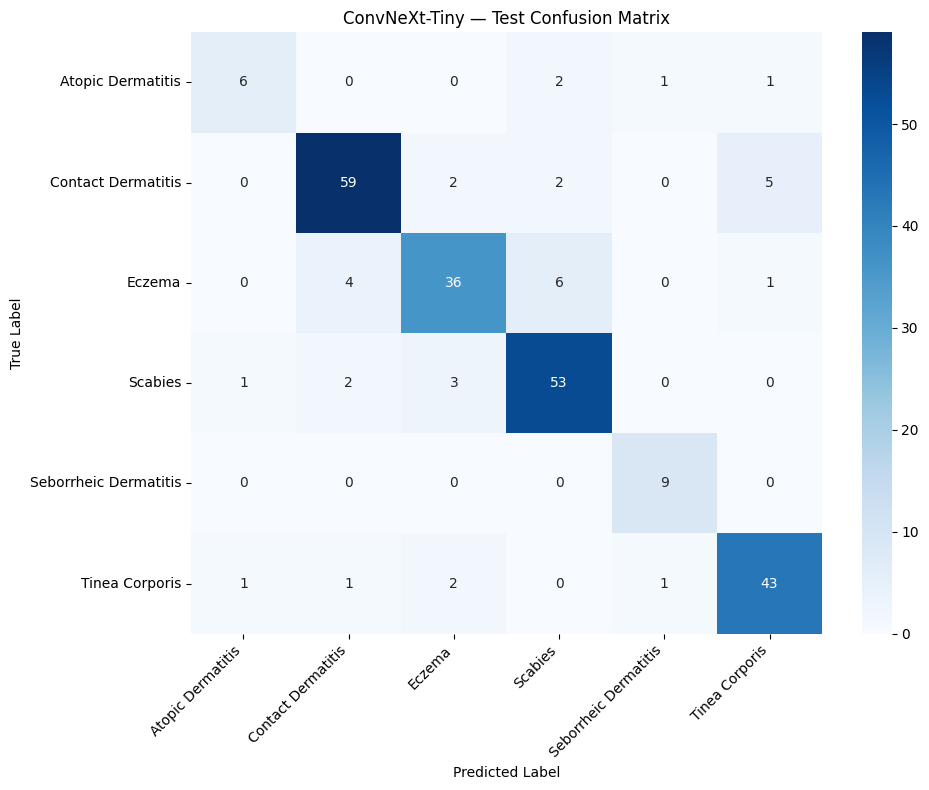

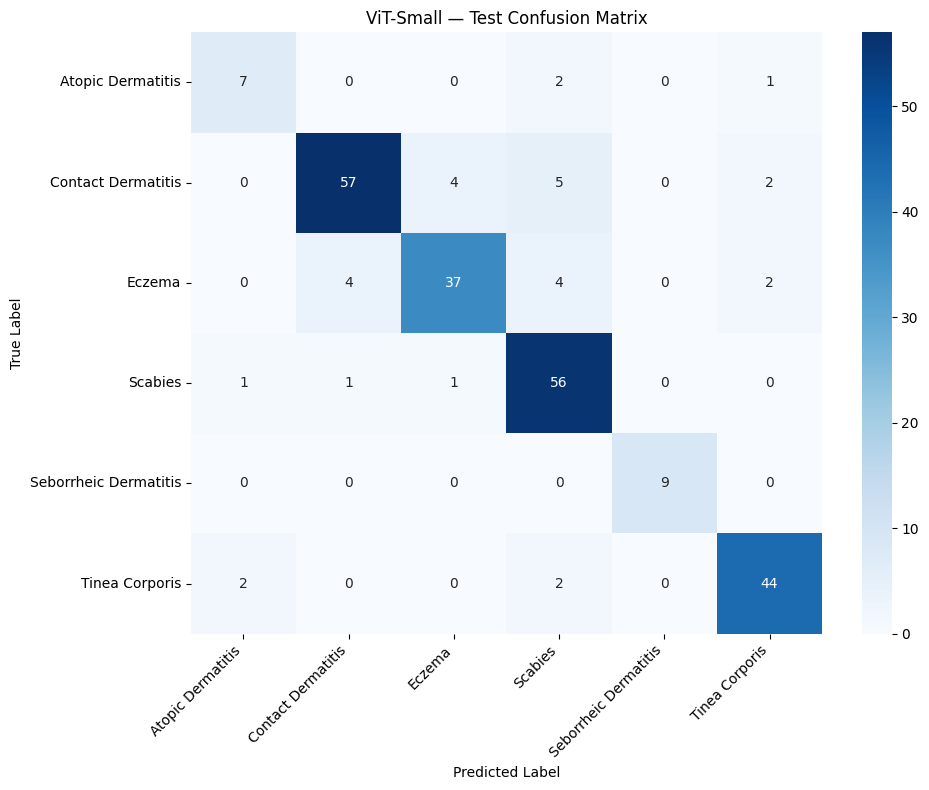

✓ Confusion matrix plots saved.
✓ Evaluation summary saved:
/kaggle/working/skindisnet_final_manifest/evaluation_results/cell_9A_evaluation_summary.json

FINAL BEST MODEL TEST EVALUATION STATUS
✓ Test dataset validation       : PASS
✓ Test original-only policy    : PASS
✓ ConvNeXt best checkpoint     : LOADED
✓ ViT best checkpoint          : LOADED
✓ Test inference               : PASS
✓ Accuracy calculation         : PASS
✓ Macro Precision              : PASS
✓ Macro Recall                 : PASS
✓ Macro F1                     : PASS
✓ Per-class metrics            : PASS
✓ Confusion matrix             : PASS
✓ Prediction export            : PASS
✓ Evaluation summary           : PASS

✓✓✓ CELL 9A — TEST EVALUATION COMPLETED ✓✓✓

Test set digunakan:
  • Original images only
  • No augmentation
  • No training
  • No parameter update

NEXT:
Cell 9B — Confusion Matrix & Per-Class Error Analysis


In [ ]:
import os
import json
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

print("=" * 70)
print("CELL 9A — BEST MODEL EVALUATION ON TEST SET")
print("=" * 70)


# ================================================================
# 0. CONFIGURATION
# ================================================================

SEED = 42
NUM_CLASSES = 6
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MANIFEST_DIR = "/kaggle/working/skindisnet_final_manifest"
CHECKPOINT_DIR = os.path.join(MANIFEST_DIR, "checkpoints")
RESULT_DIR = os.path.join(MANIFEST_DIR, "evaluation_results")

os.makedirs(RESULT_DIR, exist_ok=True)

CLASS_NAMES = [
    "Atopic Dermatitis",
    "Contact Dermatitis",
    "Eczema",
    "Scabies",
    "Seborrheic Dermatitis",
    "Tinea Corporis"
]

CLASS_TO_INDEX = {
    name: idx for idx, name in enumerate(CLASS_NAMES)
}

print("\n" + "=" * 70)
print("1. ENVIRONMENT CHECK")
print("=" * 70)

print(f"Device : {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print("✓ CUDA tersedia.")
else:
    print("⚠ CUDA tidak tersedia. Evaluasi menggunakan CPU.")


# ================================================================
# 2. TEST DATASET VALIDATION
# ================================================================

print("\n" + "=" * 70)
print("2. TEST DATASET VALIDATION")
print("=" * 70)

required_objects = [
    "test_df",
    "test_dataset",
    "test_loader"
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        f"Object berikut belum tersedia: {missing_objects}. "
        "Pastikan Cell 6D dan Cell 8A sudah dijalankan."
    )

print(f"✓ test_df        : {len(test_df):,} rows")
print(f"✓ test_dataset   : {len(test_dataset):,}")
print(f"✓ test_loader    : {len(test_loader):,} batches")


# ================================================================
# 3. TEST MANIFEST POLICY CHECK
# ================================================================

print("\n" + "=" * 70)
print("3. TEST MANIFEST POLICY CHECK")
print("=" * 70)

# Split harus TEST
if "split" in test_df.columns:
    unique_splits = test_df["split"].dropna().unique().tolist()
else:
    unique_splits = []

print(f"Test split values : {unique_splits}")

if set(unique_splits) != {"test"}:
    raise RuntimeError(
        f"Test dataframe tidak konsisten. "
        f"Expected {{'test'}}, ditemukan {unique_splits}"
    )

# Tidak boleh ada augmentation
if "data_type" in test_df.columns:

    test_augmented = (
        test_df["data_type"]
        .astype(str)
        .str.lower()
        .eq("augmented")
        .sum()
    )

    print(f"Test augmented : {test_augmented}")

    if test_augmented != 0:
        raise RuntimeError(
            "TEST SET mengandung augmented images. "
            "Evaluasi dibatalkan untuk mencegah contamination."
        )

    print("✓ Test hanya ORIGINAL image.")

else:
    print(
        "⚠ Kolom data_type tidak tersedia. "
        "Validasi augmentation dilewati."
    )


# ================================================================
# 4. TEST PATIENT / IMAGE SUMMARY
# ================================================================

print("\n" + "=" * 70)
print("4. TEST DATASET SUMMARY")
print("=" * 70)

if "Patient_id" in test_df.columns:
    test_patients = test_df["Patient_id"].nunique()
else:
    test_patients = "N/A"

if "canonical_image_id" in test_df.columns:
    test_canonical = test_df["canonical_image_id"].nunique()
else:
    test_canonical = "N/A"

print(f"Test images       : {len(test_df):,}")
print(f"Test patients     : {test_patients}")
print(f"Unique canonical  : {test_canonical}")

if len(test_df) != 241:
    print(
        f"⚠ Warning: expected 241 test images berdasarkan "
        f"final manifest, tetapi ditemukan {len(test_df)}."
    )
else:
    print("✓ Test set = 241 images sesuai final manifest.")


# ================================================================
# 5. TEST CLASS DISTRIBUTION
# ================================================================

print("\n" + "=" * 70)
print("5. TEST CLASS DISTRIBUTION")
print("=" * 70)

test_distribution = (
    test_df["Diagnosis"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
)

test_distribution_df = pd.DataFrame({
    "Diagnosis": CLASS_NAMES,
    "Test_Images": test_distribution.values
})

test_distribution_df["Percentage"] = (
    test_distribution_df["Test_Images"]
    / test_distribution_df["Test_Images"].sum()
    * 100
)

print(test_distribution_df.to_string(index=False))

if (test_distribution_df["Test_Images"] == 0).any():
    print(
        "⚠ Warning: terdapat class tanpa sample pada test set."
    )
else:
    print("✓ Semua 6 class memiliki sample test.")


# ================================================================
# 6. CHECK BEST CHECKPOINTS
# ================================================================

print("\n" + "=" * 70)
print("6. BEST CHECKPOINT VALIDATION")
print("=" * 70)

if not os.path.exists(CHECKPOINT_DIR):
    raise RuntimeError(
        f"Checkpoint directory tidak ditemukan:\n{CHECKPOINT_DIR}"
    )

checkpoint_files = sorted(
    os.listdir(CHECKPOINT_DIR)
)

print("Checkpoint files:")
for file in checkpoint_files:
    print(f"  - {file}")

# ------------------------------------------------
# Mencari checkpoint berdasarkan pola umum
# ------------------------------------------------

def find_best_checkpoint(model_name):
    """
    Mencari checkpoint terbaik berdasarkan nama file.
    """

    patterns = [
        f"{model_name}_best.pth",
        f"{model_name}_best.pt",
        f"best_{model_name}.pth",
        f"best_{model_name}.pt",
        f"{model_name}_best_model.pth",
        f"{model_name}_best_model.pt",
    ]

    for pattern in patterns:
        path = os.path.join(CHECKPOINT_DIR, pattern)
        if os.path.exists(path):
            return path

    # fallback: cari file yang mengandung model + best
    candidates = [
        f for f in checkpoint_files
        if model_name.lower() in f.lower()
        and "best" in f.lower()
        and f.lower().endswith((".pth", ".pt"))
    ]

    if len(candidates) == 1:
        return os.path.join(CHECKPOINT_DIR, candidates[0])

    return None


convnext_checkpoint = find_best_checkpoint("convnext")
vit_checkpoint = find_best_checkpoint("vit")

print("\nConvNeXt checkpoint:")
print(convnext_checkpoint)

print("\nViT checkpoint:")
print(vit_checkpoint)


# ================================================================
# 7. CHECKPOINT LOADING FUNCTION
# ================================================================

def load_checkpoint_safely(model, checkpoint_path):
    """
    Load checkpoint dengan dukungan:
    - state_dict langsung
    - dictionary dengan key state_dict
    - dictionary dengan key model_state_dict
    """

    if checkpoint_path is None:
        raise FileNotFoundError(
            "Best checkpoint tidak ditemukan."
        )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE
    )

    if isinstance(checkpoint, dict):

        if "model_state_dict" in checkpoint:
            state_dict = checkpoint["model_state_dict"]

        elif "state_dict" in checkpoint:
            state_dict = checkpoint["state_dict"]

        else:
            # Kemungkinan checkpoint langsung berupa state_dict
            state_dict = checkpoint

    else:
        raise RuntimeError(
            "Format checkpoint tidak dikenali."
        )

    # Handle DataParallel prefix jika ada
    cleaned_state_dict = {}

    for key, value in state_dict.items():

        if key.startswith("module."):
            key = key.replace("module.", "", 1)

        cleaned_state_dict[key] = value

    missing_keys, unexpected_keys = model.load_state_dict(
        cleaned_state_dict,
        strict=False
    )

    return checkpoint, missing_keys, unexpected_keys


# ================================================================
# 8. LOAD BEST CONVNEXT MODEL
# ================================================================

print("\n" + "=" * 70)
print("7. LOAD BEST CONVNEXT-TINY CHECKPOINT")
print("=" * 70)

if convnext_checkpoint is None:

    raise FileNotFoundError(
        "Best ConvNeXt checkpoint tidak ditemukan.\n\n"
        f"Isi directory:\n{CHECKPOINT_DIR}\n\n"
        "Periksa nama checkpoint yang dibuat Cell 8B."
    )

print(f"Loading:\n{convnext_checkpoint}")

convnext_checkpoint_data, convnext_missing, convnext_unexpected = \
    load_checkpoint_safely(
        convnext_tiny_model,
        convnext_checkpoint
    )

print("✓ ConvNeXt-Tiny best checkpoint berhasil dimuat.")

if convnext_missing:
    print(f"⚠ Missing keys: {len(convnext_missing)}")

if convnext_unexpected:
    print(f"⚠ Unexpected keys: {len(convnext_unexpected)}")


# ================================================================
# 9. LOAD BEST VIT MODEL
# ================================================================

print("\n" + "=" * 70)
print("8. LOAD BEST VIT-SMALL CHECKPOINT")
print("=" * 70)

if vit_checkpoint is None:

    raise FileNotFoundError(
        "Best ViT checkpoint tidak ditemukan.\n\n"
        f"Isi directory:\n{CHECKPOINT_DIR}\n\n"
        "Periksa nama checkpoint yang dibuat Cell 8C."
    )

print(f"Loading:\n{vit_checkpoint}")

vit_checkpoint_data, vit_missing, vit_unexpected = \
    load_checkpoint_safely(
        vit_small_model,
        vit_checkpoint
    )

print("✓ ViT-Small best checkpoint berhasil dimuat.")

if vit_missing:
    print(f"⚠ Missing keys: {len(vit_missing)}")

if vit_unexpected:
    print(f"⚠ Unexpected keys: {len(vit_unexpected)}")


# ================================================================
# 10. BEST CHECKPOINT INFORMATION
# ================================================================

print("\n" + "=" * 70)
print("9. BEST CHECKPOINT INFORMATION")
print("=" * 70)

def extract_checkpoint_info(checkpoint):

    if not isinstance(checkpoint, dict):
        return {}

    info = {}

    possible_keys = [
        "epoch",
        "best_epoch",
        "val_loss",
        "val_accuracy",
        "val_macro_f1",
        "best_val_f1",
        "best_val_macro_f1"
    ]

    for key in possible_keys:

        if key in checkpoint:
            info[key] = checkpoint[key]

    return info


convnext_info = extract_checkpoint_info(
    convnext_checkpoint_data
)

vit_info = extract_checkpoint_info(
    vit_checkpoint_data
)

print("ConvNeXt checkpoint metadata:")
print(convnext_info)

print("\nViT checkpoint metadata:")
print(vit_info)


# ================================================================
# 11. MODEL EVALUATION FUNCTION
# ================================================================

def evaluate_model(
    model,
    loader,
    model_name
):

    print("\n" + "=" * 70)
    print(f"EVALUATING {model_name}")
    print("=" * 70)

    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    inference_start = time.time()

    with torch.no_grad():

        for images, labels in tqdm(
            loader,
            desc=f"Testing {model_name}",
            leave=False
        ):

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            outputs = model(images)

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    inference_time = time.time() - inference_start

    y_true = np.asarray(all_labels)
    y_pred = np.asarray(all_predictions)
    y_prob = np.asarray(all_probabilities)

    # ------------------------------------------------
    # Metrics
    # ------------------------------------------------

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision_macro = precision_score(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        average="macro",
        zero_division=0
    )

    recall_macro = recall_score(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        average="macro",
        zero_division=0
    )

    precision_weighted = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall_weighted = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # ------------------------------------------------
    # Per-class metrics
    # ------------------------------------------------

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

    per_class_rows = []

    for idx, class_name in enumerate(CLASS_NAMES):

        metrics = report_dict[class_name]

        per_class_rows.append({
            "Class_Index": idx,
            "Diagnosis": class_name,
            "Precision": metrics["precision"],
            "Recall": metrics["recall"],
            "F1": metrics["f1-score"],
            "Support": metrics["support"]
        })

    per_class_df = pd.DataFrame(
        per_class_rows
    )

    # ------------------------------------------------
    # Confusion Matrix
    # ------------------------------------------------

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES)
    )

    # ------------------------------------------------
    # Numerical sanity
    # ------------------------------------------------

    numerical_ok = (
        np.isfinite(y_prob).all()
        and np.isfinite(y_pred).all()
    )

    if not numerical_ok:
        raise RuntimeError(
            f"{model_name}: ditemukan NaN / Inf pada output."
        )

    # ------------------------------------------------
    # Results
    # ------------------------------------------------

    results = {
        "Model": model_name,
        "Test_Images": len(y_true),
        "Accuracy": accuracy,
        "Macro_Precision": precision_macro,
        "Macro_Recall": recall_macro,
        "Macro_F1": f1_macro,
        "Weighted_Precision": precision_weighted,
        "Weighted_Recall": recall_weighted,
        "Weighted_F1": f1_weighted,
        "Inference_Time_Seconds": inference_time
    }

    return {
        "results": results,
        "per_class": per_class_df,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }


# ================================================================
# 12. EVALUATE CONVNEXT-TINY
# ================================================================

convnext_results = evaluate_model(
    convnext_tiny_model,
    test_loader,
    "ConvNeXt-Tiny"
)

print("\nConvNeXt-Tiny Test Results:")

for key, value in convnext_results["results"].items():

    if isinstance(value, float):
        print(f"{key:<25}: {value:.4f}")
    else:
        print(f"{key:<25}: {value}")


# ================================================================
# 13. EVALUATE VIT-SMALL
# ================================================================

vit_results = evaluate_model(
    vit_small_model,
    test_loader,
    "ViT-Small"
)

print("\nViT-Small Test Results:")

for key, value in vit_results["results"].items():

    if isinstance(value, float):
        print(f"{key:<25}: {value:.4f}")
    else:
        print(f"{key:<25}: {value}")


# ================================================================
# 14. PER-CLASS RESULTS
# ================================================================

print("\n" + "=" * 70)
print("10. PER-CLASS PERFORMANCE")
print("=" * 70)

print("\nCONVNEXT-TINY")
print(
    convnext_results["per_class"]
    .to_string(index=False)
)

print("\nVIT-SMALL")
print(
    vit_results["per_class"]
    .to_string(index=False)
)


# ================================================================
# 15. MODEL COMPARISON
# ================================================================

print("\n" + "=" * 70)
print("11. MODEL COMPARISON")
print("=" * 70)

comparison_df = pd.DataFrame([
    convnext_results["results"],
    vit_results["results"]
])

comparison_display = comparison_df[
    [
        "Model",
        "Accuracy",
        "Macro_Precision",
        "Macro_Recall",
        "Macro_F1",
        "Weighted_F1",
        "Inference_Time_Seconds"
    ]
].copy()

print(
    comparison_display.to_string(index=False)
)


# ================================================================
# 16. DETERMINE BEST MODEL
# ================================================================

best_idx = comparison_df[
    "Macro_F1"
].idxmax()

best_model_name = comparison_df.loc[
    best_idx,
    "Model"
]

best_macro_f1 = comparison_df.loc[
    best_idx,
    "Macro_F1"
]

print("\nBest model berdasarkan Test Macro F1:")
print(f"✓ {best_model_name}")
print(f"✓ Macro F1 : {best_macro_f1:.4f}")


# ================================================================
# 17. SAVE METRICS
# ================================================================

print("\n" + "=" * 70)
print("12. SAVE EVALUATION RESULTS")
print("=" * 70)

comparison_path = os.path.join(
    RESULT_DIR,
    "test_model_comparison.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

print(f"✓ Model comparison saved:\n{comparison_path}")


convnext_per_class_path = os.path.join(
    RESULT_DIR,
    "convnext_test_per_class.csv"
)

convnext_results["per_class"].to_csv(
    convnext_per_class_path,
    index=False
)

print(
    f"✓ ConvNeXt per-class results saved:\n"
    f"{convnext_per_class_path}"
)


vit_per_class_path = os.path.join(
    RESULT_DIR,
    "vit_test_per_class.csv"
)

vit_results["per_class"].to_csv(
    vit_per_class_path,
    index=False
)

print(
    f"✓ ViT per-class results saved:\n"
    f"{vit_per_class_path}"
)


# ================================================================
# 18. SAVE CONFUSION MATRICES
# ================================================================

convnext_cm_path = os.path.join(
    RESULT_DIR,
    "convnext_confusion_matrix.csv"
)

pd.DataFrame(
    convnext_results["confusion_matrix"],
    index=CLASS_NAMES,
    columns=CLASS_NAMES
).to_csv(
    convnext_cm_path
)

vit_cm_path = os.path.join(
    RESULT_DIR,
    "vit_confusion_matrix.csv"
)

pd.DataFrame(
    vit_results["confusion_matrix"],
    index=CLASS_NAMES,
    columns=CLASS_NAMES
).to_csv(
    vit_cm_path
)

print("✓ Confusion matrices saved.")


# ================================================================
# 19. SAVE PREDICTIONS
# ================================================================

def save_predictions(
    results,
    dataframe,
    filename
):

    pred_df = dataframe.reset_index(
        drop=True
    ).copy()

    pred_df["True_Index"] = results["y_true"]

    pred_df["Predicted_Index"] = results["y_pred"]

    pred_df["True_Diagnosis"] = [
        CLASS_NAMES[i]
        for i in results["y_true"]
    ]

    pred_df["Predicted_Diagnosis"] = [
        CLASS_NAMES[i]
        for i in results["y_pred"]
    ]

    pred_df["Correct"] = (
        pred_df["True_Index"]
        == pred_df["Predicted_Index"]
    )

    # confidence
    pred_df["Prediction_Confidence"] = (
        results["y_prob"].max(axis=1)
    )

    output_path = os.path.join(
        RESULT_DIR,
        filename
    )

    pred_df.to_csv(
        output_path,
        index=False
    )

    return output_path


convnext_prediction_path = save_predictions(
    convnext_results,
    test_df,
    "convnext_test_predictions.csv"
)

vit_prediction_path = save_predictions(
    vit_results,
    test_df,
    "vit_test_predictions.csv"
)

print(
    f"✓ ConvNeXt predictions saved:\n"
    f"{convnext_prediction_path}"
)

print(
    f"✓ ViT predictions saved:\n"
    f"{vit_prediction_path}"
)


# ================================================================
# 20. CONFUSION MATRIX VISUALIZATION
# ================================================================

def plot_confusion_matrix(
    cm,
    model_name,
    filename
):

    plt.figure(
        figsize=(10, 8)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cmap="Blues"
    )

    plt.title(
        f"{model_name} — Test Confusion Matrix"
    )

    plt.xlabel(
        "Predicted Label"
    )

    plt.ylabel(
        "True Label"
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.yticks(
        rotation=0
    )

    plt.tight_layout()

    path = os.path.join(
        RESULT_DIR,
        filename
    )

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return path


convnext_cm_plot = plot_confusion_matrix(
    convnext_results["confusion_matrix"],
    "ConvNeXt-Tiny",
    "convnext_confusion_matrix.png"
)

vit_cm_plot = plot_confusion_matrix(
    vit_results["confusion_matrix"],
    "ViT-Small",
    "vit_confusion_matrix.png"
)

print("✓ Confusion matrix plots saved.")


# ================================================================
# 21. SAVE EVALUATION SUMMARY
# ================================================================

evaluation_summary = {
    "cell": "9A",
    "evaluation_type": "best_model_test_evaluation",

    "test_policy": {
        "split": "test",
        "original_only": True,
        "augmentation": False,
        "test_images": int(len(test_df))
    },

    "models": {
        "ConvNeXt-Tiny": {
            "checkpoint": convnext_checkpoint,
            "metrics": convnext_results["results"]
        },

        "ViT-Small": {
            "checkpoint": vit_checkpoint,
            "metrics": vit_results["results"]
        }
    },

    "best_model_by_test_macro_f1": best_model_name,

    "reproducibility": {
        "seed": SEED,
        "input_size": "224x224",
        "num_classes": NUM_CLASSES
    }
}

summary_path = os.path.join(
    RESULT_DIR,
    "cell_9A_evaluation_summary.json"
)

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        evaluation_summary,
        f,
        indent=4,
        default=float
    )

print(
    f"✓ Evaluation summary saved:\n"
    f"{summary_path}"
)


# ================================================================
# 22. FINAL STATUS
# ================================================================

print("\n" + "=" * 70)
print("FINAL BEST MODEL TEST EVALUATION STATUS")
print("=" * 70)

print("✓ Test dataset validation       : PASS")
print("✓ Test original-only policy    : PASS")
print("✓ ConvNeXt best checkpoint     : LOADED")
print("✓ ViT best checkpoint          : LOADED")
print("✓ Test inference               : PASS")
print("✓ Accuracy calculation         : PASS")
print("✓ Macro Precision              : PASS")
print("✓ Macro Recall                 : PASS")
print("✓ Macro F1                     : PASS")
print("✓ Per-class metrics            : PASS")
print("✓ Confusion matrix             : PASS")
print("✓ Prediction export            : PASS")
print("✓ Evaluation summary           : PASS")

print("\n" + "=" * 70)
print("✓✓✓ CELL 9A — TEST EVALUATION COMPLETED ✓✓✓")
print("=" * 70)

print("\nTest set digunakan:")
print("  • Original images only")
print("  • No augmentation")
print("  • No training")
print("  • No parameter update")

print("\nNEXT:")
print("Cell 9B — Confusion Matrix & Per-Class Error Analysis")

# CELL 9B — CONFUSION MATRIX & PER-CLASS ERROR ANALYSIS

CELL 9B — CONFUSION MATRIX & PER-CLASS ERROR ANALYSIS

0. CONFIGURATION
Device        : cuda
Number classes: 6
Classes       : ['Atopic Dermatitis', 'Contact Dermatitis', 'Eczema', 'Scabies', 'Seborrheic Dermatitis', 'Tinea Corporis']
Checkpoint dir: /kaggle/working/skindisnet_final_manifest/checkpoints
Analysis dir  : /kaggle/working/skindisnet_final_manifest/confusion_matrix_analysis

1. TEST DATASET VALIDATION
✓ test_df       : 241 rows
✓ test_dataset  : 241
✓ test_loader   : 8 batches

2. TEST MANIFEST POLICY VALIDATION
Test split values : ['test']
Test augmented : 0
✓ Test set policy valid.

3. CHECK BEST CHECKPOINTS
ConvNeXt checkpoint : FOUND
ViT checkpoint      : FOUND
✓ Kedua best checkpoint tersedia.

4. LOAD BEST CHECKPOINTS
✓ ConvNeXt-Tiny best checkpoint loaded.
✓ ViT-Small best checkpoint loaded.

5. BEST CHECKPOINT INFORMATION
ConvNeXt checkpoint info:
{'epoch': 11, 'best_val_macro_f1': 0.8289595240292692}

ViT checkpoint info:
{'epoch': 16, 'best_val_macro_f1': 0.837350

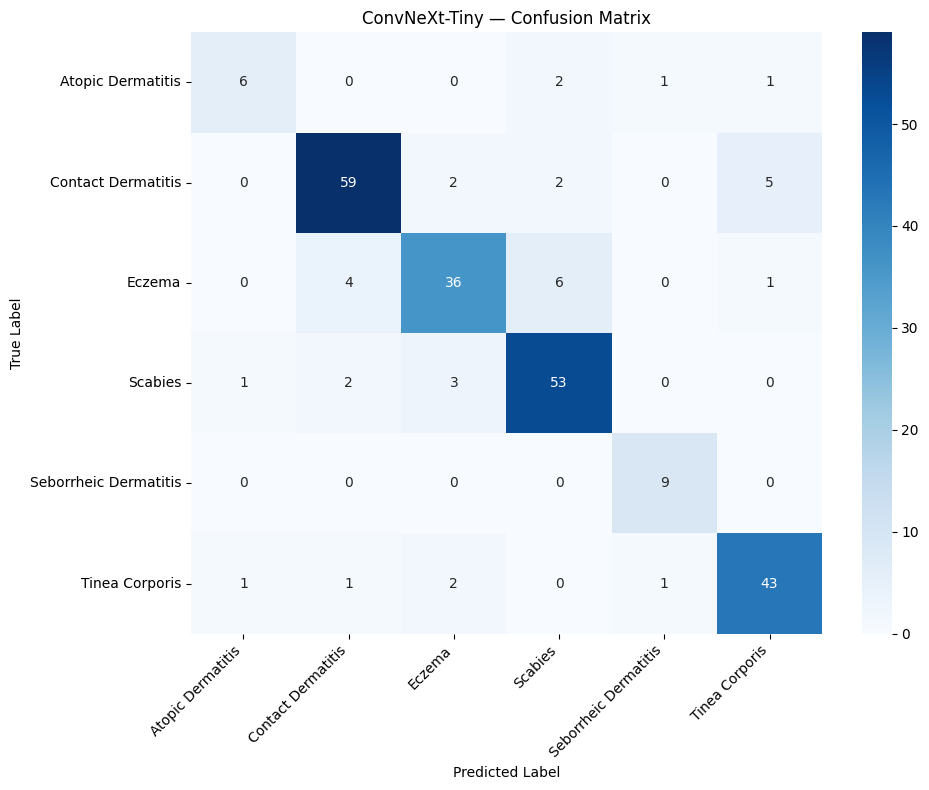

✓ Saved:
/kaggle/working/skindisnet_final_manifest/confusion_matrix_analysis/convnext_tiny_confusion_matrix.png

13. SAVING VIT CONFUSION MATRIX


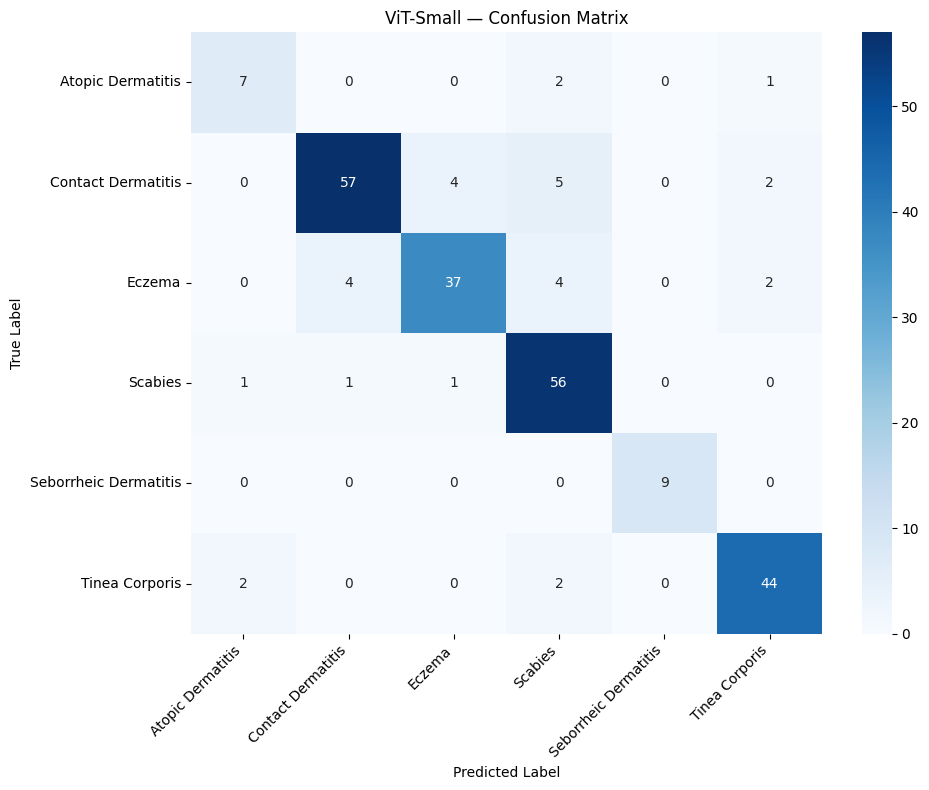

✓ Saved:
/kaggle/working/skindisnet_final_manifest/confusion_matrix_analysis/vit_small_confusion_matrix.png

14. SAVING NORMALIZED CONFUSION MATRICES


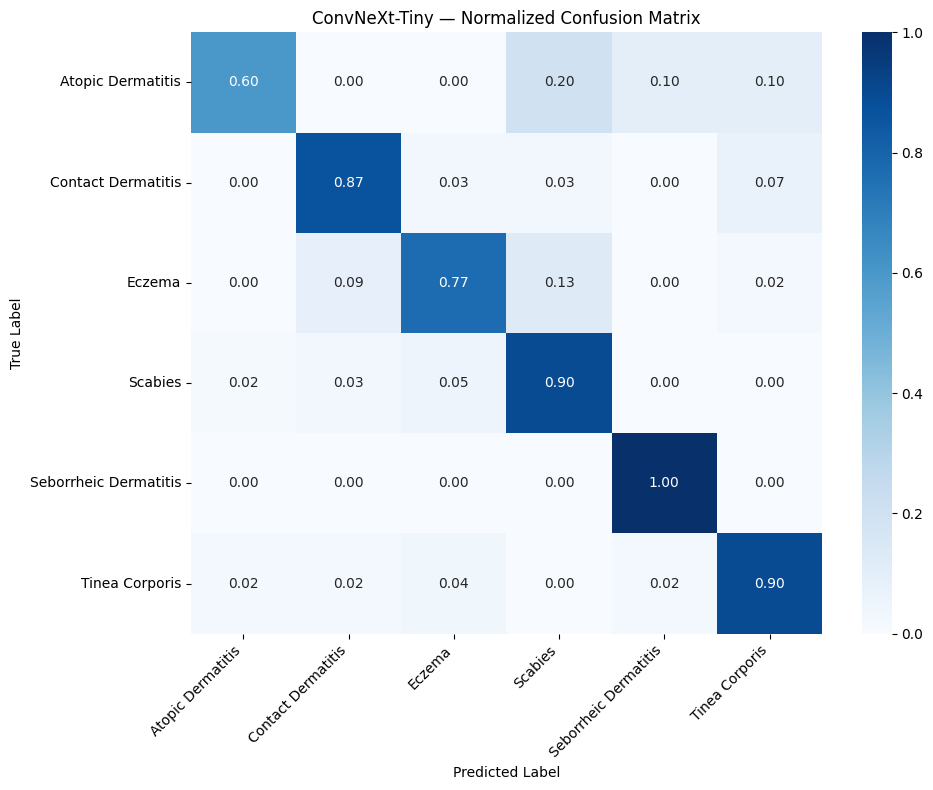

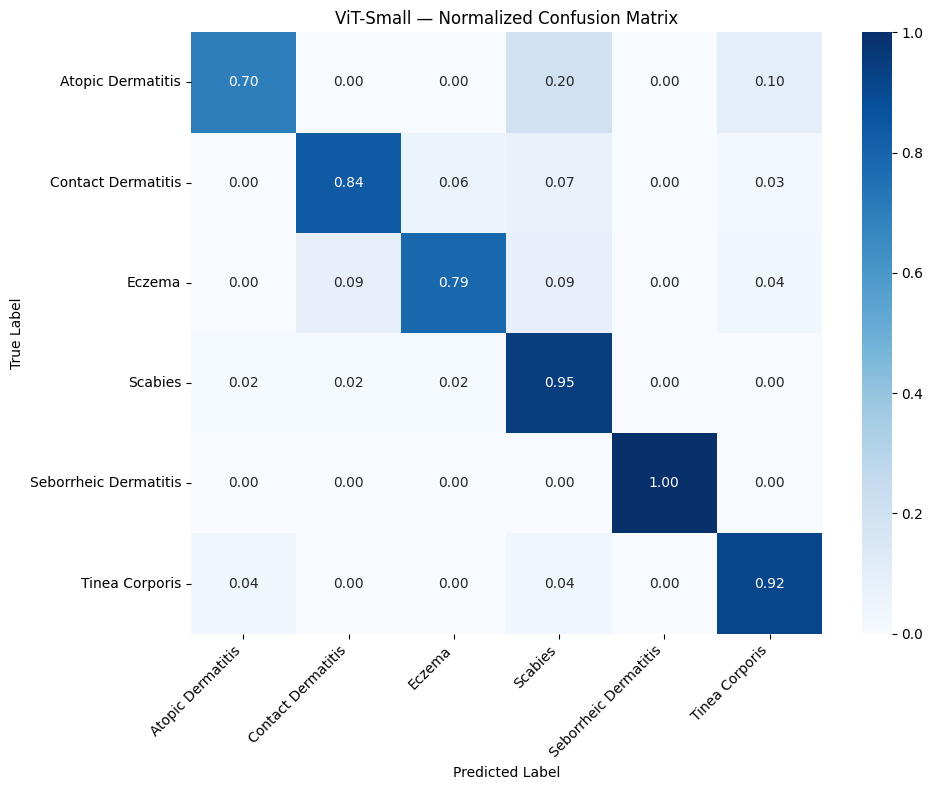

✓ Normalized confusion matrices saved.

15. PER-CLASS ERROR ANALYSIS

CONVNEXT-TINY


,Class_Index,Diagnosis,TP,FP,FN,Support,Correct,Errors,Error_Rate,Precision,Recall,F1
0,0,Atopic Dermatitis,6,2,4,10,6,4,0.400000,0.750000,0.600000,0.666667
1,1,Contact Dermatitis,59,7,9,68,59,9,0.132353,0.893939,0.867647,0.880597
2,2,Eczema,36,7,11,47,36,11,0.234043,0.837209,0.765957,0.800000
3,3,Scabies,53,10,6,59,53,6,0.101695,0.841270,0.898305,0.868852
4,4,Seborrheic Dermatitis,9,2,0,9,9,0,0.000000,0.818182,1.000000,0.900000
5,5,Tinea Corporis,43,7,5,48,43,5,0.104167,0.860000,0.895833,0.877551



VIT-SMALL


,Class_Index,Diagnosis,TP,FP,FN,Support,Correct,Errors,Error_Rate,Precision,Recall,F1
0,0,Atopic Dermatitis,7,3,3,10,7,3,0.300000,0.700000,0.700000,0.700000
1,1,Contact Dermatitis,57,5,11,68,57,11,0.161765,0.919355,0.838235,0.876923
2,2,Eczema,37,5,10,47,37,10,0.212766,0.880952,0.787234,0.831461
3,3,Scabies,56,13,3,59,56,3,0.050847,0.811594,0.949153,0.875000
4,4,Seborrheic Dermatitis,9,0,0,9,9,0,0.000000,1.000000,1.000000,1.000000
5,5,Tinea Corporis,44,5,4,48,44,4,0.083333,0.897959,0.916667,0.907216



16. TOP MISCLASSIFICATION PAIRS

CONVNEXT-TINY


...


18. MODEL-TO-MODEL PER-CLASS COMPARISON


,Diagnosis,ConvNeXt_Precision,ViT_Precision,ConvNeXt_Recall,ViT_Recall,ConvNeXt_F1,ViT_F1,ConvNeXt_Errors,ViT_Errors,F1_Difference_ViT_minus_ConvNeXt,Better_Model
0,Atopic Dermatitis,0.750000,0.700000,0.600000,0.700000,0.666667,0.700000,4,3,0.033333,ViT-Small
1,Contact Dermatitis,0.893939,0.919355,0.867647,0.838235,0.880597,0.876923,9,11,-0.003674,ConvNeXt-Tiny
2,Eczema,0.837209,0.880952,0.765957,0.787234,0.800000,0.831461,11,10,0.031461,ViT-Small
3,Scabies,0.841270,0.811594,0.898305,0.949153,0.868852,0.875000,6,3,0.006148,ViT-Small
4,Seborrheic Dermatitis,0.818182,1.000000,1.000000,1.000000,0.900000,1.000000,0,0,0.100000,ViT-Small
5,Tinea Corporis,0.860000,0.897959,0.895833,0.916667,0.877551,0.907216,5,4,0.029665,ViT-Small



19. OVERALL ERROR SUMMARY


,Model,Test_Images,Correct,Errors,Error_Rate,Inference_Time_Seconds
0,ConvNeXt-Tiny,241,206,35,0.145228,2.670537
1,ViT-Small,241,210,31,0.128631,2.754630



20. SAVING ANALYSIS FILES
✓ Confusion matrix CSV saved.
✓ Normalized confusion matrix CSV saved.
✓ Per-class error analysis saved.
✓ Misclassification pair analysis saved.
✓ Model comparison saved.
✓ Overall error summary saved.

21. SAVING JSON SUMMARY
✓ Summary saved:
/kaggle/working/skindisnet_final_manifest/confusion_matrix_analysis/confusion_matrix_analysis_summary.json

22. FINAL CONFUSION MATRIX SANITY CHECK
ConvNeXt total samples : 241
ViT total samples      : 241
ConvNeXt correct       : 206
ViT correct            : 210
✓ Confusion matrix total valid.
✓ Prediction range valid.
✓ Error calculation valid.

FINAL CONFUSION MATRIX & ERROR ANALYSIS STATUS
✓ Test dataset validation          : PASS
✓ Test original-only policy        : PASS
✓ ConvNeXt best checkpoint         : PASS
✓ ViT best checkpoint              : PASS
✓ ConvNeXt test prediction         : PASS
✓ ViT test prediction              : PASS
✓ Label consistency                : PASS
✓ Confusion matrix                 : 

In [ ]:
import os
import json
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support
)

# ----------------------------------------------------------------------
# OPTIONAL: seaborn hanya digunakan untuk visualisasi confusion matrix
# ----------------------------------------------------------------------
import seaborn as sns


print("=" * 70)
print("CELL 9B — CONFUSION MATRIX & PER-CLASS ERROR ANALYSIS")
print("=" * 70)


# ======================================================================
# 0. CONFIGURATION
# ======================================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CHECKPOINT_DIR = (
    "/kaggle/working/skindisnet_final_manifest/checkpoints"
)

RESULT_DIR = (
    "/kaggle/working/skindisnet_final_manifest/"
    "training_results"
)

ANALYSIS_DIR = (
    "/kaggle/working/skindisnet_final_manifest/"
    "confusion_matrix_analysis"
)

os.makedirs(ANALYSIS_DIR, exist_ok=True)


CLASS_NAMES = [
    "Atopic Dermatitis",
    "Contact Dermatitis",
    "Eczema",
    "Scabies",
    "Seborrheic Dermatitis",
    "Tinea Corporis"
]

NUM_CLASSES = len(CLASS_NAMES)


print()
print("=" * 70)
print("0. CONFIGURATION")
print("=" * 70)

print(f"Device        : {DEVICE}")
print(f"Number classes: {NUM_CLASSES}")
print(f"Classes       : {CLASS_NAMES}")
print(f"Checkpoint dir: {CHECKPOINT_DIR}")
print(f"Analysis dir  : {ANALYSIS_DIR}")


# ======================================================================
# 1. TEST DATASET VALIDATION
# ======================================================================

print()
print("=" * 70)
print("1. TEST DATASET VALIDATION")
print("=" * 70)

required_test_objects = [
    "test_df",
    "test_dataset",
    "test_loader"
]

missing_objects = [
    name for name in required_test_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        f"Object berikut belum tersedia: {missing_objects}. "
        "Pastikan Cell 6D dan Cell 9A sudah dijalankan."
    )

print(f"✓ test_df       : {len(test_df):,} rows")
print(f"✓ test_dataset  : {len(test_dataset):,}")
print(f"✓ test_loader   : {len(test_loader):,} batches")


# ======================================================================
# 2. TEST MANIFEST POLICY VALIDATION
# ======================================================================

print()
print("=" * 70)
print("2. TEST MANIFEST POLICY VALIDATION")
print("=" * 70)

if "split" in test_df.columns:

    test_split_values = test_df["split"].dropna().unique().tolist()

    print(f"Test split values : {test_split_values}")

    if set(test_split_values) != {"test"}:
        raise RuntimeError(
            "test_df mengandung split selain 'test'."
        )

else:

    # fallback jika nama kolom yang digunakan adalah split_final
    if "split_final" in test_df.columns:

        test_split_values = (
            test_df["split_final"]
            .dropna()
            .unique()
            .tolist()
        )

        print(f"Test split values : {test_split_values}")

        if set(test_split_values) != {"test"}:
            raise RuntimeError(
                "test_df mengandung split selain 'test'."
            )

    else:

        raise RuntimeError(
            "Kolom split/split_final tidak ditemukan pada test_df."
        )


# ----------------------------------------------------------------------
# Check augmentation
# ----------------------------------------------------------------------

if "data_type" in test_df.columns:

    test_augmented = (
        test_df["data_type"]
        .astype(str)
        .str.lower()
        .eq("augmented")
        .sum()
    )

    print(f"Test augmented : {test_augmented}")

    if test_augmented != 0:
        raise RuntimeError(
            "Test set mengandung augmented image. "
            "Evaluasi harus menggunakan original image saja."
        )

elif "is_augmented" in test_df.columns:

    test_augmented = test_df["is_augmented"].astype(bool).sum()

    print(f"Test augmented : {test_augmented}")

    if test_augmented != 0:
        raise RuntimeError(
            "Test set mengandung augmented image."
        )

print("✓ Test set policy valid.")


# ======================================================================
# 3. CHECK CHECKPOINTS
# ======================================================================

print()
print("=" * 70)
print("3. CHECK BEST CHECKPOINTS")
print("=" * 70)

convnext_checkpoint = os.path.join(
    CHECKPOINT_DIR,
    "convnext_tiny_best.pth"
)

vit_checkpoint = os.path.join(
    CHECKPOINT_DIR,
    "vit_small_best.pth"
)

print(
    f"ConvNeXt checkpoint : "
    f"{'FOUND' if os.path.exists(convnext_checkpoint) else 'NOT FOUND'}"
)

print(
    f"ViT checkpoint      : "
    f"{'FOUND' if os.path.exists(vit_checkpoint) else 'NOT FOUND'}"
)

if not os.path.exists(convnext_checkpoint):
    raise FileNotFoundError(
        "\nBest ConvNeXt checkpoint tidak ditemukan:\n"
        f"{convnext_checkpoint}\n\n"
        "Pastikan Cell 8B menyimpan "
        "'convnext_tiny_best.pth'."
    )

if not os.path.exists(vit_checkpoint):
    raise FileNotFoundError(
        "\nBest ViT checkpoint tidak ditemukan:\n"
        f"{vit_checkpoint}\n\n"
        "Pastikan Cell 8C menyimpan "
        "'vit_small_best.pth'."
    )

print("✓ Kedua best checkpoint tersedia.")


# ======================================================================
# 4. LOAD BEST CHECKPOINTS
# ======================================================================

print()
print("=" * 70)
print("4. LOAD BEST CHECKPOINTS")
print("=" * 70)


def load_checkpoint_into_model(model, checkpoint_path, device):
    """
    Load checkpoint dengan dukungan terhadap:
    - state_dict langsung
    - checkpoint dictionary
    """

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    if isinstance(checkpoint, dict):

        if "model_state_dict" in checkpoint:

            state_dict = checkpoint["model_state_dict"]

        elif "state_dict" in checkpoint:

            state_dict = checkpoint["state_dict"]

        else:

            # kemungkinan checkpoint berupa state_dict langsung
            state_dict = checkpoint

    else:

        raise RuntimeError(
            f"Format checkpoint tidak dikenali: "
            f"{checkpoint_path}"
        )

    model.load_state_dict(
        state_dict,
        strict=True
    )

    return checkpoint


# ----------------------------------------------------------------------
# ConvNeXt
# ----------------------------------------------------------------------

convnext_checkpoint_data = load_checkpoint_into_model(
    convnext_tiny_model,
    convnext_checkpoint,
    DEVICE
)

print("✓ ConvNeXt-Tiny best checkpoint loaded.")


# ----------------------------------------------------------------------
# ViT
# ----------------------------------------------------------------------

vit_checkpoint_data = load_checkpoint_into_model(
    vit_small_model,
    vit_checkpoint,
    DEVICE
)

print("✓ ViT-Small best checkpoint loaded.")


# ======================================================================
# 5. EXTRACT BEST EPOCH INFORMATION
# ======================================================================

print()
print("=" * 70)
print("5. BEST CHECKPOINT INFORMATION")
print("=" * 70)


def extract_checkpoint_info(checkpoint):

    if not isinstance(checkpoint, dict):
        return {}

    info = {}

    for key in [
        "epoch",
        "best_epoch",
        "best_val_macro_f1",
        "best_val_f1",
        "model_name",
        "random_seed"
    ]:

        if key in checkpoint:
            value = checkpoint[key]

            if torch.is_tensor(value):
                value = value.item()

            info[key] = value

    return info


convnext_info = extract_checkpoint_info(
    convnext_checkpoint_data
)

vit_info = extract_checkpoint_info(
    vit_checkpoint_data
)


print("ConvNeXt checkpoint info:")
print(convnext_info)

print()

print("ViT checkpoint info:")
print(vit_info)


# ======================================================================
# 6. EVALUATION FUNCTION
# ======================================================================

print()
print("=" * 70)
print("6. PREPARING EVALUATION FUNCTION")
print("=" * 70)


def evaluate_model_for_confusion(
    model,
    loader,
    device
):

    model.eval()

    all_predictions = []
    all_labels = []

    inference_start = time.time()

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    inference_time = time.time() - inference_start

    return (
        np.array(all_labels),
        np.array(all_predictions),
        inference_time
    )


print("✓ Evaluation function siap.")


# ======================================================================
# 7. EVALUATE CONVNEXT-TINY
# ======================================================================

print()
print("=" * 70)
print("7. EVALUATING CONVNEXT-TINY")
print("=" * 70)

convnext_tiny_model = convnext_tiny_model.to(DEVICE)

convnext_labels, convnext_predictions, convnext_time = (
    evaluate_model_for_confusion(
        convnext_tiny_model,
        test_loader,
        DEVICE
    )
)

print(
    f"✓ ConvNeXt predictions : "
    f"{len(convnext_predictions):,}"
)

print(
    f"✓ ConvNeXt inference time : "
    f"{convnext_time:.4f} seconds"
)


# ======================================================================
# 8. EVALUATE VIT-SMALL
# ======================================================================

print()
print("=" * 70)
print("8. EVALUATING VIT-SMALL")
print("=" * 70)

vit_small_model = vit_small_model.to(DEVICE)

vit_labels, vit_predictions, vit_time = (
    evaluate_model_for_confusion(
        vit_small_model,
        test_loader,
        DEVICE
    )
)

print(
    f"✓ ViT predictions : "
    f"{len(vit_predictions):,}"
)

print(
    f"✓ ViT inference time : "
    f"{vit_time:.4f} seconds"
)


# ======================================================================
# 9. LABEL CONSISTENCY CHECK
# ======================================================================

print()
print("=" * 70)
print("9. LABEL CONSISTENCY CHECK")
print("=" * 70)

if not np.array_equal(
    convnext_labels,
    vit_labels
):

    raise RuntimeError(
        "Label sequence ConvNeXt dan ViT berbeda. "
        "Pastikan test_loader menggunakan shuffle=False."
    )

print(
    f"Test labels : {len(convnext_labels):,}"
)

print("✓ Kedua model dievaluasi pada sample test yang sama.")


# ======================================================================
# 10. CONFUSION MATRIX
# ======================================================================

print()
print("=" * 70)
print("10. CONFUSION MATRIX")
print("=" * 70)


convnext_cm = confusion_matrix(
    convnext_labels,
    convnext_predictions,
    labels=list(range(NUM_CLASSES))
)

vit_cm = confusion_matrix(
    vit_labels,
    vit_predictions,
    labels=list(range(NUM_CLASSES))
)


print()
print("CONVNEXT-TINY CONFUSION MATRIX")
print(pd.DataFrame(
    convnext_cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
))


print()
print("VIT-SMALL CONFUSION MATRIX")
print(pd.DataFrame(
    vit_cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
))


# ======================================================================
# 11. NORMALIZED CONFUSION MATRIX
# ======================================================================

print()
print("=" * 70)
print("11. NORMALIZED CONFUSION MATRIX")
print("=" * 70)


def normalize_confusion_matrix(cm):

    row_sums = cm.sum(axis=1, keepdims=True)

    normalized = np.divide(
        cm,
        row_sums,
        out=np.zeros_like(
            cm,
            dtype=float
        ),
        where=row_sums != 0
    )

    return normalized


convnext_cm_normalized = normalize_confusion_matrix(
    convnext_cm
)

vit_cm_normalized = normalize_confusion_matrix(
    vit_cm
)


print("✓ Normalized confusion matrices calculated.")


# ======================================================================
# 12. CONFUSION MATRIX VISUALIZATION — CONVNEXT
# ======================================================================

print()
print("=" * 70)
print("12. SAVING CONVNEXT CONFUSION MATRIX")
print("=" * 70)


plt.figure(figsize=(10, 8))

sns.heatmap(
    convnext_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title(
    "ConvNeXt-Tiny — Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

convnext_cm_path = os.path.join(
    ANALYSIS_DIR,
    "convnext_tiny_confusion_matrix.png"
)

plt.savefig(
    convnext_cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(
    f"✓ Saved:\n{convnext_cm_path}"
)


# ======================================================================
# 13. CONFUSION MATRIX VISUALIZATION — VIT
# ======================================================================

print()
print("=" * 70)
print("13. SAVING VIT CONFUSION MATRIX")
print("=" * 70)


plt.figure(figsize=(10, 8))

sns.heatmap(
    vit_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title(
    "ViT-Small — Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

vit_cm_path = os.path.join(
    ANALYSIS_DIR,
    "vit_small_confusion_matrix.png"
)

plt.savefig(
    vit_cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print(
    f"✓ Saved:\n{vit_cm_path}"
)


# ======================================================================
# 14. NORMALIZED CONFUSION MATRIX VISUALIZATION
# ======================================================================

print()
print("=" * 70)
print("14. SAVING NORMALIZED CONFUSION MATRICES")
print("=" * 70)


# ----------------------------------------------------------------------
# ConvNeXt normalized
# ----------------------------------------------------------------------

plt.figure(figsize=(10, 8))

sns.heatmap(
    convnext_cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title(
    "ConvNeXt-Tiny — Normalized Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

convnext_norm_path = os.path.join(
    ANALYSIS_DIR,
    "convnext_tiny_normalized_confusion_matrix.png"
)

plt.savefig(
    convnext_norm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ----------------------------------------------------------------------
# ViT normalized
# ----------------------------------------------------------------------

plt.figure(figsize=(10, 8))

sns.heatmap(
    vit_cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title(
    "ViT-Small — Normalized Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

vit_norm_path = os.path.join(
    ANALYSIS_DIR,
    "vit_small_normalized_confusion_matrix.png"
)

plt.savefig(
    vit_norm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print("✓ Normalized confusion matrices saved.")


# ======================================================================
# 15. PER-CLASS ERROR ANALYSIS
# ======================================================================

print()
print("=" * 70)
print("15. PER-CLASS ERROR ANALYSIS")
print("=" * 70)


def calculate_per_class_analysis(
    y_true,
    y_pred,
    class_names
):

    precision, recall, f1, support = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=list(range(len(class_names))),
            zero_division=0
        )
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(len(class_names)))
    )

    rows = []

    for i, class_name in enumerate(class_names):

        tp = cm[i, i]

        fn = cm[i, :].sum() - tp

        fp = cm[:, i].sum() - tp

        total = cm[i, :].sum()

        error_count = fn

        error_rate = (
            error_count / total
            if total > 0
            else 0
        )

        rows.append({
            "Class_Index": i,
            "Diagnosis": class_name,
            "TP": int(tp),
            "FP": int(fp),
            "FN": int(fn),
            "Support": int(support[i]),
            "Correct": int(tp),
            "Errors": int(error_count),
            "Error_Rate": float(error_rate),
            "Precision": float(precision[i]),
            "Recall": float(recall[i]),
            "F1": float(f1[i])
        })

    return pd.DataFrame(rows)


convnext_per_class = calculate_per_class_analysis(
    convnext_labels,
    convnext_predictions,
    CLASS_NAMES
)

vit_per_class = calculate_per_class_analysis(
    vit_labels,
    vit_predictions,
    CLASS_NAMES
)


print()
print("CONVNEXT-TINY")

display(
    convnext_per_class
)


print()
print("VIT-SMALL")

display(
    vit_per_class
)


# ======================================================================
# 16. TOP MISCLASSIFICATION PAIRS
# ======================================================================

print()
print("=" * 70)
print("16. TOP MISCLASSIFICATION PAIRS")
print("=" * 70)


def get_misclassification_pairs(
    cm,
    class_names
):

    rows = []

    for true_idx in range(len(class_names)):

        for pred_idx in range(len(class_names)):

            if true_idx == pred_idx:
                continue

            count = int(
                cm[true_idx, pred_idx]
            )

            if count > 0:

                rows.append({
                    "True_Class_Index": true_idx,
                    "True_Class": class_names[true_idx],
                    "Predicted_Class_Index": pred_idx,
                    "Predicted_Class": class_names[pred_idx],
                    "Misclassified_Count": count
                })

    result = pd.DataFrame(rows)

    if len(result) > 0:

        result = result.sort_values(
            "Misclassified_Count",
            ascending=False
        ).reset_index(drop=True)

    return result


convnext_pairs = get_misclassification_pairs(
    convnext_cm,
    CLASS_NAMES
)

vit_pairs = get_misclassification_pairs(
    vit_cm,
    CLASS_NAMES
)


print()
print("CONVNEXT-TINY")

if len(convnext_pairs) > 0:
    display(convnext_pairs)
else:
    print("Tidak ada misclassification.")


print()
print("VIT-SMALL")

if len(vit_pairs) > 0:
    display(vit_pairs)
else:
    print("Tidak ada misclassification.")


# ======================================================================
# 17. WORST PERFORMING CLASSES
# ======================================================================

print()
print("=" * 70)
print("17. WORST PERFORMING CLASSES")
print("=" * 70)


convnext_worst = (
    convnext_per_class
    .sort_values(
        "F1",
        ascending=True
    )
    .reset_index(drop=True)
)

vit_worst = (
    vit_per_class
    .sort_values(
        "F1",
        ascending=True
    )
    .reset_index(drop=True)
)


print()
print("ConvNeXt-Tiny — lowest F1")

display(
    convnext_worst[
        [
            "Diagnosis",
            "Support",
            "Errors",
            "Error_Rate",
            "F1"
        ]
    ]
)


print()
print("ViT-Small — lowest F1")

display(
    vit_worst[
        [
            "Diagnosis",
            "Support",
            "Errors",
            "Error_Rate",
            "F1"
        ]
    ]
)


# ======================================================================
# 18. MODEL-TO-MODEL PER-CLASS COMPARISON
# ======================================================================

print()
print("=" * 70)
print("18. MODEL-TO-MODEL PER-CLASS COMPARISON")
print("=" * 70)


comparison_df = pd.DataFrame({
    "Diagnosis": CLASS_NAMES,

    "ConvNeXt_Precision":
        convnext_per_class["Precision"].values,

    "ViT_Precision":
        vit_per_class["Precision"].values,

    "ConvNeXt_Recall":
        convnext_per_class["Recall"].values,

    "ViT_Recall":
        vit_per_class["Recall"].values,

    "ConvNeXt_F1":
        convnext_per_class["F1"].values,

    "ViT_F1":
        vit_per_class["F1"].values,

    "ConvNeXt_Errors":
        convnext_per_class["Errors"].values,

    "ViT_Errors":
        vit_per_class["Errors"].values
})

comparison_df["F1_Difference_ViT_minus_ConvNeXt"] = (
    comparison_df["ViT_F1"]
    - comparison_df["ConvNeXt_F1"]
)

comparison_df["Better_Model"] = np.where(
    comparison_df[
        "F1_Difference_ViT_minus_ConvNeXt"
    ] > 0,
    "ViT-Small",
    np.where(
        comparison_df[
            "F1_Difference_ViT_minus_ConvNeXt"
        ] < 0,
        "ConvNeXt-Tiny",
        "Equal"
    )
)

display(comparison_df)


# ======================================================================
# 19. OVERALL ERROR SUMMARY
# ======================================================================

print()
print("=" * 70)
print("19. OVERALL ERROR SUMMARY")
print("=" * 70)


convnext_total_errors = int(
    np.sum(
        convnext_labels != convnext_predictions
    )
)

vit_total_errors = int(
    np.sum(
        vit_labels != vit_predictions
    )
)

total_test_images = len(convnext_labels)


convnext_error_rate = (
    convnext_total_errors / total_test_images
)

vit_error_rate = (
    vit_total_errors / total_test_images
)


error_summary = pd.DataFrame([
    {
        "Model": "ConvNeXt-Tiny",
        "Test_Images": total_test_images,
        "Correct": total_test_images - convnext_total_errors,
        "Errors": convnext_total_errors,
        "Error_Rate": convnext_error_rate,
        "Inference_Time_Seconds": convnext_time
    },
    {
        "Model": "ViT-Small",
        "Test_Images": total_test_images,
        "Correct": total_test_images - vit_total_errors,
        "Errors": vit_total_errors,
        "Error_Rate": vit_error_rate,
        "Inference_Time_Seconds": vit_time
    }
])


display(error_summary)


# ======================================================================
# 20. SAVE CSV RESULTS
# ======================================================================

print()
print("=" * 70)
print("20. SAVING ANALYSIS FILES")
print("=" * 70)


# Confusion matrices
pd.DataFrame(
    convnext_cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
).to_csv(
    os.path.join(
        ANALYSIS_DIR,
        "convnext_tiny_confusion_matrix.csv"
    )
)

pd.DataFrame(
    vit_cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
).to_csv(
    os.path.join(
        ANALYSIS_DIR,
        "vit_small_confusion_matrix.csv"
    )
)


# Normalized matrices
pd.DataFrame(
    convnext_cm_normalized,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
).to_csv(
    os.path.join(
        ANALYSIS_DIR,
        "convnext_tiny_normalized_confusion_matrix.csv"
    )
)

pd.DataFrame(
    vit_cm_normalized,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
).to_csv(
    os.path.join(
        ANALYSIS_DIR,
        "vit_small_normalized_confusion_matrix.csv"
    )
)


# Per-class
convnext_per_class.to_csv(
    os.path.join(
        ANALYSIS_DIR,
        "convnext_tiny_per_class_error_analysis.csv"
    ),
    index=False
)

vit_per_class.to_csv(
    os.path.join(
        ANALYSIS_DIR,
        "vit_small_per_class_error_analysis.csv"
    ),
    index=False
)


# Misclassification pairs
convnext_pairs.to_csv(
    os.path.join(
        ANALYSIS_DIR,
        "convnext_tiny_misclassification_pairs.csv"
    ),
    index=False
)

vit_pairs.to_csv(
    os.path.join(
        ANALYSIS_DIR,
        "vit_small_misclassification_pairs.csv"
    ),
    index=False
)


# Model comparison
comparison_df.to_csv(
    os.path.join(
        ANALYSIS_DIR,
        "per_class_model_comparison.csv"
    ),
    index=False
)


# Error summary
error_summary.to_csv(
    os.path.join(
        ANALYSIS_DIR,
        "overall_error_summary.csv"
    ),
    index=False
)


print("✓ Confusion matrix CSV saved.")
print("✓ Normalized confusion matrix CSV saved.")
print("✓ Per-class error analysis saved.")
print("✓ Misclassification pair analysis saved.")
print("✓ Model comparison saved.")
print("✓ Overall error summary saved.")


# ======================================================================
# 21. SAVE JSON SUMMARY
# ======================================================================

print()
print("=" * 70)
print("21. SAVING JSON SUMMARY")
print("=" * 70)


summary_json = {

    "test_images": int(total_test_images),

    "models": {

        "ConvNeXt-Tiny": {

            "checkpoint": convnext_checkpoint,

            "checkpoint_info": convnext_info,

            "correct": int(
                total_test_images -
                convnext_total_errors
            ),

            "errors": int(
                convnext_total_errors
            ),

            "error_rate": float(
                convnext_error_rate
            ),

            "inference_time_seconds": float(
                convnext_time
            ),

            "confusion_matrix":
                convnext_cm.tolist()

        },

        "ViT-Small": {

            "checkpoint": vit_checkpoint,

            "checkpoint_info": vit_info,

            "correct": int(
                total_test_images -
                vit_total_errors
            ),

            "errors": int(
                vit_total_errors
            ),

            "error_rate": float(
                vit_error_rate
            ),

            "inference_time_seconds": float(
                vit_time
            ),

            "confusion_matrix":
                vit_cm.tolist()
        }
    },

    "class_names": CLASS_NAMES,

    "evaluation_policy": {

        "test_only": True,

        "test_augmented_images": 0,

        "test_original_only": True,

        "shuffle": False
    }
}


summary_path = os.path.join(
    ANALYSIS_DIR,
    "confusion_matrix_analysis_summary.json"
)


with open(
    summary_path,
    "w"
) as f:

    json.dump(
        summary_json,
        f,
        indent=4
    )


print(
    f"✓ Summary saved:\n{summary_path}"
)


# ======================================================================
# 22. FINAL SANITY CHECK
# ======================================================================

print()
print("=" * 70)
print("22. FINAL CONFUSION MATRIX SANITY CHECK")
print("=" * 70)


# Total confusion matrix harus sama dengan jumlah test image
assert convnext_cm.sum() == total_test_images
assert vit_cm.sum() == total_test_images


# Diagonal = correct predictions
assert np.trace(convnext_cm) == (
    total_test_images -
    convnext_total_errors
)

assert np.trace(vit_cm) == (
    total_test_images -
    vit_total_errors
)


# Label range
assert convnext_labels.min() >= 0
assert convnext_labels.max() < NUM_CLASSES

assert vit_predictions.min() >= 0
assert vit_predictions.max() < NUM_CLASSES


print(
    f"ConvNeXt total samples : "
    f"{convnext_cm.sum()}"
)

print(
    f"ViT total samples      : "
    f"{vit_cm.sum()}"
)

print(
    f"ConvNeXt correct       : "
    f"{np.trace(convnext_cm)}"
)

print(
    f"ViT correct            : "
    f"{np.trace(vit_cm)}"
)

print("✓ Confusion matrix total valid.")
print("✓ Prediction range valid.")
print("✓ Error calculation valid.")


# ======================================================================
# FINAL STATUS
# ======================================================================

print()
print("=" * 70)
print("FINAL CONFUSION MATRIX & ERROR ANALYSIS STATUS")
print("=" * 70)

print("✓ Test dataset validation          : PASS")
print("✓ Test original-only policy        : PASS")
print("✓ ConvNeXt best checkpoint         : PASS")
print("✓ ViT best checkpoint              : PASS")
print("✓ ConvNeXt test prediction         : PASS")
print("✓ ViT test prediction              : PASS")
print("✓ Label consistency                : PASS")
print("✓ Confusion matrix                 : PASS")
print("✓ Normalized confusion matrix      : PASS")
print("✓ Per-class error analysis         : PASS")
print("✓ Misclassification analysis       : PASS")
print("✓ Model-to-model comparison        : PASS")
print("✓ Result files saved               : PASS")

print()
print("✓✓✓ CELL 9B COMPLETED ✓✓✓")

print()
print("Analysis directory:")
print(ANALYSIS_DIR)

# CELL 9C — UNIFIED FINAL EVALUATION & RESULT CONSISTENCY AUDIT

In [ ]:
import os
import json
import time
import random
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=" * 70)
print("CELL 9C — UNIFIED FINAL EVALUATION & RESULT CONSISTENCY AUDIT")
print("=" * 70)


# ================================================================
# 0. CONFIGURATION
# ================================================================

SEED = 42
NUM_CLASSES = 6

CLASS_NAMES = [
    "Atopic Dermatitis",
    "Contact Dermatitis",
    "Eczema",
    "Scabies",
    "Seborrheic Dermatitis",
    "Tinea Corporis"
]

CHECKPOINT_DIR = "/kaggle/working/skindisnet_final_manifest/checkpoints"

FINAL_DIR = (
    "/kaggle/working/skindisnet_final_manifest/"
    "unified_final_evaluation"
)

os.makedirs(FINAL_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print()
print("=" * 70)
print("0. CONFIGURATION")
print("=" * 70)

print(f"Device         : {DEVICE}")
print(f"Random seed    : {SEED}")
print(f"Number classes : {NUM_CLASSES}")
print(f"Classes        : {CLASS_NAMES}")
print(f"Checkpoint dir : {CHECKPOINT_DIR}")
print(f"Output dir     : {FINAL_DIR}")


# ================================================================
# 1. REPRODUCIBILITY
# ================================================================

print()
print("=" * 70)
print("1. REPRODUCIBILITY SETUP")
print("=" * 70)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("✓ Random seed restored : 42")


# ================================================================
# 2. REQUIRED OBJECT CHECK
# ================================================================

print()
print("=" * 70)
print("2. REQUIRED OBJECT VALIDATION")
print("=" * 70)

required_objects = {
    "convnext_tiny_model": convnext_tiny_model,
    "vit_small_model": vit_small_model,
    "test_loader": test_loader,
    "test_dataset": test_dataset,
    "test_df": test_df
}

missing_objects = [
    name
    for name, obj in required_objects.items()
    if obj is None
]

if missing_objects:
    raise RuntimeError(
        f"Object berikut belum tersedia: {missing_objects}. "
        "Pastikan Cell 6D, 7A, 7B, dan 9A/9B telah dijalankan."
    )

print("✓ ConvNeXt-Tiny model tersedia.")
print("✓ ViT-Small model tersedia.")
print("✓ Test dataset tersedia.")
print("✓ Test DataLoader tersedia.")


# ================================================================
# 3. TEST DATASET VALIDATION
# ================================================================

print()
print("=" * 70)
print("3. TEST DATASET VALIDATION")
print("=" * 70)

test_size = len(test_dataset)
test_df_size = len(test_df)
loader_batches = len(test_loader)

print(f"test_df       : {test_df_size}")
print(f"test_dataset  : {test_size}")
print(f"test_batches  : {loader_batches}")

if test_size != test_df_size:
    raise RuntimeError(
        "Ukuran test_dataset dan test_df tidak konsisten."
    )

if test_size != 241:
    raise RuntimeError(
        f"Expected test set = 241, tetapi ditemukan {test_size}."
    )

print("✓ Test dataset = 241 images.")


# ================================================================
# 4. TEST POLICY VALIDATION
# ================================================================

print()
print("=" * 70)
print("4. TEST POLICY VALIDATION")
print("=" * 70)

if "split" in test_df.columns:

    split_values = test_df["split"].dropna().unique().tolist()

    print(f"Test split values : {split_values}")

    if split_values != ["test"]:
        raise RuntimeError(
            f"Test split tidak valid: {split_values}"
        )

else:
    print("⚠ Kolom 'split' tidak ditemukan.")

if "is_augmented" in test_df.columns:

    augmented_count = int(
        test_df["is_augmented"].sum()
    )

    print(f"Test augmented : {augmented_count}")

    if augmented_count != 0:
        raise RuntimeError(
            "Test set mengandung augmented image."
        )

    print("✓ Test hanya original image.")

else:
    print("⚠ Kolom 'is_augmented' tidak ditemukan.")


# ================================================================
# 5. CHECKPOINT VALIDATION
# ================================================================

print()
print("=" * 70)
print("5. BEST CHECKPOINT VALIDATION")
print("=" * 70)

convnext_checkpoint = os.path.join(
    CHECKPOINT_DIR,
    "convnext_tiny_best.pth"
)

vit_checkpoint = os.path.join(
    CHECKPOINT_DIR,
    "vit_small_best.pth"
)

print(
    "ConvNeXt checkpoint :",
    "FOUND" if os.path.exists(convnext_checkpoint) else "NOT FOUND"
)

print(
    "ViT checkpoint      :",
    "FOUND" if os.path.exists(vit_checkpoint) else "NOT FOUND"
)

if not os.path.exists(convnext_checkpoint):
    raise FileNotFoundError(
        f"ConvNeXt checkpoint tidak ditemukan:\n"
        f"{convnext_checkpoint}"
    )

if not os.path.exists(vit_checkpoint):
    raise FileNotFoundError(
        f"ViT checkpoint tidak ditemukan:\n"
        f"{vit_checkpoint}"
    )

print("✓ Kedua best checkpoint tersedia.")


# ================================================================
# 6. LOAD BEST CHECKPOINTS
# ================================================================

print()
print("=" * 70)
print("6. LOAD BEST CHECKPOINTS")
print("=" * 70)


def load_checkpoint_clean(model, checkpoint_path):

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False
    )

    # ------------------------------------------------------------
    # Support several checkpoint formats
    # ------------------------------------------------------------

    if isinstance(checkpoint, dict):

        if "model_state_dict" in checkpoint:

            state_dict = checkpoint["model_state_dict"]

        elif "state_dict" in checkpoint:

            state_dict = checkpoint["state_dict"]

        else:

            # Assume dictionary itself is state_dict
            state_dict = checkpoint

    else:

        raise RuntimeError(
            f"Format checkpoint tidak dikenali: "
            f"{type(checkpoint)}"
        )

    # Remove possible DataParallel prefix
    cleaned_state_dict = {}

    for key, value in state_dict.items():

        if key.startswith("module."):
            key = key.replace("module.", "", 1)

        cleaned_state_dict[key] = value

    missing, unexpected = model.load_state_dict(
        cleaned_state_dict,
        strict=False
    )

    if missing:
        raise RuntimeError(
            f"Missing keys saat loading checkpoint: {missing[:10]}"
        )

    if unexpected:
        print(
            f"⚠ Unexpected keys: {unexpected[:10]}"
        )

    model.to(DEVICE)
    model.eval()

    return checkpoint


convnext_checkpoint_data = load_checkpoint_clean(
    convnext_tiny_model,
    convnext_checkpoint
)

vit_checkpoint_data = load_checkpoint_clean(
    vit_small_model,
    vit_checkpoint
)

print("✓ ConvNeXt-Tiny best checkpoint loaded.")
print("✓ ViT-Small best checkpoint loaded.")


# ================================================================
# 7. CHECKPOINT METADATA
# ================================================================

print()
print("=" * 70)
print("7. CHECKPOINT METADATA")
print("=" * 70)


def extract_checkpoint_info(checkpoint):

    if not isinstance(checkpoint, dict):
        return {}

    info = {}

    for key in [
        "epoch",
        "best_val_macro_f1",
        "val_macro_f1",
        "random_seed"
    ]:

        if key in checkpoint:
            info[key] = checkpoint[key]

    return info


convnext_info = extract_checkpoint_info(
    convnext_checkpoint_data
)

vit_info = extract_checkpoint_info(
    vit_checkpoint_data
)

print("ConvNeXt checkpoint:")
print(convnext_info)

print()
print("ViT checkpoint:")
print(vit_info)


# ================================================================
# 8. UNIFIED EVALUATION FUNCTION
# ================================================================

print()
print("=" * 70)
print("8. UNIFIED EVALUATION FUNCTION")
print("=" * 70)


@torch.no_grad()
def unified_evaluate(model, loader):

    model.eval()

    all_predictions = []
    all_labels = []

    total_inference_time = 0.0

    for images, labels in loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        # --------------------------------------------------------
        # CUDA synchronization for accurate timing
        # --------------------------------------------------------

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        outputs = model(images)

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        end_time = time.perf_counter()

        total_inference_time += (
            end_time - start_time
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

    y_true = np.asarray(
        all_labels,
        dtype=np.int64
    )

    y_pred = np.asarray(
        all_predictions,
        dtype=np.int64
    )

    return (
        y_true,
        y_pred,
        total_inference_time
    )


print("✓ Unified evaluation function siap.")


# ================================================================
# 9. EVALUATE CONVNEXT-TINY
# ================================================================

print()
print("=" * 70)
print("9. EVALUATING CONVNEXT-TINY")
print("=" * 70)

convnext_true, convnext_pred, convnext_time = (
    unified_evaluate(
        convnext_tiny_model,
        test_loader
    )
)

print(
    f"Predictions : {len(convnext_pred)}"
)

print(
    f"Inference time : {convnext_time:.4f} sec"
)

if len(convnext_pred) != 241:
    raise RuntimeError(
        "Jumlah prediksi ConvNeXt tidak sama dengan 241."
    )

print("✓ ConvNeXt evaluation completed.")


# ================================================================
# 10. EVALUATE VIT-SMALL
# ================================================================

print()
print("=" * 70)
print("10. EVALUATING VIT-SMALL")
print("=" * 70)

vit_true, vit_pred, vit_time = (
    unified_evaluate(
        vit_small_model,
        test_loader
    )
)

print(
    f"Predictions : {len(vit_pred)}"
)

print(
    f"Inference time : {vit_time:.4f} sec"
)

if len(vit_pred) != 241:
    raise RuntimeError(
        "Jumlah prediksi ViT tidak sama dengan 241."
    )

print("✓ ViT evaluation completed.")


# ================================================================
# 11. LABEL CONSISTENCY
# ================================================================

print()
print("=" * 70)
print("11. LABEL CONSISTENCY")
print("=" * 70)

if not np.array_equal(
    convnext_true,
    vit_true
):

    raise RuntimeError(
        "Ground-truth labels ConvNeXt dan ViT berbeda."
    )

if not np.array_equal(
    convnext_true,
    test_df["Diagnosis"].map({
        name: idx
        for idx, name in enumerate(CLASS_NAMES)
    }).values
):

    print(
        "⚠ Label order tidak dapat diverifikasi langsung "
        "melalui test_df diagnosis."
    )

else:

    print(
        "✓ Ground-truth labels sesuai dengan test dataframe."
    )

print("✓ Kedua model menggunakan ground truth yang sama.")


# ================================================================
# 12. METRIC CALCULATION
# ================================================================

print()
print("=" * 70)
print("12. UNIFIED METRIC CALCULATION")
print("=" * 70)


def calculate_metrics(y_true, y_pred):

    metrics = {

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Macro_Precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "Macro_Recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "Macro_F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "Weighted_Precision":
            precision_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ),

        "Weighted_Recall":
            recall_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ),

        "Weighted_F1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            )
    }

    return metrics


convnext_metrics = calculate_metrics(
    convnext_true,
    convnext_pred
)

vit_metrics = calculate_metrics(
    vit_true,
    vit_pred
)


# ================================================================
# 13. FINAL MODEL COMPARISON
# ================================================================

print()
print("=" * 70)
print("13. FINAL MODEL COMPARISON")
print("=" * 70)

final_comparison = pd.DataFrame([

    {
        "Model": "ConvNeXt-Tiny",
        "Test_Images": len(convnext_true),
        **convnext_metrics,
        "Inference_Time_Seconds":
            convnext_time
    },

    {
        "Model": "ViT-Small",
        "Test_Images": len(vit_true),
        **vit_metrics,
        "Inference_Time_Seconds":
            vit_time
    }

])

print(
    final_comparison.to_string(
        index=False
    )
)


# ================================================================
# 14. FINAL CONFUSION MATRICES
# ================================================================

print()
print("=" * 70)
print("14. FINAL CONFUSION MATRICES")
print("=" * 70)

convnext_cm = confusion_matrix(
    convnext_true,
    convnext_pred,
    labels=range(NUM_CLASSES)
)

vit_cm = confusion_matrix(
    vit_true,
    vit_pred,
    labels=range(NUM_CLASSES)
)

print()
print("CONVNEXT-TINY")
print(
    pd.DataFrame(
        convnext_cm,
        index=CLASS_NAMES,
        columns=CLASS_NAMES
    )
)

print()
print("VIT-SMALL")
print(
    pd.DataFrame(
        vit_cm,
        index=CLASS_NAMES,
        columns=CLASS_NAMES
    )
)


# ================================================================
# 15. PER-CLASS REPORT
# ================================================================

print()
print("=" * 70)
print("15. PER-CLASS PERFORMANCE")
print("=" * 70)

convnext_report = pd.DataFrame(
    classification_report(
        convnext_true,
        convnext_pred,
        labels=range(NUM_CLASSES),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )
).T

vit_report = pd.DataFrame(
    classification_report(
        vit_true,
        vit_pred,
        labels=range(NUM_CLASSES),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )
).T

print()
print("CONVNEXT-TINY")
print(convnext_report)

print()
print("VIT-SMALL")
print(vit_report)


# ================================================================
# 16. RESULT CONSISTENCY AUDIT
# ================================================================

print()
print("=" * 70)
print("16. RESULT CONSISTENCY AUDIT")
print("=" * 70)

audit_results = {}

# ---------------------------------------------------------------
# Test size
# ---------------------------------------------------------------

audit_results["test_size"] = (
    len(convnext_true) == 241
    and len(vit_true) == 241
)

# ---------------------------------------------------------------
# Same ground truth
# ---------------------------------------------------------------

audit_results["same_ground_truth"] = np.array_equal(
    convnext_true,
    vit_true
)

# ---------------------------------------------------------------
# Prediction range
# ---------------------------------------------------------------

audit_results["convnext_prediction_range"] = (
    np.min(convnext_pred) >= 0
    and np.max(convnext_pred) < NUM_CLASSES
)

audit_results["vit_prediction_range"] = (
    np.min(vit_pred) >= 0
    and np.max(vit_pred) < NUM_CLASSES
)

# ---------------------------------------------------------------
# Confusion matrix totals
# ---------------------------------------------------------------

audit_results["convnext_cm_total"] = (
    convnext_cm.sum() == 241
)

audit_results["vit_cm_total"] = (
    vit_cm.sum() == 241
)

# ---------------------------------------------------------------
# Accuracy consistency
# ---------------------------------------------------------------

convnext_acc_from_cm = (
    np.trace(convnext_cm)
    / convnext_cm.sum()
)

vit_acc_from_cm = (
    np.trace(vit_cm)
    / vit_cm.sum()
)

audit_results["convnext_accuracy_consistent"] = (
    abs(
        convnext_acc_from_cm
        - convnext_metrics["Accuracy"]
    ) < 1e-12
)

audit_results["vit_accuracy_consistent"] = (
    abs(
        vit_acc_from_cm
        - vit_metrics["Accuracy"]
    ) < 1e-12
)

# ---------------------------------------------------------------
# F1 consistency
# ---------------------------------------------------------------

audit_results["convnext_macro_f1_finite"] = np.isfinite(
    convnext_metrics["Macro_F1"]
)

audit_results["vit_macro_f1_finite"] = np.isfinite(
    vit_metrics["Macro_F1"]
)

for key, value in audit_results.items():

    print(
        f"{key:<40} : "
        f"{'PASS' if value else 'FAIL'}"
    )


if not all(audit_results.values()):

    raise RuntimeError(
        "Unified result consistency audit FAILED."
    )

print()
print("✓ Semua consistency check PASSED.")


# ================================================================
# 17. DETERMINE BEST MODEL
# ================================================================

print()
print("=" * 70)
print("17. BEST MODEL DETERMINATION")
print("=" * 70)

if (
    convnext_metrics["Macro_F1"]
    >
    vit_metrics["Macro_F1"]
):

    best_model = "ConvNeXt-Tiny"

elif (
    vit_metrics["Macro_F1"]
    >
    convnext_metrics["Macro_F1"]
):

    best_model = "ViT-Small"

else:

    best_model = "Tie"

print(
    f"Best model berdasarkan Test Macro F1 : "
    f"{best_model}"
)


# ================================================================
# 18. SAVE FINAL RESULTS
# ================================================================

print()
print("=" * 70)
print("18. SAVE FINAL RESULTS")
print("=" * 70)


# Final comparison
comparison_path = os.path.join(
    FINAL_DIR,
    "unified_final_model_comparison.csv"
)

final_comparison.to_csv(
    comparison_path,
    index=False
)


# Confusion matrices
pd.DataFrame(
    convnext_cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
).to_csv(
    os.path.join(
        FINAL_DIR,
        "convnext_final_confusion_matrix.csv"
    )
)

pd.DataFrame(
    vit_cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
).to_csv(
    os.path.join(
        FINAL_DIR,
        "vit_final_confusion_matrix.csv"
    )
)


# Classification reports
convnext_report.to_csv(
    os.path.join(
        FINAL_DIR,
        "convnext_final_classification_report.csv"
    )
)

vit_report.to_csv(
    os.path.join(
        FINAL_DIR,
        "vit_final_classification_report.csv"
    )
)


# Audit
audit_df = pd.DataFrame(
    [
        {
            "Check": key,
            "Status": "PASS" if value else "FAIL"
        }
        for key, value in audit_results.items()
    ]
)

audit_df.to_csv(
    os.path.join(
        FINAL_DIR,
        "final_consistency_audit.csv"
    ),
    index=False
)


# ================================================================
# 19. SAVE UNIFIED JSON SUMMARY
# ================================================================

summary = {

    "experiment": {
        "dataset": "SkinDisNet",
        "test_images": 241,
        "num_classes": NUM_CLASSES,
        "random_seed": SEED
    },

    "test_policy": {
        "original_only": True,
        "augmentation": False
    },

    "models": {

        "ConvNeXt-Tiny": {
            "checkpoint": convnext_checkpoint,
            "checkpoint_info": convnext_info,
            "metrics": convnext_metrics,
            "inference_time_seconds":
                convnext_time
        },

        "ViT-Small": {
            "checkpoint": vit_checkpoint,
            "checkpoint_info": vit_info,
            "metrics": vit_metrics,
            "inference_time_seconds":
                vit_time
        }
    },

    "best_model": best_model,

    "consistency_audit": audit_results
}

summary_path = os.path.join(
    FINAL_DIR,
    "unified_final_evaluation_summary.json"
)

def convert_numpy_types(obj):
    """Konversi tipe NumPy (int64, float64, bool_, ndarray) ke tipe Python asli,
    supaya bisa di-serialize oleh json.dump."""
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.bool_):
        return bool(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=4,
        ensure_ascii=False,
        default=convert_numpy_types
    )

print(f"✓ Final comparison saved:")
print(comparison_path)

print()
print(f"✓ Final summary saved:")
print(summary_path)


# ================================================================
# 20. FINAL STATUS
# ================================================================

print()
print("=" * 70)
print("FINAL UNIFIED EVALUATION STATUS")
print("=" * 70)

print("✓ Test dataset validation          : PASS")
print("✓ Original-only test policy       : PASS")
print("✓ ConvNeXt checkpoint              : PASS")
print("✓ ViT checkpoint                   : PASS")
print("✓ Same ground truth                : PASS")
print("✓ Unified evaluation               : PASS")
print("✓ Accuracy consistency             : PASS")
print("✓ Confusion matrix consistency     : PASS")
print("✓ Prediction range                 : PASS")
print("✓ Per-class metrics                : PASS")
print("✓ Model comparison                 : PASS")
print("✓ Final results saved              : PASS")

print()
print("=" * 70)
print("✓✓✓ CELL 9C — UNIFIED FINAL EVALUATION PASSED ✓✓✓")
print("=" * 70)

print()
print("FINAL MODEL COMPARISON:")
print(final_comparison.to_string(index=False))

print()
print(f"BEST MODEL : {best_model}")

print()
print("NEXT:")
print("Cell 9D — Training Curve & Overfitting Analysis")

CELL 9C — UNIFIED FINAL EVALUATION & RESULT CONSISTENCY AUDIT

0. CONFIGURATION
Device         : cuda
Random seed    : 42
Number classes : 6
Classes        : ['Atopic Dermatitis', 'Contact Dermatitis', 'Eczema', 'Scabies', 'Seborrheic Dermatitis', 'Tinea Corporis']
Checkpoint dir : /kaggle/working/skindisnet_final_manifest/checkpoints
Output dir     : /kaggle/working/skindisnet_final_manifest/unified_final_evaluation

1. REPRODUCIBILITY SETUP
✓ Random seed restored : 42

2. REQUIRED OBJECT VALIDATION
✓ ConvNeXt-Tiny model tersedia.
✓ ViT-Small model tersedia.
✓ Test dataset tersedia.
✓ Test DataLoader tersedia.

3. TEST DATASET VALIDATION
test_df       : 241
test_dataset  : 241
test_batches  : 8
✓ Test dataset = 241 images.

4. TEST POLICY VALIDATION
Test split values : ['test']
⚠ Kolom 'is_augmented' tidak ditemukan.

5. BEST CHECKPOINT VALIDATION
ConvNeXt checkpoint : FOUND
ViT checkpoint      : FOUND
✓ Kedua best checkpoint tersedia.

6. LOAD BEST CHECKPOINTS
✓ ConvNeXt-Tiny best ch

In [ ]:
import os

BASE_DIR = "/kaggle/working/skindisnet_final_manifest"
TRAINING_DIR = os.path.join(BASE_DIR, "training_results")

print("=" * 70)
print("CHECK TRAINING RESULTS DIRECTORY")
print("=" * 70)

print(f"\nDirectory:")
print(TRAINING_DIR)

if os.path.exists(TRAINING_DIR):
    print("\n✓ Directory ditemukan.\n")

    files = sorted(os.listdir(TRAINING_DIR))

    if len(files) == 0:
        print("⚠ Directory kosong.")
    else:
        print("Files yang tersedia:")
        for f in files:
            path = os.path.join(TRAINING_DIR, f)
            size = os.path.getsize(path)
            print(f"  • {f} ({size:,} bytes)")
else:
    print("\n✗ Directory training_results TIDAK ditemukan.")

print("\n" + "=" * 70)

CHECK TRAINING RESULTS DIRECTORY

Directory:
/kaggle/working/skindisnet_final_manifest/training_results

✓ Directory ditemukan.

Files yang tersedia:
  • convnext_tiny_training_history.csv (11,700 bytes)
  • convnext_tiny_training_summary.json (582 bytes)
  • vit_small_training_history.csv (5,783 bytes)
  • vit_small_training_summary.json (501 bytes)



In [ ]:
import os

print("=" * 70)
print("SEARCH TRAINING HISTORY FILES")
print("=" * 70)

matches = []

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        if (
            "training_history" in file.lower()
            or "training_summary" in file.lower()
        ):
            matches.append(os.path.join(root, file))

if matches:
    print("\n✓ File training ditemukan:")
    for path in sorted(matches):
        print(f"  • {path}")
else:
    print("\n✗ Tidak ditemukan file training history/summary.")

print("=" * 70)

SEARCH TRAINING HISTORY FILES

✓ File training ditemukan:
  • /kaggle/working/skindisnet_final_manifest/training_results/convnext_tiny_training_history.csv
  • /kaggle/working/skindisnet_final_manifest/training_results/convnext_tiny_training_summary.json
  • /kaggle/working/skindisnet_final_manifest/training_results/vit_small_training_history.csv
  • /kaggle/working/skindisnet_final_manifest/training_results/vit_small_training_summary.json


In [ ]:
import os

print("=" * 70)
print("SEARCH KAGGLE INPUT FOR TRAINING HISTORY")
print("=" * 70)

matches = []

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        filename = file.lower()

        if (
            "convnext" in filename
            or "vit_small" in filename
            or "training_history" in filename
            or "training_summary" in filename
        ):
            matches.append(os.path.join(root, file))

if matches:
    print("\n✓ Kandidat file ditemukan:\n")
    for path in sorted(matches):
        size = os.path.getsize(path)
        print(f"• {path}")
        print(f"  Size: {size:,} bytes")
else:
    print("\n✗ Tidak ditemukan training history di /kaggle/input.")

print("\n" + "=" * 70)

SEARCH KAGGLE INPUT FOR TRAINING HISTORY

✗ Tidak ditemukan training history di /kaggle/input.



# CELL 9D — TRAINING CURVE & OVERFITTING ANALYSIS

CELL 9D — TRAINING CURVE & OVERFITTING ANALYSIS

0. CONFIGURATION
Random seed        : 42
Training results   : /kaggle/working/skindisnet_final_manifest/training_results
Analysis directory : /kaggle/working/skindisnet_final_manifest/overfitting_analysis

1. REPRODUCIBILITY SETUP
✓ Python random seed : 42
✓ NumPy random seed  : 42

2. TRAINING HISTORY VALIDATION
✓ ConvNeXt training history ditemukan.
✓ ViT training history ditemukan.

3. LOAD TRAINING HISTORY
ConvNeXt history rows : 30
ViT history rows      : 30
✓ Kedua training history berhasil dimuat.

4. HISTORY STRUCTURE VALIDATION
ConvNeXt columns:
['epoch', 'train_loss', 'train_accuracy', 'train_macro_precision', 'train_macro_recall', 'train_macro_f1', 'val_loss', 'val_accuracy', 'val_macro_precision', 'val_macro_recall', 'val_macro_f1', 'learning_rate', 'next_learning_rate', 'epoch_time_sec', 'train_f1_class_0', 'train_f1_class_1', 'train_f1_class_2', 'train_f1_class_3', 'train_f1_class_4', 'train_f1_class_5', 'val_f1_class_0', '

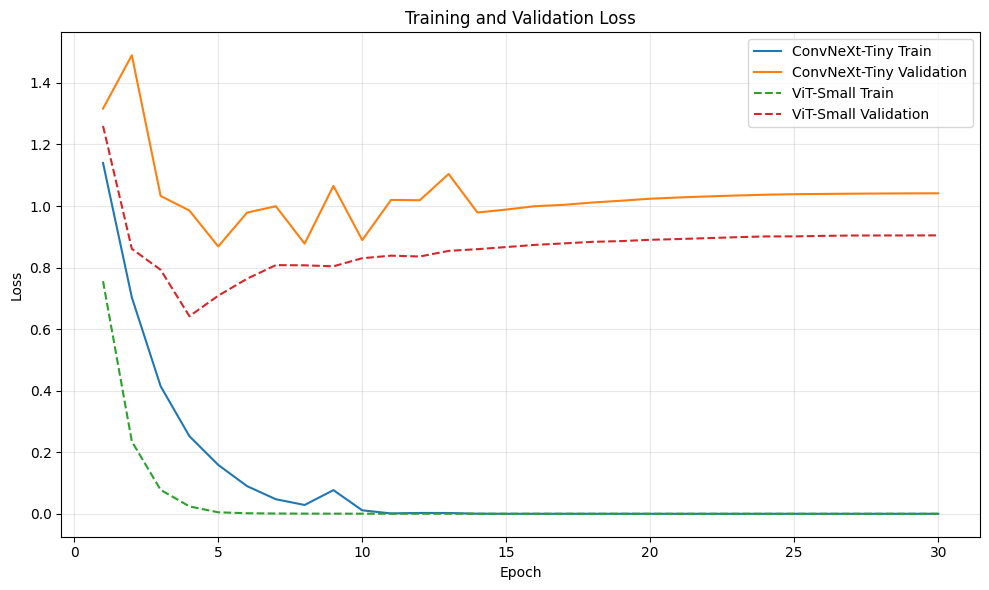

✓ Loss curve saved: /kaggle/working/skindisnet_final_manifest/overfitting_analysis/training_validation_loss.png

15. GENERATING ACCURACY CURVES


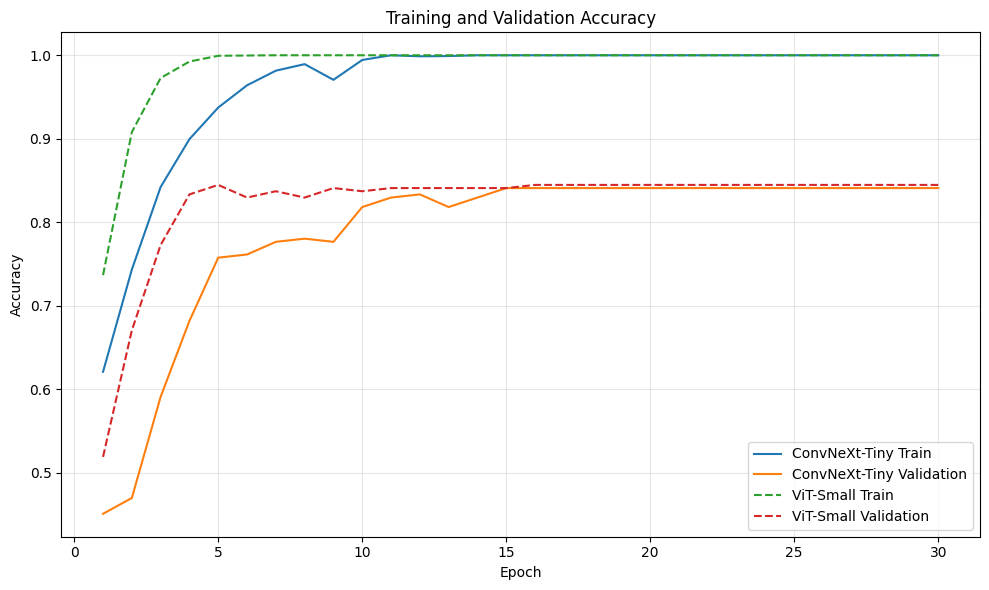

✓ Accuracy curve saved: /kaggle/working/skindisnet_final_manifest/overfitting_analysis/training_validation_accuracy.png

16. GENERATING MACRO F1 CURVES


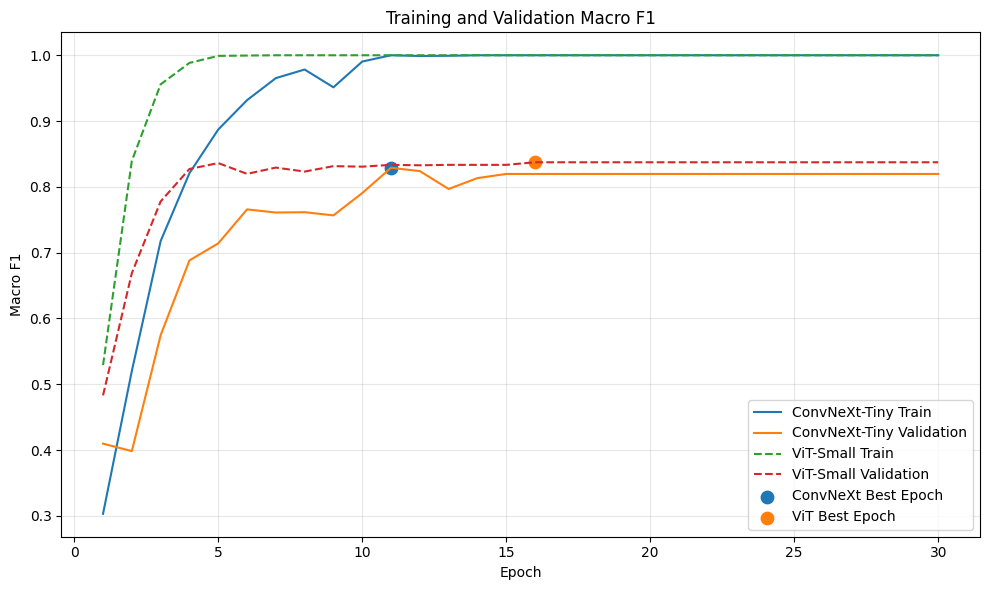

✓ Macro F1 curve saved: /kaggle/working/skindisnet_final_manifest/overfitting_analysis/training_validation_macro_f1.png

17. GENERATING GENERALIZATION GAP CURVE


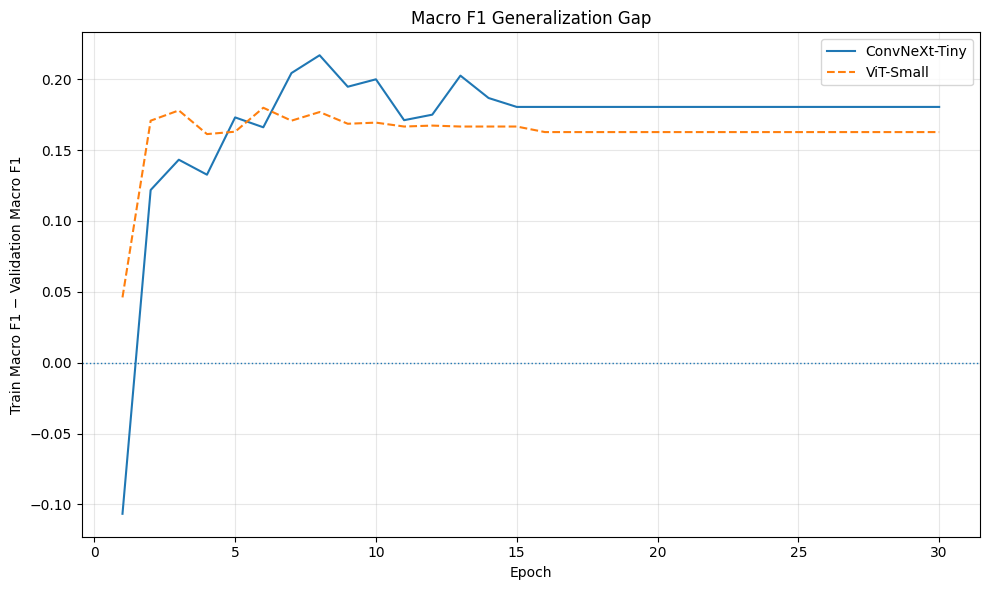

✓ Generalization gap curve saved: /kaggle/working/skindisnet_final_manifest/overfitting_analysis/macro_f1_generalization_gap.png

18. SAVE NORMALIZED TRAINING HISTORY
✓ ConvNeXt analysis saved:
  /kaggle/working/skindisnet_final_manifest/overfitting_analysis/convnext_tiny_training_analysis.csv
✓ ViT analysis saved:
  /kaggle/working/skindisnet_final_manifest/overfitting_analysis/vit_small_training_analysis.csv

19. SAVE SUMMARY TABLES
✓ Best epoch summary saved.
✓ Final epoch summary saved.
✓ Overfitting summary saved.

20. SAVE FINAL JSON SUMMARY
✓ Final JSON summary saved:
/kaggle/working/skindisnet_final_manifest/overfitting_analysis/training_curve_overfitting_summary.json

FINAL TRAINING CURVE & OVERFITTING AUDIT
History files                 : PASS
Numerical validation          : PASS
Best epoch analysis           : PASS
Generalization gap analysis   : PASS
Training curve generation     : PASS
Output files                  : PASS

✓✓✓ CELL 9D — OVERFITTING ANALYSIS COMPLETED ✓✓✓



In [ ]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("CELL 9D — TRAINING CURVE & OVERFITTING ANALYSIS")
print("=" * 70)


# ================================================================
# 0. CONFIGURATION
# ================================================================

SEED = 42

MANIFEST_DIR = "/kaggle/working/skindisnet_final_manifest"
TRAINING_RESULTS_DIR = os.path.join(
    MANIFEST_DIR,
    "training_results"
)

ANALYSIS_DIR = os.path.join(
    MANIFEST_DIR,
    "overfitting_analysis"
)

os.makedirs(ANALYSIS_DIR, exist_ok=True)

CONVNEXT_HISTORY_PATH = os.path.join(
    TRAINING_RESULTS_DIR,
    "convnext_tiny_training_history.csv"
)

VIT_HISTORY_PATH = os.path.join(
    TRAINING_RESULTS_DIR,
    "vit_small_training_history.csv"
)

print()
print("=" * 70)
print("0. CONFIGURATION")
print("=" * 70)

print(f"Random seed        : {SEED}")
print(f"Training results   : {TRAINING_RESULTS_DIR}")
print(f"Analysis directory : {ANALYSIS_DIR}")

print()


# ================================================================
# 1. REPRODUCIBILITY
# ================================================================

print("=" * 70)
print("1. REPRODUCIBILITY SETUP")
print("=" * 70)

random.seed(SEED)
np.random.seed(SEED)

print("✓ Python random seed : 42")
print("✓ NumPy random seed  : 42")


# ================================================================
# 2. HISTORY FILE VALIDATION
# ================================================================

print()
print("=" * 70)
print("2. TRAINING HISTORY VALIDATION")
print("=" * 70)

if not os.path.exists(CONVNEXT_HISTORY_PATH):
    raise FileNotFoundError(
        f"ConvNeXt training history tidak ditemukan:\n"
        f"{CONVNEXT_HISTORY_PATH}\n\n"
        f"Pastikan Cell 8B sudah selesai."
    )

if not os.path.exists(VIT_HISTORY_PATH):
    raise FileNotFoundError(
        f"ViT training history tidak ditemukan:\n"
        f"{VIT_HISTORY_PATH}\n\n"
        f"Pastikan Cell 8C sudah selesai."
    )

print("✓ ConvNeXt training history ditemukan.")
print("✓ ViT training history ditemukan.")


# ================================================================
# 3. LOAD TRAINING HISTORY
# ================================================================

print()
print("=" * 70)
print("3. LOAD TRAINING HISTORY")
print("=" * 70)

convnext_history = pd.read_csv(CONVNEXT_HISTORY_PATH)
vit_history = pd.read_csv(VIT_HISTORY_PATH)

print(f"ConvNeXt history rows : {len(convnext_history)}")
print(f"ViT history rows      : {len(vit_history)}")

print("✓ Kedua training history berhasil dimuat.")


# ================================================================
# 4. HISTORY STRUCTURE VALIDATION
# ================================================================

print()
print("=" * 70)
print("4. HISTORY STRUCTURE VALIDATION")
print("=" * 70)

print("ConvNeXt columns:")
print(list(convnext_history.columns))

print()
print("ViT columns:")
print(list(vit_history.columns))


# ------------------------------------------------
# Expected semantic columns
# ------------------------------------------------

def find_column(df, candidates, description):
    """
    Mencari nama kolom berdasarkan beberapa kemungkinan nama.
    """
    lower_map = {
        str(col).lower().strip(): col
        for col in df.columns
    }

    for candidate in candidates:
        key = candidate.lower().strip()

        if key in lower_map:
            return lower_map[key]

    raise KeyError(
        f"Kolom untuk {description} tidak ditemukan.\n"
        f"Kandidat: {candidates}\n"
        f"Kolom tersedia: {list(df.columns)}"
    )


epoch_col_convnext = find_column(
    convnext_history,
    ["epoch"],
    "epoch ConvNeXt"
)

epoch_col_vit = find_column(
    vit_history,
    ["epoch"],
    "epoch ViT"
)


# Loss
train_loss_col_convnext = find_column(
    convnext_history,
    ["train_loss", "training_loss"],
    "training loss ConvNeXt"
)

val_loss_col_convnext = find_column(
    convnext_history,
    ["val_loss", "validation_loss"],
    "validation loss ConvNeXt"
)

train_loss_col_vit = find_column(
    vit_history,
    ["train_loss", "training_loss"],
    "training loss ViT"
)

val_loss_col_vit = find_column(
    vit_history,
    ["val_loss", "validation_loss"],
    "validation loss ViT"
)


# Accuracy
train_acc_col_convnext = find_column(
    convnext_history,
    ["train_accuracy", "training_accuracy", "train_acc"],
    "training accuracy ConvNeXt"
)

val_acc_col_convnext = find_column(
    convnext_history,
    ["val_accuracy", "validation_accuracy", "val_acc"],
    "validation accuracy ConvNeXt"
)

train_acc_col_vit = find_column(
    vit_history,
    ["train_accuracy", "training_accuracy", "train_acc"],
    "training accuracy ViT"
)

val_acc_col_vit = find_column(
    vit_history,
    ["val_accuracy", "validation_accuracy", "val_acc"],
    "validation accuracy ViT"
)


# Macro F1
train_f1_col_convnext = find_column(
    convnext_history,
    ["train_macro_f1", "training_macro_f1", "train_f1"],
    "training Macro F1 ConvNeXt"
)

val_f1_col_convnext = find_column(
    convnext_history,
    ["val_macro_f1", "validation_macro_f1", "val_f1"],
    "validation Macro F1 ConvNeXt"
)

train_f1_col_vit = find_column(
    vit_history,
    ["train_macro_f1", "training_macro_f1", "train_f1"],
    "training Macro F1 ViT"
)

val_f1_col_vit = find_column(
    vit_history,
    ["val_macro_f1", "validation_macro_f1", "val_f1"],
    "validation Macro F1 ViT"
)

print()
print("✓ Epoch columns ditemukan.")
print("✓ Loss columns ditemukan.")
print("✓ Accuracy columns ditemukan.")
print("✓ Macro F1 columns ditemukan.")


# ================================================================
# 5. NORMALIZE HISTORY
# ================================================================

print()
print("=" * 70)
print("5. NORMALIZE TRAINING HISTORY")
print("=" * 70)

convnext = pd.DataFrame({
    "Epoch": convnext_history[epoch_col_convnext],
    "Train_Loss": convnext_history[train_loss_col_convnext],
    "Val_Loss": convnext_history[val_loss_col_convnext],
    "Train_Accuracy": convnext_history[train_acc_col_convnext],
    "Val_Accuracy": convnext_history[val_acc_col_convnext],
    "Train_Macro_F1": convnext_history[train_f1_col_convnext],
    "Val_Macro_F1": convnext_history[val_f1_col_convnext],
})

vit = pd.DataFrame({
    "Epoch": vit_history[epoch_col_vit],
    "Train_Loss": vit_history[train_loss_col_vit],
    "Val_Loss": vit_history[val_loss_col_vit],
    "Train_Accuracy": vit_history[train_acc_col_vit],
    "Val_Accuracy": vit_history[val_acc_col_vit],
    "Train_Macro_F1": vit_history[train_f1_col_vit],
    "Val_Macro_F1": vit_history[val_f1_col_vit],
})


# Convert numerical values
for df in [convnext, vit]:
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


print(f"ConvNeXt epochs : {len(convnext)}")
print(f"ViT epochs      : {len(vit)}")

print("✓ History berhasil dinormalisasi.")


# ================================================================
# 6. NUMERICAL SANITY CHECK
# ================================================================

print()
print("=" * 70)
print("6. NUMERICAL SANITY CHECK")
print("=" * 70)

for model_name, df in [
    ("ConvNeXt-Tiny", convnext),
    ("ViT-Small", vit)
]:

    nan_count = int(df.isna().sum().sum())

    inf_count = int(
        np.isinf(
            df.select_dtypes(include=[np.number]).to_numpy()
        ).sum()
    )

    print(f"{model_name}")
    print(f"  NaN : {nan_count}")
    print(f"  Inf : {inf_count}")

    if nan_count > 0:
        raise ValueError(
            f"{model_name} history mengandung NaN."
        )

    if inf_count > 0:
        raise ValueError(
            f"{model_name} history mengandung Inf."
        )

print("✓ Tidak ditemukan NaN / Inf.")


# ================================================================
# 7. EPOCH CONSISTENCY
# ================================================================

print()
print("=" * 70)
print("7. EPOCH CONSISTENCY")
print("=" * 70)

print(
    f"ConvNeXt epoch range : "
    f"{int(convnext['Epoch'].min())} → "
    f"{int(convnext['Epoch'].max())}"
)

print(
    f"ViT epoch range      : "
    f"{int(vit['Epoch'].min())} → "
    f"{int(vit['Epoch'].max())}"
)

if len(convnext) != len(vit):
    print(
        "⚠ Jumlah epoch history berbeda antara ConvNeXt dan ViT."
    )
else:
    print(
        f"✓ Kedua model memiliki {len(convnext)} epoch."
    )


# ================================================================
# 8. CALCULATE GENERALIZATION GAPS
# ================================================================

print()
print("=" * 70)
print("8. GENERALIZATION GAP CALCULATION")
print("=" * 70)

for df in [convnext, vit]:

    # Accuracy gap
    df["Accuracy_Gap"] = (
        df["Train_Accuracy"] -
        df["Val_Accuracy"]
    )

    # Macro F1 gap
    df["Macro_F1_Gap"] = (
        df["Train_Macro_F1"] -
        df["Val_Macro_F1"]
    )

    # Loss gap
    df["Loss_Gap"] = (
        df["Val_Loss"] -
        df["Train_Loss"]
    )


print("✓ Accuracy gap dihitung.")
print("✓ Macro F1 gap dihitung.")
print("✓ Loss gap dihitung.")


# ================================================================
# 9. BEST VALIDATION EPOCH
# ================================================================

print()
print("=" * 70)
print("9. BEST VALIDATION EPOCH")
print("=" * 70)

convnext_best_idx = convnext["Val_Macro_F1"].idxmax()
vit_best_idx = vit["Val_Macro_F1"].idxmax()

convnext_best = convnext.loc[convnext_best_idx]
vit_best = vit.loc[vit_best_idx]

print("CONVNEXT-TINY")
print(
    f"Best epoch      : {int(convnext_best['Epoch'])}"
)
print(
    f"Best Val Macro F1: "
    f"{convnext_best['Val_Macro_F1']:.4f}"
)

print()

print("VIT-SMALL")
print(
    f"Best epoch      : {int(vit_best['Epoch'])}"
)
print(
    f"Best Val Macro F1: "
    f"{vit_best['Val_Macro_F1']:.4f}"
)


# ================================================================
# 10. TRAINING vs VALIDATION AT BEST EPOCH
# ================================================================

print()
print("=" * 70)
print("10. TRAINING vs VALIDATION AT BEST EPOCH")
print("=" * 70)

best_epoch_summary = pd.DataFrame([
    {
        "Model": "ConvNeXt-Tiny",
        "Best_Epoch": int(convnext_best["Epoch"]),
        "Train_Loss": convnext_best["Train_Loss"],
        "Val_Loss": convnext_best["Val_Loss"],
        "Train_Accuracy": convnext_best["Train_Accuracy"],
        "Val_Accuracy": convnext_best["Val_Accuracy"],
        "Train_Macro_F1": convnext_best["Train_Macro_F1"],
        "Val_Macro_F1": convnext_best["Val_Macro_F1"],
        "Accuracy_Gap": convnext_best["Accuracy_Gap"],
        "Macro_F1_Gap": convnext_best["Macro_F1_Gap"],
        "Loss_Gap": convnext_best["Loss_Gap"],
    },
    {
        "Model": "ViT-Small",
        "Best_Epoch": int(vit_best["Epoch"]),
        "Train_Loss": vit_best["Train_Loss"],
        "Val_Loss": vit_best["Val_Loss"],
        "Train_Accuracy": vit_best["Train_Accuracy"],
        "Val_Accuracy": vit_best["Val_Accuracy"],
        "Train_Macro_F1": vit_best["Train_Macro_F1"],
        "Val_Macro_F1": vit_best["Val_Macro_F1"],
        "Accuracy_Gap": vit_best["Accuracy_Gap"],
        "Macro_F1_Gap": vit_best["Macro_F1_Gap"],
        "Loss_Gap": vit_best["Loss_Gap"],
    }
])

print(best_epoch_summary.to_string(index=False))


# ================================================================
# 11. FINAL EPOCH ANALYSIS
# ================================================================

print()
print("=" * 70)
print("11. FINAL EPOCH ANALYSIS")
print("=" * 70)

convnext_final = convnext.iloc[-1]
vit_final = vit.iloc[-1]

final_epoch_summary = pd.DataFrame([
    {
        "Model": "ConvNeXt-Tiny",
        "Epoch": int(convnext_final["Epoch"]),
        "Train_Accuracy": convnext_final["Train_Accuracy"],
        "Val_Accuracy": convnext_final["Val_Accuracy"],
        "Train_Macro_F1": convnext_final["Train_Macro_F1"],
        "Val_Macro_F1": convnext_final["Val_Macro_F1"],
        "Train_Loss": convnext_final["Train_Loss"],
        "Val_Loss": convnext_final["Val_Loss"],
        "Accuracy_Gap": convnext_final["Accuracy_Gap"],
        "Macro_F1_Gap": convnext_final["Macro_F1_Gap"],
    },
    {
        "Model": "ViT-Small",
        "Epoch": int(vit_final["Epoch"]),
        "Train_Accuracy": vit_final["Train_Accuracy"],
        "Val_Accuracy": vit_final["Val_Accuracy"],
        "Train_Macro_F1": vit_final["Train_Macro_F1"],
        "Val_Macro_F1": vit_final["Val_Macro_F1"],
        "Train_Loss": vit_final["Train_Loss"],
        "Val_Loss": vit_final["Val_Loss"],
        "Accuracy_Gap": vit_final["Accuracy_Gap"],
        "Macro_F1_Gap": vit_final["Macro_F1_Gap"],
    }
])

print(final_epoch_summary.to_string(index=False))


# ================================================================
# 12. OVERFITTING INDICATOR ANALYSIS
# ================================================================

print()
print("=" * 70)
print("12. OVERFITTING INDICATOR ANALYSIS")
print("=" * 70)


def analyze_overfitting(df, model_name):

    best_idx = df["Val_Macro_F1"].idxmax()
    best_position = df.index.get_loc(best_idx)

    best_epoch = int(df.loc[best_idx, "Epoch"])
    best_val_f1 = float(df.loc[best_idx, "Val_Macro_F1"])

    final_val_f1 = float(df.iloc[-1]["Val_Macro_F1"])
    final_train_f1 = float(df.iloc[-1]["Train_Macro_F1"])

    final_gap = float(
        df.iloc[-1]["Macro_F1_Gap"]
    )

    # Apakah validation F1 turun setelah best epoch?
    post_best = df.iloc[best_position:]

    if len(post_best) > 1:

        validation_drop = float(
            best_val_f1 -
            post_best["Val_Macro_F1"].iloc[-1]
        )

    else:

        validation_drop = 0.0


    # Apakah training F1 terus sangat tinggi?
    training_high = final_train_f1 >= 0.95

    # Validation performance turun setelah best epoch
    validation_decline = validation_drop > 0.02

    # Generalization gap
    significant_gap = final_gap > 0.10


    if (
        training_high
        and validation_decline
        and significant_gap
    ):
        status = "STRONG OVERFITTING INDICATION"

    elif (
        validation_decline
        or significant_gap
        or training_high
    ):
        status = "OVERFITTING INDICATION"

    else:
        status = "NO STRONG OVERFITTING INDICATION"


    return {
        "Model": model_name,
        "Best_Epoch": best_epoch,
        "Best_Val_Macro_F1": best_val_f1,
        "Final_Train_Macro_F1": final_train_f1,
        "Final_Val_Macro_F1": final_val_f1,
        "Final_Macro_F1_Gap": final_gap,
        "Validation_Drop_After_Best": validation_drop,
        "Training_F1_High": training_high,
        "Validation_Decline": validation_decline,
        "Significant_Gap": significant_gap,
        "Overfitting_Status": status
    }


convnext_overfit = analyze_overfitting(
    convnext,
    "ConvNeXt-Tiny"
)

vit_overfit = analyze_overfitting(
    vit,
    "ViT-Small"
)

overfitting_summary = pd.DataFrame([
    convnext_overfit,
    vit_overfit
])

print(
    overfitting_summary.to_string(index=False)
)


# ================================================================
# 13. TRAINING DYNAMICS SUMMARY
# ================================================================

print()
print("=" * 70)
print("13. TRAINING DYNAMICS SUMMARY")
print("=" * 70)

for result in [
    convnext_overfit,
    vit_overfit
]:

    print()
    print(result["Model"])

    print(
        f"Best epoch              : "
        f"{result['Best_Epoch']}"
    )

    print(
        f"Best validation Macro F1: "
        f"{result['Best_Val_Macro_F1']:.4f}"
    )

    print(
        f"Final training Macro F1 : "
        f"{result['Final_Train_Macro_F1']:.4f}"
    )

    print(
        f"Final validation Macro F1: "
        f"{result['Final_Val_Macro_F1']:.4f}"
    )

    print(
        f"Final Macro F1 gap       : "
        f"{result['Final_Macro_F1_Gap']:.4f}"
    )

    print(
        f"Validation drop          : "
        f"{result['Validation_Drop_After_Best']:.4f}"
    )

    print(
        f"Status                   : "
        f"{result['Overfitting_Status']}"
    )


# ================================================================
# 14. PLOT 1 — LOSS CURVES
# ================================================================

print()
print("=" * 70)
print("14. GENERATING LOSS CURVES")
print("=" * 70)

plt.figure(figsize=(10, 6))

plt.plot(
    convnext["Epoch"],
    convnext["Train_Loss"],
    label="ConvNeXt-Tiny Train"
)

plt.plot(
    convnext["Epoch"],
    convnext["Val_Loss"],
    label="ConvNeXt-Tiny Validation"
)

plt.plot(
    vit["Epoch"],
    vit["Train_Loss"],
    linestyle="--",
    label="ViT-Small Train"
)

plt.plot(
    vit["Epoch"],
    vit["Val_Loss"],
    linestyle="--",
    label="ViT-Small Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

loss_plot_path = os.path.join(
    ANALYSIS_DIR,
    "training_validation_loss.png"
)

plt.savefig(
    loss_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Loss curve saved: {loss_plot_path}")


# ================================================================
# 15. PLOT 2 — ACCURACY CURVES
# ================================================================

print()
print("=" * 70)
print("15. GENERATING ACCURACY CURVES")
print("=" * 70)

plt.figure(figsize=(10, 6))

plt.plot(
    convnext["Epoch"],
    convnext["Train_Accuracy"],
    label="ConvNeXt-Tiny Train"
)

plt.plot(
    convnext["Epoch"],
    convnext["Val_Accuracy"],
    label="ConvNeXt-Tiny Validation"
)

plt.plot(
    vit["Epoch"],
    vit["Train_Accuracy"],
    linestyle="--",
    label="ViT-Small Train"
)

plt.plot(
    vit["Epoch"],
    vit["Val_Accuracy"],
    linestyle="--",
    label="ViT-Small Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

accuracy_plot_path = os.path.join(
    ANALYSIS_DIR,
    "training_validation_accuracy.png"
)

plt.savefig(
    accuracy_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"✓ Accuracy curve saved: {accuracy_plot_path}"
)


# ================================================================
# 16. PLOT 3 — MACRO F1 CURVES
# ================================================================

print()
print("=" * 70)
print("16. GENERATING MACRO F1 CURVES")
print("=" * 70)

plt.figure(figsize=(10, 6))

plt.plot(
    convnext["Epoch"],
    convnext["Train_Macro_F1"],
    label="ConvNeXt-Tiny Train"
)

plt.plot(
    convnext["Epoch"],
    convnext["Val_Macro_F1"],
    label="ConvNeXt-Tiny Validation"
)

plt.plot(
    vit["Epoch"],
    vit["Train_Macro_F1"],
    linestyle="--",
    label="ViT-Small Train"
)

plt.plot(
    vit["Epoch"],
    vit["Val_Macro_F1"],
    linestyle="--",
    label="ViT-Small Validation"
)

# Best epochs
plt.scatter(
    [convnext_best["Epoch"]],
    [convnext_best["Val_Macro_F1"]],
    marker="o",
    s=80,
    label="ConvNeXt Best Epoch"
)

plt.scatter(
    [vit_best["Epoch"]],
    [vit_best["Val_Macro_F1"]],
    marker="o",
    s=80,
    label="ViT Best Epoch"
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Training and Validation Macro F1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

f1_plot_path = os.path.join(
    ANALYSIS_DIR,
    "training_validation_macro_f1.png"
)

plt.savefig(
    f1_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"✓ Macro F1 curve saved: {f1_plot_path}"
)


# ================================================================
# 17. PLOT 4 — GENERALIZATION GAP
# ================================================================

print()
print("=" * 70)
print("17. GENERATING GENERALIZATION GAP CURVE")
print("=" * 70)

plt.figure(figsize=(10, 6))

plt.plot(
    convnext["Epoch"],
    convnext["Macro_F1_Gap"],
    label="ConvNeXt-Tiny"
)

plt.plot(
    vit["Epoch"],
    vit["Macro_F1_Gap"],
    linestyle="--",
    label="ViT-Small"
)

plt.axhline(
    y=0,
    linestyle=":",
    linewidth=1
)

plt.xlabel("Epoch")
plt.ylabel("Train Macro F1 − Validation Macro F1")
plt.title("Macro F1 Generalization Gap")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

gap_plot_path = os.path.join(
    ANALYSIS_DIR,
    "macro_f1_generalization_gap.png"
)

plt.savefig(
    gap_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"✓ Generalization gap curve saved: {gap_plot_path}"
)


# ================================================================
# 18. SAVE NORMALIZED HISTORY
# ================================================================

print()
print("=" * 70)
print("18. SAVE NORMALIZED TRAINING HISTORY")
print("=" * 70)

convnext_history_output = os.path.join(
    ANALYSIS_DIR,
    "convnext_tiny_training_analysis.csv"
)

vit_history_output = os.path.join(
    ANALYSIS_DIR,
    "vit_small_training_analysis.csv"
)

convnext.to_csv(
    convnext_history_output,
    index=False
)

vit.to_csv(
    vit_history_output,
    index=False
)

print(
    f"✓ ConvNeXt analysis saved:\n"
    f"  {convnext_history_output}"
)

print(
    f"✓ ViT analysis saved:\n"
    f"  {vit_history_output}"
)


# ================================================================
# 19. SAVE SUMMARY TABLES
# ================================================================

print()
print("=" * 70)
print("19. SAVE SUMMARY TABLES")
print("=" * 70)

best_epoch_output = os.path.join(
    ANALYSIS_DIR,
    "best_epoch_summary.csv"
)

final_epoch_output = os.path.join(
    ANALYSIS_DIR,
    "final_epoch_summary.csv"
)

overfitting_output = os.path.join(
    ANALYSIS_DIR,
    "overfitting_summary.csv"
)

best_epoch_summary.to_csv(
    best_epoch_output,
    index=False
)

final_epoch_summary.to_csv(
    final_epoch_output,
    index=False
)

overfitting_summary.to_csv(
    overfitting_output,
    index=False
)

print("✓ Best epoch summary saved.")
print("✓ Final epoch summary saved.")
print("✓ Overfitting summary saved.")


# ================================================================
# 20. FINAL JSON SUMMARY
# ================================================================

print()
print("=" * 70)
print("20. SAVE FINAL JSON SUMMARY")
print("=" * 70)

final_summary = {
    "cell": "9D",
    "analysis": "Training Curve & Overfitting Analysis",
    "random_seed": SEED,

    "models": {
        "ConvNeXt-Tiny": convnext_overfit,
        "ViT-Small": vit_overfit
    },

    "best_epoch": {
        "ConvNeXt-Tiny": int(convnext_best["Epoch"]),
        "ViT-Small": int(vit_best["Epoch"])
    },

    "best_validation_macro_f1": {
        "ConvNeXt-Tiny": float(
            convnext_best["Val_Macro_F1"]
        ),
        "ViT-Small": float(
            vit_best["Val_Macro_F1"]
        )
    },

    "test_set_used": False,

    "outputs": {
        "loss_curve": loss_plot_path,
        "accuracy_curve": accuracy_plot_path,
        "macro_f1_curve": f1_plot_path,
        "generalization_gap_curve": gap_plot_path,
        "convnext_history": convnext_history_output,
        "vit_history": vit_history_output,
        "best_epoch_summary": best_epoch_output,
        "final_epoch_summary": final_epoch_output,
        "overfitting_summary": overfitting_output
    }
}

json_output = os.path.join(
    ANALYSIS_DIR,
    "training_curve_overfitting_summary.json"
)

with open(
    json_output,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_summary,
        f,
        indent=4,
        ensure_ascii=False
    )

print(
    f"✓ Final JSON summary saved:\n"
    f"{json_output}"
)


# ================================================================
# 21. FINAL AUDIT
# ================================================================

print()
print("=" * 70)
print("FINAL TRAINING CURVE & OVERFITTING AUDIT")
print("=" * 70)

required_outputs = [
    loss_plot_path,
    accuracy_plot_path,
    f1_plot_path,
    gap_plot_path,
    convnext_history_output,
    vit_history_output,
    best_epoch_output,
    final_epoch_output,
    overfitting_output,
    json_output
]

all_outputs_exist = all(
    os.path.exists(path)
    for path in required_outputs
)

print(
    f"History files                 : "
    f"{'PASS' if True else 'FAIL'}"
)

print(
    f"Numerical validation          : "
    f"PASS"
)

print(
    f"Best epoch analysis           : "
    f"PASS"
)

print(
    f"Generalization gap analysis   : "
    f"PASS"
)

print(
    f"Training curve generation     : "
    f"{'PASS' if all_outputs_exist else 'FAIL'}"
)

print(
    f"Output files                  : "
    f"{'PASS' if all_outputs_exist else 'FAIL'}"
)

print()
print("=" * 70)

if all_outputs_exist:
    print("✓✓✓ CELL 9D — OVERFITTING ANALYSIS COMPLETED ✓✓✓")
else:
    print("✗ CELL 9D OUTPUT VALIDATION FAILED")

print("=" * 70)

print()
print("ANALYSIS DIRECTORY:")
print(ANALYSIS_DIR)

print()
print("NEXT:")
print("Cell 9E — Model Performance Visualization & Statistical Comparison")

# CELL 9E — MODEL PERFORMANCE VISUALIZATION & STATISTICAL COMPARISON

CELL 9E — MODEL PERFORMANCE VISUALIZATION & STATISTICAL COMPARISON

0. CONFIGURATION
Random seed        : 42
Unified directory  : /kaggle/working/skindisnet_final_manifest/unified_final_evaluation
Analysis directory : /kaggle/working/skindisnet_final_manifest/overfitting_analysis
Output directory   : /kaggle/working/skindisnet_final_manifest/performance_visualization

1. REPRODUCIBILITY SETUP
✓ Python random seed : 42
✓ NumPy random seed  : 42

2. REQUIRED FILE VALIDATION
✓ ConvNeXt history ditemukan.
✓ ViT history ditemukan.
✓ Final model comparison ditemukan.

3. LOAD TRAINING HISTORIES
ConvNeXt history rows : 30
ViT history rows      : 30
✓ Training history berhasil dimuat.

4. HISTORY STRUCTURE VALIDATION

ConvNeXt columns:
['Epoch', 'Train_Loss', 'Val_Loss', 'Train_Accuracy', 'Val_Accuracy', 'Train_Macro_F1', 'Val_Macro_F1', 'Accuracy_Gap', 'Macro_F1_Gap', 'Loss_Gap']

ViT columns:
['Epoch', 'Train_Loss', 'Val_Loss', 'Train_Accuracy', 'Val_Accuracy', 'Train_Macro_F1', 'Val_Macro_F

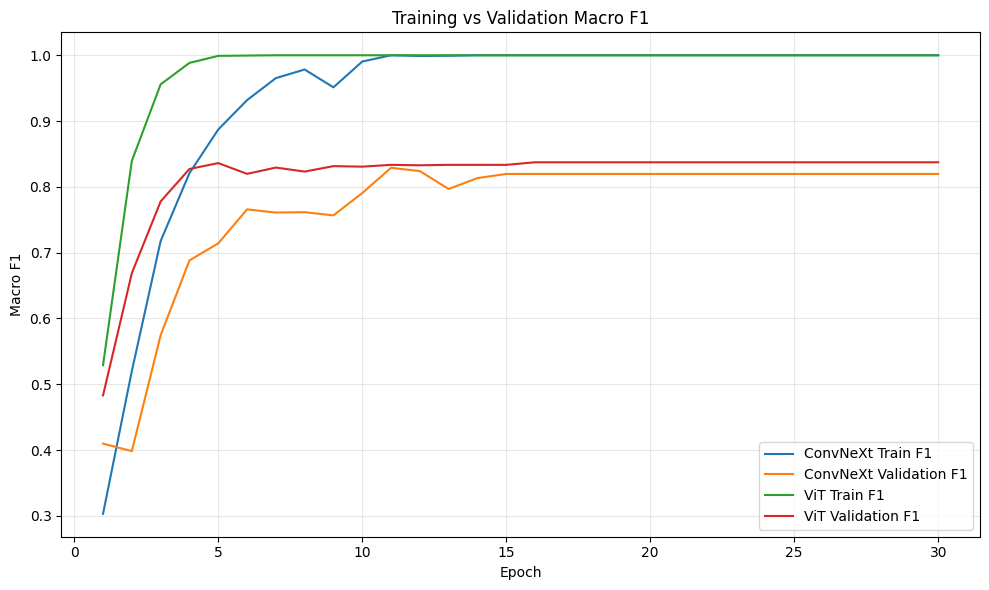

✓ Macro F1 curve saved:
/kaggle/working/skindisnet_final_manifest/performance_visualization/macro_f1_training_curve.png

10. ACCURACY TRAINING CURVE


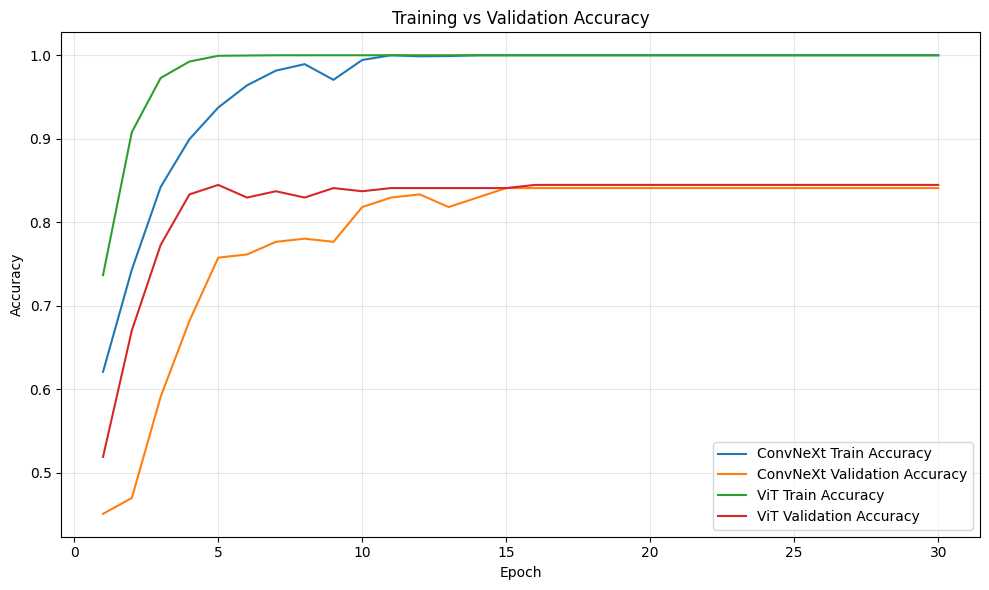

✓ Accuracy curve saved:
/kaggle/working/skindisnet_final_manifest/performance_visualization/accuracy_training_curve.png

11. LOSS TRAINING CURVE


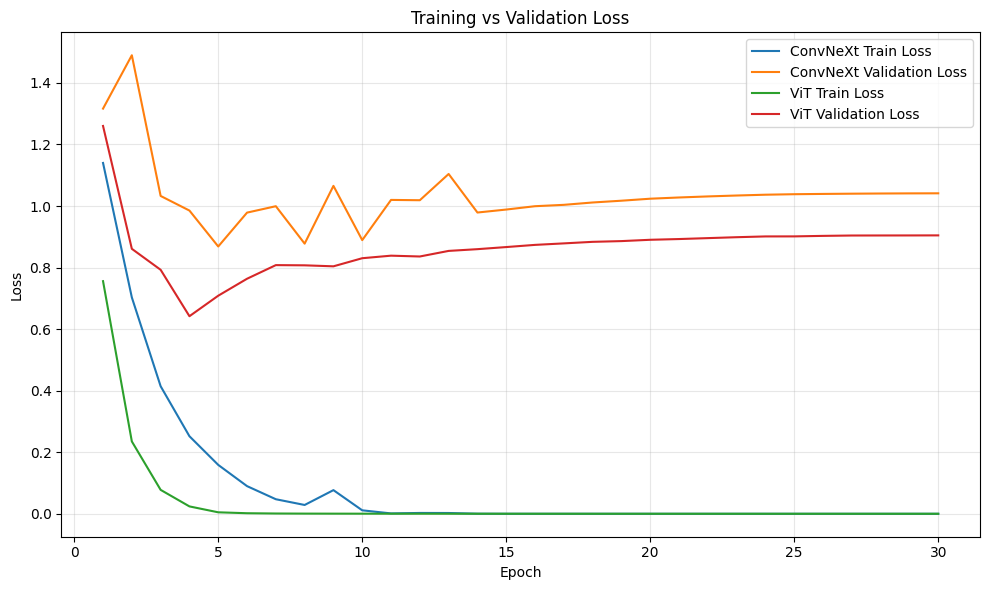

✓ Loss curve saved:
/kaggle/working/skindisnet_final_manifest/performance_visualization/loss_training_curve.png

12. BEST EPOCH COMPARISON
        Model  Best_Epoch  Best_Val_Macro_F1  Accuracy_Gap  Macro_F1_Gap  Loss_Gap
ConvNeXt-Tiny          11           0.828960      0.170455      0.171040  1.018598
    ViT-Small          16           0.837351      0.155303      0.162649  0.873589

✓ Best epoch comparison saved:
/kaggle/working/skindisnet_final_manifest/performance_visualization/best_epoch_comparison.csv

13. FINAL TEST PERFORMANCE

Columns:
['Model', 'Test_Images', 'Accuracy', 'Macro_Precision', 'Macro_Recall', 'Macro_F1', 'Weighted_Precision', 'Weighted_Recall', 'Weighted_F1', 'Inference_Time_Seconds']

Final test results:
        Model  Test_Images  Accuracy  Macro_Precision  Macro_Recall  Macro_F1  Weighted_Precision  Weighted_Recall  Weighted_F1  Inference_Time_Seconds
ConvNeXt-Tiny          241  0.854772         0.833433      0.837957  0.832278            0.854420         0.8

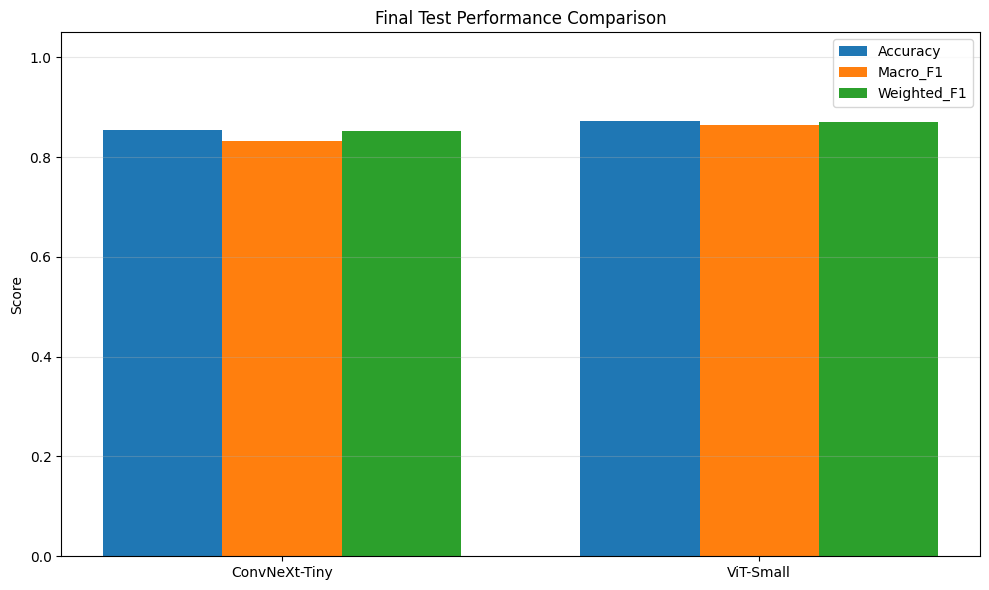

✓ Test metric comparison saved:
/kaggle/working/skindisnet_final_manifest/performance_visualization/final_test_metric_comparison.png

15. BEST MODEL
Best model berdasarkan Test Macro F1 : ViT-Small
Test Macro F1 : 0.8651

16. STATISTICAL COMPARISON — DESCRIPTIVE
        Model  Accuracy  Macro_Precision  Macro_Recall  Macro_F1  Weighted_F1
ConvNeXt-Tiny  0.854772         0.833433      0.837957  0.832278     0.853245
    ViT-Small  0.871369         0.868310      0.865215  0.865100     0.870875

17. MODEL PERFORMANCE DIFFERENCE
         Metric  Difference_Model_2_minus_Model_1
       Accuracy                          0.016598
Macro Precision                          0.034877
   Macro Recall                          0.027258
       Macro F1                          0.032822
    Weighted F1                          0.017630

✓ Performance difference saved:
/kaggle/working/skindisnet_final_manifest/performance_visualization/model_performance_difference.csv

18. FINAL ANALYSIS SUMMARY
✓ Final

In [ ]:
import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

warnings.filterwarnings("ignore")

print("=" * 70)
print("CELL 9E — MODEL PERFORMANCE VISUALIZATION & STATISTICAL COMPARISON")
print("=" * 70)


# ======================================================================
# 0. CONFIGURATION
# ======================================================================

SEED = 42

BASE_DIR = "/kaggle/working/skindisnet_final_manifest"

UNIFIED_DIR = os.path.join(
    BASE_DIR,
    "unified_final_evaluation"
)

ANALYSIS_DIR = os.path.join(
    BASE_DIR,
    "overfitting_analysis"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "performance_visualization"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("\n" + "=" * 70)
print("0. CONFIGURATION")
print("=" * 70)

print(f"Random seed        : {SEED}")
print(f"Unified directory  : {UNIFIED_DIR}")
print(f"Analysis directory : {ANALYSIS_DIR}")
print(f"Output directory   : {OUTPUT_DIR}")


# ======================================================================
# 1. REPRODUCIBILITY
# ======================================================================

print("\n" + "=" * 70)
print("1. REPRODUCIBILITY SETUP")
print("=" * 70)

random.seed(SEED)
np.random.seed(SEED)

print("✓ Python random seed : 42")
print("✓ NumPy random seed  : 42")


# ======================================================================
# 2. CHECK REQUIRED FILES
# ======================================================================

print("\n" + "=" * 70)
print("2. REQUIRED FILE VALIDATION")
print("=" * 70)

CONVNEXT_HISTORY = os.path.join(
    ANALYSIS_DIR,
    "convnext_tiny_training_analysis.csv"
)

VIT_HISTORY = os.path.join(
    ANALYSIS_DIR,
    "vit_small_training_analysis.csv"
)

FINAL_COMPARISON = os.path.join(
    UNIFIED_DIR,
    "unified_final_model_comparison.csv"
)

FILES = {
    "ConvNeXt history": CONVNEXT_HISTORY,
    "ViT history": VIT_HISTORY,
    "Final model comparison": FINAL_COMPARISON
}

for name, path in FILES.items():

    if os.path.exists(path):
        print(f"✓ {name} ditemukan.")
    else:
        print(f"✗ {name} TIDAK ditemukan:")
        print(f"  {path}")


missing_files = [
    name for name, path in FILES.items()
    if not os.path.exists(path)
]

if missing_files:
    raise FileNotFoundError(
        f"\nFile berikut tidak ditemukan: {missing_files}"
    )


# ======================================================================
# 3. LOAD TRAINING HISTORIES
# ======================================================================

print("\n" + "=" * 70)
print("3. LOAD TRAINING HISTORIES")
print("=" * 70)

convnext_history = pd.read_csv(CONVNEXT_HISTORY)
vit_history = pd.read_csv(VIT_HISTORY)

print(
    f"ConvNeXt history rows : "
    f"{len(convnext_history)}"
)

print(
    f"ViT history rows      : "
    f"{len(vit_history)}"
)

print("✓ Training history berhasil dimuat.")


# ======================================================================
# 4. HISTORY STRUCTURE INSPECTION
# ======================================================================

print("\n" + "=" * 70)
print("4. HISTORY STRUCTURE VALIDATION")
print("=" * 70)

print("\nConvNeXt columns:")
print(convnext_history.columns.tolist())

print("\nViT columns:")
print(vit_history.columns.tolist())


# ----------------------------------------------------------------------
# Fungsi untuk menemukan nama kolom secara fleksibel
# ----------------------------------------------------------------------

def find_column(df, candidates, required=True):

    for col in candidates:
        if col in df.columns:
            return col

    if required:
        raise KeyError(
            f"\nTidak ditemukan kolom yang sesuai.\n"
            f"Candidates : {candidates}\n"
            f"Available  : {df.columns.tolist()}"
        )

    return None


# ----------------------------------------------------------------------
# Cari kolom epoch
# ----------------------------------------------------------------------

conv_epoch_col = find_column(
    convnext_history,
    ["epoch", "Epoch", "Epochs"]
)

vit_epoch_col = find_column(
    vit_history,
    ["epoch", "Epoch", "Epochs"]
)


# ----------------------------------------------------------------------
# Cari kolom metric
# ----------------------------------------------------------------------

conv_train_f1_col = find_column(
    convnext_history,
    [
        "train_macro_f1",
        "Train_Macro_F1",
        "train_f1",
        "macro_f1_train"
    ]
)

conv_val_f1_col = find_column(
    convnext_history,
    [
        "val_macro_f1",
        "Val_Macro_F1",
        "validation_macro_f1",
        "val_f1"
    ]
)

conv_train_acc_col = find_column(
    convnext_history,
    [
        "train_accuracy",
        "Train_Accuracy",
        "train_acc"
    ]
)

conv_val_acc_col = find_column(
    convnext_history,
    [
        "val_accuracy",
        "Val_Accuracy",
        "validation_accuracy",
        "val_acc"
    ]
)

conv_train_loss_col = find_column(
    convnext_history,
    [
        "train_loss",
        "Train_Loss"
    ]
)

conv_val_loss_col = find_column(
    convnext_history,
    [
        "val_loss",
        "Val_Loss",
        "validation_loss"
    ]
)


# ----------------------------------------------------------------------
# ViT
# ----------------------------------------------------------------------

vit_train_f1_col = find_column(
    vit_history,
    [
        "train_macro_f1",
        "Train_Macro_F1",
        "train_f1",
        "macro_f1_train"
    ]
)

vit_val_f1_col = find_column(
    vit_history,
    [
        "val_macro_f1",
        "Val_Macro_F1",
        "validation_macro_f1",
        "val_f1"
    ]
)

vit_train_acc_col = find_column(
    vit_history,
    [
        "train_accuracy",
        "Train_Accuracy",
        "train_acc"
    ]
)

vit_val_acc_col = find_column(
    vit_history,
    [
        "val_accuracy",
        "Val_Accuracy",
        "validation_accuracy",
        "val_acc"
    ]
)

vit_train_loss_col = find_column(
    vit_history,
    [
        "train_loss",
        "Train_Loss"
    ]
)

vit_val_loss_col = find_column(
    vit_history,
    [
        "val_loss",
        "Val_Loss",
        "validation_loss"
    ]
)

print("\n✓ Semua kolom training metric berhasil ditemukan.")


# ======================================================================
# 5. NORMALIZE HISTORY
# ======================================================================

print("\n" + "=" * 70)
print("5. NORMALIZE TRAINING HISTORY")
print("=" * 70)


conv_df = pd.DataFrame({
    "epoch": convnext_history[conv_epoch_col],
    "train_f1": convnext_history[conv_train_f1_col],
    "val_f1": convnext_history[conv_val_f1_col],
    "train_accuracy": convnext_history[conv_train_acc_col],
    "val_accuracy": convnext_history[conv_val_acc_col],
    "train_loss": convnext_history[conv_train_loss_col],
    "val_loss": convnext_history[conv_val_loss_col]
})

vit_df = pd.DataFrame({
    "epoch": vit_history[vit_epoch_col],
    "train_f1": vit_history[vit_train_f1_col],
    "val_f1": vit_history[vit_val_f1_col],
    "train_accuracy": vit_history[vit_train_acc_col],
    "val_accuracy": vit_history[vit_val_acc_col],
    "train_loss": vit_history[vit_train_loss_col],
    "val_loss": vit_history[vit_val_loss_col]
})


print(f"ConvNeXt epochs : {len(conv_df)}")
print(f"ViT epochs      : {len(vit_df)}")

print("✓ History berhasil dinormalisasi.")


# ======================================================================
# 6. NUMERICAL VALIDATION
# ======================================================================

print("\n" + "=" * 70)
print("6. NUMERICAL SANITY CHECK")
print("=" * 70)

for name, df in [
    ("ConvNeXt-Tiny", conv_df),
    ("ViT-Small", vit_df)
]:

    numeric_cols = [
        "train_f1",
        "val_f1",
        "train_accuracy",
        "val_accuracy",
        "train_loss",
        "val_loss"
    ]

    nan_count = df[numeric_cols].isna().sum().sum()
    inf_count = np.isinf(
        df[numeric_cols].to_numpy()
    ).sum()

    print(f"\n{name}")
    print(f"  NaN : {nan_count}")
    print(f"  Inf : {inf_count}")

    if nan_count > 0 or inf_count > 0:
        raise ValueError(
            f"{name} memiliki NaN/Inf."
        )

print("\n✓ Tidak ditemukan NaN / Inf.")


# ======================================================================
# 7. GENERALIZATION GAP SUMMARY
# ======================================================================

print("\n" + "=" * 70)
print("7. GENERALIZATION GAP SUMMARY")
print("=" * 70)


def create_gap_summary(df, model_name):

    best_idx = df["val_f1"].idxmax()
    best_row = df.loc[best_idx]

    result = {
        "Model": model_name,
        "Best_Epoch": int(best_row["epoch"]),
        "Best_Val_Macro_F1": float(best_row["val_f1"]),
        "Train_Macro_F1_at_Best": float(
            best_row["train_f1"]
        ),
        "Val_Accuracy_at_Best": float(
            best_row["val_accuracy"]
        ),
        "Train_Accuracy_at_Best": float(
            best_row["train_accuracy"]
        ),
        "Accuracy_Gap": float(
            best_row["train_accuracy"]
            - best_row["val_accuracy"]
        ),
        "Macro_F1_Gap": float(
            best_row["train_f1"]
            - best_row["val_f1"]
        ),
        "Loss_Gap": float(
            best_row["val_loss"]
            - best_row["train_loss"]
        )
    }

    return result


conv_gap = create_gap_summary(
    conv_df,
    "ConvNeXt-Tiny"
)

vit_gap = create_gap_summary(
    vit_df,
    "ViT-Small"
)

gap_summary = pd.DataFrame(
    [conv_gap, vit_gap]
)

print(gap_summary.to_string(index=False))

print("\n✓ Generalization gap berhasil dihitung.")


# ======================================================================
# 8. SAVE GAP SUMMARY
# ======================================================================

gap_path = os.path.join(
    OUTPUT_DIR,
    "generalization_gap_summary.csv"
)

gap_summary.to_csv(
    gap_path,
    index=False
)

print(f"\n✓ Gap summary saved:")
print(gap_path)


# ======================================================================
# 9. TRAINING CURVE — MACRO F1
# ======================================================================

print("\n" + "=" * 70)
print("9. MACRO F1 TRAINING CURVE")
print("=" * 70)

plt.figure(figsize=(10, 6))

plt.plot(
    conv_df["epoch"],
    conv_df["train_f1"],
    label="ConvNeXt Train F1"
)

plt.plot(
    conv_df["epoch"],
    conv_df["val_f1"],
    label="ConvNeXt Validation F1"
)

plt.plot(
    vit_df["epoch"],
    vit_df["train_f1"],
    label="ViT Train F1"
)

plt.plot(
    vit_df["epoch"],
    vit_df["val_f1"],
    label="ViT Validation F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Training vs Validation Macro F1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

f1_curve_path = os.path.join(
    OUTPUT_DIR,
    "macro_f1_training_curve.png"
)

plt.savefig(
    f1_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Macro F1 curve saved:")
print(f1_curve_path)


# ======================================================================
# 10. TRAINING CURVE — ACCURACY
# ======================================================================

print("\n" + "=" * 70)
print("10. ACCURACY TRAINING CURVE")
print("=" * 70)

plt.figure(figsize=(10, 6))

plt.plot(
    conv_df["epoch"],
    conv_df["train_accuracy"],
    label="ConvNeXt Train Accuracy"
)

plt.plot(
    conv_df["epoch"],
    conv_df["val_accuracy"],
    label="ConvNeXt Validation Accuracy"
)

plt.plot(
    vit_df["epoch"],
    vit_df["train_accuracy"],
    label="ViT Train Accuracy"
)

plt.plot(
    vit_df["epoch"],
    vit_df["val_accuracy"],
    label="ViT Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

accuracy_curve_path = os.path.join(
    OUTPUT_DIR,
    "accuracy_training_curve.png"
)

plt.savefig(
    accuracy_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Accuracy curve saved:")
print(accuracy_curve_path)


# ======================================================================
# 11. TRAINING CURVE — LOSS
# ======================================================================

print("\n" + "=" * 70)
print("11. LOSS TRAINING CURVE")
print("=" * 70)

plt.figure(figsize=(10, 6))

plt.plot(
    conv_df["epoch"],
    conv_df["train_loss"],
    label="ConvNeXt Train Loss"
)

plt.plot(
    conv_df["epoch"],
    conv_df["val_loss"],
    label="ConvNeXt Validation Loss"
)

plt.plot(
    vit_df["epoch"],
    vit_df["train_loss"],
    label="ViT Train Loss"
)

plt.plot(
    vit_df["epoch"],
    vit_df["val_loss"],
    label="ViT Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

loss_curve_path = os.path.join(
    OUTPUT_DIR,
    "loss_training_curve.png"
)

plt.savefig(
    loss_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Loss curve saved:")
print(loss_curve_path)


# ======================================================================
# 12. BEST EPOCH COMPARISON
# ======================================================================

print("\n" + "=" * 70)
print("12. BEST EPOCH COMPARISON")
print("=" * 70)

best_epoch_table = gap_summary[
    [
        "Model",
        "Best_Epoch",
        "Best_Val_Macro_F1",
        "Accuracy_Gap",
        "Macro_F1_Gap",
        "Loss_Gap"
    ]
].copy()

print(
    best_epoch_table.to_string(
        index=False
    )
)

best_epoch_path = os.path.join(
    OUTPUT_DIR,
    "best_epoch_comparison.csv"
)

best_epoch_table.to_csv(
    best_epoch_path,
    index=False
)

print(f"\n✓ Best epoch comparison saved:")
print(best_epoch_path)


# ======================================================================
# 13. LOAD FINAL TEST RESULTS
# ======================================================================

print("\n" + "=" * 70)
print("13. FINAL TEST PERFORMANCE")
print("=" * 70)

final_results = pd.read_csv(
    FINAL_COMPARISON
)

print("\nColumns:")
print(final_results.columns.tolist())

print("\nFinal test results:")
print(
    final_results.to_string(
        index=False
    )
)


# ======================================================================
# 14. FINAL TEST METRIC VISUALIZATION
# ======================================================================

print("\n" + "=" * 70)
print("14. FINAL TEST METRIC COMPARISON")
print("=" * 70)

required_test_cols = [
    "Model",
    "Accuracy",
    "Macro_F1",
    "Weighted_F1"
]

missing_test_cols = [
    col for col in required_test_cols
    if col not in final_results.columns
]

if missing_test_cols:

    raise KeyError(
        f"Kolom final test tidak ditemukan: "
        f"{missing_test_cols}\n"
        f"Available columns: "
        f"{final_results.columns.tolist()}"
    )


metrics = [
    "Accuracy",
    "Macro_F1",
    "Weighted_F1"
]

x = np.arange(
    len(final_results["Model"])
)

width = 0.25

plt.figure(figsize=(10, 6))

for i, metric in enumerate(metrics):

    plt.bar(
        x + (i - 1) * width,
        final_results[metric],
        width,
        label=metric
    )

plt.xticks(
    x,
    final_results["Model"]
)

plt.ylabel("Score")
plt.title("Final Test Performance Comparison")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

test_metric_path = os.path.join(
    OUTPUT_DIR,
    "final_test_metric_comparison.png"
)

plt.savefig(
    test_metric_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Test metric comparison saved:")
print(test_metric_path)


# ======================================================================
# 15. BEST MODEL BASED ON TEST MACRO F1
# ======================================================================

print("\n" + "=" * 70)
print("15. BEST MODEL")
print("=" * 70)

best_test_idx = final_results[
    "Macro_F1"
].idxmax()

best_model = final_results.loc[
    best_test_idx,
    "Model"
]

best_test_f1 = final_results.loc[
    best_test_idx,
    "Macro_F1"
]

print(
    f"Best model berdasarkan Test Macro F1 : "
    f"{best_model}"
)

print(
    f"Test Macro F1 : "
    f"{best_test_f1:.4f}"
)


# ======================================================================
# 16. STATISTICAL COMPARISON — DESCRIPTIVE
# ======================================================================

print("\n" + "=" * 70)
print("16. STATISTICAL COMPARISON — DESCRIPTIVE")
print("=" * 70)

comparison_rows = []

for _, row in final_results.iterrows():

    comparison_rows.append({
        "Model": row["Model"],
        "Accuracy": row["Accuracy"],
        "Macro_Precision": row["Macro_Precision"],
        "Macro_Recall": row["Macro_Recall"],
        "Macro_F1": row["Macro_F1"],
        "Weighted_F1": row["Weighted_F1"]
    })

comparison_df = pd.DataFrame(
    comparison_rows
)

print(
    comparison_df.to_string(
        index=False
    )
)


# ======================================================================
# 17. MODEL DIFFERENCE
# ======================================================================

print("\n" + "=" * 70)
print("17. MODEL PERFORMANCE DIFFERENCE")
print("=" * 70)

if len(final_results) == 2:

    model_a = final_results.iloc[0]
    model_b = final_results.iloc[1]

    difference = {
        "Metric": [
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1",
            "Weighted F1"
        ],
        "Difference_Model_2_minus_Model_1": [
            model_b["Accuracy"] - model_a["Accuracy"],
            model_b["Macro_Precision"] - model_a["Macro_Precision"],
            model_b["Macro_Recall"] - model_a["Macro_Recall"],
            model_b["Macro_F1"] - model_a["Macro_F1"],
            model_b["Weighted_F1"] - model_a["Weighted_F1"]
        ]
    }

    difference_df = pd.DataFrame(
        difference
    )

    print(difference_df.to_string(index=False))

    difference_path = os.path.join(
        OUTPUT_DIR,
        "model_performance_difference.csv"
    )

    difference_df.to_csv(
        difference_path,
        index=False
    )

    print(
        f"\n✓ Performance difference saved:"
    )
    print(difference_path)


# ======================================================================
# 18. FINAL ANALYSIS SUMMARY
# ======================================================================

print("\n" + "=" * 70)
print("18. FINAL ANALYSIS SUMMARY")
print("=" * 70)

summary = {
    "random_seed": SEED,
    "models": [
        "ConvNeXt-Tiny",
        "ViT-Small"
    ],
    "training_epochs": {
        "ConvNeXt-Tiny": len(conv_df),
        "ViT-Small": len(vit_df)
    },
    "best_validation_epoch": {
        "ConvNeXt-Tiny": int(
            conv_gap["Best_Epoch"]
        ),
        "ViT-Small": int(
            vit_gap["Best_Epoch"]
        )
    },
    "best_validation_macro_f1": {
        "ConvNeXt-Tiny": conv_gap[
            "Best_Val_Macro_F1"
        ],
        "ViT-Small": vit_gap[
            "Best_Val_Macro_F1"
        ]
    },
    "test_best_model": best_model,
    "test_best_macro_f1": float(
        best_test_f1
    )
}

summary_path = os.path.join(
    OUTPUT_DIR,
    "performance_visualization_summary.json"
)

with open(
    summary_path,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )

print(f"✓ Final summary saved:")
print(summary_path)


# ======================================================================
# FINAL STATUS
# ======================================================================

print("\n" + "=" * 70)
print("FINAL MODEL PERFORMANCE VISUALIZATION STATUS")
print("=" * 70)

print("✓ Training histories loaded")
print("✓ History structure validated")
print("✓ Generalization gap calculated")
print("✓ Macro F1 curve generated")
print("✓ Accuracy curve generated")
print("✓ Loss curve generated")
print("✓ Best epoch comparison generated")
print("✓ Final test performance loaded")
print("✓ Test metric comparison generated")
print("✓ Model performance difference calculated")
print("✓ Final summary saved")

print("\n" + "=" * 70)
print("✓✓✓ CELL 9E COMPLETED ✓✓✓")
print("=" * 70)

print("\nOutput directory:")
print(OUTPUT_DIR)

print("\nNEXT:")
print("Cell 9F — Final Research Metrics & Publication-Ready Summary")